# Extraction of CKM Angle $\gamma$ from $B \to DK$ Decays

## Overview

This notebook implements a complete analysis pipeline for extracting the CKM (Cabibbo-Kobayashi-Maskawa) angle $\gamma$ and related $B$ meson parameters from interference patterns in $D$ meson decays. The method exploits the quantum interference between $b \to c\bar{u}s$ and $b \to u\bar{c}s$ amplitudes in $B^{\pm} \to DK^{\pm}$ decays, where the $D$ meson decays to the self-conjugate final state $K_S \pi^+ \pi^-$.

### Physics Motivation

The CKM angle $\gamma \equiv \arg(-V_{ud}V_{ub}^*/V_{cd}V_{cb}^*)$ is a fundamental parameter of the Standard Model, related to CP violation in quark mixing. It can be measured cleanly using tree-level $B$ decays with minimal theoretical uncertainty.

### Key Parameters Extracted

- **$\gamma$**: The weak phase (CKM angle)
- **$\delta_B$**: The strong phase difference between $B$ decay amplitudes  
- **$r_B = |A(B^- \to \bar{D}^0 K^-)/A(B^- \to D^0 K^-)|$**: The magnitude ratio of suppressed to favored $B$ decay amplitudes

### Method: GGSZ Approach

The **Giri-Grossman-Soffer-Zupan (GGSZ)** method uses the Dalitz plot distribution of $D \to K_S\pi^-\pi^+$ to access the phase information:

$$
\begin{align}
\mathcal{A}(B^- \to [K_S\pi\pi]_D K^-) &\propto A_D(s_{12}, s_{13}) + r_B e^{i(\delta_B - \gamma)} A_D(s_{13}, s_{12}) \\
\mathcal{A}(B^+ \to [K_S\pi\pi]_D K^+) &\propto A_D(s_{13}, s_{12}) + r_B e^{i(\delta_B + \gamma)} A_D(s_{12}, s_{13})
\end{align}
$$

where $A_D(s_{12}, s_{13})$ is the $D$ decay amplitude and $s_{ij} = (p_i + p_j)^2$ are the Dalitz variables with $p_1, p_2, p_3$ being the momenta of $K_S$, $\pi^-$, and
$\pi^+$ respectively.

### Workflow

1. **Setup**: Import libraries and define neural network architectures
2. **Amplitude Models**: Load trained normalizing flow models for flavor and even/odd CP eigenstates
3. **Normalization**: Compute $\Gamma_+$ and $\Gamma_-$ (CP-even/odd decay width)
4. **B Decay Simulation**: Generate pseudo-data with known $\gamma$, $\delta_B$, $r_B$
5. **Interference Terms**: Calculate $C$ and $S$ interference terms which encodes CP violation
6. **Parameter Extraction**: Fit the data to determine the desired parameters $r_B, \delta_B, \gamma$
7. **C Flow vs Exact**: plot C interference terms obtained from flow with the one obtained from isobar model

### References

- GGSZ Method: A. Giri et al., *Phys. Rev. D* **68**, 054018 (2003)
- Normalizing Flows: G. Papamakarios et al., *NeurIPS* (2017)


---
## BEFORE WE START: Square Dalitz Plot Coordinates

### What is the Square Dalitz Plot?

The **Square Dalitz Plot (SDP)** is a reparameterization of the traditional Dalitz plot $(s_{12}, s_{13})$ designed to:
1. **Uniform coverage**: Map the phase space to $[0,1] \times [0,1]$ square
2. **Simplify boundaries**: Replace irregular kinematic boundaries with a simple square
3. **Improve numerics**: Better suited for machine learning and integration

### Mathematical Transformation

The transformation from Dalitz plot coordinates to SDP is:

$$
\begin{align}
m' &= \frac{1}{\pi} \arccos\left(2\frac{s_{12} - s_{12}^{\min}}{s_{12}^{\max} - s_{12}^{\min}} - 1\right) \\
\theta' &= \frac{1}{\pi} \theta_{12}
\end{align}
$$

where $(m', \theta') \in [0,1]^2$ and $\theta_{12}$ is the helicity angle in the $(K_S, \pi^+)$ rest frame.

### Physical Interpretation

- **$m'$**: Rescaled invariant mass $s_{12}$ mapped to $[0,1]$ using arccos
- **$\theta'$**: Normalized helicity angle capturing angular distribution

The Jacobian of this transformation must be properly accounted for when converting probability densities:

$$
p_{DP}(s_{12}, s_{13}) = p_{SDP}(m', \theta') \cdot \left|\frac{\partial(m', \theta')}{\partial(s_{12}, s_{13})}\right|
$$

This coordinate system is particularly useful for:
- **Training normalizing flows** on a well-behaved domain
- **Numerical integration** with uniform grids
- **Avoiding edge effects** near kinematic boundaries

### Implementation

The `SquareDalitzPlot2` class from `Amplitude.py` provides:
- Forward transformation: `MpfromM(s12, s13, i, j, k)` and `TfromM(s12, s13, i, j, k)`
- Inverse transformation: `M_from_MpT(mp, th, i, j, k)`
- Jacobian calculation: `jacobian(s12, s13, i, j, k)`
- Kinematic boundary checking


---
## 1. Imports and Setup

Import required libraries for:
- Data manipulation (NumPy)
- Visualization (Matplotlib, Seaborn)
- Machine learning (PyTorch, normalizing flows)
- Optimization (iminuit for unbinned maximum likelihood fits)


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

sns.set()
sns.set_style("ticks")
sns.set_context("paper", font_scale = 1.5)
plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 20

import torch
from torch import nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

from nflows.flows import Flow
from nflows.distributions.normal import StandardNormal
from nflows.transforms import CompositeTransform, RandomPermutation
from nflows.transforms.coupling import PiecewiseRationalQuadraticCouplingTransform
from nflows.transforms.base import Transform
from nflows.transforms import Sigmoid, InverseTransform

from iminuit import Minuit

---
## 2. Helper Functions for Coordinate Transformations

Define helper functions for working with Square Dalitz Plot coordinates and extracting amplitudes from normalizing flows.

**Coordinate transformations:**
- `dp_to_sdp`: Dalitz → Square Dalitz transformation
- `sdp_to_dp`: Square Dalitz → Dalitz transformation  
- `swap_to_other_pair_sdp`: Swap particle pair ordering (for CP conjugation)
- `sdp_uniform_mc`: Generate uniform MC in SDP

**Amplitude extraction:**
- `mag_AD_from_flow`: Extract $|A_D|$ from flow density (accounts for Jacobian)
- `_finite_pos`: Numerical stability helper

These functions handle the change of variables between coordinate systems and properly transform probability densities using Jacobians.


In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [8]:
from Amplitude import DKpp, BKpp, DalitzSample, AmpSample, SquareDalitzPlot2

# --- Particle masses ---
mD, mKs, mpi = 1.86483, 0.497611, 0.13957018
SDP = SquareDalitzPlot2(mD, mKs, mpi, mpi)

# ============================================================================
# Numerical Stability Helper
# ============================================================================

def _finite_pos(x, eps=1e-14):
    """
    Ensure array has finite positive values for numerical stability.
    """
    x = np.asarray(x)
    x = np.where(np.isfinite(x), x, 0.0)   # Replace NaN/±inf with 0
    return np.maximum(x, eps)              # Enforce minimum positive value

# ============================================================================
# Coordinate Transformation Functions
# ============================================================================

def dp_to_sdp(points_dp, sdp_obj, idx=(1,2,3)):
    """
    Convert Dalitz Plot coordinates to Square Dalitz Plot coordinates.
    """
    i, j, k = idx
    s12 = points_dp[:, 0]
    s13 = points_dp[:, 1]
    mp = np.vectorize(lambda a, b: sdp_obj.MpfromM(a, b, i, j, k), otypes=[float])(s12, s13)
    tp = np.vectorize(lambda a, b: sdp_obj.TfromM(a, b, i, j, k), otypes=[float])(s12, s13)
    return np.column_stack([mp, tp])

def sdp_to_dp(points_sdp, sdp_obj, idx=(1,2,3)):
    """
    Convert Square Dalitz Plot coordinates to Dalitz Plot coordinates.
    """
    i, j, k = idx
    out = np.empty_like(points_sdp, dtype=float)
    for n, (mp, th) in enumerate(points_sdp):
        sij, sik = sdp_obj.M_from_MpT(mp, th, i, j, k)
        out[n, 0] = sij
        out[n, 1] = sik
    return out  # columns: [s_ij, s_ik]

def swap_to_other_pair_sdp(s12, s13, sdp_obj, pair_swap=(1,3,2)):
    """
    Convert Dalitz point to SDP coordinates for a different particle pairing.
    
    Parameters
    ----------
    s12 : array_like
        Invariant mass squared s_{12} = (p_1 + p_2)^2.
    s13 : array_like
        Invariant mass squared s_{13} = (p_1 + p_3)^2.
    sdp_obj : SquareDalitzPlot2
        Square Dalitz plot object with transformation methods.
    pair_swap : tuple of int, optional
        New particle ordering (i, j, k). Default is (1, 3, 2) which
        swaps the roles of particles 2 and 3.
    
    Returns
    -------
    ndarray, shape (N, 2)
        SDP coordinates [m', theta'] for the swapped pairing.
    
    Notes
    -----
    This is used to compute |A_D(s_{13}, s_{12})| from a flow trained
    on |A_D(s_{12}, s_{13})|. The CP-conjugate amplitude corresponds
    to swapping the pi+ and pi- labels, which is equivalent to
    swapping s12 <-> s13.
    
    Example:
    If the flow is trained on (K_S pi-) vs (K_S pi+) [i.e., s12 vs s13],
    then to evaluate at the CP-conjugate point we need to query the
    flow at the SDP coordinates corresponding to (s13, s12).
    """
    i2, j2, k2 = pair_swap
    s12 = np.asarray(s12)
    s13 = np.asarray(s13)
    mp13 = np.empty_like(s12)
    th13 = np.empty_like(s12)
    for n in range(s12.size):
        mp13[n] = sdp_obj.MpfromM(s13[n], s12[n], i2, j2, k2)
        th13[n] = sdp_obj.TfromM(s13[n], s12[n], i2, j2, k2)
    return np.column_stack([mp13, th13])

def sdp_uniform_mc(N, eps=1e-6):
    """
    Generate uniform Monte Carlo points in Square Dalitz Plot coordinates.
    """
    return np.random.rand(N, 2) * (1 - 2*eps) + eps

# ============================================================================
# Amplitude Extraction from Normalizing Flows
# ============================================================================

def mag_AD_from_flow(points_sdp, flow, sdp_obj, idx=(1,2,3), device=None, tiny=1e-300):
    """
    Extract amplitude magnitude from normalizing flow probability density.
    
    Parameters
    ----------
    points_sdp : ndarray, shape (N, 2)
        Square Dalitz Plot points [m', theta'].
    flow : Flow
        Trained normalizing flow model representing p(m', theta') ∝ |A_D|^2.
    sdp_obj : SquareDalitzPlot2
        Square Dalitz plot transformation object.
    idx : tuple of int, optional
        Particle indices (i, j, k). Default is (1, 2, 3).
    device : torch.device, optional
        Device for PyTorch computation. If None, inferred from flow.
    tiny : float, optional
        Small number to prevent division by zero (default: 1e-300).
    
    Returns
    -------
    mag : ndarray, shape (N,)
        Amplitude magnitude |A_D(s_{ij}, s_{ik})| in Dalitz plot normalization.
    invJ : ndarray, shape (N,)
        Inverse Jacobian 1/|J| = 1/|∂(m',θ')/∂(s_{ij},s_{ik})|.
    
    **Implementation:**
    
    1. Evaluate flow density: p_SDP(m', θ') = exp(flow.log_prob(m', θ'))
    2. Transform (m', θ') -> (s_{ij}, s_{ik}) to get Dalitz coordinates
    3. Compute Jacobian J(s_{ij}, s_{ik}) of the transformation
    4. Return |A_D| = √(p_SDP · J) and inverse Jacobian 1/J
    
    The inverse Jacobian 1/J is also returned because it's needed for
    converting other probability densities between SDP and DP measures.
    
    """
    if device is None:
        device = next(flow.parameters()).device

    # Evaluate flow probability density in SDP coordinates
    import torch
    pts = torch.from_numpy(np.ascontiguousarray(points_sdp)).float().to(device)
    with torch.no_grad():
        logp = flow.log_prob(pts).cpu().numpy()
    p_sdp = np.exp(logp)

    # Transform each (m', θ') -> (s_ij, s_ik) and compute Jacobian
    u = points_sdp[:, 0]
    v = points_sdp[:, 1]
    sij = np.empty_like(u)
    sik = np.empty_like(u)
    
    for n, (uu, vv) in enumerate(points_sdp):
        s12, s13 = sdp_obj.M_from_MpT(uu, vv, *idx)
        sij[n], sik[n] = s12, s13

    # Compute Jacobian at each Dalitz point
    J = np.empty_like(u)
    for n in range(u.size):
        J[n] = float(sdp_obj.jacobian(sij[n], sik[n], *idx))

    # Extract DP-normalized amplitude magnitude
    # |A_D|² ∝ p_DP = p_SDP * J
    # |A_D| = √(p_SDP * J) = √(p_SDP / (1/J))
    mag = np.sqrt(p_sdp / np.maximum(1/J, tiny))
    
    return mag, 1/J


---
## 2. Neural Network Definitions

### Dalitz Dataset Class
PyTorch dataset wrapper for Dalitz plot points in Square Dalitz Plot (SDP) coordinates.


In [9]:
class dalitz_dataset(Dataset):
    """
    Creates Dalitz dataset following PyTorch dataloader conventions.
    """

    def __init__(self, data):
        self.data = data

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        sample = self.data[idx]
        return sample

### Multi-Layer Perceptron (MLP)

The MLP is used as a transformation network within the normalizing flow. Key features:
- **SiLU (Swish) activation**: Provides smooth, non-monotonic activation for better gradient flow
- **Small output scale initialization**: Starts transformations near identity to aid training
- **Flexible architecture**: Configurable depth and width for expressiveness

The MLP parameterizes the bijective transformations in the spline-based normalizing flow.


In [10]:
class MLP(nn.Module):
    def __init__(self, in_features, out_features,
                 hidden = 64, layers = 2, output_scale = 0.30):
        super().__init__()
        # Build a simple feed-forward network.
        feats = [nn.Linear(in_features, hidden), nn.SiLU()]
        for _ in range(layers - 1):
            feats += [nn.Linear(hidden, hidden), nn.SiLU()]
        self.backbone = nn.Sequential(*feats)
        self.head = nn.Linear(hidden, out_features)

        # Start logits near zero so spline softmax is well-behaved.
        nn.init.zeros_(self.head.weight)
        nn.init.zeros_(self.head.bias)

        self.output_scale = output_scale

    def forward(self, x, context = None):
        h = self.backbone(x)
        return self.head(h) * self.output_scale

### Normalizing Flow Constructor

Creates a normalizing flow model using **rational-quadratic neural spline** transforms:

**Key concepts:**
- **Normalizing flows**: Sequence of invertible transformations that map simple distributions (e.g., Gaussian) to complex target distributions
- **Spline flows**: Use piecewise rational-quadratic functions for flexible, monotonic transformations


**Architecture:**
- Multiple bijective coupling/autoregressive layers
- Each layer uses MLP to compute spline parameters
- Alternating transformation patterns to ensure expressiveness

These flows are trained to represent the decay density $p(m', \theta') \propto |A_D(m', \theta')|^2$ in Square Dalitz Plot coordinates.


In [11]:
def conjure_flow(on_unit_box = True, num_flows = 8, hidden_features = 64, num_bins = 8):
    dim = 2
    transforms = []
    if on_unit_box:
        # Use logit pre-transform to map (0,1) to R.
        transforms.append(InverseTransform(Sigmoid()))

    masks = [torch.tensor([1,0], dtype=torch.bool), torch.tensor([0,1], dtype = torch.bool)]
    for i in range(num_flows):
        mask = masks[i % 2]
        def conditioner(in_features, out_features, _hidden = hidden_features):
            return MLP(in_features, out_features, hidden = _hidden, layers = 2)
        transforms.append(
            PiecewiseRationalQuadraticCouplingTransform(
                mask                          = mask,
                transform_net_create_fn       = conditioner,
                num_bins                      = num_bins,
                tails                         = "linear",
                tail_bound                    = 5.0,
                apply_unconditional_transform = False,
            )
        )
        transforms.append(RandomPermutation(features = dim))

    transform = CompositeTransform(transforms)
    base = StandardNormal(shape = [dim])
    return Flow(transform, base)

In [12]:
def create_flow(on_unit_box=True, num_flows=8, hidden_features=64, num_bins=8, device=None):
    """
    Create a normalizing flow model using Neural Spline Flows.

    Args:
        on_unit_box: If True, use logit transform for [0,1]^2 domain
        num_flows: Number of coupling layers
        hidden_features: Size of hidden layers in conditioner MLPs
        num_bins: Number of bins in rational quadratic splines

    Returns:
        Flow model
    """
    # Use global device if not specified
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    
    dim = 2
    transforms = []

    # if on_unit_box:
    #     # Logit pre-transform: (0,1) → ℝ
    #     transforms.append(InverseTransform(Sigmoid()))
    #     pass
        
    if on_unit_box:
    # Logit pre-transform: (0,1) → ℝ
        sigmoid = Sigmoid()
        # Manually ensure sigmoid parameters are on correct device
        if hasattr(sigmoid, 'temperature') and isinstance(sigmoid.temperature, torch.Tensor):
            sigmoid.temperature = sigmoid.temperature.to(device)
        if hasattr(sigmoid, 'eps') and isinstance(sigmoid.eps, torch.Tensor):
            sigmoid.eps = sigmoid.eps.to(device)
        transforms.append(InverseTransform(sigmoid))


    # Alternating masked coupling layers
    masks = [torch.tensor([1, 0], dtype=torch.bool),
             torch.tensor([0, 1], dtype=torch.bool)]

    for i in range(num_flows):
        mask = masks[i % 2]

        def conditioner(in_features, out_features, _hidden=hidden_features):
            return MLP(in_features, out_features, hidden=_hidden, layers=2)

        transforms.append(
            PiecewiseRationalQuadraticCouplingTransform(
                mask=mask,
                transform_net_create_fn=conditioner,
                num_bins=num_bins,
                tails="linear",
                tail_bound=5.0,
                apply_unconditional_transform=False,
            )
        )
        transforms.append(RandomPermutation(features=dim))

    transform = CompositeTransform(transforms)
    base = StandardNormal(shape=[dim])

    return Flow(transform, base)

### Initialize Amplitude Model and SDP Object

Create instances of:
- **DKpp**: $D \to K_S\pi\pi$ amplitude model (from `Amplitude.py`)
- **SquareDalitzPlot2**: SDP coordinate transformation object with particle masses


In [13]:
dkpp = DKpp()
sdp_obj  = SquareDalitzPlot2(dkpp.M(), dkpp.m1(), dkpp.m2(), dkpp.m3())

---
## 3. Load Trained Flows

We use **three separate normalizing flow models**, each serving a distinct purpose:

### The Three Flow Models

#### 1. Flavor Flow (`flow`)
- **Purpose**: Models the **total** $D \to K_S\pi\pi$ decay density
- **Learns**: $p(m', \theta') \propto |A_D(s_{12}, s_{13})|^2$
- **Usage**: Extracts amplitude **magnitudes** $|A_D|$ and $|\bar{A}_D|$ at any Dalitz point
- **Key role**: Provides the absolute normalization of the decay rate

#### 2. CP-Even Flow (`flow_even`)
- **Purpose**: Models the CP-even component of the amplitude
- **Learns**: $p_+(m', \theta') \propto |A_D(s_{12}, s_{13}) + A_D(s_{13}, s_{12})|^2$
- **Symmetry**: $A_+(s_{13}, s_{12}) = +A_+(s_{12}, s_{13})$ (symmetric under particle swap)
- **Usage**: Combined with CP-odd flow to extract **phase information** via $dC$ term

#### 3. CP-Odd Flow (`flow_odd`)
- **Purpose**: Models the CP-odd component of the amplitude
- **Learns**: $p_-(m', \theta') \propto |A_D(s_{12}, s_{13}) - A_D(s_{13}, s_{12})|^2$
- **Symmetry**: $A_-(s_{13}, s_{12}) = -A_-(s_{12}, s_{13})$ (antisymmetric under particle swap)
- **Usage**: Combined with CP-even flow to extract **phase information** via $dC$ term

### Why Three Separate Models?

The CP-even and CP-odd decomposition is crucial for extracting the relative **phase** between $A_D$ and $\bar{A}_D$:

$$
\begin{align}
A_D &= A_+ + A_- \\
\bar{A}_D &= A_+ - A_- \\
\end{align}
$$

The interference term that encodes CP violation is:

$$
\mathcal{C} = \text{Re}[A_D \bar{A}_D^*] = |A_+|^2 - |A_-|^2
$$

By learning $|A_+|^2$ and $|A_-|^2$ separately, we can reconstruct $dC$ without needing the complex phases of the individual resonances.

*Accounting for different decay widths*: 
$$
\mathcal{C} = \frac{1}{\Gamma}(\Gamma_+ \cdot p_{+} - \Gamma_- \cdot p_{-})
$$

where $p_{+}$, $p_{-}$ are the even and odd flow densities and $\Gamma = (\Gamma_+ + \Gamma_-)/2$ is the total decay width.

### Model Architecture

All three flows share the same architecture:
- **Type**: Rational-quadratic neural spline flows
- **Layers**: 12 coupling transforms with random permutations
- **Hidden units**: 128 per MLP
- **Bins**: 12-25 spline knots per dimension
- **Training data**: $10^6$ weighted events from physics-motivated isobar model

The models were trained separately on their respective target distributions to maximize likelihood.


### Load Flavor Flow Model

This flow learns the **total decay amplitude** $|A_D|^2$, combining all CP components.
It provides the baseline magnitude used for normalizing interference terms.


In [10]:
# Load the amplitude model

"""
--- MODEL 5 (The Champion)
# Hyperparameters
n_blocks = 12
n_bins = 25
hidden_features = 128

# Training details
batch_size = 50000
epochs = 130
scheduler: ReduceLROnPlateau(opt, mode="min", factor=0.9, patience=3, min_lr=1e-6)
learning_rate_init = 0.009
patience = 3
factor = 0.9
min_learning_rate = 1e-6

NLL loss minimum (at the end of training): -1.253 (-1.254 global minimum during training)
Total parameters: 315768
"""

# Model hyperparameters
n_blocks = 12
n_bins = 24
hidden_features = 128

# Print total number of parameters
flow = create_flow(num_flows = n_blocks, hidden_features = hidden_features, num_bins = n_bins)
total_params = sum(p.numel() for p in flow.parameters())
print(f"Total # of parameters: {total_params}")

# Load the weights
flow.load_state_dict(torch.load('test_ensemble_2e6/trial_seed1.pth'), strict=False)
flow = flow.to(device)
# Set the flow to evaluation mode
flow.eval()

Total # of parameters: 311124


Flow(
  (_transform): CompositeTransform(
    (_transforms): ModuleList(
      (0): InverseTransform(
        (_transform): Sigmoid()
      )
      (1): PiecewiseRationalQuadraticCouplingTransform(
        (transform_net): MLP(
          (backbone): Sequential(
            (0): Linear(in_features=1, out_features=128, bias=True)
            (1): SiLU()
            (2): Linear(in_features=128, out_features=128, bias=True)
            (3): SiLU()
          )
          (head): Linear(in_features=128, out_features=71, bias=True)
        )
      )
      (2): RandomPermutation()
      (3): PiecewiseRationalQuadraticCouplingTransform(
        (transform_net): MLP(
          (backbone): Sequential(
            (0): Linear(in_features=1, out_features=128, bias=True)
            (1): SiLU()
            (2): Linear(in_features=128, out_features=128, bias=True)
            (3): SiLU()
          )
          (head): Linear(in_features=128, out_features=71, bias=True)
        )
      )
      (4): Rand

### Load CP-Odd Flow Model

This flow learns the **antisymmetric** component: $|A_D - \bar{A}_D|^2$.


In [11]:
# Model hyperparameters
n_blocks = 12
n_bins = 24
hidden_features = 128

# Initialize the model
flow_odd = create_flow(num_flows = n_blocks, hidden_features = hidden_features, num_bins = n_bins)

# Print total number of parameters
total_params = sum(p.numel() for p in flow_odd.parameters())
print(f"Total # of parameters: {total_params}")

# Load the weights
flow_odd.load_state_dict(
    torch.load('test_ensemble_odd_2e6/trial_seed1.pth', map_location=device)
)
flow_odd.to(device)

# Set the flow to evaluation mode
flow_odd.eval()

Total # of parameters: 311124


Flow(
  (_transform): CompositeTransform(
    (_transforms): ModuleList(
      (0): InverseTransform(
        (_transform): Sigmoid()
      )
      (1): PiecewiseRationalQuadraticCouplingTransform(
        (transform_net): MLP(
          (backbone): Sequential(
            (0): Linear(in_features=1, out_features=128, bias=True)
            (1): SiLU()
            (2): Linear(in_features=128, out_features=128, bias=True)
            (3): SiLU()
          )
          (head): Linear(in_features=128, out_features=71, bias=True)
        )
      )
      (2): RandomPermutation()
      (3): PiecewiseRationalQuadraticCouplingTransform(
        (transform_net): MLP(
          (backbone): Sequential(
            (0): Linear(in_features=1, out_features=128, bias=True)
            (1): SiLU()
            (2): Linear(in_features=128, out_features=128, bias=True)
            (3): SiLU()
          )
          (head): Linear(in_features=128, out_features=71, bias=True)
        )
      )
      (4): Rand

In [12]:
ckpt = torch.load('test_ensemble/trial_seed1.pth', map_location='cpu')
print([k for k in ckpt.keys() if 'temperature' in k or 'sigmoid' in k.lower()])


['_transform._transforms.0._transform.temperature']


### Load CP-Even Flow Model

This flow learns the **symmetric** component: $|A_D + \bar{A}_D|^2$.


In [13]:
# Model hyperparameters
n_blocks = 12
n_bins = 24
hidden_features = 128

# Initialize the model
flow_even = create_flow( num_flows = n_blocks, hidden_features = hidden_features, num_bins = n_bins)

# Print total number of parameters
total_params = sum(p.numel() for p in flow_even.parameters())
print(f"Total # of parameters: {total_params}")

# Load the weights
flow_even.load_state_dict(
    torch.load('test_ensemble_even_2e6/trial_seed1.pth', map_location=device)
)
flow_even.to(device)
# Set the flow to evaluation mode
flow_even.eval()

Total # of parameters: 311124


Flow(
  (_transform): CompositeTransform(
    (_transforms): ModuleList(
      (0): InverseTransform(
        (_transform): Sigmoid()
      )
      (1): PiecewiseRationalQuadraticCouplingTransform(
        (transform_net): MLP(
          (backbone): Sequential(
            (0): Linear(in_features=1, out_features=128, bias=True)
            (1): SiLU()
            (2): Linear(in_features=128, out_features=128, bias=True)
            (3): SiLU()
          )
          (head): Linear(in_features=128, out_features=71, bias=True)
        )
      )
      (2): RandomPermutation()
      (3): PiecewiseRationalQuadraticCouplingTransform(
        (transform_net): MLP(
          (backbone): Sequential(
            (0): Linear(in_features=1, out_features=128, bias=True)
            (1): SiLU()
            (2): Linear(in_features=128, out_features=128, bias=True)
            (3): SiLU()
          )
          (head): Linear(in_features=128, out_features=71, bias=True)
        )
      )
      (4): Rand

---
## 6. Compute $\Gamma_+$ and $\Gamma_-$ (CP-Even/Odd Rates)

Calculate the partial decay width for the CP-even and CP-odd state of the D meson.

### Definitions

$$
\begin{align}
\Gamma_+ &= \int |A_D(s_{12}, s_{13}) + A_D(s_{13}, s_{12})|^2 \, ds_{12} ds_{13} \quad \text{(CP-even)} \\
\Gamma_- &= \int |A_D(s_{12}, s_{13}) - A_D(s_{13}, s_{12})|^2 \, ds_{12} ds_{13} \quad \text{(CP-odd)}
\end{align}
$$


### Computation Method

Integrate $|A_D \pm \overline{A_D}|^2$ over a dense grid in SDP coordinates:

1. Create $1000 \times 1000$ grid in $(m', \theta')$
2. Convert each point to DP coordinates $(s_{12}, s_{13})$
3. Evaluate amplitude magnitude $|A_D(s_{12}, s_{13}) \pm A_D(s_{13}, s_{12}) |^2$
4. Apply Jacobian factor for coordinate transformation
5. Sum over grid (with proper area weighting)

**Note**: The amplitude model `dkpp` gives the exact $A_D$ from an isobar model with the sum over resonances.


In [14]:

def compute_Gamma_pm_from_amplitude(dkpp_model, sdp_obj, 
                                    idx=(1,2,3), nx=1000, ny=1000):
    """
    Returns Gamma_plus, Gamma_minus computed from the amplitude model.
    """

    u = np.linspace(0, 1, nx)
    v = np.linspace(0, 1, ny)
    U, V = np.meshgrid(u, v, indexing='xy')
    pts_sdp = np.column_stack([U.ravel(), V.ravel()])

    # convert to DP (s12,s13)
    S = sdp_to_dp(pts_sdp, sdp_obj, idx=idx)
    s12 = S[:, 0]
    s13 = S[:, 1]

    # evaluate amplitudes
    A12  = dkpp_model.full(np.column_stack([s12, s13]))
    A13s = dkpp_model.full(np.column_stack([s13, s12]))

    # A±
    A_plus  = A12 + A13s
    A_minus = A12 - A13s

    mag12, invJ_here = mag_AD_from_flow(
        pts_sdp, flow, sdp_obj, idx=idx, device=device
    )

    # integrands
    I_plus  = np.abs(A_plus)**2  * invJ_here
    I_minus = np.abs(A_minus)**2 * invJ_here

    # integrate over grid
    du = 1.0/(nx-1)
    dv = 1.0/(ny-1)
    dA = du * dv

    Gamma_plus  = np.sum(I_plus)  * dA
    Gamma_minus = np.sum(I_minus) * dA

    return Gamma_plus, Gamma_minus


### Execute Computation



In [21]:
gamma_p, gamma_m = compute_Gamma_pm_from_amplitude(dkpp, sdp_obj, 
                                    idx=(1,2,3), nx=1000, ny=1000)

c:\Users\chinh\anaconda3\Lib\site-packages\nflows\transforms\coupling.py:481: UserWarning: Inputs to the softmax are not scaled down: initialization might be bad.
  warnings.warn(
c:\Users\chinh\OneDrive\Documents\GitHub\Extraction-of-Gamma-with-Normalising-flows\Amplitude.py:487: RuntimeWarning: divide by zero encountered in scalar divide
  dmp_dsij = -(1.0 / np.pi) * (1.0 / np.sqrt(one_minus_x2)) * (1.0 / (denom_m * np.sqrt(mijSq)))
c:\Users\chinh\OneDrive\Documents\GitHub\Extraction-of-Gamma-with-Normalising-flows\Amplitude.py:426: RuntimeWarning: divide by zero encountered in scalar divide
  cosHel = -(mikSq - self.mSq[i] - self.mSq[k] - 2.0 * EiCmsij * EkCmsij) / (2.0 * self.qi * self.qk)


In [22]:
print("Gamma_plus  =", gamma_p)
print("Gamma_minus =", gamma_m)

Gamma_plus  = 949.7815962083922
Gamma_minus = 2008.2159578060296


In [ ]:
def compute_mag_exact_normalization(sdp_obj, dkpp, idx=(1,2,3), n_grid=1000):
    """Compute normalization constant using a fixed uniform grid over (u,v)."""
    u = np.linspace(0, 1, n_grid)
    v = np.linspace(0, 1, n_grid)
    uu, vv = np.meshgrid(u, v)
    points_sdp = np.column_stack([uu.ravel(), vv.ravel()])
    
    mag, invJ = mag_exact(points_sdp, sdp_obj, dkpp, idx=idx)
    
    # Integrate mag^2 / J over unit square using trapezoidal rule
    mag2_over_J = (mag**2 * invJ).reshape(n_grid, n_grid)  # invJ = 1/J
    norm = np.trapz(np.trapz(mag2_over_J, u, axis=1), v)
    
    return norm

# Compute once
norm_constant = compute_mag_exact_normalization(sdp_obj, dkpp, idx=(1,2,3), n_grid=1000)
print("Normalization constant (exact):", norm_constant)

In [60]:
(2008.215+949.78)/4



739.49875

---
## 7. $B^{\pm}$ Decay Sample Generation

Generate simulated $B^+$ and $B^-$ decay samples using the GGSZ formalism.

### Physics Model

The decay rate for $B^- \to [K_S\pi\pi]_D K^-$ in the Dalitz plot is:

$$
\begin{align}
\frac{d^2\Gamma^-}{ds_{12} ds_{13}} &\propto |A_D(s_{12}, s_{13}) + r_B e^{i(\delta_B - \gamma)} A_D(s_{13}, s_{12})|^2 \\
&= |A_D|^2 + r_B^2 |\bar{A}_D|^2 + 2 r_B \text{Re}[A_D \bar{A}_D^* e^{i(\delta_B - \gamma)}]
\end{align}
$$

where:
- $A_D(s_{12}, s_{13}) \equiv A(D^0 \to K_S\pi^+\pi^-)$ at point $(s_{12}, s_{13})$
- $\bar{A}_D(s_{12}, s_{13}) \equiv A(\bar{D}^0 \to K_S\pi^+\pi^-) = A_D(s_{13}, s_{12})$ (CP conjugation swaps $\pi^+ \leftrightarrow \pi^-$)
- $r_B$: ratio of suppressed/favored amplitudes
- $\delta_B$: strong phase difference  
- $\gamma$: weak phase (CKM angle) - **this is what we want to measure!**

For $B^+$, replace $\gamma \to -\gamma$ (CP conjugation flips weak phase).

### Interference Terms

Expanding using $A_D = |A_D| e^{i\phi_D}$:

$$
\text{Re}[A_D \bar{A}_D^* e^{i(\delta_B - \gamma)}] = |A_D||\bar{A}_D| \cos(\phi_D - \phi_{\bar{D}} + \delta_B - \gamma)
$$

This interference term:
- Varies across the Dalitz plot (different $\phi_D$ at each point)
- Contains the $\gamma$ dependence we want to extract
- Causes **asymmetries** between $B^+$ and $B^-$ distributions

### Generation Method

The function `generate_BpBm_samples` uses **accept-reject sampling**:

1. Propose uniform random points in SDP
2. Compute acceptance probability from $|\mathcal{A}_{B^\pm}|^2$
3. Accept/reject based on probability
4. Repeat until desired number of events

**Outputs:**
- `dataM_sdp`, `dataP_sdp`: Experimental $B^-$, $B^+$ samples in SDP
- `mcM_sdp`, `mcP_sdp`: Uniform Monte Carlo for efficiency corrections
- Also DP versions: `dataM_dp`, `dataP_dp`, etc.


In [17]:
import time
def generate_BpBm_samples(
    rB, deltaB, gamma,
    num_exp_events,
    num_mc_events,
    SDP,
    idx=(1,2,3),
):
    """
    Generate simulated B- and B+ datasets in DP and SDP coordinates,
    along with uniform SDP Monte Carlo for both charges.

    Parameters
    ----------
    rB : float
        r_B value.
    deltaB : float (radians)
        Strong phase delta_B.
    gamma : float (radians)
        Weak phase gamma.
    num_exp_events : int
        Number of experimental events per charge.
    num_mc_events : int
        Number of MC events per charge.
    SDP : object
        Square Dalitz object used for mapping DP<->SDP.
    idx : tuple
        Dalitz variable ordering (default = (1,2,3)).

    Returns
    -------
    dict containing:
        dataM_dp, dataP_dp
        dataM_sdp, dataP_sdp
        mcM_sdp, mcP_sdp
    """

    # --- Create BKpp models for B− and B+ ---
    bkpp_true_M = BKpp(rB=rB, deltaB=deltaB, gamma=gamma, Bcharge=-1)
    bkpp_true_P = BKpp(rB=rB, deltaB=deltaB, gamma=gamma, Bcharge=+1)

    genM = AmpSample(bkpp_true_M)
    genP = AmpSample(bkpp_true_P)

    # --- Generate DP data ---
    print("Generating B− data (DP)…")
    t0 = time.time()
    dataM_dp = genM.generate(num_exp_events, nbatch=20_000)
    print(f"  done in {time.time()-t0:.2f}s, shape={dataM_dp.shape}")

    print("Generating B+ data (DP)…")
    t0 = time.time()
    dataP_dp = genP.generate(num_exp_events, nbatch=20_000)
    print(f"  done in {time.time()-t0:.2f}s, shape={dataP_dp.shape}")

    # --- DP → SDP ---
    print("Converting B− DP → SDP…")
    dataM_sdp = dp_to_sdp(dataM_dp, SDP, idx=idx)

    print("Converting B+ DP → SDP…")
    dataP_sdp = dp_to_sdp(dataP_dp, SDP, idx=idx)

    # --- Generate uniform SDP MC ---
    print("Generating MC for B− (SDP)…")
    t0 = time.time()
    mcM_sdp = sdp_uniform_mc(num_mc_events)
    print(f"  done in {time.time()-t0:.2f}s, shape={mcM_sdp.shape}")

    print("Generating MC for B+ (SDP)…")
    t0 = time.time()
    mcP_sdp = sdp_uniform_mc(num_mc_events)
    print(f"  done in {time.time()-t0:.2f}s, shape={mcP_sdp.shape}")

    return {
        "dataM_dp": dataM_dp,
        "dataP_dp": dataP_dp,
        "dataM_sdp": dataM_sdp,
        "dataP_sdp": dataP_sdp,
        "mcM_sdp": mcM_sdp,
        "mcP_sdp": mcP_sdp,
    }

---
## 8. Interference Term Calculation

Compute the interference terms $C$ and $S$ that encode CP violation.

### Decomposition of $B$ Decay Rates

The $B^{\pm}$ decay rates can be written as:

$$
\begin{align}
\mathcal{R}^-(m', \theta') &=  K(m', \theta') + r_B^2 K(m', \theta') \\
&\quad + 2r_B[\mathcal{C}(m', \theta') \cos(\delta_B - \gamma) - \mathcal{S}(m', \theta') \sin(\delta_B - \gamma)] \\
\\
\mathcal{R}^+(m', \theta') &=  K(m', \theta') + r_B^2  K(m', \theta') \\
&\quad + 2r_B[\mathcal{C}(m', \theta') \cos(\delta_B + \gamma) + \mathcal{S}(m', \theta') \sin(\delta_B + \gamma)]
\end{align}
$$

where $K(m', \theta') \equiv |A_D(m', \theta')|^2/\Gamma$.

### Interference Terms

The **cosine term** (real part of interference):

$$
C(m', \theta') = \text{Re}[A_D(m', \theta') \bar{A}_D^*(m', \theta')] = |A_D||\bar{A}_D| \cos(\phi_D - \phi_{\bar{D}})
$$

The **sine term** (imaginary part of interference):

$$
S(m', \theta') = \text{Im}[A_D(m', \theta') \bar{A}_D^*(m', \theta')] = |A_D||\bar{A}_D| \sin(\phi_D - \phi_{\bar{D}})
$$

### Obtain C Using Normalizing Flows


**Flow-based determination**: Use the learned normalized densities $f_+$, $f_-$ from the even/odd flows:

$$
\mathcal{C} = \frac{1}{\Gamma}(\Gamma_+ \cdot p_{+} - \Gamma_- \cdot p_{-})
$$

where:
- $p_+(m', \theta')$: CP-even flow density  
- $p_-(m', \theta')$: CP-odd flow density


### Function Details

`compute_interference_terms` computes:
- Magnitudes $|A_D|$ from flow densities
- Jacobians from coordinate transformations  
- Interference terms $\mathcal{C}$, $\mathcal{S}$ using normalizing flows 
- Properly handles numerical stability (avoid $\log(0)$, etc.)


Region Detector

In [35]:
from arc_region import ArcRegionDetector

arc_detector = ArcRegionDetector(
    left_start=(0.28, 0.45),
    left_end=(0.375, 0.58),
    shift=0.04,
    curvature=0.15
)

In [69]:
arc_detector = ArcRegionDetector(
    left_start=(0.23, 0.42),
    left_end=(0.375, 0.56),
    shift=0.05,
    curvature=0.15
)

In [23]:
def compute_interference_terms(points_sdp, flow_flavor, flow_even, flow_odd, 
                                dkpp_model, sdp_obj, Gamma_minus = 1, Gamma_plus = 1, 
                                  idx=(1,2,3), device=None):
        # (u,v) -> (s12,s13)
        dp = sdp_to_dp(points_sdp, sdp_obj, idx=idx)
        s12, s13 = dp[:,0], dp[:,1]

        # magnitudes (DP) + invJ from flavor flow
        mag12, invJ_here = mag_AD_from_flow(points_sdp, flow_flavor, sdp_obj, idx=idx, device=device)
        U13 = swap_to_other_pair_sdp(s12, s13, sdp_obj, pair_swap=(1,3,2))
        mag13, _ = mag_AD_from_flow(U13, flow_flavor, sdp_obj, idx=(1,3,2), device=device)

        # ensure finite/positive basics
        mag12  = _finite_pos(mag12)
        mag13  = _finite_pos(mag13)
        invJ_here = _finite_pos(invJ_here)
        J_here = invJ_here

        pF   = mag12**2
        pFsw = mag13**2
        abJ  = mag12 * mag13

        # C from even/odd flows in DP measure
        mag_even, _ = mag_AD_from_flow(points_sdp, flow_even, sdp_obj, idx=idx, device=device)
        mag_odd,  _ = mag_AD_from_flow(points_sdp, flow_odd,  sdp_obj, idx=idx, device=device)
        p_even = _finite_pos(mag_even)**2
        p_odd  = _finite_pos(mag_odd)**2
        C =  (Gamma_plus *p_even - Gamma_minus * p_odd)/ (Gamma_minus + Gamma_plus)

        
        A12  = dkpp_model.full(np.column_stack([s12, s13]))
        A13s = dkpp_model.full(np.column_stack([s13, s12]))
        phi12 = np.angle(A12)
        phi13 = np.angle(A13s)
        dphi  = (phi12 - phi13 + np.pi) % (2*np.pi) - np.pi
        signS = np.sign(np.sin(dphi))

        S = signS * np.sqrt(np.maximum(abJ*abJ - C*C, 0.0))

        # final safety for downstream logs
        pF   = _finite_pos(pF)
        pFsw = _finite_pos(pFsw)
        C   = np.where(np.isfinite(C), C, 0.0)
        S   = np.where(np.isfinite(S), S, 0.0)
        J_here = _finite_pos(J_here)

        return dict(pF=pF, pFsw=pFsw, C=C, S = S, abJ=abJ, J=J_here)


In [24]:
def mag_exact(points_sdp, sdp_obj, dkpp, idx=(1,2,3)):
   
    u = points_sdp[:, 0]
    v = points_sdp[:, 1]
    sij = np.empty_like(u)
    sik = np.empty_like(u)
    
    for n, (uu, vv) in enumerate(points_sdp):
        s12, s13 = sdp_obj.M_from_MpT(uu, vv, *idx)
        sij[n], sik[n] = s12, s13

    J = np.empty_like(u)
    for n in range(u.size):
        J[n] = float(sdp_obj.jacobian(sij[n], sik[n], *idx))

    # Use sij, sik arrays instead of s12, s13 scalars
    A12 = dkpp.full(np.column_stack([sij, sik]))
    mag12 = np.abs(A12)

    mag_squared = mag12 ** 2 
    #/np.sqrt(norm_constant)

    return np.sqrt(mag_squared), 1/J

In [25]:
def compute_interference_exact(points_sdp, dkpp_model, sdp_obj, 
                                  idx=(1,2,3)):
        # (u,v) -> (s12,s13)
        dp = sdp_to_dp(points_sdp, sdp_obj, idx=idx)
        s12, s13 = dp[:,0], dp[:,1]

        # magnitudes (DP) + invJ exact
        mag12, invJ_here = mag_exact(points_sdp, sdp_obj, dkpp, idx=idx)
        U13 = swap_to_other_pair_sdp(s12, s13, sdp_obj, pair_swap=(1,3,2))
        mag13, _ = mag_exact(U13, sdp_obj, dkpp, idx=(1,3,2))

        # ensure finite/positive basics
        mag12  = _finite_pos(mag12)
        mag13  = _finite_pos(mag13)
        invJ_here = _finite_pos(invJ_here)
        J_here = invJ_here

        pF   = mag12**2
        pFsw = mag13**2
        abJ  = mag12 * mag13

        # C from even/odd exact

        A12  = dkpp_model.full(np.column_stack([s12, s13]))
        A13s = dkpp_model.full(np.column_stack([s13, s12]))
        phi12 = np.angle(A12)
        phi13 = np.angle(A13s)
        dphi  = (phi12 - phi13 + np.pi) % (2*np.pi) - np.pi
        
        C =  abJ * np.cos(dphi)
        S =  abJ * np.sin(dphi)

        # final safety for downstream logs
        pF   = _finite_pos(pF)
        pFsw = _finite_pos(pFsw)
        C   = np.where(np.isfinite(C), C, 0.0)
        S   = np.where(np.isfinite(S), S, 0.0)
        J_here = _finite_pos(J_here)

        return dict(pF=pF, pFsw=pFsw, C=C, S = S, abJ=abJ, J=J_here)

Hybrid Version


In [137]:
# arc_detector = ArcRegionDetector(
#     left_start=(0.28, 0.45),
#     left_end=(0.375, 0.58),
#     shift=0.04,
#     curvature=0.15
# )

arc_detector = ArcRegionDetector(
    left_start=(0.15, 0),
    left_end=(0.41, 0.59),
    shift=0.04,
    curvature=0.27
)

def compute_interference_terms(points_sdp, flow_flavor, flow_even, flow_odd, 
                                dkpp_model, sdp_obj, Gamma_minus=1, Gamma_plus=1, 
                                idx=(1,2,3), device=None):
    # Check which points are in the special region BEFORE transformation
    in_region = arc_detector.check_points(points_sdp)

    # (u,v) -> (s12,s13)
    dp = sdp_to_dp(points_sdp, sdp_obj, idx=idx)
    s12, s13 = dp[:,0], dp[:,1]
    # --- mag12 ---
    mag12_flow, invJ_here = mag_AD_from_flow(points_sdp, flow_flavor, sdp_obj, idx=idx, device=device)
    mag12_exact, _ = mag_exact(points_sdp, sdp_obj, dkpp, idx=idx)
    mag12 = np.where(in_region, mag12_exact, mag12_flow)
    # --- mag13 ---
    U13 = swap_to_other_pair_sdp(s12, s13, sdp_obj, pair_swap=(1,3,2))
    mag13_flow, _ = mag_AD_from_flow(U13, flow_flavor, sdp_obj, idx=(1,3,2), device=device)
    mag13_exact, _ = mag_exact(U13, sdp_obj, dkpp, idx=(1,3,2))
    mag13 = np.where(in_region, mag13_exact, mag13_flow)
    # ensure finite/positive basics
    mag12  = _finite_pos(mag12)
    mag13  = _finite_pos(mag13)
    invJ_here = _finite_pos(invJ_here)
    J_here = invJ_here
    pF   = mag12**2
    pFsw = mag13**2
    abJ  = mag12 * mag13
    # C from even/odd flows in DP measure
    mag_even, _ = mag_AD_from_flow(points_sdp, flow_even, sdp_obj, idx=idx, device=device)
    mag_odd,  _ = mag_AD_from_flow(points_sdp, flow_odd,  sdp_obj, idx=idx, device=device)
    p_even = _finite_pos(mag_even)**2
    p_odd  = _finite_pos(mag_odd)**2
    C =  (Gamma_plus *p_even - Gamma_minus * p_odd)/ (Gamma_minus + Gamma_plus)
    
    A12  = dkpp_model.full(np.column_stack([s12, s13]))
    A13s = dkpp_model.full(np.column_stack([s13, s12]))
    phi12 = np.angle(A12)
    phi13 = np.angle(A13s)
    dphi  = (phi12 - phi13 + np.pi) % (2*np.pi) - np.pi
    signS = np.sign(np.sin(dphi))

    C = np.where(in_region, abJ * np.cos(dphi), C)

    S = signS * np.sqrt(np.maximum(abJ*abJ - C*C, 0.0))
    # final safety for downstream logs
    pF   = _finite_pos(pF)
    pFsw = _finite_pos(pFsw)
    C   = np.where(np.isfinite(C), C, 0.0)
    S   = np.where(np.isfinite(S), S, 0.0)
    J_here = _finite_pos(J_here)
    return dict(pF=pF, pFsw=pFsw, C=C, S=S, abJ=abJ, J=J_here)

---
## 9. Parameter Extraction: Unbinned Maximum Likelihood Fit

Perform an **unbinned extended maximum likelihood (UEML) fit** to extract $r_B$, $\delta_B$, and $\gamma$.

### Likelihood Function

For $B^+$ and $B^-$ samples, the extended negative log-likelihood is:

$$
-\ln \mathcal{L} = N_+ + N_- - \sum_{i \in B^+} \ln p_+(m'_i, \theta'_i) - \sum_{j \in B^-} \ln p_-(m'_j, \theta'_j)
$$

where:
- $N_\pm = $ expected number of $B^\pm$ events (normalization)
- $p_\pm(m', \theta') = \mathcal{R}^\pm(m', \theta') / N_\pm$ are the normalized probability densities

### Normalization

The normalizations are computed via Monte Carlo integration:

$$
N_\pm = \int \mathcal{R}^\pm(m', \theta') \, dm' d\theta' \approx \frac{1}{N_{\text{MC}}} \sum_{k=1}^{N_{\text{MC}}} \mathcal{R}^\pm(m'_k, \theta'_k)
$$

using uniform MC samples $\{(m'_k, \theta'_k)\}$.

### Parameterization

To ensure valid ranges and improve convergence:

**1. $r_B$ (amplitude ratio):**
- Physical range: $r_B \in (0, 1)$, typically $r_B \sim 0.1$

**2. $\delta_B$, $\gamma$ (phases):**
- Physical range: $[0, 2\pi]$ (or equivalently $[-\pi, \pi]$)
- Periodic wrapping: Ensure phase is interpreted modulo $2\pi$
- Initial values offset from truth to test convergence

### Minimization Strategy

Use **iminuit** (Python wrapper for MINUIT2):
- **MINUIT**: Industry-standard minimizer developed at CERN
- Handles bounded parameters, parameter fixing, error calculation
- Computes Hessian matrix at minimum for uncertainties
- Reports parameter correlations

**Fitting procedure:**
1. Initialize parameters near expected values (with offsets to test robustness)
2. Compute $-\ln \mathcal{L}$ for given $(r_B, \delta_B, \gamma)$
3. Minimize using gradient-based methods (MIGRAD algorithm)
4. Estimate uncertainties from Hessian (HESSE algorithm)
5. Optionally run MINOS for asymmetric errors

### Fit Quality Checks

After fitting, check:
- **Convergence**: Did minimizer reach a valid minimum?
- **Covariance matrix**: Is it valid (positive definite)?  
- **Parameter values**: Are they physical and near true values?
- **Uncertainties**: Are they reasonable given sample size?
- **Correlations**: Are parameters strongly correlated? (expected for $\gamma$ and $\delta_B$)


In [26]:
def fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    dataM_sdp, dataP_sdp, mcM_sdp, mcP_sdp,
    flow_flavor, flow_even, flow_odd, dkpp_model,
    true_rB, true_deltaB, true_gamma,
    sdp_obj, idx=(1,2,3),
    initial_scale=0.2, delta_offset=30, gamma_offset=30,
    device=None, eps=1e-14,Gamma_minus = 1, Gamma_plus = 1, k= 1
):
    # ------------------------------------------------------------
    # Compute interference terms (raw dC, raw dS)
    # ------------------------------------------------------------
    tM = compute_interference_terms(dataM_sdp, flow_flavor, flow_even, flow_odd, dkpp_model, sdp_obj, Gamma_minus, Gamma_plus, idx, device)
    tP = compute_interference_terms(dataP_sdp, flow_flavor, flow_even, flow_odd, dkpp_model, sdp_obj, Gamma_minus, Gamma_plus, idx, device)
    mM = compute_interference_terms(mcM_sdp,   flow_flavor, flow_even, flow_odd, dkpp_model, sdp_obj, Gamma_minus, Gamma_plus, idx, device)
    mP = compute_interference_terms(mcP_sdp,   flow_flavor, flow_even, flow_odd, dkpp_model, sdp_obj, Gamma_minus, Gamma_plus, idx, device)

    # ------------------------------------------------------------
    # HARD CUT: keep only physical points |dC| <= abJ
    # ------------------------------------------------------------
    maskM  = (np.abs(tM['C']) <= tM['abJ'])
    maskMC = (np.abs(mM['C']) <= mM['abJ'])
    maskP  = (np.abs(tP['C']) <= tP['abJ'])
    maskPC = (np.abs(mP['C']) <= mP['abJ'])

    for key in tM:
        tM[key] = tM[key][maskM]
    for key in tP:
        tP[key] = tP[key][maskP]
    for key in mM:
        mM[key] = mM[key][maskMC]
    for key in mP:
        mP[key] = mP[key][maskPC]

    # updated sizes
    N_expM = maskM.sum()
    N_expP = maskP.sum()
    N_mcM = maskMC.sum()
    N_mcP = maskPC.sum()

    print(N_expM, N_expP, N_mcM, N_mcP)

    # ------------------------------------------------------------
    # Likelihood
    # ------------------------------------------------------------
    def nll(rB, delta, gamma):
        thM = np.radians(delta - gamma)
        thP = np.radians(delta + gamma)

        # data PDFs
        pBm_data = (tM['pFsw'] + rB*rB*tM['pF']
                    + 2*rB*(np.cos(thM)*tM['C'] - np.sin(thM)*tM['S']))

        pBp_data = (tP['pF']   + rB*rB*tP['pFsw']
                    + 2*rB*(np.cos(thP)*tP['C'] + np.sin(thP)*tP['S']))

        pBm_data = _finite_pos(pBm_data, eps)
        pBp_data = _finite_pos(pBp_data, eps)

        # MC normalization (SDP uniform → multiply by J)
        pBm_mc_arr = mM['J'] * (mM['pFsw'] + rB*rB*mM['pF']
                      + 2*rB*(np.cos(thM)*mM['C'] - np.sin(thM)*mM['S']))

        pBp_mc_arr = mP['J'] * (mP['pF']   + rB*rB*mP['pFsw']
                      + 2*rB*(np.cos(thP)*mP['C'] + np.sin(thP)*mP['S']))

        pBm_mc_mean = _finite_pos(pBm_mc_arr, eps).mean()
        pBp_mc_mean = _finite_pos(pBp_mc_arr, eps).mean()

        return (-np.log(pBm_data).sum() + N_expM*np.log(pBm_mc_mean)
                -np.log(pBp_data).sum() + N_expP*np.log(pBp_mc_mean))

    # ------------------------------------------------------------
    # Minuit setup
    # ------------------------------------------------------------
    init_rB    = true_rB * initial_scale
    init_delta = true_deltaB + delta_offset
    init_gamma = true_gamma  + gamma_offset

    m = Minuit(nll, rB=init_rB, delta=init_delta, gamma=init_gamma)
    m.limits['rB']    = (0, 1)
    m.limits['delta'] = (0, 360)
    m.limits['gamma'] = (0, 360)
    m.errors['rB']    = 0.01
    m.errors['delta'] = 2.0
    m.errors['gamma'] = 2.0
    m.errordef = Minuit.LIKELIHOOD

    
    t0 = time.time(); m.migrad(); m.hesse()
    print(f"Total fit time: {time.time()-t0:.2f}s\n")

    print(f"rB    = {m.values['rB']:.4f} ± {m.errors['rB']:.4f}")
    print(f"delta = {m.values['delta']:.2f}° ± {m.errors['delta']:.2f}°")
    print(f"gamma = {m.values['gamma']:.2f}° ± {m.errors['gamma']:.2f}°")
    print(f"(true rB={true_rB:.4f}, true γ={true_gamma:.2f}°, true δ={true_deltaB:.2f}°)")

    return m


Clamping C rather than removing them

In [ ]:
def fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    dataM_sdp, dataP_sdp, mcM_sdp, mcP_sdp,
    flow_flavor, flow_even, flow_odd, dkpp_model,
    true_rB, true_deltaB, true_gamma,
    sdp_obj, idx=(1,2,3),
    initial_scale=0.2, delta_offset=30, gamma_offset=30,
    device=None, eps=1e-14, Gamma_minus=1, Gamma_plus=1, k=1
):
    # ------------------------------------------------------------
    # Compute interference terms (raw dC, raw dS)
    # ------------------------------------------------------------
    tM = compute_interference_terms(dataM_sdp, flow_flavor, flow_even, flow_odd, dkpp_model, sdp_obj, Gamma_minus, Gamma_plus, idx, device)
    tP = compute_interference_terms(dataP_sdp, flow_flavor, flow_even, flow_odd, dkpp_model, sdp_obj, Gamma_minus, Gamma_plus, idx, device)
    mM = compute_interference_terms(mcM_sdp,   flow_flavor, flow_even, flow_odd, dkpp_model, sdp_obj, Gamma_minus, Gamma_plus, idx, device)
    mP = compute_interference_terms(mcP_sdp,   flow_flavor, flow_even, flow_odd, dkpp_model, sdp_obj, Gamma_minus, Gamma_plus, idx, device)
    
    
    # ------------------------------------------------------------
    # CLAMP: enforce |dC| <= abJ, recompute dS
    # ------------------------------------------------------------
    def clamp_C_recompute_S(t):
        sign_S = np.sign(t['S'])
        t['C'] = np.clip(t['C'], -t['abJ'], t['abJ'])
        t['S'] = sign_S * np.sqrt(t['abJ']**2 - t['C']**2)
        return t

    tM = clamp_C_recompute_S(tM)
    tP = clamp_C_recompute_S(tP)
    mM = clamp_C_recompute_S(mM)
    mP = clamp_C_recompute_S(mP)

    N_expM = len(tM['C'])
    N_expP = len(tP['C'])
    print(N_expM, N_expP)
    # ------------------------------------------------------------
    # Likelihood
    # ------------------------------------------------------------
    def nll(rB, delta, gamma):
        thM = np.radians(delta - gamma)
        thP = np.radians(delta + gamma)
        # data PDFs
        pBm_data = (tM['pFsw'] + rB*rB*tM['pF']
                    + 2*rB*(np.cos(thM)*tM['C'] - np.sin(thM)*tM['S']))
        pBp_data = (tP['pF']   + rB*rB*tP['pFsw']
                    + 2*rB*(np.cos(thP)*tP['C'] + np.sin(thP)*tP['S']))
        pBm_data = _finite_pos(pBm_data, eps)
        pBp_data = _finite_pos(pBp_data, eps)
        # MC normalization (SDP uniform → multiply by J)
        pBm_mc_arr = mM['J'] * (mM['pFsw'] + rB*rB*mM['pF']
                      + 2*rB*(np.cos(thM)*mM['C'] - np.sin(thM)*mM['S']))
        pBp_mc_arr = mP['J'] * (mP['pF']   + rB*rB*mP['pFsw']
                      + 2*rB*(np.cos(thP)*mP['C'] + np.sin(thP)*mP['S']))
        pBm_mc_mean = _finite_pos(pBm_mc_arr, eps).mean()
        pBp_mc_mean = _finite_pos(pBp_mc_arr, eps).mean()
        return (-np.log(pBm_data).sum() + N_expM*np.log(pBm_mc_mean)
                -np.log(pBp_data).sum() + N_expP*np.log(pBp_mc_mean))
    # ------------------------------------------------------------
    # Minuit setup
    # ------------------------------------------------------------
    init_rB    = true_rB * initial_scale
    init_delta = true_deltaB + delta_offset
    init_gamma = true_gamma  + gamma_offset
    m = Minuit(nll, rB=init_rB, delta=init_delta, gamma=init_gamma)
    m.limits['rB']    = (0, 1)
    m.limits['delta'] = (0, 360)
    m.limits['gamma'] = (0, 360)
    m.errors['rB']    = 0.01
    m.errors['delta'] = 2.0
    m.errors['gamma'] = 2.0
    m.errordef = Minuit.LIKELIHOOD

    t0 = time.time(); m.migrad(); m.hesse()
    print(f"Total fit time: {time.time()-t0:.2f}s\n")
    print(f"rB    = {m.values['rB']:.4f} ± {m.errors['rB']:.4f}")
    print(f"delta = {m.values['delta']:.2f}° ± {m.errors['delta']:.2f}°")
    print(f"gamma = {m.values['gamma']:.2f}° ± {m.errors['gamma']:.2f}°")
    print(f"(true rB={true_rB:.4f}, true γ={true_gamma:.2f}°, true δ={true_deltaB:.2f}°)")
    return m

Hybrid Clamp and Remove

In [ ]:
def fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    dataM_sdp, dataP_sdp, mcM_sdp, mcP_sdp,
    flow_flavor, flow_even, flow_odd, dkpp_model,
    true_rB, true_deltaB, true_gamma,
    sdp_obj, idx=(1,2,3),
    initial_scale=0.2, delta_offset=30, gamma_offset=30,
    device=None, eps=1e-14, Gamma_minus=1, Gamma_plus=1, k=1
):
    # ------------------------------------------------------------
    # Compute interference terms (raw dC, raw dS)
    # ------------------------------------------------------------
    tM = compute_interference_terms(dataM_sdp, flow_flavor, flow_even, flow_odd, dkpp_model, sdp_obj, Gamma_minus, Gamma_plus, idx, device)
    tP = compute_interference_terms(dataP_sdp, flow_flavor, flow_even, flow_odd, dkpp_model, sdp_obj, Gamma_minus, Gamma_plus, idx, device)
    mM = compute_interference_terms(mcM_sdp,   flow_flavor, flow_even, flow_odd, dkpp_model, sdp_obj, Gamma_minus, Gamma_plus, idx, device)
    mP = compute_interference_terms(mcP_sdp,   flow_flavor, flow_even, flow_odd, dkpp_model, sdp_obj, Gamma_minus, Gamma_plus, idx, device)
    

    # ------------------------------------------------------------
    # HARD CUT: keep only physical points |dC| <= abJ
    # ------------------------------------------------------------
    maskM  = (np.abs(tM['C']) <= 1 * tM['abJ'])
    maskMC = (np.abs(mM['C']) <= 1 * mM['abJ'])
    maskP  = (np.abs(tP['C']) <= 1 * tP['abJ'])
    maskPC = (np.abs(mP['C']) <= 1 * mP['abJ'])

    for key in tM:
        tM[key] = tM[key][maskM]
    for key in tP:
        tP[key] = tP[key][maskP]
    for key in mM:
        mM[key] = mM[key][maskMC]
    for key in mP:
        mP[key] = mP[key][maskPC]
    
    # ------------------------------------------------------------
    # CLAMP: enforce |dC| <= abJ, recompute dS
    # ------------------------------------------------------------
    def clamp_C_recompute_S(t):
        sign_S = np.sign(t['S'])
        t['C'] = np.clip(t['C'], -t['abJ'], t['abJ'])
        t['S'] = sign_S * np.sqrt(t['abJ']**2 - t['C']**2)
        return t

    tM = clamp_C_recompute_S(tM)
    tP = clamp_C_recompute_S(tP)
    mM = clamp_C_recompute_S(mM)
    mP = clamp_C_recompute_S(mP)

    N_expM = len(tM['C'])
    N_expP = len(tP['C'])
    print(N_expM, N_expP)
    # ------------------------------------------------------------
    # Likelihood
    # ------------------------------------------------------------
    def nll(rB, delta, gamma):
        thM = np.radians(delta - gamma)
        thP = np.radians(delta + gamma)
        # data PDFs
        pBm_data = (tM['pFsw'] + rB*rB*tM['pF']
                    + 2*rB*(np.cos(thM)*tM['C'] - np.sin(thM)*tM['S']))
        pBp_data = (tP['pF']   + rB*rB*tP['pFsw']
                    + 2*rB*(np.cos(thP)*tP['C'] + np.sin(thP)*tP['S']))
        pBm_data = _finite_pos(pBm_data, eps)
        pBp_data = _finite_pos(pBp_data, eps)
        # MC normalization (SDP uniform → multiply by J)
        pBm_mc_arr = mM['J'] * (mM['pFsw'] + rB*rB*mM['pF']
                      + 2*rB*(np.cos(thM)*mM['C'] - np.sin(thM)*mM['S']))
        pBp_mc_arr = mP['J'] * (mP['pF']   + rB*rB*mP['pFsw']
                      + 2*rB*(np.cos(thP)*mP['C'] + np.sin(thP)*mP['S']))
        pBm_mc_mean = _finite_pos(pBm_mc_arr, eps).mean()
        pBp_mc_mean = _finite_pos(pBp_mc_arr, eps).mean()
        return (-np.log(pBm_data).sum() + N_expM*np.log(pBm_mc_mean)
                -np.log(pBp_data).sum() + N_expP*np.log(pBp_mc_mean))
    # ------------------------------------------------------------
    # Minuit setup
    # ------------------------------------------------------------
    init_rB    = true_rB * initial_scale
    init_delta = true_deltaB + delta_offset
    init_gamma = true_gamma  + gamma_offset
    m = Minuit(nll, rB=init_rB, delta=init_delta, gamma=init_gamma)
    m.limits['rB']    = (0, 1)
    m.limits['delta'] = (0, 360)
    m.limits['gamma'] = (0, 360)
    m.errors['rB']    = 0.01
    m.errors['delta'] = 2.0
    m.errors['gamma'] = 2.0
    m.errordef = Minuit.LIKELIHOOD

    t0 = time.time(); m.migrad(); m.hesse()
    print(f"Total fit time: {time.time()-t0:.2f}s\n")
    print(f"rB    = {m.values['rB']:.4f} ± {m.errors['rB']:.4f}")
    print(f"delta = {m.values['delta']:.2f}° ± {m.errors['delta']:.2f}°")
    print(f"gamma = {m.values['gamma']:.2f}° ± {m.errors['gamma']:.2f}°")
    print(f"(true rB={true_rB:.4f}, true γ={true_gamma:.2f}°, true δ={true_deltaB:.2f}°)")
    return m

In [77]:
def fit_rB_delta_gamma_SDP_unbinned_jac_terms_exact(
    dataM_sdp, dataP_sdp, mcM_sdp, mcP_sdp,
   dkpp_model, true_rB, true_deltaB, true_gamma,
    sdp_obj, idx=(1,2,3),
    initial_scale=0.2, delta_offset=30, gamma_offset=30,
    device=None, eps=1e-14
):
    # ------------------------------------------------------------
    # Compute interference terms (raw dC, raw dS)
    # ------------------------------------------------------------
    tM = compute_interference_exact(dataM_sdp, dkpp_model, sdp_obj, idx)
    tP = compute_interference_exact(dataP_sdp, dkpp_model, sdp_obj, idx)
    mM = compute_interference_exact(mcM_sdp,  dkpp_model, sdp_obj,  idx)
    mP = compute_interference_exact(mcP_sdp,  dkpp_model, sdp_obj, idx)

    # updated sizes
    N_expM = len(tM['pF'])
    N_expP = len(tP['pF'])

    print(N_expM, N_expP)

    # ------------------------------------------------------------
    # Likelihood
    # ------------------------------------------------------------
    def nll(rB, delta, gamma):
        thM = np.radians(delta - gamma)
        thP = np.radians(delta + gamma)

        # data PDFs
        pBm_data = (tM['pFsw'] + rB*rB*tM['pF']
                    + 2*rB*(np.cos(thM)*tM['C'] - np.sin(thM)*tM['S']))

        pBp_data = (tP['pF']   + rB*rB*tP['pFsw']
                    + 2*rB*(np.cos(thP)*tP['C'] + np.sin(thP)*tP['S']))

        pBm_data = _finite_pos(pBm_data, eps)
        pBp_data = _finite_pos(pBp_data, eps)

        # MC normalization (SDP uniform → multiply by J)
        pBm_mc_arr = mM['J'] * (mM['pFsw'] + rB*rB*mM['pF']
                      + 2*rB*(np.cos(thM)*mM['C'] - np.sin(thM)*mM['S']))

        pBp_mc_arr = mP['J'] * (mP['pF']   + rB*rB*mP['pFsw']
                      + 2*rB*(np.cos(thP)*mP['C'] + np.sin(thP)*mP['S']))

        pBm_mc_mean = _finite_pos(pBm_mc_arr, eps).mean()
        pBp_mc_mean = _finite_pos(pBp_mc_arr, eps).mean()

        return (-np.log(pBm_data).sum() + N_expM*np.log(pBm_mc_mean)
                -np.log(pBp_data).sum() + N_expP*np.log(pBp_mc_mean))

    # ------------------------------------------------------------
    # Minuit setup
    # ------------------------------------------------------------
    init_rB    = true_rB * initial_scale
    init_delta = true_deltaB + delta_offset
    init_gamma = true_gamma  + gamma_offset

    m = Minuit(nll, rB=init_rB, delta=init_delta, gamma=init_gamma)
    m.limits['rB']    = (0, 1)
    m.errors['rB']    = 0.01
    m.errors['delta'] = 2.0
    m.errors['gamma'] = 2.0
    m.errordef = Minuit.LIKELIHOOD

    
    t0 = time.time(); m.migrad(); m.hesse()
    print(f"Total fit time: {time.time()-t0:.2f}s\n")

    print(f"rB    = {m.values['rB']:.4f} ± {m.errors['rB']:.4f}")
    print(f"delta = {m.values['delta']:.2f}° ± {m.errors['delta']:.2f}°")
    print(f"gamma = {m.values['gamma']:.2f}° ± {m.errors['gamma']:.2f}°")
    print(f"(true rB={true_rB:.4f}, true γ={true_gamma:.2f}°, true δ={true_deltaB:.2f}°)")

    return m


---
## 10. Example Fits

Demonstrate the fitting procedure with generated pseudo-data.

### Test Case Configuration

**True physics parameters:**
- $\gamma = 70^\circ$ (CKM angle)
- $\delta_B = 130^\circ $(strong phase)
- $r_B = 0.1$ (amplitude ratio)

**Sample sizes:**
- $N_{\exp} = 50{,}000$ experimental events per charge (20,000 total)
- $N_{\text{MC}} = 500{,}000$ Monte Carlo events per charge (for normalization)

### Expected Statistical Uncertainties

The expected uncertainties scale as $\sim 1/\sqrt{N}$:


These are **statistical uncertainties only**. Systematic uncertainties (detector effects, backgrounds, model dependence) would be added in quadrature for a real measurement.

### Fit Initialization Strategy

To test robustness, we initialize the fit with **offsets from the true values**:

- $r_B^{\text{init}} = \text{true} \times (1 \pm 0.2)$ (20% offset)
- $\delta_B^{\text{init}} = \text{true} \pm 30^\circ$
- $\gamma^{\text{init}} = \text{true} \pm 30^\circ$

If the fit is well-behaved, it should converge to the true values regardless of initialization.


### Generate $B^\pm$ Samples


In [53]:
# ============================================================================
# Generate B+/B- samples with known physics parameters
# ============================================================================

# True physics parameters
true_gamma = 70.0 * np.pi / 180.0    # Weak phase (CKM angle) in radians
true_deltaB = 130.0 * np.pi / 180.0  # Strong phase in radians
true_rB = 0.1                         # Amplitude ratio

# Sample sizes
num_exp_events = 50000  # Experimental events per charge
num_mc_events = 500000   # Monte Carlo events per charge (for efficiency)

print(f"Generating samples with:")
print(f"  gamma = {true_gamma * 180 / np.pi:.1f} degrees")
print(f"  delta_B = {true_deltaB * 180 / np.pi:.1f} degrees")
print(f"  r_B = {true_rB:.3f}")
print(f"\nSample sizes:")
print(f"  Experimental events per charge: {num_exp_events}")
print(f"  Monte Carlo events per charge: {num_mc_events}")

# Generate the samples
results = generate_BpBm_samples(
    rB=true_rB,
    deltaB=true_deltaB,
    gamma=true_gamma,
    num_exp_events=num_exp_events,
    num_mc_events=num_mc_events,
    SDP=sdp_obj,
    idx=(1, 2, 3)
)

np.savez("BpBm_samples.npz", **results)

# Extract generated samples
dataM_sdp = results["dataM_sdp"]  # B- experimental data in SDP
dataP_sdp = results["dataP_sdp"]  # B+ experimental data in SDP
mcM_sdp = results["mcM_sdp"]      # B- Monte Carlo in SDP
mcP_sdp = results["mcP_sdp"]      # B+ Monte Carlo in SDP

print(f"\nGenerated samples:")
print(f"  B- data: {len(dataM_sdp)} events")
print(f"  B+ data: {len(dataP_sdp)} events")
print(f"  B- MC: {len(mcM_sdp)} events")
print(f"  B+ MC: {len(mcP_sdp)} events")


Generating samples with:
  gamma = 70.0 degrees
  delta_B = 130.0 degrees
  r_B = 0.100

Sample sizes:
  Experimental events per charge: 50000
  Monte Carlo events per charge: 500000
Generating B− data (DP)…
  done in 16.16s, shape=(50000, 2)
Generating B+ data (DP)…
  done in 13.91s, shape=(50000, 2)
Converting B− DP → SDP…
Converting B+ DP → SDP…
Generating MC for B− (SDP)…
  done in 0.01s, shape=(500000, 2)
Generating MC for B+ (SDP)…
  done in 0.01s, shape=(500000, 2)

Generated samples:
  B- data: 50000 events
  B+ data: 50000 events
  B- MC: 500000 events
  B+ MC: 500000 events


In [16]:
# True physics parameters
true_gamma = 70.0 * np.pi / 180.0    # Weak phase (CKM angle) in radians
true_deltaB = 130.0 * np.pi / 180.0  # Strong phase in radians
true_rB = 0.1                         # Amplitude ratio

# Sample sizes
num_exp_events = 50000  # Experimental events per charge
num_mc_events = 500000   # Monte Carlo events per charge (for efficiency)

print(f"Generating samples with:")
print(f"  gamma = {true_gamma * 180 / np.pi:.1f} degrees")
print(f"  delta_B = {true_deltaB * 180 / np.pi:.1f} degrees")
print(f"  r_B = {true_rB:.3f}")
print(f"\nSample sizes:")
print(f"  Experimental events per charge: {num_exp_events}")
print(f"  Monte Carlo events per charge: {num_mc_events}")

results = np.load("BpBm_samples.npz")

# Access the arrays
dataM_sdp = results["dataM_sdp"]
dataP_sdp = results["dataP_sdp"]
mcM_sdp = results["mcM_sdp"]
mcP_sdp = results["mcP_sdp"]


Generating samples with:
  gamma = 70.0 degrees
  delta_B = 130.0 degrees
  r_B = 0.100

Sample sizes:
  Experimental events per charge: 50000
  Monte Carlo events per charge: 500000


### Run Fit


In [99]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

38369 41182
Total fit time: 1.08s

rB    = 0.0980 ± 0.0026
delta = 129.48° ± 1.69°
gamma = 68.66° ± 1.70°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.291e+04                  │              Nfcn = 97               │
│ EDM = 1.12e-05 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└─────────

In [101]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

38637 41539
Total fit time: 1.06s

rB    = 0.0983 ± 0.0026
delta = 129.45° ± 1.68°
gamma = 68.50° ± 1.69°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.326e+04                  │              Nfcn = 97               │
│ EDM = 1.07e-05 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└─────────

In [122]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

48937 49456
Total fit time: 1.35s

rB    = 0.0985 ± 0.0024
delta = 128.49° ± 1.60°
gamma = 66.82° ± 1.60°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.734e+04                  │              Nfcn = 98               │
│ EDM = 2.11e-06 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└─────────

In [103]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

50000 50000
Total fit time: 1.45s

rB    = 0.0984 ± 0.0023
delta = 130.54° ± 1.58°
gamma = 68.06° ± 1.58°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.199e+04                  │              Nfcn = 110              │
│ EDM = 3.21e-07 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└─────────

In [62]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

c:\Users\chinh\anaconda3\Lib\site-packages\nflows\transforms\coupling.py:481: UserWarning: Inputs to the softmax are not scaled down: initialization might be bad.
  warnings.warn(


39903 41804
Total fit time: 1.03s

rB    = 0.0954 ± 0.0026
delta = 128.92° ± 1.70°
gamma = 69.76° ± 1.71°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.145e+04                  │              Nfcn = 96               │
│ EDM = 2.67e-06 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└─────────

In [65]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

50000 50000
Total fit time: 1.31s

rB    = 0.0979 ± 0.0024
delta = 128.38° ± 1.60°
gamma = 67.04° ± 1.59°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.206e+04                  │              Nfcn = 102              │
│ EDM = 3.45e-05 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└─────────

In [43]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

41116 40938
Total fit time: 1.02s

rB    = 0.0993 ± 0.0026
delta = 130.20° ± 1.66°
gamma = 68.34° ± 1.68°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.22e+04                   │              Nfcn = 97               │
│ EDM = 2.3e-05 (Goal: 0.0001)     │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└─────────

In [138]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

c:\Users\chinh\anaconda3\Lib\site-packages\nflows\transforms\coupling.py:481: UserWarning: Inputs to the softmax are not scaled down: initialization might be bad.
  warnings.warn(


40623 39956
Total fit time: 1.24s

rB    = 0.0972 ± 0.0026
delta = 127.71° ± 1.69°
gamma = 65.04° ± 1.71°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 9454                       │              Nfcn = 108              │
│ EDM = 1.94e-06 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└─────────

In [140]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

41138 41356
Total fit time: 1.32s

rB    = 0.0963 ± 0.0025
delta = 127.95° ± 1.73°
gamma = 69.31° ± 1.74°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 9052                       │              Nfcn = 100              │
│ EDM = 3.58e-06 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└─────────

In [145]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

42298 42674
Total fit time: 1.26s

rB    = 0.0974 ± 0.0027
delta = 130.13° ± 1.54°
gamma = 70.14° ± 1.55°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.053e+04                  │              Nfcn = 103              │
│ EDM = 6.81e-06 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└─────────

### Another Example

In [19]:
# ============================================================================
# Generate B+/B- samples with known physics parameters
# ============================================================================

# True physics parameters
true_gamma = 40.0 * np.pi / 180.0    # Weak phase (CKM angle) in radians
true_deltaB = 60.0 * np.pi / 180.0  # Strong phase in radians
true_rB = 0.3                        # Amplitude ratio

# Sample sizes
num_exp_events = 20000  # Experimental events per charge
num_mc_events = 100000   # Monte Carlo events per charge (for efficiency)

print(f"Generating samples with:")
print(f"  gamma = {true_gamma * 180 / np.pi:.1f} degrees")
print(f"  delta_B = {true_deltaB * 180 / np.pi:.1f} degrees")
print(f"  r_B = {true_rB:.3f}")
print(f"\nSample sizes:")
print(f"  Experimental events per charge: {num_exp_events}")
print(f"  Monte Carlo events per charge: {num_mc_events}")

# Generate the samples
results = generate_BpBm_samples(
    rB=true_rB,
    deltaB=true_deltaB,
    gamma=true_gamma,
    num_exp_events=num_exp_events,
    num_mc_events=num_mc_events,
    SDP=sdp_obj,
    idx=(1, 2, 3)
)

# Extract generated samples
dataM_sdp = results["dataM_sdp"]  # B- experimental data in SDP
dataP_sdp = results["dataP_sdp"]  # B+ experimental data in SDP
mcM_sdp = results["mcM_sdp"]      # B- Monte Carlo in SDP
mcP_sdp = results["mcP_sdp"]      # B+ Monte Carlo in SDP

print(f"\nGenerated samples:")
print(f"  B- data: {len(dataM_sdp)} events")
print(f"  B+ data: {len(dataP_sdp)} events")
print(f"  B- MC: {len(mcM_sdp)} events")
print(f"  B+ MC: {len(mcP_sdp)} events")


Generating samples with:
  gamma = 40.0 degrees
  delta_B = 60.0 degrees
  r_B = 0.300

Sample sizes:
  Experimental events per charge: 20000
  Monte Carlo events per charge: 100000
Generating B− data (DP)…
  done in 7.11s, shape=(20000, 2)
Generating B+ data (DP)…
  done in 4.92s, shape=(20000, 2)
Converting B− DP → SDP…
Converting B+ DP → SDP…
Generating MC for B− (SDP)…
  done in 0.00s, shape=(100000, 2)
Generating MC for B+ (SDP)…
  done in 0.00s, shape=(100000, 2)

Generated samples:
  B- data: 20000 events
  B+ data: 20000 events
  B- MC: 100000 events
  B+ MC: 100000 events


In [20]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

16770 16626
Total fit time: 0.16s

rB    = 0.3014 ± 0.0040
delta = 60.77° ± 0.88°
gamma = 42.53° ± 0.87°
(true rB=0.3000, true γ=40.00°, true δ=60.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 5777                       │              Nfcn = 96               │
│ EDM = 1.54e-05 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└───────────

TO DO: The three flows: flow, flow_even, flow_odd, can be chosen randomly from test_ensemble, test_ensemble_odd, test_ensemble_even to then fit for gamma, \delta, and r_B.

Do this 25 times and compiles the values of r_B, delta, gamma. From the list of values, compute the mean and standard deviation of each ones. Plot each values with the mean and standard-deviation, and all of the 25 values for each one.

In [ ]:
import random
import glob
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# Ensemble fit: randomly select flows 25 times and compile results
# ============================================================================

n_trials = 25
n_blocks = 16
n_bins = 16
hidden_features = 128

# Get list of model files from each ensemble directory
def get_model_files(ensemble_dir):
    files = sorted(glob.glob(f"{ensemble_dir}/trial_seed*.pth"))
    return [f for f in files if not f.endswith('_best.pth')]

flavor_files = get_model_files("test_ensemble")
odd_files = get_model_files("test_ensemble_odd")
even_files = get_model_files("test_ensemble_even")

# Storage for results
results_rB = []
results_delta = []
results_gamma = []

for i in range(n_trials):
    print(f"\n{'='*60}")
    print(f"Trial {i+1}/{n_trials}")
    print(f"{'='*60}")
    
    # Randomly select one model from each ensemble
    flavor_path = random.choice(flavor_files)
    odd_path = random.choice(odd_files)
    even_path = random.choice(even_files)
    
    print(f"  flavor: {flavor_path}")
    print(f"  odd:    {odd_path}")
    print(f"  even:   {even_path}")
    
    # Load flavor flow
    flow = conjure_flow(num_flows=n_blocks, hidden_features=hidden_features, num_bins=n_bins)
    flow.load_state_dict(torch.load(flavor_path, map_location='cpu'), strict=False)
    flow.eval()
    
    # Load odd flow
    flow_odd = conjure_flow(num_flows=n_blocks, hidden_features=hidden_features, num_bins=n_bins)
    flow_odd.load_state_dict(torch.load(odd_path, map_location='cpu'), strict=False)
    flow_odd.eval()
    
    # Load even flow
    flow_even = conjure_flow(num_flows=n_blocks, hidden_features=hidden_features, num_bins=n_bins)
    flow_even.load_state_dict(torch.load(even_path, map_location='cpu'), strict=False)
    flow_even.eval()
    
    # Run the fit
    m = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
        dataM_sdp=dataM_sdp,
        dataP_sdp=dataP_sdp,
        mcM_sdp=mcM_sdp,
        mcP_sdp=mcP_sdp,
        flow_flavor=flow,
        flow_even=flow_even,
        flow_odd=flow_odd,
        dkpp_model=dkpp,
        true_rB=true_rB,
        true_deltaB=true_deltaB * 180 / np.pi,
        true_gamma=true_gamma * 180 / np.pi,
        sdp_obj=sdp_obj,
        idx=(1, 2, 3),
        initial_scale=0.2,
        delta_offset=30,
        gamma_offset=30,
        device=device,
        Gamma_minus=gamma_m,
        Gamma_plus=gamma_p,
    )
    
    results_rB.append(m.values['rB'])
    results_delta.append(m.values['delta'])
    results_gamma.append(m.values['gamma'])

results_rB = np.array(results_rB)
results_delta = np.array(results_delta)
results_gamma = np.array(results_gamma)



In [24]:
import random
import time
import glob
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# Ensemble fit: randomly select flows 25 times and compile results
# ============================================================================

n_trials = 50
n_blocks = 16
n_bins = 16
hidden_features = 128

# Get list of model files from each ensemble directory
def get_model_files(ensemble_dir):
    files = sorted(glob.glob(f"{ensemble_dir}/trial_seed*.pth"))
    return [f for f in files if not f.endswith('_best.pth')]

flavor_files = get_model_files("test_ensemble_2e6")
odd_files = get_model_files("test_ensemble_odd_1e6")
even_files = get_model_files("test_ensemble_even_1e6")

# Storage for results and errors
results_rB = []
results_delta = []
results_gamma = []
errors_rB = []
errors_delta = []
errors_gamma = []

for i in range(n_trials):
    print(f"\n{'='*60}")
    print(f"Trial {i+1}/{n_trials}")
    print(f"{'='*60}")
    
    # Randomly select one model from each ensemble
    flavor_path = random.choice(flavor_files)
    odd_path = random.choice(odd_files)
    even_path = random.choice(even_files)
    
    print(f"  flavor: {flavor_path}")
    print(f"  odd:    {odd_path}")
    print(f"  even:   {even_path}")
    
    # Load flavor flow
    flow = create_flow(num_flows=12, hidden_features=hidden_features, num_bins=24)
    flow.load_state_dict(torch.load(flavor_path, map_location=device), strict=False)
    flow.to(device)
    flow.eval()
    
    # Load odd flow
    flow_odd = create_flow(num_flows=n_bins, hidden_features=hidden_features, num_bins=n_bins)
    flow_odd.load_state_dict(torch.load(odd_path, map_location=device), strict=False)
    flow_odd.to(device)
    flow_odd.eval()
    
    # Load even flow
    flow_even = create_flow(num_flows=n_blocks, hidden_features=hidden_features, num_bins=n_bins)
    flow_even.load_state_dict(torch.load(even_path, map_location=device), strict=False)
    flow_even.to(device)
    flow_even.eval()
    
    # Run the fit
    m = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
        dataM_sdp=dataM_sdp,
        dataP_sdp=dataP_sdp,
        mcM_sdp=mcM_sdp,
        mcP_sdp=mcP_sdp,
        flow_flavor=flow,
        flow_even=flow_even,
        flow_odd=flow_odd,
        dkpp_model=dkpp,
        true_rB=true_rB,
        true_deltaB=true_deltaB * 180 / np.pi,
        true_gamma=true_gamma * 180 / np.pi,
        sdp_obj=sdp_obj,
        idx=(1, 2, 3),
        initial_scale=0.2,
        delta_offset=30,
        gamma_offset=30,
        device=device,
        Gamma_minus=gamma_m,
        Gamma_plus=gamma_p,
    )
    
    # Store values and errors
    results_rB.append(m.values['rB'])
    results_delta.append(m.values['delta'])
    results_gamma.append(m.values['gamma'])
    errors_rB.append(m.errors['rB'])
    errors_delta.append(m.errors['delta'])
    errors_gamma.append(m.errors['gamma'])

results_rB = np.array(results_rB)
results_delta = np.array(results_delta)
results_gamma = np.array(results_gamma)
errors_rB = np.array(errors_rB)
errors_delta = np.array(errors_delta)
errors_gamma = np.array(errors_gamma)

# ============================================================================
# Compute errors
# ============================================================================
print(f"\n{'='*60}")
print("SUMMARY")
print(f"{'='*60}")

for name, vals, errs, true_val in [
    ("rB", results_rB, errors_rB, true_rB),
    ("delta", results_delta, errors_delta, true_deltaB * 180 / np.pi),
    ("gamma", results_gamma, errors_gamma, true_gamma * 180 / np.pi),
]:
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    unit = "°" if name != "rB" else ""
    print(f"{name}: mean = {vals.mean():.4f}{unit}, "
          f"σ_ens = {sigma_ensemble:.4f}, σ_fit = {sigma_fit:.4f}, "
          f"σ_tot = {sigma_total:.4f}  (true = {true_val:.4f})")



Trial 1/50
  flavor: test_ensemble_2e6\trial_seed7.pth
  odd:    test_ensemble_odd_1e6\trial_seed2.pth
  even:   test_ensemble_even_1e6\trial_seed16.pth


c:\Users\chinh\anaconda3\Lib\site-packages\nflows\transforms\coupling.py:481: UserWarning: Inputs to the softmax are not scaled down: initialization might be bad.
  warnings.warn(


39090 40075
Total fit time: 0.99s

rB    = 0.0958 ± 0.0026
delta = 131.10° ± 1.75°
gamma = 72.10° ± 1.77°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 2/50
  flavor: test_ensemble_2e6\trial_seed11.pth
  odd:    test_ensemble_odd_1e6\trial_seed7.pth
  even:   test_ensemble_even_1e6\trial_seed12.pth
42184 41765
Total fit time: 0.90s

rB    = 0.0968 ± 0.0026
delta = 128.11° ± 1.71°
gamma = 70.61° ± 1.73°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 3/50
  flavor: test_ensemble_2e6\trial_seed16.pth
  odd:    test_ensemble_odd_1e6\trial_seed21.pth
  even:   test_ensemble_even_1e6\trial_seed10.pth
40778 38859
Total fit time: 1.00s

rB    = 0.0974 ± 0.0027
delta = 129.91° ± 1.64°
gamma = 71.83° ± 1.65°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 4/50
  flavor: test_ensemble_2e6\trial_seed8.pth
  odd:    test_ensemble_odd_1e6\trial_seed20.pth
  even:   test_ensemble_even_1e6\trial_seed5.pth
42999 41834
Total fit time: 1.04s

rB    = 0.0955 ± 0.0025
delta = 129.09

In [25]:
# Save all arrays to one .npz file
np.savez("fit_results2.npz",
    results_rB=results_rB,
    results_delta=results_delta,
    results_gamma=results_gamma,
    errors_rB=errors_rB,
    errors_delta=errors_delta,
    errors_gamma=errors_gamma
)

In [164]:
# Save all arrays to one .npz file
np.savez("fit_results.npz",
    results_rB=results_rB,
    results_delta=results_delta,
    results_gamma=results_gamma,
    errors_rB=errors_rB,
    errors_delta=errors_delta,
    errors_gamma=errors_gamma
)

In [165]:
data = np.load("fit_results.npz")
results_rB = data["results_rB"]
results_delta = data["results_delta"]
results_gamma = data["results_gamma"]
errors_rB = data["errors_rB"]
errors_delta = data["errors_delta"]
errors_gamma = data["errors_gamma"]

In [169]:
# Indices to remove (0-indexed: trial 16 = index 15, trial 49 = index 48)
bad_trials = [15, 48]

# Remove from all arrays
results_rB = np.delete(data["results_rB"], bad_trials)
results_delta = np.delete(data["results_delta"], bad_trials)
results_gamma = np.delete(data["results_gamma"], bad_trials)
errors_rB = np.delete(data["errors_rB"], bad_trials)
errors_delta = np.delete(data["errors_delta"], bad_trials)
errors_gamma = np.delete(data["errors_gamma"], bad_trials)


In [22]:
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False


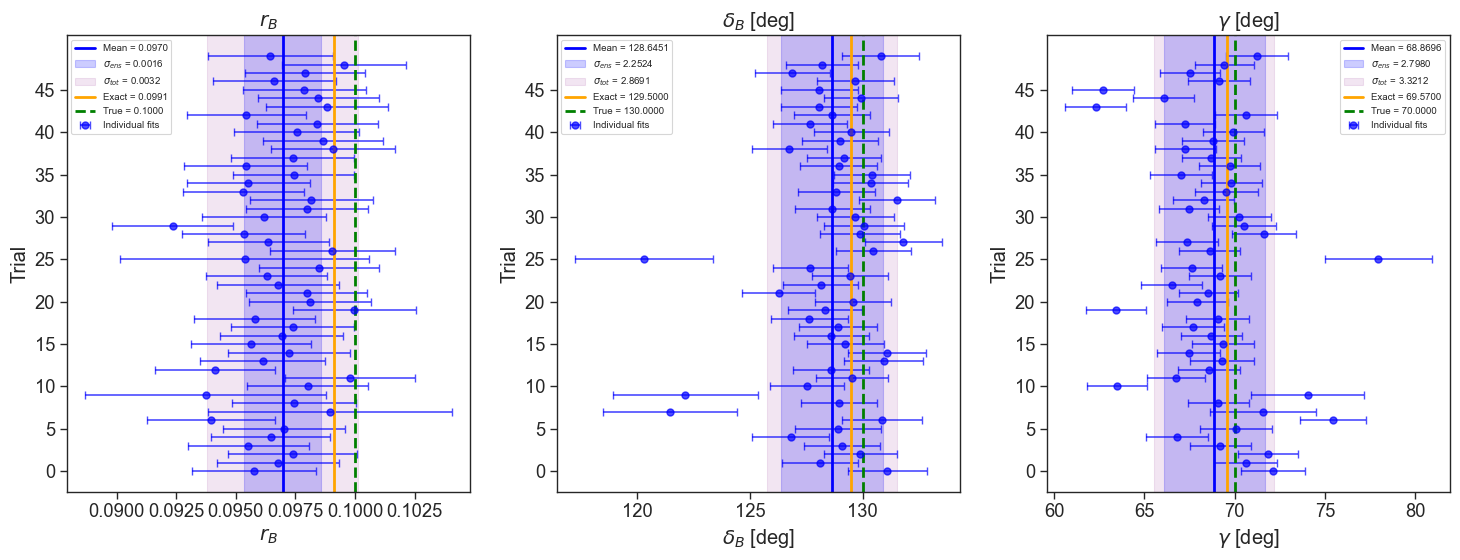


Parameter          Mean      σ_fit      σ_ens      σ_tot       True
rB               0.0970     0.0027     0.0016     0.0032     0.1000
delta [°]      128.6451     1.7772     2.2524     2.8691   130.0000
gamma [°]       68.8696     1.7893     2.7980     3.3212    70.0000


In [28]:
exact_rB = 0.0991
exact_delta = 129.5
exact_gamma = 69.57

# ============================================================================
# Plot results: stacked values with error bars
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

params = [
    (results_rB, errors_rB, exact_rB, r"$r_B$", true_rB),
    (results_delta, errors_delta, exact_delta, r"$\delta_B$ [deg]", true_deltaB * 180 / np.pi),
    (results_gamma, errors_gamma, exact_gamma, r"$\gamma$ [deg]", true_gamma * 180 / np.pi),
]

for ax, (vals, errs, exact_val, label, true_val) in zip(axes, params):
    # Compute errors
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    mean_val = vals.mean()
    
    # Y positions for stacking points
    y_pos = np.arange(len(vals))
    
    # Plot individual fits with their Minuit errors (horizontal error bars)
    ax.errorbar(vals, y_pos, xerr=errs, fmt='o', color='blue', 
                capsize=3, markersize=5, alpha=0.7, label='Individual fits')
    
    # Mean with ensemble spread
    ax.axvline(mean_val, color='blue', linestyle='-', linewidth=2, 
               label=f'Mean = {mean_val:.4f}')
    ax.axvspan(mean_val - sigma_ensemble, mean_val + sigma_ensemble, 
               alpha=0.2, color='blue', label=f'$\\sigma_{{ens}}$ = {sigma_ensemble:.4f}')
    
    # Total error band
    ax.axvspan(mean_val - sigma_total, mean_val + sigma_total, 
               alpha=0.1, color='purple', label=f'$\\sigma_{{tot}}$ = {sigma_total:.4f}')
    
    # Exact result
    ax.axvline(exact_val, color='orange', linestyle='-', linewidth=2, 
               label=f'Exact = {exact_val:.4f}')
    
    # True value
    ax.axvline(true_val, color='green', linestyle='--', linewidth=2, 
               label=f'True = {true_val:.4f}')
    
    ax.set_ylabel('Trial')
    ax.set_xlabel(label)
    ax.set_title(label)
    ax.legend(fontsize=7, loc='best')
    ax.set_yticks(y_pos[::5])  # Show every 5th trial label

plt.tight_layout()
plt.savefig("ensemble_fit_results.png", dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print(f"\n{'='*70}")
print(f"{'Parameter':<12} {'Mean':>10} {'σ_fit':>10} {'σ_ens':>10} {'σ_tot':>10} {'True':>10}")
print(f"{'='*70}")
for name, vals, errs, true_val in [
    ("rB", results_rB, errors_rB, true_rB),
    ("delta [°]", results_delta, errors_delta, true_deltaB * 180 / np.pi),
    ("gamma [°]", results_gamma, errors_gamma, true_gamma * 180 / np.pi),
]:
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    print(f"{name:<12} {vals.mean():>10.4f} {sigma_fit:>10.4f} {sigma_ensemble:>10.4f} {sigma_total:>10.4f} {true_val:>10.4f}")


Using ARC method

In [63]:
import random
import time
import glob
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# Ensemble fit: randomly select flows 25 times and compile results
# ============================================================================

n_trials = 50
n_blocks = 16
n_bins = 16
hidden_features = 128

# Get list of model files from each ensemble directory
def get_model_files(ensemble_dir):
    files = sorted(glob.glob(f"{ensemble_dir}/trial_seed*.pth"))
    return [f for f in files if not f.endswith('_best.pth')]

flavor_files = get_model_files("test_ensemble_2e6")
odd_files = get_model_files("test_ensemble_odd_1e6")
even_files = get_model_files("test_ensemble_even_1e6")

# Storage for results and errors
results_rB = []
results_delta = []
results_gamma = []
errors_rB = []
errors_delta = []
errors_gamma = []

for i in range(n_trials):
    print(f"\n{'='*60}")
    print(f"Trial {i+1}/{n_trials}")
    print(f"{'='*60}")
    
    # Randomly select one model from each ensemble
    flavor_path = random.choice(flavor_files)
    odd_path = random.choice(odd_files)
    even_path = random.choice(even_files)
    
    print(f"  flavor: {flavor_path}")
    print(f"  odd:    {odd_path}")
    print(f"  even:   {even_path}")
    
    # Load flavor flow
    flow = create_flow(num_flows=12, hidden_features=hidden_features, num_bins=24)
    flow.load_state_dict(torch.load(flavor_path, map_location=device), strict=False)
    flow.to(device)
    flow.eval()
    
    # Load odd flow
    flow_odd = create_flow(num_flows=n_bins, hidden_features=hidden_features, num_bins=n_bins)
    flow_odd.load_state_dict(torch.load(odd_path, map_location=device), strict=False)
    flow_odd.to(device)
    flow_odd.eval()
    
    # Load even flow
    flow_even = create_flow(num_flows=n_blocks, hidden_features=hidden_features, num_bins=n_bins)
    flow_even.load_state_dict(torch.load(even_path, map_location=device), strict=False)
    flow_even.to(device)
    flow_even.eval()
    
    # Run the fit
    m = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
        dataM_sdp=dataM_sdp,
        dataP_sdp=dataP_sdp,
        mcM_sdp=mcM_sdp,
        mcP_sdp=mcP_sdp,
        flow_flavor=flow,
        flow_even=flow_even,
        flow_odd=flow_odd,
        dkpp_model=dkpp,
        true_rB=true_rB,
        true_deltaB=true_deltaB * 180 / np.pi,
        true_gamma=true_gamma * 180 / np.pi,
        sdp_obj=sdp_obj,
        idx=(1, 2, 3),
        initial_scale=0.2,
        delta_offset=30,
        gamma_offset=30,
        device=device,
        Gamma_minus=gamma_m,
        Gamma_plus=gamma_p,
    )
    
    # Store values and errors
    results_rB.append(m.values['rB'])
    results_delta.append(m.values['delta'])
    results_gamma.append(m.values['gamma'])
    errors_rB.append(m.errors['rB'])
    errors_delta.append(m.errors['delta'])
    errors_gamma.append(m.errors['gamma'])

results_rB = np.array(results_rB)
results_delta = np.array(results_delta)
results_gamma = np.array(results_gamma)
errors_rB = np.array(errors_rB)
errors_delta = np.array(errors_delta)
errors_gamma = np.array(errors_gamma)

# ============================================================================
# Compute errors
# ============================================================================
print(f"\n{'='*60}")
print("SUMMARY")
print(f"{'='*60}")

for name, vals, errs, true_val in [
    ("rB", results_rB, errors_rB, true_rB),
    ("delta", results_delta, errors_delta, true_deltaB * 180 / np.pi),
    ("gamma", results_gamma, errors_gamma, true_gamma * 180 / np.pi),
]:
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    unit = "°" if name != "rB" else ""
    print(f"{name}: mean = {vals.mean():.4f}{unit}, "
          f"σ_ens = {sigma_ensemble:.4f}, σ_fit = {sigma_fit:.4f}, "
          f"σ_tot = {sigma_total:.4f}  (true = {true_val:.4f})")



Trial 1/50
  flavor: test_ensemble_2e6\trial_seed12.pth
  odd:    test_ensemble_odd_1e6\trial_seed25.pth
  even:   test_ensemble_even_1e6\trial_seed15.pth
41752 40528
Total fit time: 1.06s

rB    = 0.0985 ± 0.0026
delta = 128.35° ± 1.66°
gamma = 68.54° ± 1.68°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 2/50
  flavor: test_ensemble_2e6\trial_seed16.pth
  odd:    test_ensemble_odd_1e6\trial_seed23.pth
  even:   test_ensemble_even_1e6\trial_seed10.pth
41475 38873
Total fit time: 1.41s

rB    = 0.0964 ± 0.0026
delta = 130.47° ± 1.75°
gamma = 69.64° ± 1.77°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 3/50
  flavor: test_ensemble_2e6\trial_seed1.pth
  odd:    test_ensemble_odd_1e6\trial_seed2.pth
  even:   test_ensemble_even_1e6\trial_seed15.pth
38927 39789
Total fit time: 1.01s

rB    = 0.0987 ± 0.0026
delta = 130.09° ± 1.69°
gamma = 66.54° ± 1.71°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 4/50
  flavor: test_ensemble_2e6\trial_seed11.pth
  odd:    test_

In [72]:
import random
import time
import glob
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# Ensemble fit: randomly select flows 25 times and compile results
# ============================================================================

n_trials = 50
n_blocks = 16
n_bins = 16
hidden_features = 128

# Get list of model files from each ensemble directory
def get_model_files(ensemble_dir):
    files = sorted(glob.glob(f"{ensemble_dir}/trial_seed*.pth"))
    return [f for f in files if not f.endswith('_best.pth')]

flavor_files = get_model_files("test_ensemble_2e6")
odd_files = get_model_files("test_ensemble_odd_1e6")
even_files = get_model_files("test_ensemble_even_1e6")

# Storage for results and errors
results_rB = []
results_delta = []
results_gamma = []
errors_rB = []
errors_delta = []
errors_gamma = []

for i in range(n_trials):
    print(f"\n{'='*60}")
    print(f"Trial {i+1}/{n_trials}")
    print(f"{'='*60}")
    
    # Randomly select one model from each ensemble
    flavor_path = random.choice(flavor_files)
    odd_path = random.choice(odd_files)
    even_path = random.choice(even_files)
    
    print(f"  flavor: {flavor_path}")
    print(f"  odd:    {odd_path}")
    print(f"  even:   {even_path}")
    
    # Load flavor flow
    flow = create_flow(num_flows=12, hidden_features=hidden_features, num_bins=24)
    flow.load_state_dict(torch.load(flavor_path, map_location=device), strict=False)
    flow.to(device)
    flow.eval()
    
    # Load odd flow
    flow_odd = create_flow(num_flows=n_bins, hidden_features=hidden_features, num_bins=n_bins)
    flow_odd.load_state_dict(torch.load(odd_path, map_location=device), strict=False)
    flow_odd.to(device)
    flow_odd.eval()
    
    # Load even flow
    flow_even = create_flow(num_flows=n_blocks, hidden_features=hidden_features, num_bins=n_bins)
    flow_even.load_state_dict(torch.load(even_path, map_location=device), strict=False)
    flow_even.to(device)
    flow_even.eval()
    
    # Run the fit
    m = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
        dataM_sdp=dataM_sdp,
        dataP_sdp=dataP_sdp,
        mcM_sdp=mcM_sdp,
        mcP_sdp=mcP_sdp,
        flow_flavor=flow,
        flow_even=flow_even,
        flow_odd=flow_odd,
        dkpp_model=dkpp,
        true_rB=true_rB,
        true_deltaB=true_deltaB * 180 / np.pi,
        true_gamma=true_gamma * 180 / np.pi,
        sdp_obj=sdp_obj,
        idx=(1, 2, 3),
        initial_scale=0.2,
        delta_offset=30,
        gamma_offset=30,
        device=device,
        Gamma_minus=gamma_m,
        Gamma_plus=gamma_p,
    )
    
    # Store values and errors
    results_rB.append(m.values['rB'])
    results_delta.append(m.values['delta'])
    results_gamma.append(m.values['gamma'])
    errors_rB.append(m.errors['rB'])
    errors_delta.append(m.errors['delta'])
    errors_gamma.append(m.errors['gamma'])

results_rB = np.array(results_rB)
results_delta = np.array(results_delta)
results_gamma = np.array(results_gamma)
errors_rB = np.array(errors_rB)
errors_delta = np.array(errors_delta)
errors_gamma = np.array(errors_gamma)

# ============================================================================
# Compute errors
# ============================================================================
print(f"\n{'='*60}")
print("SUMMARY")
print(f"{'='*60}")

for name, vals, errs, true_val in [
    ("rB", results_rB, errors_rB, true_rB),
    ("delta", results_delta, errors_delta, true_deltaB * 180 / np.pi),
    ("gamma", results_gamma, errors_gamma, true_gamma * 180 / np.pi),
]:
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    unit = "°" if name != "rB" else ""
    print(f"{name}: mean = {vals.mean():.4f}{unit}, "
          f"σ_ens = {sigma_ensemble:.4f}, σ_fit = {sigma_fit:.4f}, "
          f"σ_tot = {sigma_total:.4f}  (true = {true_val:.4f})")



Trial 1/50
  flavor: test_ensemble_2e6\trial_seed7.pth
  odd:    test_ensemble_odd_1e6\trial_seed19.pth
  even:   test_ensemble_even_1e6\trial_seed1.pth
41038 41278
Total fit time: 1.05s

rB    = 0.0949 ± 0.0026
delta = 129.48° ± 1.73°
gamma = 73.45° ± 1.75°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 2/50
  flavor: test_ensemble_2e6\trial_seed2.pth
  odd:    test_ensemble_odd_1e6\trial_seed6.pth
  even:   test_ensemble_even_1e6\trial_seed17.pth
40784 41709
Total fit time: 1.06s

rB    = 0.0972 ± 0.0026
delta = 128.56° ± 1.69°
gamma = 68.19° ± 1.71°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 3/50
  flavor: test_ensemble_2e6\trial_seed2.pth
  odd:    test_ensemble_odd_1e6\trial_seed21.pth
  even:   test_ensemble_even_1e6\trial_seed24.pth
39565 39571
Total fit time: 1.55s

rB    = 0.0974 ± 0.0026
delta = 129.82° ± 1.70°
gamma = 68.43° ± 1.72°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 4/50
  flavor: test_ensemble_2e6\trial_seed25.pth
  odd:    test_ens

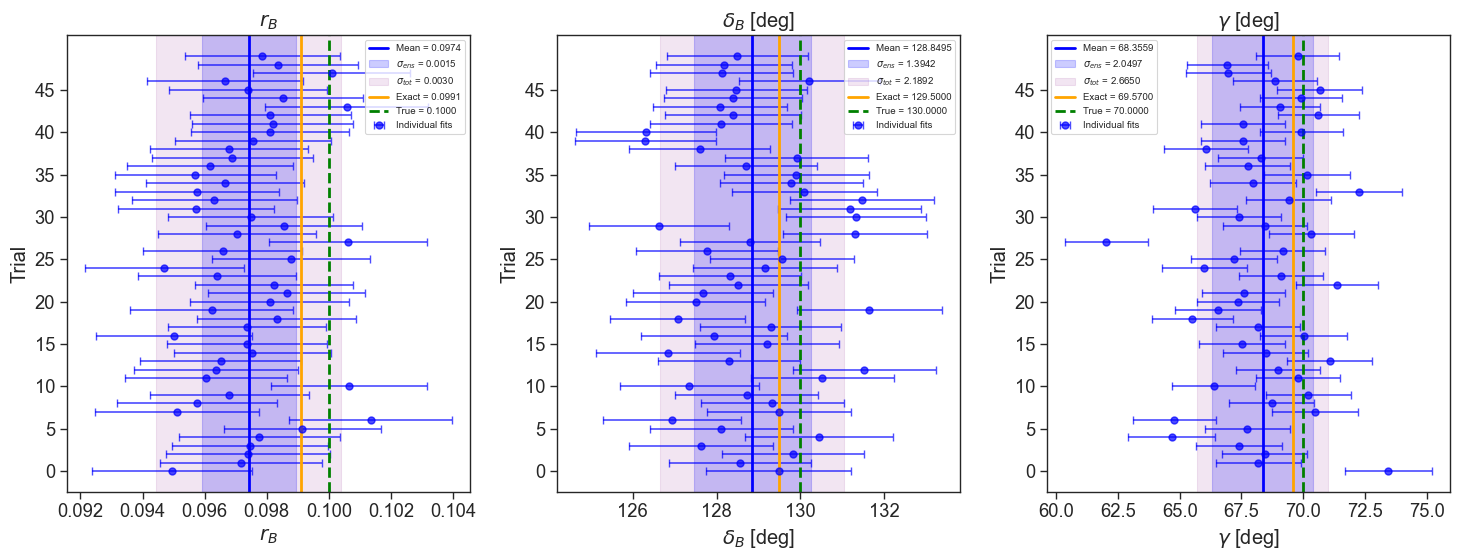


Parameter          Mean      σ_fit      σ_ens      σ_tot       True
rB               0.0974     0.0026     0.0015     0.0030     0.1000
delta [°]      128.8495     1.6878     1.3942     2.1892   130.0000
gamma [°]       68.3559     1.7033     2.0497     2.6650    70.0000


In [74]:
exact_rB = 0.0991
exact_delta = 129.5
exact_gamma = 69.57

# ============================================================================
# Plot results: stacked values with error bars
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

params = [
    (results_rB, errors_rB, exact_rB, r"$r_B$", true_rB),
    (results_delta, errors_delta, exact_delta, r"$\delta_B$ [deg]", true_deltaB * 180 / np.pi),
    (results_gamma, errors_gamma, exact_gamma, r"$\gamma$ [deg]", true_gamma * 180 / np.pi),
]

for ax, (vals, errs, exact_val, label, true_val) in zip(axes, params):
    # Compute errors
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    mean_val = vals.mean()
    
    # Y positions for stacking points
    y_pos = np.arange(len(vals))
    
    # Plot individual fits with their Minuit errors (horizontal error bars)
    ax.errorbar(vals, y_pos, xerr=errs, fmt='o', color='blue', 
                capsize=3, markersize=5, alpha=0.7, label='Individual fits')
    
    # Mean with ensemble spread
    ax.axvline(mean_val, color='blue', linestyle='-', linewidth=2, 
               label=f'Mean = {mean_val:.4f}')
    ax.axvspan(mean_val - sigma_ensemble, mean_val + sigma_ensemble, 
               alpha=0.2, color='blue', label=f'$\\sigma_{{ens}}$ = {sigma_ensemble:.4f}')
    
    # Total error band
    ax.axvspan(mean_val - sigma_total, mean_val + sigma_total, 
               alpha=0.1, color='purple', label=f'$\\sigma_{{tot}}$ = {sigma_total:.4f}')
    
    # Exact result
    ax.axvline(exact_val, color='orange', linestyle='-', linewidth=2, 
               label=f'Exact = {exact_val:.4f}')
    
    # True value
    ax.axvline(true_val, color='green', linestyle='--', linewidth=2, 
               label=f'True = {true_val:.4f}')
    
    ax.set_ylabel('Trial')
    ax.set_xlabel(label)
    ax.set_title(label)
    ax.legend(fontsize=7, loc='best')
    ax.set_yticks(y_pos[::5])  # Show every 5th trial label

plt.tight_layout()
plt.savefig("ensemble_fit_results.png", dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print(f"\n{'='*70}")
print(f"{'Parameter':<12} {'Mean':>10} {'σ_fit':>10} {'σ_ens':>10} {'σ_tot':>10} {'True':>10}")
print(f"{'='*70}")
for name, vals, errs, true_val in [
    ("rB", results_rB, errors_rB, true_rB),
    ("delta [°]", results_delta, errors_delta, true_deltaB * 180 / np.pi),
    ("gamma [°]", results_gamma, errors_gamma, true_gamma * 180 / np.pi),
]:
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    print(f"{name:<12} {vals.mean():>10.4f} {sigma_fit:>10.4f} {sigma_ensemble:>10.4f} {sigma_total:>10.4f} {true_val:>10.4f}")


In [78]:
import random
import time
import glob
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# Ensemble fit: randomly select flows 25 times and compile results
# ============================================================================

n_trials = 50
n_blocks = 16
n_bins = 16
hidden_features = 128

# Get list of model files from each ensemble directory
def get_model_files(ensemble_dir):
    files = sorted(glob.glob(f"{ensemble_dir}/trial_seed*.pth"))
    return [f for f in files if not f.endswith('_best.pth')]

flavor_files = get_model_files("test_ensemble_2e6")
odd_files = get_model_files("test_ensemble_odd_1e6")
even_files = get_model_files("test_ensemble_even_1e6")

# Storage for results and errors
results_rB = []
results_delta = []
results_gamma = []
errors_rB = []
errors_delta = []
errors_gamma = []

for i in range(n_trials):
    print(f"\n{'='*60}")
    print(f"Trial {i+1}/{n_trials}")
    print(f"{'='*60}")
    
    # Randomly select one model from each ensemble
    flavor_path = random.choice(flavor_files)
    odd_path = random.choice(odd_files)
    even_path = random.choice(even_files)
    
    print(f"  flavor: {flavor_path}")
    print(f"  odd:    {odd_path}")
    print(f"  even:   {even_path}")
    
    # Load flavor flow
    flow = create_flow(num_flows=12, hidden_features=hidden_features, num_bins=24)
    flow.load_state_dict(torch.load(flavor_path, map_location=device), strict=False)
    flow.to(device)
    flow.eval()
    
    # Load odd flow
    flow_odd = create_flow(num_flows=n_bins, hidden_features=hidden_features, num_bins=n_bins)
    flow_odd.load_state_dict(torch.load(odd_path, map_location=device), strict=False)
    flow_odd.to(device)
    flow_odd.eval()
    
    # Load even flow
    flow_even = create_flow(num_flows=n_blocks, hidden_features=hidden_features, num_bins=n_bins)
    flow_even.load_state_dict(torch.load(even_path, map_location=device), strict=False)
    flow_even.to(device)
    flow_even.eval()
    
    # Run the fit
    m = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
        dataM_sdp=dataM_sdp,
        dataP_sdp=dataP_sdp,
        mcM_sdp=mcM_sdp,
        mcP_sdp=mcP_sdp,
        flow_flavor=flow,
        flow_even=flow_even,
        flow_odd=flow_odd,
        dkpp_model=dkpp,
        true_rB=true_rB,
        true_deltaB=true_deltaB * 180 / np.pi,
        true_gamma=true_gamma * 180 / np.pi,
        sdp_obj=sdp_obj,
        idx=(1, 2, 3),
        initial_scale=0.2,
        delta_offset=30,
        gamma_offset=30,
        device=device,
        Gamma_minus=gamma_m,
        Gamma_plus=gamma_p,
    )
    
    # Store values and errors
    results_rB.append(m.values['rB'])
    results_delta.append(m.values['delta'])
    results_gamma.append(m.values['gamma'])
    errors_rB.append(m.errors['rB'])
    errors_delta.append(m.errors['delta'])
    errors_gamma.append(m.errors['gamma'])

results_rB = np.array(results_rB)
results_delta = np.array(results_delta)
results_gamma = np.array(results_gamma)
errors_rB = np.array(errors_rB)
errors_delta = np.array(errors_delta)
errors_gamma = np.array(errors_gamma)

# ============================================================================
# Compute errors
# ============================================================================
print(f"\n{'='*60}")
print("SUMMARY")
print(f"{'='*60}")

for name, vals, errs, true_val in [
    ("rB", results_rB, errors_rB, true_rB),
    ("delta", results_delta, errors_delta, true_deltaB * 180 / np.pi),
    ("gamma", results_gamma, errors_gamma, true_gamma * 180 / np.pi),
]:
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    unit = "°" if name != "rB" else ""
    print(f"{name}: mean = {vals.mean():.4f}{unit}, "
          f"σ_ens = {sigma_ensemble:.4f}, σ_fit = {sigma_fit:.4f}, "
          f"σ_tot = {sigma_total:.4f}  (true = {true_val:.4f})")



Trial 1/50
  flavor: test_ensemble_2e6\trial_seed8.pth
  odd:    test_ensemble_odd_1e6\trial_seed7.pth
  even:   test_ensemble_even_1e6\trial_seed4.pth


c:\Users\chinh\anaconda3\Lib\site-packages\nflows\transforms\coupling.py:481: UserWarning: Inputs to the softmax are not scaled down: initialization might be bad.
  warnings.warn(


43725 41348
Total fit time: 1.20s

rB    = 0.0980 ± 0.0026
delta = 127.83° ± 1.63°
gamma = 69.72° ± 1.65°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 2/50
  flavor: test_ensemble_2e6\trial_seed3.pth
  odd:    test_ensemble_odd_1e6\trial_seed7.pth
  even:   test_ensemble_even_1e6\trial_seed11.pth
43670 41152
Total fit time: 1.07s

rB    = 0.0991 ± 0.0026
delta = 128.68° ± 1.66°
gamma = 67.83° ± 1.68°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 3/50
  flavor: test_ensemble_2e6\trial_seed11.pth
  odd:    test_ensemble_odd_1e6\trial_seed22.pth
  even:   test_ensemble_even_1e6\trial_seed21.pth
39365 41467
Total fit time: 1.14s

rB    = 0.0951 ± 0.0027
delta = 128.54° ± 1.77°
gamma = 71.17° ± 1.81°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 4/50
  flavor: test_ensemble_2e6\trial_seed14.pth
  odd:    test_ensemble_odd_1e6\trial_seed24.pth
  even:   test_ensemble_even_1e6\trial_seed24.pth
41365 40894
Total fit time: 1.58s

rB    = 0.0974 ± 0.0026
delta = 129.1

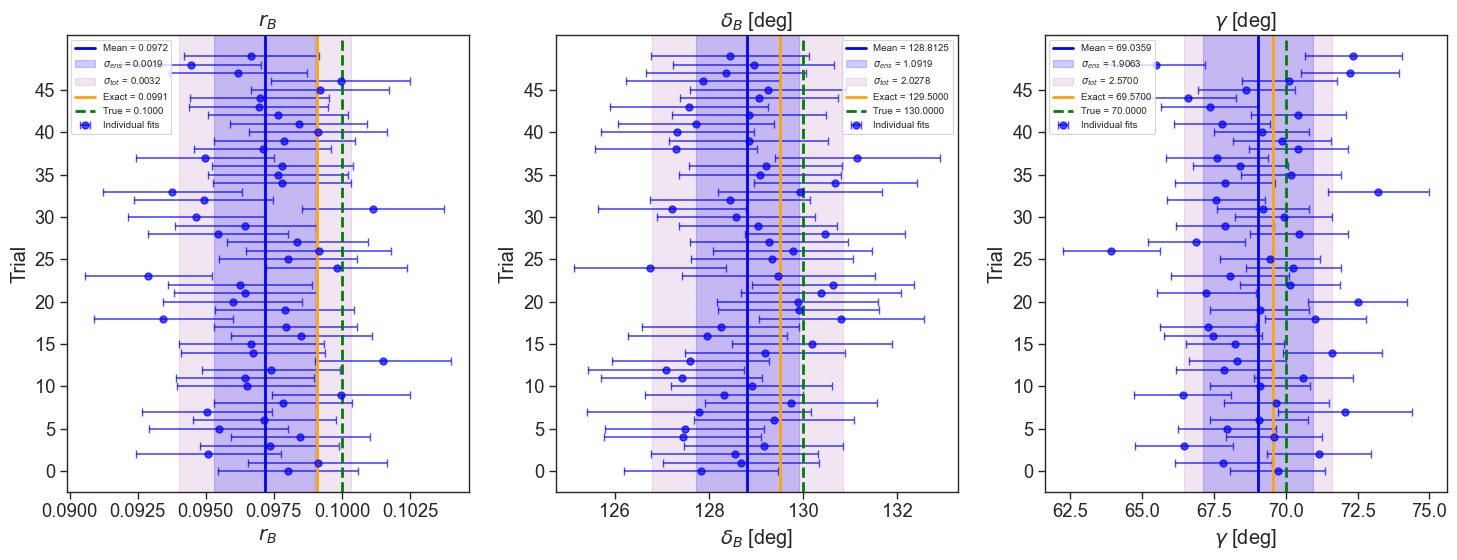


Parameter          Mean      σ_fit      σ_ens      σ_tot       True
rB               0.0972     0.0026     0.0019     0.0032     0.1000
delta [°]      128.8125     1.7087     1.0919     2.0278   130.0000
gamma [°]       69.0359     1.7237     1.9063     2.5700    70.0000


In [79]:
exact_rB = 0.0991
exact_delta = 129.5
exact_gamma = 69.57

# ============================================================================
# Plot results: stacked values with error bars
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

params = [
    (results_rB, errors_rB, exact_rB, r"$r_B$", true_rB),
    (results_delta, errors_delta, exact_delta, r"$\delta_B$ [deg]", true_deltaB * 180 / np.pi),
    (results_gamma, errors_gamma, exact_gamma, r"$\gamma$ [deg]", true_gamma * 180 / np.pi),
]

for ax, (vals, errs, exact_val, label, true_val) in zip(axes, params):
    # Compute errors
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    mean_val = vals.mean()
    
    # Y positions for stacking points
    y_pos = np.arange(len(vals))
    
    # Plot individual fits with their Minuit errors (horizontal error bars)
    ax.errorbar(vals, y_pos, xerr=errs, fmt='o', color='blue', 
                capsize=3, markersize=5, alpha=0.7, label='Individual fits')
    
    # Mean with ensemble spread
    ax.axvline(mean_val, color='blue', linestyle='-', linewidth=2, 
               label=f'Mean = {mean_val:.4f}')
    ax.axvspan(mean_val - sigma_ensemble, mean_val + sigma_ensemble, 
               alpha=0.2, color='blue', label=f'$\\sigma_{{ens}}$ = {sigma_ensemble:.4f}')
    
    # Total error band
    ax.axvspan(mean_val - sigma_total, mean_val + sigma_total, 
               alpha=0.1, color='purple', label=f'$\\sigma_{{tot}}$ = {sigma_total:.4f}')
    
    # Exact result
    ax.axvline(exact_val, color='orange', linestyle='-', linewidth=2, 
               label=f'Exact = {exact_val:.4f}')
    
    # True value
    ax.axvline(true_val, color='green', linestyle='--', linewidth=2, 
               label=f'True = {true_val:.4f}')
    
    ax.set_ylabel('Trial')
    ax.set_xlabel(label)
    ax.set_title(label)
    ax.legend(fontsize=7, loc='best')
    ax.set_yticks(y_pos[::5])  # Show every 5th trial label

plt.tight_layout()
plt.savefig("ensemble_fit_results.png", dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print(f"\n{'='*70}")
print(f"{'Parameter':<12} {'Mean':>10} {'σ_fit':>10} {'σ_ens':>10} {'σ_tot':>10} {'True':>10}")
print(f"{'='*70}")
for name, vals, errs, true_val in [
    ("rB", results_rB, errors_rB, true_rB),
    ("delta [°]", results_delta, errors_delta, true_deltaB * 180 / np.pi),
    ("gamma [°]", results_gamma, errors_gamma, true_gamma * 180 / np.pi),
]:
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    print(f"{name:<12} {vals.mean():>10.4f} {sigma_fit:>10.4f} {sigma_ensemble:>10.4f} {sigma_total:>10.4f} {true_val:>10.4f}")


In [117]:
import random
import time
import glob
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# Ensemble fit: randomly select flows 25 times and compile results
# ============================================================================

n_trials = 50
n_blocks = 16
n_bins = 16
hidden_features = 128

# Get list of model files from each ensemble directory
def get_model_files(ensemble_dir):
    files = sorted(glob.glob(f"{ensemble_dir}/trial_seed*.pth"))
    return [f for f in files if not f.endswith('_best.pth')]

flavor_files = get_model_files("test_ensemble_2e6")
odd_files = get_model_files("test_ensemble_odd_1e6")
even_files = get_model_files("test_ensemble_even_1e6")

# Storage for results and errors
results_rB = []
results_delta = []
results_gamma = []
errors_rB = []
errors_delta = []
errors_gamma = []

for i in range(n_trials):
    print(f"\n{'='*60}")
    print(f"Trial {i+1}/{n_trials}")
    print(f"{'='*60}")
    
    # Randomly select one model from each ensemble
    flavor_path = random.choice(flavor_files)
    odd_path = random.choice(odd_files)
    even_path = random.choice(even_files)
    
    print(f"  flavor: {flavor_path}")
    print(f"  odd:    {odd_path}")
    print(f"  even:   {even_path}")
    
    # Load flavor flow
    flow = create_flow(num_flows=12, hidden_features=hidden_features, num_bins=24)
    flow.load_state_dict(torch.load(flavor_path, map_location=device), strict=False)
    flow.to(device)
    flow.eval()
    
    # Load odd flow
    flow_odd = create_flow(num_flows=n_bins, hidden_features=hidden_features, num_bins=n_bins)
    flow_odd.load_state_dict(torch.load(odd_path, map_location=device), strict=False)
    flow_odd.to(device)
    flow_odd.eval()
    
    # Load even flow
    flow_even = create_flow(num_flows=n_blocks, hidden_features=hidden_features, num_bins=n_bins)
    flow_even.load_state_dict(torch.load(even_path, map_location=device), strict=False)
    flow_even.to(device)
    flow_even.eval()
    
    # Run the fit
    m = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
        dataM_sdp=dataM_sdp,
        dataP_sdp=dataP_sdp,
        mcM_sdp=mcM_sdp,
        mcP_sdp=mcP_sdp,
        flow_flavor=flow,
        flow_even=flow_even,
        flow_odd=flow_odd,
        dkpp_model=dkpp,
        true_rB=true_rB,
        true_deltaB=true_deltaB * 180 / np.pi,
        true_gamma=true_gamma * 180 / np.pi,
        sdp_obj=sdp_obj,
        idx=(1, 2, 3),
        initial_scale=0.2,
        delta_offset=30,
        gamma_offset=30,
        device=device,
        Gamma_minus=gamma_m,
        Gamma_plus=gamma_p,
    )
    
    # Store values and errors
    results_rB.append(m.values['rB'])
    results_delta.append(m.values['delta'])
    results_gamma.append(m.values['gamma'])
    errors_rB.append(m.errors['rB'])
    errors_delta.append(m.errors['delta'])
    errors_gamma.append(m.errors['gamma'])

results_rB = np.array(results_rB)
results_delta = np.array(results_delta)
results_gamma = np.array(results_gamma)
errors_rB = np.array(errors_rB)
errors_delta = np.array(errors_delta)
errors_gamma = np.array(errors_gamma)

# ============================================================================
# Compute errors
# ============================================================================
print(f"\n{'='*60}")
print("SUMMARY")
print(f"{'='*60}")

for name, vals, errs, true_val in [
    ("rB", results_rB, errors_rB, true_rB),
    ("delta", results_delta, errors_delta, true_deltaB * 180 / np.pi),
    ("gamma", results_gamma, errors_gamma, true_gamma * 180 / np.pi),
]:
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    unit = "°" if name != "rB" else ""
    print(f"{name}: mean = {vals.mean():.4f}{unit}, "
          f"σ_ens = {sigma_ensemble:.4f}, σ_fit = {sigma_fit:.4f}, "
          f"σ_tot = {sigma_total:.4f}  (true = {true_val:.4f})")



Trial 1/50
  flavor: test_ensemble_2e6\trial_seed16.pth
  odd:    test_ensemble_odd_1e6\trial_seed11.pth
  even:   test_ensemble_even_1e6\trial_seed15.pth
49692 49627
Total fit time: 1.20s

rB    = 0.0976 ± 0.0024
delta = 131.88° ± 1.56°
gamma = 69.21° ± 1.56°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 2/50
  flavor: test_ensemble_2e6\trial_seed12.pth
  odd:    test_ensemble_odd_1e6\trial_seed14.pth
  even:   test_ensemble_even_1e6\trial_seed11.pth
49871 49884
Total fit time: 1.24s

rB    = 0.0980 ± 0.0023
delta = 129.27° ± 1.58°
gamma = 66.44° ± 1.59°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 3/50
  flavor: test_ensemble_2e6\trial_seed5.pth
  odd:    test_ensemble_odd_1e6\trial_seed5.pth
  even:   test_ensemble_even_1e6\trial_seed12.pth
49735 49486
Total fit time: 1.14s

rB    = 0.0979 ± 0.0024
delta = 128.48° ± 1.56°
gamma = 66.64° ± 1.57°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 4/50
  flavor: test_ensemble_2e6\trial_seed12.pth
  odd:    test_

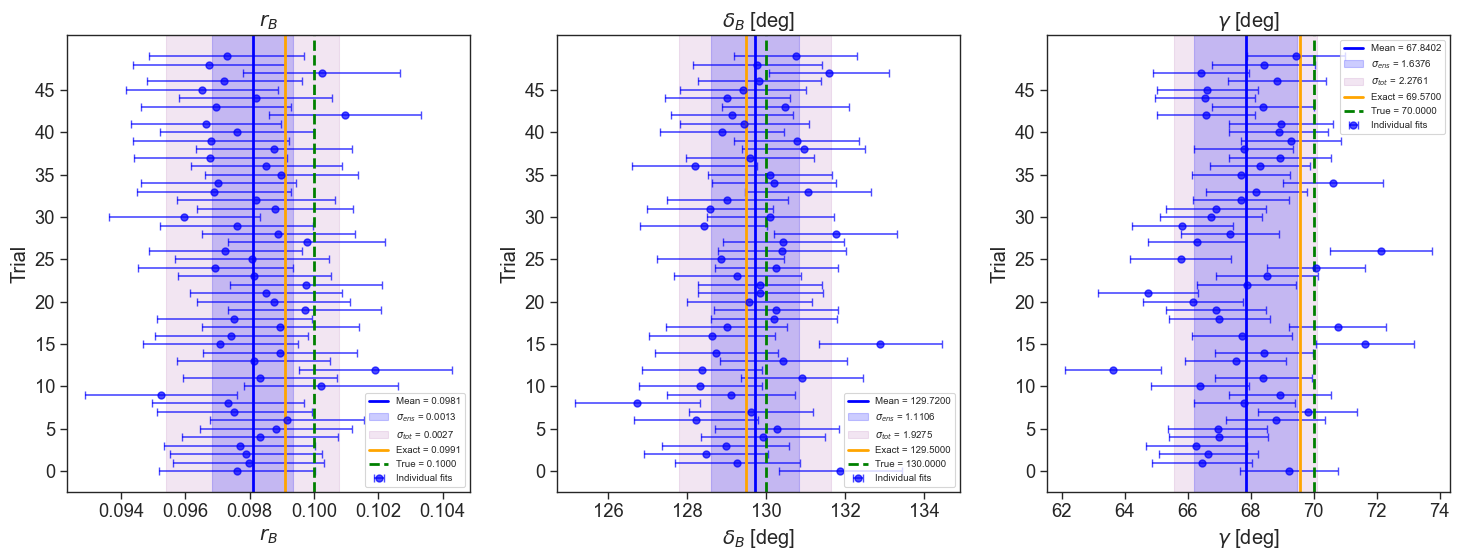


Parameter          Mean      σ_fit      σ_ens      σ_tot       True
rB               0.0981     0.0024     0.0013     0.0027     0.1000
delta [°]      129.7200     1.5754     1.1106     1.9275   130.0000
gamma [°]       67.8402     1.5807     1.6376     2.2761    70.0000


In [118]:
exact_rB = 0.0991
exact_delta = 129.5
exact_gamma = 69.57

# ============================================================================
# Plot results: stacked values with error bars
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

params = [
    (results_rB, errors_rB, exact_rB, r"$r_B$", true_rB),
    (results_delta, errors_delta, exact_delta, r"$\delta_B$ [deg]", true_deltaB * 180 / np.pi),
    (results_gamma, errors_gamma, exact_gamma, r"$\gamma$ [deg]", true_gamma * 180 / np.pi),
]

for ax, (vals, errs, exact_val, label, true_val) in zip(axes, params):
    # Compute errors
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    mean_val = vals.mean()
    
    # Y positions for stacking points
    y_pos = np.arange(len(vals))
    
    # Plot individual fits with their Minuit errors (horizontal error bars)
    ax.errorbar(vals, y_pos, xerr=errs, fmt='o', color='blue', 
                capsize=3, markersize=5, alpha=0.7, label='Individual fits')
    
    # Mean with ensemble spread
    ax.axvline(mean_val, color='blue', linestyle='-', linewidth=2, 
               label=f'Mean = {mean_val:.4f}')
    ax.axvspan(mean_val - sigma_ensemble, mean_val + sigma_ensemble, 
               alpha=0.2, color='blue', label=f'$\\sigma_{{ens}}$ = {sigma_ensemble:.4f}')
    
    # Total error band
    ax.axvspan(mean_val - sigma_total, mean_val + sigma_total, 
               alpha=0.1, color='purple', label=f'$\\sigma_{{tot}}$ = {sigma_total:.4f}')
    
    # Exact result
    ax.axvline(exact_val, color='orange', linestyle='-', linewidth=2, 
               label=f'Exact = {exact_val:.4f}')
    
    # True value
    ax.axvline(true_val, color='green', linestyle='--', linewidth=2, 
               label=f'True = {true_val:.4f}')
    
    ax.set_ylabel('Trial')
    ax.set_xlabel(label)
    ax.set_title(label)
    ax.legend(fontsize=7, loc='best')
    ax.set_yticks(y_pos[::5])  # Show every 5th trial label

plt.tight_layout()
plt.savefig("ensemble_fit_results.png", dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print(f"\n{'='*70}")
print(f"{'Parameter':<12} {'Mean':>10} {'σ_fit':>10} {'σ_ens':>10} {'σ_tot':>10} {'True':>10}")
print(f"{'='*70}")
for name, vals, errs, true_val in [
    ("rB", results_rB, errors_rB, true_rB),
    ("delta [°]", results_delta, errors_delta, true_deltaB * 180 / np.pi),
    ("gamma [°]", results_gamma, errors_gamma, true_gamma * 180 / np.pi),
]:
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    print(f"{name:<12} {vals.mean():>10.4f} {sigma_fit:>10.4f} {sigma_ensemble:>10.4f} {sigma_total:>10.4f} {true_val:>10.4f}")


In [110]:
import random
import time
import glob
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# Ensemble fit: randomly select flows 25 times and compile results
# ============================================================================

n_trials = 50
n_blocks = 16
n_bins = 16
hidden_features = 128

# Get list of model files from each ensemble directory
def get_model_files(ensemble_dir):
    files = sorted(glob.glob(f"{ensemble_dir}/trial_seed*.pth"))
    return [f for f in files if not f.endswith('_best.pth')]

flavor_files = get_model_files("test_ensemble_2e6")
odd_files = get_model_files("test_ensemble_odd_1e6")
even_files = get_model_files("test_ensemble_even_1e6")

# Storage for results and errors
results_rB = []
results_delta = []
results_gamma = []
errors_rB = []
errors_delta = []
errors_gamma = []

for i in range(n_trials):
    print(f"\n{'='*60}")
    print(f"Trial {i+1}/{n_trials}")
    print(f"{'='*60}")
    
    # Randomly select one model from each ensemble
    flavor_path = random.choice(flavor_files)
    odd_path = random.choice(odd_files)
    even_path = random.choice(even_files)
    
    print(f"  flavor: {flavor_path}")
    print(f"  odd:    {odd_path}")
    print(f"  even:   {even_path}")
    
    # Load flavor flow
    flow = create_flow(num_flows=12, hidden_features=hidden_features, num_bins=24)
    flow.load_state_dict(torch.load(flavor_path, map_location=device), strict=False)
    flow.to(device)
    flow.eval()
    
    # Load odd flow
    flow_odd = create_flow(num_flows=n_bins, hidden_features=hidden_features, num_bins=n_bins)
    flow_odd.load_state_dict(torch.load(odd_path, map_location=device), strict=False)
    flow_odd.to(device)
    flow_odd.eval()
    
    # Load even flow
    flow_even = create_flow(num_flows=n_blocks, hidden_features=hidden_features, num_bins=n_bins)
    flow_even.load_state_dict(torch.load(even_path, map_location=device), strict=False)
    flow_even.to(device)
    flow_even.eval()
    
    # Run the fit
    m = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
        dataM_sdp=dataM_sdp,
        dataP_sdp=dataP_sdp,
        mcM_sdp=mcM_sdp,
        mcP_sdp=mcP_sdp,
        flow_flavor=flow,
        flow_even=flow_even,
        flow_odd=flow_odd,
        dkpp_model=dkpp,
        true_rB=true_rB,
        true_deltaB=true_deltaB * 180 / np.pi,
        true_gamma=true_gamma * 180 / np.pi,
        sdp_obj=sdp_obj,
        idx=(1, 2, 3),
        initial_scale=0.2,
        delta_offset=30,
        gamma_offset=30,
        device=device,
        Gamma_minus=gamma_m,
        Gamma_plus=gamma_p,
    )
    
    # Store values and errors
    results_rB.append(m.values['rB'])
    results_delta.append(m.values['delta'])
    results_gamma.append(m.values['gamma'])
    errors_rB.append(m.errors['rB'])
    errors_delta.append(m.errors['delta'])
    errors_gamma.append(m.errors['gamma'])

results_rB = np.array(results_rB)
results_delta = np.array(results_delta)
results_gamma = np.array(results_gamma)
errors_rB = np.array(errors_rB)
errors_delta = np.array(errors_delta)
errors_gamma = np.array(errors_gamma)

# ============================================================================
# Compute errors
# ============================================================================
print(f"\n{'='*60}")
print("SUMMARY")
print(f"{'='*60}")

for name, vals, errs, true_val in [
    ("rB", results_rB, errors_rB, true_rB),
    ("delta", results_delta, errors_delta, true_deltaB * 180 / np.pi),
    ("gamma", results_gamma, errors_gamma, true_gamma * 180 / np.pi),
]:
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    unit = "°" if name != "rB" else ""
    print(f"{name}: mean = {vals.mean():.4f}{unit}, "
          f"σ_ens = {sigma_ensemble:.4f}, σ_fit = {sigma_fit:.4f}, "
          f"σ_tot = {sigma_total:.4f}  (true = {true_val:.4f})")



Trial 1/50
  flavor: test_ensemble_2e6\trial_seed13.pth
  odd:    test_ensemble_odd_1e6\trial_seed19.pth
  even:   test_ensemble_even_1e6\trial_seed17.pth
41812 43795
Total fit time: 1.05s

rB    = 0.0950 ± 0.0025
delta = 127.54° ± 1.70°
gamma = 68.07° ± 1.72°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 2/50
  flavor: test_ensemble_2e6\trial_seed13.pth
  odd:    test_ensemble_odd_1e6\trial_seed5.pth
  even:   test_ensemble_even_1e6\trial_seed3.pth
43950 40397
Total fit time: 1.10s

rB    = 0.0986 ± 0.0026
delta = 128.06° ± 1.65°
gamma = 68.44° ± 1.67°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 3/50
  flavor: test_ensemble_2e6\trial_seed18.pth
  odd:    test_ensemble_odd_1e6\trial_seed13.pth
  even:   test_ensemble_even_1e6\trial_seed16.pth
43403 43254
Total fit time: 1.06s

rB    = 0.0975 ± 0.0026
delta = 127.60° ± 1.65°
gamma = 68.18° ± 1.67°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 4/50
  flavor: test_ensemble_2e6\trial_seed1.pth
  odd:    test_e

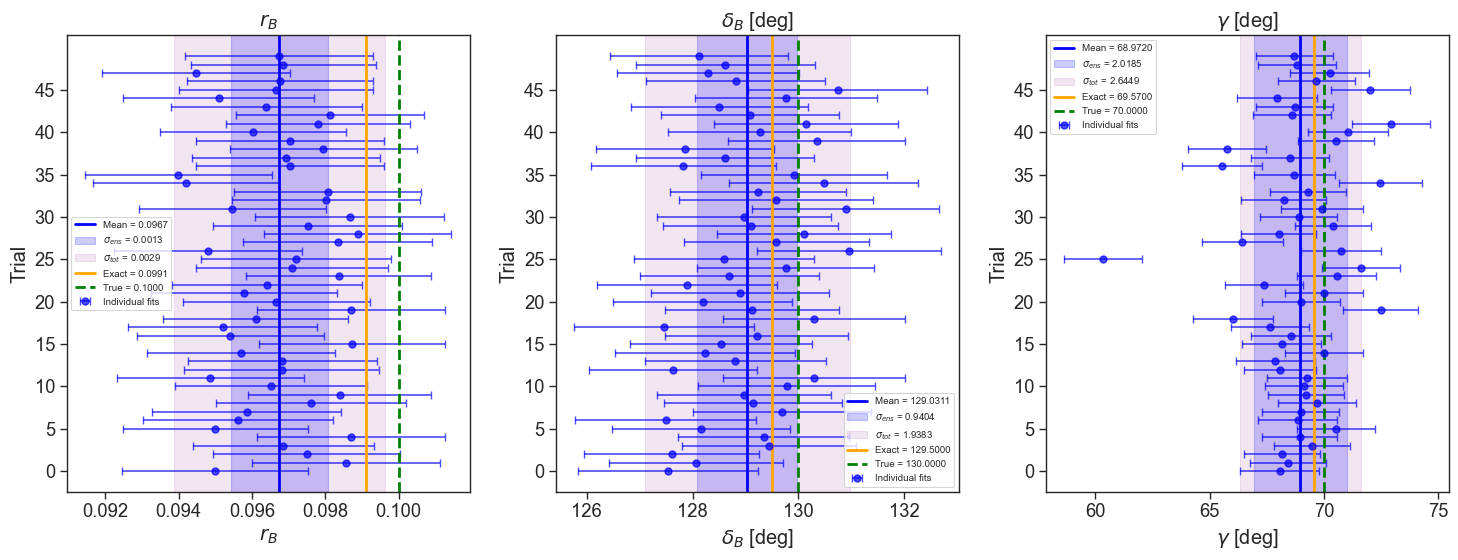


Parameter          Mean      σ_fit      σ_ens      σ_tot       True
rB               0.0967     0.0026     0.0013     0.0029     0.1000
delta [°]      129.0311     1.6949     0.9404     1.9383   130.0000
gamma [°]       68.9720     1.7092     2.0185     2.6449    70.0000


In [111]:
exact_rB = 0.0991
exact_delta = 129.5
exact_gamma = 69.57

# ============================================================================
# Plot results: stacked values with error bars
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

params = [
    (results_rB, errors_rB, exact_rB, r"$r_B$", true_rB),
    (results_delta, errors_delta, exact_delta, r"$\delta_B$ [deg]", true_deltaB * 180 / np.pi),
    (results_gamma, errors_gamma, exact_gamma, r"$\gamma$ [deg]", true_gamma * 180 / np.pi),
]

for ax, (vals, errs, exact_val, label, true_val) in zip(axes, params):
    # Compute errors
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    mean_val = vals.mean()
    
    # Y positions for stacking points
    y_pos = np.arange(len(vals))
    
    # Plot individual fits with their Minuit errors (horizontal error bars)
    ax.errorbar(vals, y_pos, xerr=errs, fmt='o', color='blue', 
                capsize=3, markersize=5, alpha=0.7, label='Individual fits')
    
    # Mean with ensemble spread
    ax.axvline(mean_val, color='blue', linestyle='-', linewidth=2, 
               label=f'Mean = {mean_val:.4f}')
    ax.axvspan(mean_val - sigma_ensemble, mean_val + sigma_ensemble, 
               alpha=0.2, color='blue', label=f'$\\sigma_{{ens}}$ = {sigma_ensemble:.4f}')
    
    # Total error band
    ax.axvspan(mean_val - sigma_total, mean_val + sigma_total, 
               alpha=0.1, color='purple', label=f'$\\sigma_{{tot}}$ = {sigma_total:.4f}')
    
    # Exact result
    ax.axvline(exact_val, color='orange', linestyle='-', linewidth=2, 
               label=f'Exact = {exact_val:.4f}')
    
    # True value
    ax.axvline(true_val, color='green', linestyle='--', linewidth=2, 
               label=f'True = {true_val:.4f}')
    
    ax.set_ylabel('Trial')
    ax.set_xlabel(label)
    ax.set_title(label)
    ax.legend(fontsize=7, loc='best')
    ax.set_yticks(y_pos[::5])  # Show every 5th trial label

plt.tight_layout()
plt.savefig("ensemble_fit_results.png", dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print(f"\n{'='*70}")
print(f"{'Parameter':<12} {'Mean':>10} {'σ_fit':>10} {'σ_ens':>10} {'σ_tot':>10} {'True':>10}")
print(f"{'='*70}")
for name, vals, errs, true_val in [
    ("rB", results_rB, errors_rB, true_rB),
    ("delta [°]", results_delta, errors_delta, true_deltaB * 180 / np.pi),
    ("gamma [°]", results_gamma, errors_gamma, true_gamma * 180 / np.pi),
]:
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    print(f"{name:<12} {vals.mean():>10.4f} {sigma_fit:>10.4f} {sigma_ensemble:>10.4f} {sigma_total:>10.4f} {true_val:>10.4f}")


Clamping method rather than removing points

In [113]:
import random
import time
import glob
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# Ensemble fit: randomly select flows 25 times and compile results
# ============================================================================

n_trials = 50
n_blocks = 16
n_bins = 16
hidden_features = 128

# Get list of model files from each ensemble directory
def get_model_files(ensemble_dir):
    files = sorted(glob.glob(f"{ensemble_dir}/trial_seed*.pth"))
    return [f for f in files if not f.endswith('_best.pth')]

flavor_files = get_model_files("test_ensemble_2e6")
odd_files = get_model_files("test_ensemble_odd_1e6")
even_files = get_model_files("test_ensemble_even_1e6")

# Storage for results and errors
results_rB = []
results_delta = []
results_gamma = []
errors_rB = []
errors_delta = []
errors_gamma = []

for i in range(n_trials):
    print(f"\n{'='*60}")
    print(f"Trial {i+1}/{n_trials}")
    print(f"{'='*60}")
    
    # Randomly select one model from each ensemble
    flavor_path = random.choice(flavor_files)
    odd_path = random.choice(odd_files)
    even_path = random.choice(even_files)
    
    print(f"  flavor: {flavor_path}")
    print(f"  odd:    {odd_path}")
    print(f"  even:   {even_path}")
    
    # Load flavor flow
    flow = create_flow(num_flows=12, hidden_features=hidden_features, num_bins=24)
    flow.load_state_dict(torch.load(flavor_path, map_location=device), strict=False)
    flow.to(device)
    flow.eval()
    
    # Load odd flow
    flow_odd = create_flow(num_flows=n_bins, hidden_features=hidden_features, num_bins=n_bins)
    flow_odd.load_state_dict(torch.load(odd_path, map_location=device), strict=False)
    flow_odd.to(device)
    flow_odd.eval()
    
    # Load even flow
    flow_even = create_flow(num_flows=n_blocks, hidden_features=hidden_features, num_bins=n_bins)
    flow_even.load_state_dict(torch.load(even_path, map_location=device), strict=False)
    flow_even.to(device)
    flow_even.eval()
    
    # Run the fit
    m = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
        dataM_sdp=dataM_sdp,
        dataP_sdp=dataP_sdp,
        mcM_sdp=mcM_sdp,
        mcP_sdp=mcP_sdp,
        flow_flavor=flow,
        flow_even=flow_even,
        flow_odd=flow_odd,
        dkpp_model=dkpp,
        true_rB=true_rB,
        true_deltaB=true_deltaB * 180 / np.pi,
        true_gamma=true_gamma * 180 / np.pi,
        sdp_obj=sdp_obj,
        idx=(1, 2, 3),
        initial_scale=0.2,
        delta_offset=30,
        gamma_offset=30,
        device=device,
        Gamma_minus=gamma_m,
        Gamma_plus=gamma_p,
    )
    
    # Store values and errors
    results_rB.append(m.values['rB'])
    results_delta.append(m.values['delta'])
    results_gamma.append(m.values['gamma'])
    errors_rB.append(m.errors['rB'])
    errors_delta.append(m.errors['delta'])
    errors_gamma.append(m.errors['gamma'])

results_rB = np.array(results_rB)
results_delta = np.array(results_delta)
results_gamma = np.array(results_gamma)
errors_rB = np.array(errors_rB)
errors_delta = np.array(errors_delta)
errors_gamma = np.array(errors_gamma)

# ============================================================================
# Compute errors
# ============================================================================
print(f"\n{'='*60}")
print("SUMMARY")
print(f"{'='*60}")

for name, vals, errs, true_val in [
    ("rB", results_rB, errors_rB, true_rB),
    ("delta", results_delta, errors_delta, true_deltaB * 180 / np.pi),
    ("gamma", results_gamma, errors_gamma, true_gamma * 180 / np.pi),
]:
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    unit = "°" if name != "rB" else ""
    print(f"{name}: mean = {vals.mean():.4f}{unit}, "
          f"σ_ens = {sigma_ensemble:.4f}, σ_fit = {sigma_fit:.4f}, "
          f"σ_tot = {sigma_total:.4f}  (true = {true_val:.4f})")



Trial 1/50
  flavor: test_ensemble_2e6\trial_seed2.pth
  odd:    test_ensemble_odd_1e6\trial_seed17.pth
  even:   test_ensemble_even_1e6\trial_seed25.pth


c:\Users\chinh\anaconda3\Lib\site-packages\nflows\transforms\coupling.py:481: UserWarning: Inputs to the softmax are not scaled down: initialization might be bad.
  warnings.warn(


47866 48189
Total fit time: 1.12s

rB    = 0.0979 ± 0.0024
delta = 128.09° ± 1.59°
gamma = 66.97° ± 1.60°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 2/50
  flavor: test_ensemble_2e6\trial_seed14.pth
  odd:    test_ensemble_odd_1e6\trial_seed14.pth
  even:   test_ensemble_even_1e6\trial_seed6.pth
48697 48600
Total fit time: 1.14s

rB    = 0.0987 ± 0.0024
delta = 130.25° ± 1.56°
gamma = 66.15° ± 1.57°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 3/50
  flavor: test_ensemble_2e6\trial_seed6.pth
  odd:    test_ensemble_odd_1e6\trial_seed22.pth
  even:   test_ensemble_even_1e6\trial_seed15.pth
47336 47867
Total fit time: 1.18s

rB    = 0.0999 ± 0.0024
delta = 129.99° ± 1.59°
gamma = 67.12° ± 1.60°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 4/50
  flavor: test_ensemble_2e6\trial_seed24.pth
  odd:    test_ensemble_odd_1e6\trial_seed3.pth
  even:   test_ensemble_even_1e6\trial_seed20.pth
48659 48881
Total fit time: 1.19s

rB    = 0.0973 ± 0.0024
delta = 128.96

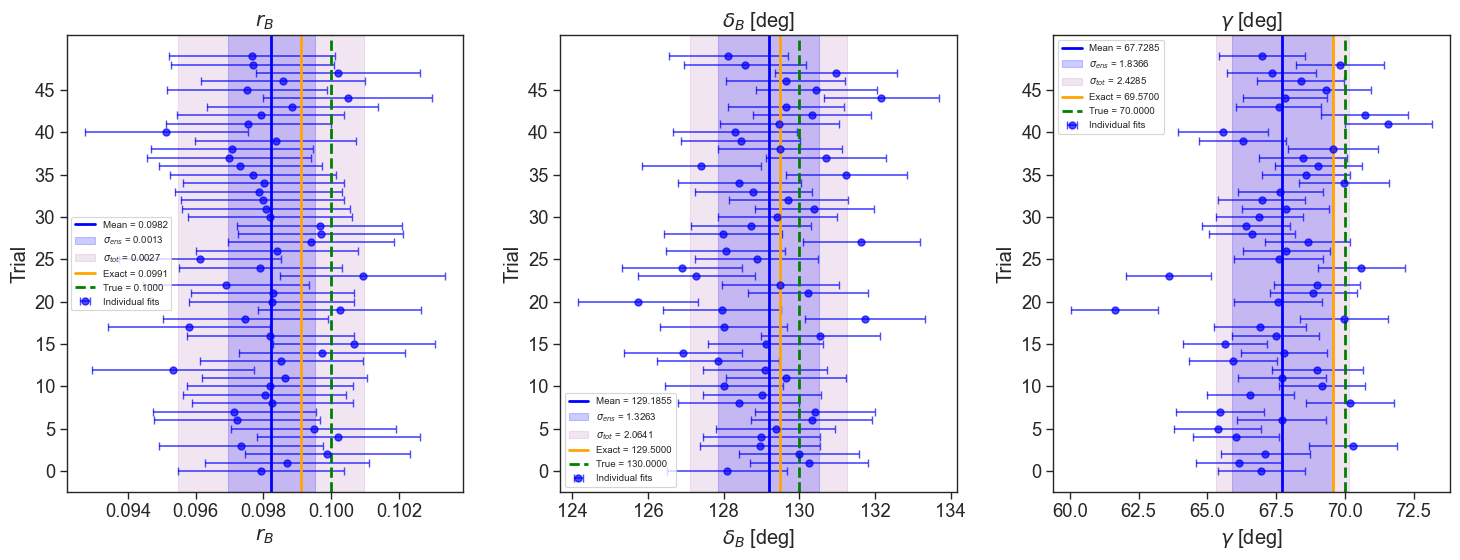


Parameter          Mean      σ_fit      σ_ens      σ_tot       True
rB               0.0982     0.0024     0.0013     0.0027     0.1000
delta [°]      129.1855     1.5816     1.3263     2.0641   130.0000
gamma [°]       67.7285     1.5889     1.8366     2.4285    70.0000


In [114]:
exact_rB = 0.0991
exact_delta = 129.5
exact_gamma = 69.57

# ============================================================================
# Plot results: stacked values with error bars
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

params = [
    (results_rB, errors_rB, exact_rB, r"$r_B$", true_rB),
    (results_delta, errors_delta, exact_delta, r"$\delta_B$ [deg]", true_deltaB * 180 / np.pi),
    (results_gamma, errors_gamma, exact_gamma, r"$\gamma$ [deg]", true_gamma * 180 / np.pi),
]

for ax, (vals, errs, exact_val, label, true_val) in zip(axes, params):
    # Compute errors
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    mean_val = vals.mean()
    
    # Y positions for stacking points
    y_pos = np.arange(len(vals))
    
    # Plot individual fits with their Minuit errors (horizontal error bars)
    ax.errorbar(vals, y_pos, xerr=errs, fmt='o', color='blue', 
                capsize=3, markersize=5, alpha=0.7, label='Individual fits')
    
    # Mean with ensemble spread
    ax.axvline(mean_val, color='blue', linestyle='-', linewidth=2, 
               label=f'Mean = {mean_val:.4f}')
    ax.axvspan(mean_val - sigma_ensemble, mean_val + sigma_ensemble, 
               alpha=0.2, color='blue', label=f'$\\sigma_{{ens}}$ = {sigma_ensemble:.4f}')
    
    # Total error band
    ax.axvspan(mean_val - sigma_total, mean_val + sigma_total, 
               alpha=0.1, color='purple', label=f'$\\sigma_{{tot}}$ = {sigma_total:.4f}')
    
    # Exact result
    ax.axvline(exact_val, color='orange', linestyle='-', linewidth=2, 
               label=f'Exact = {exact_val:.4f}')
    
    # True value
    ax.axvline(true_val, color='green', linestyle='--', linewidth=2, 
               label=f'True = {true_val:.4f}')
    
    ax.set_ylabel('Trial')
    ax.set_xlabel(label)
    ax.set_title(label)
    ax.legend(fontsize=7, loc='best')
    ax.set_yticks(y_pos[::5])  # Show every 5th trial label

plt.tight_layout()
plt.savefig("ensemble_fit_results.png", dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print(f"\n{'='*70}")
print(f"{'Parameter':<12} {'Mean':>10} {'σ_fit':>10} {'σ_ens':>10} {'σ_tot':>10} {'True':>10}")
print(f"{'='*70}")
for name, vals, errs, true_val in [
    ("rB", results_rB, errors_rB, true_rB),
    ("delta [°]", results_delta, errors_delta, true_deltaB * 180 / np.pi),
    ("gamma [°]", results_gamma, errors_gamma, true_gamma * 180 / np.pi),
]:
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    print(f"{name:<12} {vals.mean():>10.4f} {sigma_fit:>10.4f} {sigma_ensemble:>10.4f} {sigma_total:>10.4f} {true_val:>10.4f}")


In [67]:
import random
import time
import glob
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# Ensemble fit: randomly select flows 25 times and compile results
# ============================================================================

n_trials = 50
n_blocks = 16
n_bins = 16
hidden_features = 128

# Get list of model files from each ensemble directory
def get_model_files(ensemble_dir):
    files = sorted(glob.glob(f"{ensemble_dir}/trial_seed*.pth"))
    return [f for f in files if not f.endswith('_best.pth')]

flavor_files = get_model_files("test_ensemble_2e6")
odd_files = get_model_files("test_ensemble_odd_1e6")
even_files = get_model_files("test_ensemble_even_1e6")

# Storage for results and errors
results_rB = []
results_delta = []
results_gamma = []
errors_rB = []
errors_delta = []
errors_gamma = []

for i in range(n_trials):
    print(f"\n{'='*60}")
    print(f"Trial {i+1}/{n_trials}")
    print(f"{'='*60}")
    
    # Randomly select one model from each ensemble
    flavor_path = random.choice(flavor_files)
    odd_path = random.choice(odd_files)
    even_path = random.choice(even_files)
    
    print(f"  flavor: {flavor_path}")
    print(f"  odd:    {odd_path}")
    print(f"  even:   {even_path}")
    
    # Load flavor flow
    flow = create_flow(num_flows=12, hidden_features=hidden_features, num_bins=24)
    flow.load_state_dict(torch.load(flavor_path, map_location=device), strict=False)
    flow.to(device)
    flow.eval()
    
    # Load odd flow
    flow_odd = create_flow(num_flows=n_bins, hidden_features=hidden_features, num_bins=n_bins)
    flow_odd.load_state_dict(torch.load(odd_path, map_location=device), strict=False)
    flow_odd.to(device)
    flow_odd.eval()
    
    # Load even flow
    flow_even = create_flow(num_flows=n_blocks, hidden_features=hidden_features, num_bins=n_bins)
    flow_even.load_state_dict(torch.load(even_path, map_location=device), strict=False)
    flow_even.to(device)
    flow_even.eval()
    
    # Run the fit
    m = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
        dataM_sdp=dataM_sdp,
        dataP_sdp=dataP_sdp,
        mcM_sdp=mcM_sdp,
        mcP_sdp=mcP_sdp,
        flow_flavor=flow,
        flow_even=flow_even,
        flow_odd=flow_odd,
        dkpp_model=dkpp,
        true_rB=true_rB,
        true_deltaB=true_deltaB * 180 / np.pi,
        true_gamma=true_gamma * 180 / np.pi,
        sdp_obj=sdp_obj,
        idx=(1, 2, 3),
        initial_scale=0.2,
        delta_offset=30,
        gamma_offset=30,
        device=device,
        Gamma_minus=gamma_m,
        Gamma_plus=gamma_p,
    )
    
    # Store values and errors
    results_rB.append(m.values['rB'])
    results_delta.append(m.values['delta'])
    results_gamma.append(m.values['gamma'])
    errors_rB.append(m.errors['rB'])
    errors_delta.append(m.errors['delta'])
    errors_gamma.append(m.errors['gamma'])

results_rB = np.array(results_rB)
results_delta = np.array(results_delta)
results_gamma = np.array(results_gamma)
errors_rB = np.array(errors_rB)
errors_delta = np.array(errors_delta)
errors_gamma = np.array(errors_gamma)

# ============================================================================
# Compute errors
# ============================================================================
print(f"\n{'='*60}")
print("SUMMARY")
print(f"{'='*60}")

for name, vals, errs, true_val in [
    ("rB", results_rB, errors_rB, true_rB),
    ("delta", results_delta, errors_delta, true_deltaB * 180 / np.pi),
    ("gamma", results_gamma, errors_gamma, true_gamma * 180 / np.pi),
]:
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    unit = "°" if name != "rB" else ""
    print(f"{name}: mean = {vals.mean():.4f}{unit}, "
          f"σ_ens = {sigma_ensemble:.4f}, σ_fit = {sigma_fit:.4f}, "
          f"σ_tot = {sigma_total:.4f}  (true = {true_val:.4f})")



Trial 1/50
  flavor: test_ensemble_2e6\trial_seed15.pth
  odd:    test_ensemble_odd_1e6\trial_seed3.pth
  even:   test_ensemble_even_1e6\trial_seed10.pth
50000 50000
Total fit time: 1.33s

rB    = 0.0997 ± 0.0024
delta = 130.85° ± 1.57°
gamma = 70.35° ± 1.58°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 2/50
  flavor: test_ensemble_2e6\trial_seed12.pth
  odd:    test_ensemble_odd_1e6\trial_seed24.pth
  even:   test_ensemble_even_1e6\trial_seed4.pth
50000 50000
Total fit time: 1.39s

rB    = 0.0976 ± 0.0024
delta = 129.16° ± 1.58°
gamma = 66.00° ± 1.58°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 3/50
  flavor: test_ensemble_2e6\trial_seed8.pth
  odd:    test_ensemble_odd_1e6\trial_seed5.pth
  even:   test_ensemble_even_1e6\trial_seed5.pth
50000 50000
Total fit time: 1.40s

rB    = 0.0984 ± 0.0024
delta = 129.40° ± 1.52°
gamma = 67.38° ± 1.52°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 4/50
  flavor: test_ensemble_2e6\trial_seed15.pth
  odd:    test_ens

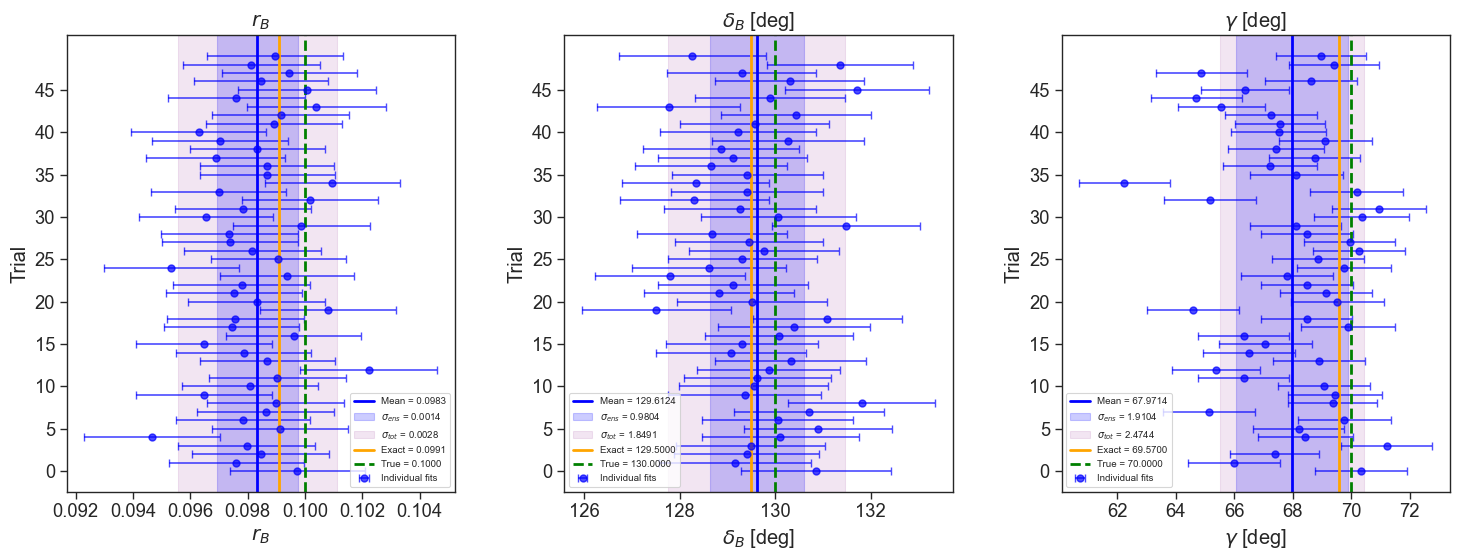


Parameter          Mean      σ_fit      σ_ens      σ_tot       True
rB               0.0983     0.0024     0.0014     0.0028     0.1000
delta [°]      129.6124     1.5678     0.9804     1.8491   130.0000
gamma [°]       67.9714     1.5726     1.9104     2.4744    70.0000


In [68]:
exact_rB = 0.0991
exact_delta = 129.5
exact_gamma = 69.57

# ============================================================================
# Plot results: stacked values with error bars
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

params = [
    (results_rB, errors_rB, exact_rB, r"$r_B$", true_rB),
    (results_delta, errors_delta, exact_delta, r"$\delta_B$ [deg]", true_deltaB * 180 / np.pi),
    (results_gamma, errors_gamma, exact_gamma, r"$\gamma$ [deg]", true_gamma * 180 / np.pi),
]

for ax, (vals, errs, exact_val, label, true_val) in zip(axes, params):
    # Compute errors
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    mean_val = vals.mean()
    
    # Y positions for stacking points
    y_pos = np.arange(len(vals))
    
    # Plot individual fits with their Minuit errors (horizontal error bars)
    ax.errorbar(vals, y_pos, xerr=errs, fmt='o', color='blue', 
                capsize=3, markersize=5, alpha=0.7, label='Individual fits')
    
    # Mean with ensemble spread
    ax.axvline(mean_val, color='blue', linestyle='-', linewidth=2, 
               label=f'Mean = {mean_val:.4f}')
    ax.axvspan(mean_val - sigma_ensemble, mean_val + sigma_ensemble, 
               alpha=0.2, color='blue', label=f'$\\sigma_{{ens}}$ = {sigma_ensemble:.4f}')
    
    # Total error band
    ax.axvspan(mean_val - sigma_total, mean_val + sigma_total, 
               alpha=0.1, color='purple', label=f'$\\sigma_{{tot}}$ = {sigma_total:.4f}')
    
    # Exact result
    ax.axvline(exact_val, color='orange', linestyle='-', linewidth=2, 
               label=f'Exact = {exact_val:.4f}')
    
    # True value
    ax.axvline(true_val, color='green', linestyle='--', linewidth=2, 
               label=f'True = {true_val:.4f}')
    
    ax.set_ylabel('Trial')
    ax.set_xlabel(label)
    ax.set_title(label)
    ax.legend(fontsize=7, loc='best')
    ax.set_yticks(y_pos[::5])  # Show every 5th trial label

plt.tight_layout()
plt.savefig("ensemble_fit_results.png", dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print(f"\n{'='*70}")
print(f"{'Parameter':<12} {'Mean':>10} {'σ_fit':>10} {'σ_ens':>10} {'σ_tot':>10} {'True':>10}")
print(f"{'='*70}")
for name, vals, errs, true_val in [
    ("rB", results_rB, errors_rB, true_rB),
    ("delta [°]", results_delta, errors_delta, true_deltaB * 180 / np.pi),
    ("gamma [°]", results_gamma, errors_gamma, true_gamma * 180 / np.pi),
]:
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    print(f"{name:<12} {vals.mean():>10.4f} {sigma_fit:>10.4f} {sigma_ensemble:>10.4f} {sigma_total:>10.4f} {true_val:>10.4f}")


In [128]:
import random
import time
import glob
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# Ensemble fit: randomly select flows 25 times and compile results
# ============================================================================

n_trials = 50
n_blocks = 16
n_bins = 16
hidden_features = 128

# Get list of model files from each ensemble directory
def get_model_files(ensemble_dir):
    files = sorted(glob.glob(f"{ensemble_dir}/trial_seed*.pth"))
    return [f for f in files if not f.endswith('_best.pth')]

flavor_files = get_model_files("test_ensemble_2e6")
odd_files = get_model_files("test_ensemble_odd_1e6")
even_files = get_model_files("test_ensemble_even_1e6")

# Storage for results and errors
results_rB = []
results_delta = []
results_gamma = []
errors_rB = []
errors_delta = []
errors_gamma = []

for i in range(n_trials):
    print(f"\n{'='*60}")
    print(f"Trial {i+1}/{n_trials}")
    print(f"{'='*60}")
    
    # Randomly select one model from each ensemble
    flavor_path = random.choice(flavor_files)
    odd_path = random.choice(odd_files)
    even_path = random.choice(even_files)
    
    print(f"  flavor: {flavor_path}")
    print(f"  odd:    {odd_path}")
    print(f"  even:   {even_path}")
    
    # Load flavor flow
    flow = create_flow(num_flows=12, hidden_features=hidden_features, num_bins=24)
    flow.load_state_dict(torch.load(flavor_path, map_location=device), strict=False)
    flow.to(device)
    flow.eval()
    
    # Load odd flow
    flow_odd = create_flow(num_flows=n_bins, hidden_features=hidden_features, num_bins=n_bins)
    flow_odd.load_state_dict(torch.load(odd_path, map_location=device), strict=False)
    flow_odd.to(device)
    flow_odd.eval()
    
    # Load even flow
    flow_even = create_flow(num_flows=n_blocks, hidden_features=hidden_features, num_bins=n_bins)
    flow_even.load_state_dict(torch.load(even_path, map_location=device), strict=False)
    flow_even.to(device)
    flow_even.eval()
    
    # Run the fit
    m = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
        dataM_sdp=dataM_sdp,
        dataP_sdp=dataP_sdp,
        mcM_sdp=mcM_sdp,
        mcP_sdp=mcP_sdp,
        flow_flavor=flow,
        flow_even=flow_even,
        flow_odd=flow_odd,
        dkpp_model=dkpp,
        true_rB=true_rB,
        true_deltaB=true_deltaB * 180 / np.pi,
        true_gamma=true_gamma * 180 / np.pi,
        sdp_obj=sdp_obj,
        idx=(1, 2, 3),
        initial_scale=0.2,
        delta_offset=30,
        gamma_offset=30,
        device=device,
        Gamma_minus=gamma_m,
        Gamma_plus=gamma_p,
    )
    
    # Store values and errors
    results_rB.append(m.values['rB'])
    results_delta.append(m.values['delta'])
    results_gamma.append(m.values['gamma'])
    errors_rB.append(m.errors['rB'])
    errors_delta.append(m.errors['delta'])
    errors_gamma.append(m.errors['gamma'])

results_rB = np.array(results_rB)
results_delta = np.array(results_delta)
results_gamma = np.array(results_gamma)
errors_rB = np.array(errors_rB)
errors_delta = np.array(errors_delta)
errors_gamma = np.array(errors_gamma)

# ============================================================================
# Compute errors
# ============================================================================
print(f"\n{'='*60}")
print("SUMMARY")
print(f"{'='*60}")

for name, vals, errs, true_val in [
    ("rB", results_rB, errors_rB, true_rB),
    ("delta", results_delta, errors_delta, true_deltaB * 180 / np.pi),
    ("gamma", results_gamma, errors_gamma, true_gamma * 180 / np.pi),
]:
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    unit = "°" if name != "rB" else ""
    print(f"{name}: mean = {vals.mean():.4f}{unit}, "
          f"σ_ens = {sigma_ensemble:.4f}, σ_fit = {sigma_fit:.4f}, "
          f"σ_tot = {sigma_total:.4f}  (true = {true_val:.4f})")



Trial 1/50
  flavor: test_ensemble_2e6\trial_seed8.pth
  odd:    test_ensemble_odd_1e6\trial_seed8.pth
  even:   test_ensemble_even_1e6\trial_seed10.pth
49789 49241
Total fit time: 1.60s

rB    = 0.0974 ± 0.0024
delta = 131.00° ± 1.55°
gamma = 67.39° ± 1.56°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 2/50
  flavor: test_ensemble_2e6\trial_seed3.pth
  odd:    test_ensemble_odd_1e6\trial_seed8.pth
  even:   test_ensemble_even_1e6\trial_seed20.pth
49670 49359
Total fit time: 1.38s

rB    = 0.0986 ± 0.0024
delta = 129.36° ± 1.60°
gamma = 66.98° ± 1.60°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 3/50
  flavor: test_ensemble_2e6\trial_seed23.pth
  odd:    test_ensemble_odd_1e6\trial_seed3.pth
  even:   test_ensemble_even_1e6\trial_seed4.pth
49732 49347
Total fit time: 1.35s

rB    = 0.0985 ± 0.0024
delta = 129.10° ± 1.58°
gamma = 67.63° ± 1.58°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 4/50
  flavor: test_ensemble_2e6\trial_seed6.pth
  odd:    test_ensem

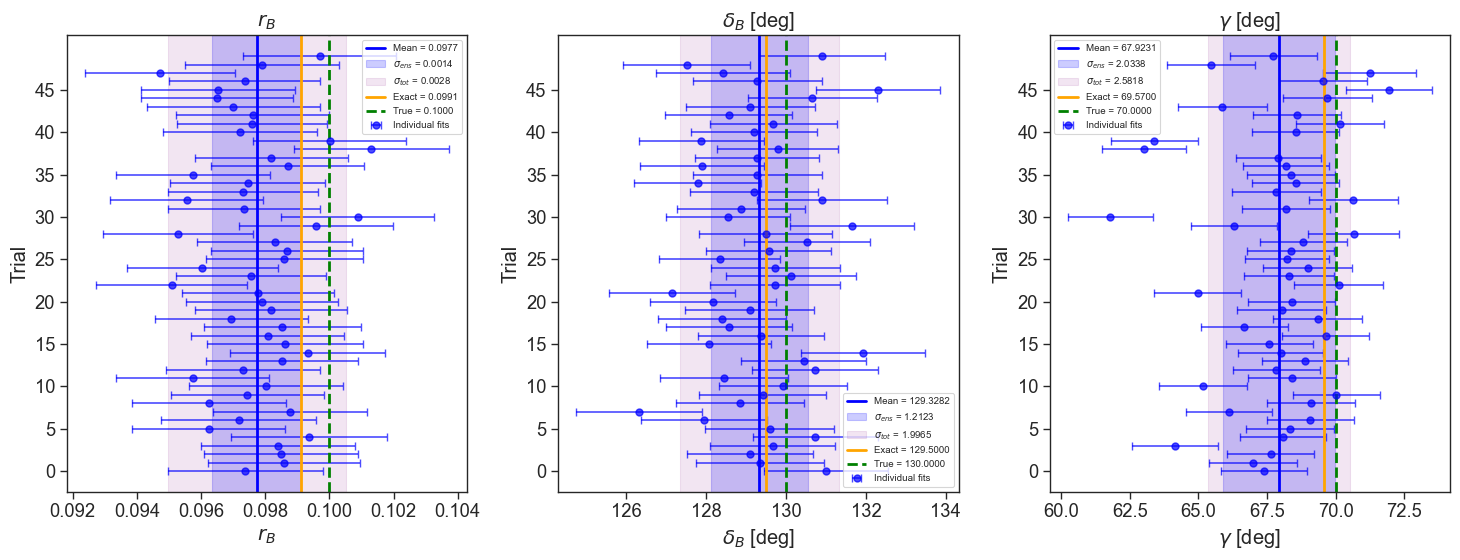


Parameter          Mean      σ_fit      σ_ens      σ_tot       True
rB               0.0977     0.0024     0.0014     0.0028     0.1000
delta [°]      129.3282     1.5863     1.2123     1.9965   130.0000
gamma [°]       67.9231     1.5905     2.0338     2.5818    70.0000


In [129]:
exact_rB = 0.0991
exact_delta = 129.5
exact_gamma = 69.57

# ============================================================================
# Plot results: stacked values with error bars
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

params = [
    (results_rB, errors_rB, exact_rB, r"$r_B$", true_rB),
    (results_delta, errors_delta, exact_delta, r"$\delta_B$ [deg]", true_deltaB * 180 / np.pi),
    (results_gamma, errors_gamma, exact_gamma, r"$\gamma$ [deg]", true_gamma * 180 / np.pi),
]

for ax, (vals, errs, exact_val, label, true_val) in zip(axes, params):
    # Compute errors
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    mean_val = vals.mean()
    
    # Y positions for stacking points
    y_pos = np.arange(len(vals))
    
    # Plot individual fits with their Minuit errors (horizontal error bars)
    ax.errorbar(vals, y_pos, xerr=errs, fmt='o', color='blue', 
                capsize=3, markersize=5, alpha=0.7, label='Individual fits')
    
    # Mean with ensemble spread
    ax.axvline(mean_val, color='blue', linestyle='-', linewidth=2, 
               label=f'Mean = {mean_val:.4f}')
    ax.axvspan(mean_val - sigma_ensemble, mean_val + sigma_ensemble, 
               alpha=0.2, color='blue', label=f'$\\sigma_{{ens}}$ = {sigma_ensemble:.4f}')
    
    # Total error band
    ax.axvspan(mean_val - sigma_total, mean_val + sigma_total, 
               alpha=0.1, color='purple', label=f'$\\sigma_{{tot}}$ = {sigma_total:.4f}')
    
    # Exact result
    ax.axvline(exact_val, color='orange', linestyle='-', linewidth=2, 
               label=f'Exact = {exact_val:.4f}')
    
    # True value
    ax.axvline(true_val, color='green', linestyle='--', linewidth=2, 
               label=f'True = {true_val:.4f}')
    
    ax.set_ylabel('Trial')
    ax.set_xlabel(label)
    ax.set_title(label)
    ax.legend(fontsize=7, loc='best')
    ax.set_yticks(y_pos[::5])  # Show every 5th trial label

plt.tight_layout()
plt.savefig("ensemble_fit_results.png", dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print(f"\n{'='*70}")
print(f"{'Parameter':<12} {'Mean':>10} {'σ_fit':>10} {'σ_ens':>10} {'σ_tot':>10} {'True':>10}")
print(f"{'='*70}")
for name, vals, errs, true_val in [
    ("rB", results_rB, errors_rB, true_rB),
    ("delta [°]", results_delta, errors_delta, true_deltaB * 180 / np.pi),
    ("gamma [°]", results_gamma, errors_gamma, true_gamma * 180 / np.pi),
]:
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    print(f"{name:<12} {vals.mean():>10.4f} {sigma_fit:>10.4f} {sigma_ensemble:>10.4f} {sigma_total:>10.4f} {true_val:>10.4f}")


In [133]:
import random
import time
import glob
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# Ensemble fit: randomly select flows 25 times and compile results
# ============================================================================

n_trials = 50
n_blocks = 16
n_bins = 16
hidden_features = 128

# Get list of model files from each ensemble directory
def get_model_files(ensemble_dir):
    files = sorted(glob.glob(f"{ensemble_dir}/trial_seed*.pth"))
    return [f for f in files if not f.endswith('_best.pth')]

flavor_files = get_model_files("test_ensemble_2e6")
odd_files = get_model_files("test_ensemble_odd_1e6")
even_files = get_model_files("test_ensemble_even_1e6")

# Storage for results and errors
results_rB = []
results_delta = []
results_gamma = []
errors_rB = []
errors_delta = []
errors_gamma = []

for i in range(n_trials):
    print(f"\n{'='*60}")
    print(f"Trial {i+1}/{n_trials}")
    print(f"{'='*60}")
    
    # Randomly select one model from each ensemble
    flavor_path = random.choice(flavor_files)
    odd_path = random.choice(odd_files)
    even_path = random.choice(even_files)
    
    print(f"  flavor: {flavor_path}")
    print(f"  odd:    {odd_path}")
    print(f"  even:   {even_path}")
    
    # Load flavor flow
    flow = create_flow(num_flows=12, hidden_features=hidden_features, num_bins=24)
    flow.load_state_dict(torch.load(flavor_path, map_location=device), strict=False)
    flow.to(device)
    flow.eval()
    
    # Load odd flow
    flow_odd = create_flow(num_flows=n_bins, hidden_features=hidden_features, num_bins=n_bins)
    flow_odd.load_state_dict(torch.load(odd_path, map_location=device), strict=False)
    flow_odd.to(device)
    flow_odd.eval()
    
    # Load even flow
    flow_even = create_flow(num_flows=n_blocks, hidden_features=hidden_features, num_bins=n_bins)
    flow_even.load_state_dict(torch.load(even_path, map_location=device), strict=False)
    flow_even.to(device)
    flow_even.eval()
    
    # Run the fit
    m = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
        dataM_sdp=dataM_sdp,
        dataP_sdp=dataP_sdp,
        mcM_sdp=mcM_sdp,
        mcP_sdp=mcP_sdp,
        flow_flavor=flow,
        flow_even=flow_even,
        flow_odd=flow_odd,
        dkpp_model=dkpp,
        true_rB=true_rB,
        true_deltaB=true_deltaB * 180 / np.pi,
        true_gamma=true_gamma * 180 / np.pi,
        sdp_obj=sdp_obj,
        idx=(1, 2, 3),
        initial_scale=0.2,
        delta_offset=30,
        gamma_offset=30,
        device=device,
        Gamma_minus=gamma_m,
        Gamma_plus=gamma_p,
    )
    
    # Store values and errors
    results_rB.append(m.values['rB'])
    results_delta.append(m.values['delta'])
    results_gamma.append(m.values['gamma'])
    errors_rB.append(m.errors['rB'])
    errors_delta.append(m.errors['delta'])
    errors_gamma.append(m.errors['gamma'])

results_rB = np.array(results_rB)
results_delta = np.array(results_delta)
results_gamma = np.array(results_gamma)
errors_rB = np.array(errors_rB)
errors_delta = np.array(errors_delta)
errors_gamma = np.array(errors_gamma)

# ============================================================================
# Compute errors
# ============================================================================
print(f"\n{'='*60}")
print("SUMMARY")
print(f"{'='*60}")

for name, vals, errs, true_val in [
    ("rB", results_rB, errors_rB, true_rB),
    ("delta", results_delta, errors_delta, true_deltaB * 180 / np.pi),
    ("gamma", results_gamma, errors_gamma, true_gamma * 180 / np.pi),
]:
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    unit = "°" if name != "rB" else ""
    print(f"{name}: mean = {vals.mean():.4f}{unit}, "
          f"σ_ens = {sigma_ensemble:.4f}, σ_fit = {sigma_fit:.4f}, "
          f"σ_tot = {sigma_total:.4f}  (true = {true_val:.4f})")



Trial 1/50
  flavor: test_ensemble_2e6\trial_seed3.pth
  odd:    test_ensemble_odd_1e6\trial_seed20.pth
  even:   test_ensemble_even_1e6\trial_seed11.pth
49840 49544
Total fit time: 1.41s

rB    = 0.1001 ± 0.0024
delta = 129.79° ± 1.56°
gamma = 66.65° ± 1.56°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 2/50
  flavor: test_ensemble_2e6\trial_seed2.pth
  odd:    test_ensemble_odd_1e6\trial_seed23.pth
  even:   test_ensemble_even_1e6\trial_seed16.pth
49751 49568
Total fit time: 1.31s

rB    = 0.0982 ± 0.0024
delta = 130.10° ± 1.59°
gamma = 67.60° ± 1.59°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 3/50
  flavor: test_ensemble_2e6\trial_seed21.pth
  odd:    test_ensemble_odd_1e6\trial_seed5.pth
  even:   test_ensemble_even_1e6\trial_seed14.pth
49626 48771
Total fit time: 1.32s

rB    = 0.1004 ± 0.0024
delta = 127.46° ± 1.54°
gamma = 65.88° ± 1.55°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 4/50
  flavor: test_ensemble_2e6\trial_seed12.pth
  odd:    test_e

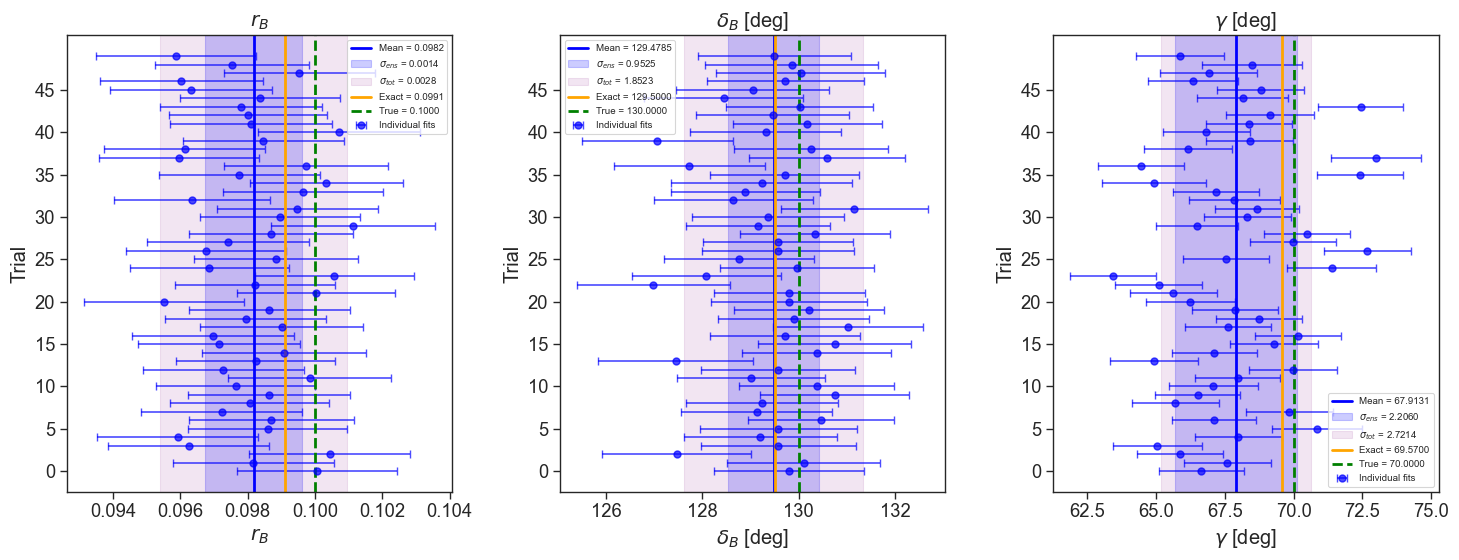


Parameter          Mean      σ_fit      σ_ens      σ_tot       True
rB               0.0982     0.0024     0.0014     0.0028     0.1000
delta [°]      129.4785     1.5886     0.9525     1.8523   130.0000
gamma [°]       67.9131     1.5936     2.2060     2.7214    70.0000


In [134]:
exact_rB = 0.0991
exact_delta = 129.5
exact_gamma = 69.57

# ============================================================================
# Plot results: stacked values with error bars
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

params = [
    (results_rB, errors_rB, exact_rB, r"$r_B$", true_rB),
    (results_delta, errors_delta, exact_delta, r"$\delta_B$ [deg]", true_deltaB * 180 / np.pi),
    (results_gamma, errors_gamma, exact_gamma, r"$\gamma$ [deg]", true_gamma * 180 / np.pi),
]

for ax, (vals, errs, exact_val, label, true_val) in zip(axes, params):
    # Compute errors
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    mean_val = vals.mean()
    
    # Y positions for stacking points
    y_pos = np.arange(len(vals))
    
    # Plot individual fits with their Minuit errors (horizontal error bars)
    ax.errorbar(vals, y_pos, xerr=errs, fmt='o', color='blue', 
                capsize=3, markersize=5, alpha=0.7, label='Individual fits')
    
    # Mean with ensemble spread
    ax.axvline(mean_val, color='blue', linestyle='-', linewidth=2, 
               label=f'Mean = {mean_val:.4f}')
    ax.axvspan(mean_val - sigma_ensemble, mean_val + sigma_ensemble, 
               alpha=0.2, color='blue', label=f'$\\sigma_{{ens}}$ = {sigma_ensemble:.4f}')
    
    # Total error band
    ax.axvspan(mean_val - sigma_total, mean_val + sigma_total, 
               alpha=0.1, color='purple', label=f'$\\sigma_{{tot}}$ = {sigma_total:.4f}')
    
    # Exact result
    ax.axvline(exact_val, color='orange', linestyle='-', linewidth=2, 
               label=f'Exact = {exact_val:.4f}')
    
    # True value
    ax.axvline(true_val, color='green', linestyle='--', linewidth=2, 
               label=f'True = {true_val:.4f}')
    
    ax.set_ylabel('Trial')
    ax.set_xlabel(label)
    ax.set_title(label)
    ax.legend(fontsize=7, loc='best')
    ax.set_yticks(y_pos[::5])  # Show every 5th trial label

plt.tight_layout()
plt.savefig("ensemble_fit_results.png", dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print(f"\n{'='*70}")
print(f"{'Parameter':<12} {'Mean':>10} {'σ_fit':>10} {'σ_ens':>10} {'σ_tot':>10} {'True':>10}")
print(f"{'='*70}")
for name, vals, errs, true_val in [
    ("rB", results_rB, errors_rB, true_rB),
    ("delta [°]", results_delta, errors_delta, true_deltaB * 180 / np.pi),
    ("gamma [°]", results_gamma, errors_gamma, true_gamma * 180 / np.pi),
]:
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    print(f"{name:<12} {vals.mean():>10.4f} {sigma_fit:>10.4f} {sigma_ensemble:>10.4f} {sigma_total:>10.4f} {true_val:>10.4f}")


In [138]:
import random
import time
import glob
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# Ensemble fit: randomly select flows 25 times and compile results
# ============================================================================

n_trials = 50
n_blocks = 16
n_bins = 16
hidden_features = 128

# Get list of model files from each ensemble directory
def get_model_files(ensemble_dir):
    files = sorted(glob.glob(f"{ensemble_dir}/trial_seed*.pth"))
    return [f for f in files if not f.endswith('_best.pth')]

flavor_files = get_model_files("test_ensemble_2e6")
odd_files = get_model_files("test_ensemble_odd_1e6")
even_files = get_model_files("test_ensemble_even_1e6")

# Storage for results and errors
results_rB = []
results_delta = []
results_gamma = []
errors_rB = []
errors_delta = []
errors_gamma = []

for i in range(n_trials):
    print(f"\n{'='*60}")
    print(f"Trial {i+1}/{n_trials}")
    print(f"{'='*60}")
    
    # Randomly select one model from each ensemble
    flavor_path = random.choice(flavor_files)
    odd_path = random.choice(odd_files)
    even_path = random.choice(even_files)
    
    print(f"  flavor: {flavor_path}")
    print(f"  odd:    {odd_path}")
    print(f"  even:   {even_path}")
    
    # Load flavor flow
    flow = create_flow(num_flows=12, hidden_features=hidden_features, num_bins=24)
    flow.load_state_dict(torch.load(flavor_path, map_location=device), strict=False)
    flow.to(device)
    flow.eval()
    
    # Load odd flow
    flow_odd = create_flow(num_flows=n_bins, hidden_features=hidden_features, num_bins=n_bins)
    flow_odd.load_state_dict(torch.load(odd_path, map_location=device), strict=False)
    flow_odd.to(device)
    flow_odd.eval()
    
    # Load even flow
    flow_even = create_flow(num_flows=n_blocks, hidden_features=hidden_features, num_bins=n_bins)
    flow_even.load_state_dict(torch.load(even_path, map_location=device), strict=False)
    flow_even.to(device)
    flow_even.eval()
    
    # Run the fit
    m = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
        dataM_sdp=dataM_sdp,
        dataP_sdp=dataP_sdp,
        mcM_sdp=mcM_sdp,
        mcP_sdp=mcP_sdp,
        flow_flavor=flow,
        flow_even=flow_even,
        flow_odd=flow_odd,
        dkpp_model=dkpp,
        true_rB=true_rB,
        true_deltaB=true_deltaB * 180 / np.pi,
        true_gamma=true_gamma * 180 / np.pi,
        sdp_obj=sdp_obj,
        idx=(1, 2, 3),
        initial_scale=0.2,
        delta_offset=30,
        gamma_offset=30,
        device=device,
        Gamma_minus=gamma_m,
        Gamma_plus=gamma_p,
    )
    
    # Store values and errors
    results_rB.append(m.values['rB'])
    results_delta.append(m.values['delta'])
    results_gamma.append(m.values['gamma'])
    errors_rB.append(m.errors['rB'])
    errors_delta.append(m.errors['delta'])
    errors_gamma.append(m.errors['gamma'])

results_rB = np.array(results_rB)
results_delta = np.array(results_delta)
results_gamma = np.array(results_gamma)
errors_rB = np.array(errors_rB)
errors_delta = np.array(errors_delta)
errors_gamma = np.array(errors_gamma)

# ============================================================================
# Compute errors
# ============================================================================
print(f"\n{'='*60}")
print("SUMMARY")
print(f"{'='*60}")

for name, vals, errs, true_val in [
    ("rB", results_rB, errors_rB, true_rB),
    ("delta", results_delta, errors_delta, true_deltaB * 180 / np.pi),
    ("gamma", results_gamma, errors_gamma, true_gamma * 180 / np.pi),
]:
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    unit = "°" if name != "rB" else ""
    print(f"{name}: mean = {vals.mean():.4f}{unit}, "
          f"σ_ens = {sigma_ensemble:.4f}, σ_fit = {sigma_fit:.4f}, "
          f"σ_tot = {sigma_total:.4f}  (true = {true_val:.4f})")



Trial 1/50
  flavor: test_ensemble_2e6\trial_seed20.pth
  odd:    test_ensemble_odd_1e6\trial_seed9.pth
  even:   test_ensemble_even_1e6\trial_seed3.pth
49558 49115
Total fit time: 1.38s

rB    = 0.1016 ± 0.0024
delta = 127.24° ± 1.54°
gamma = 63.35° ± 1.54°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 2/50
  flavor: test_ensemble_2e6\trial_seed10.pth
  odd:    test_ensemble_odd_1e6\trial_seed6.pth
  even:   test_ensemble_even_1e6\trial_seed1.pth
49430 49726
Total fit time: 1.38s

rB    = 0.0988 ± 0.0024
delta = 131.05° ± 1.60°
gamma = 68.23° ± 1.61°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 3/50
  flavor: test_ensemble_2e6\trial_seed6.pth
  odd:    test_ensemble_odd_1e6\trial_seed10.pth
  even:   test_ensemble_even_1e6\trial_seed8.pth
49436 49841
Total fit time: 1.63s

rB    = 0.0987 ± 0.0024
delta = 129.45° ± 1.57°
gamma = 68.04° ± 1.56°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 4/50
  flavor: test_ensemble_2e6\trial_seed4.pth
  odd:    test_ensem

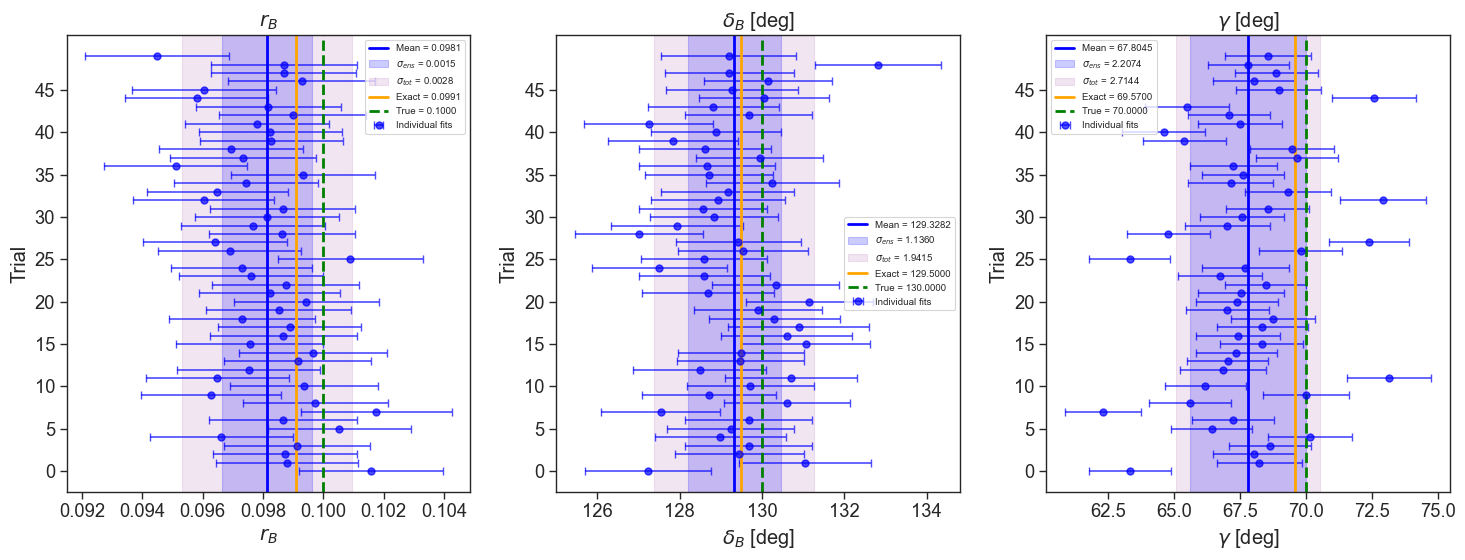


Parameter          Mean      σ_fit      σ_ens      σ_tot       True
rB               0.0981     0.0024     0.0015     0.0028     0.1000
delta [°]      129.3282     1.5744     1.1360     1.9415   130.0000
gamma [°]       67.8045     1.5796     2.2074     2.7144    70.0000


In [139]:
exact_rB = 0.0991
exact_delta = 129.5
exact_gamma = 69.57

# ============================================================================
# Plot results: stacked values with error bars
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

params = [
    (results_rB, errors_rB, exact_rB, r"$r_B$", true_rB),
    (results_delta, errors_delta, exact_delta, r"$\delta_B$ [deg]", true_deltaB * 180 / np.pi),
    (results_gamma, errors_gamma, exact_gamma, r"$\gamma$ [deg]", true_gamma * 180 / np.pi),
]

for ax, (vals, errs, exact_val, label, true_val) in zip(axes, params):
    # Compute errors
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    mean_val = vals.mean()
    
    # Y positions for stacking points
    y_pos = np.arange(len(vals))
    
    # Plot individual fits with their Minuit errors (horizontal error bars)
    ax.errorbar(vals, y_pos, xerr=errs, fmt='o', color='blue', 
                capsize=3, markersize=5, alpha=0.7, label='Individual fits')
    
    # Mean with ensemble spread
    ax.axvline(mean_val, color='blue', linestyle='-', linewidth=2, 
               label=f'Mean = {mean_val:.4f}')
    ax.axvspan(mean_val - sigma_ensemble, mean_val + sigma_ensemble, 
               alpha=0.2, color='blue', label=f'$\\sigma_{{ens}}$ = {sigma_ensemble:.4f}')
    
    # Total error band
    ax.axvspan(mean_val - sigma_total, mean_val + sigma_total, 
               alpha=0.1, color='purple', label=f'$\\sigma_{{tot}}$ = {sigma_total:.4f}')
    
    # Exact result
    ax.axvline(exact_val, color='orange', linestyle='-', linewidth=2, 
               label=f'Exact = {exact_val:.4f}')
    
    # True value
    ax.axvline(true_val, color='green', linestyle='--', linewidth=2, 
               label=f'True = {true_val:.4f}')
    
    ax.set_ylabel('Trial')
    ax.set_xlabel(label)
    ax.set_title(label)
    ax.legend(fontsize=7, loc='best')
    ax.set_yticks(y_pos[::5])  # Show every 5th trial label

plt.tight_layout()
plt.savefig("ensemble_fit_results.png", dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print(f"\n{'='*70}")
print(f"{'Parameter':<12} {'Mean':>10} {'σ_fit':>10} {'σ_ens':>10} {'σ_tot':>10} {'True':>10}")
print(f"{'='*70}")
for name, vals, errs, true_val in [
    ("rB", results_rB, errors_rB, true_rB),
    ("delta [°]", results_delta, errors_delta, true_deltaB * 180 / np.pi),
    ("gamma [°]", results_gamma, errors_gamma, true_gamma * 180 / np.pi),
]:
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    print(f"{name:<12} {vals.mean():>10.4f} {sigma_fit:>10.4f} {sigma_ensemble:>10.4f} {sigma_total:>10.4f} {true_val:>10.4f}")


In [135]:
import random
import time
import glob
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# Ensemble fit: randomly select flows 25 times and compile results
# ============================================================================

n_trials = 50
n_blocks = 16
n_bins = 16
hidden_features = 128

# Get list of model files from each ensemble directory
def get_model_files(ensemble_dir):
    files = sorted(glob.glob(f"{ensemble_dir}/trial_seed*.pth"))
    return [f for f in files if not f.endswith('_best.pth')]

flavor_files = get_model_files("test_ensemble_2e6")
odd_files = get_model_files("test_ensemble_odd_2e6")
even_files = get_model_files("test_ensemble_even_2e6")

# Storage for results and errors
results_rB = []
results_delta = []
results_gamma = []
errors_rB = []
errors_delta = []
errors_gamma = []

for i in range(n_trials):
    print(f"\n{'='*60}")
    print(f"Trial {i+1}/{n_trials}")
    print(f"{'='*60}")
    
    # Randomly select one model from each ensemble
    flavor_path = random.choice(flavor_files)
    odd_path = random.choice(odd_files)
    even_path = random.choice(even_files)
    
    print(f"  flavor: {flavor_path}")
    print(f"  odd:    {odd_path}")
    print(f"  even:   {even_path}")
    
    # Load flavor flow
    flow = create_flow(num_flows=12, hidden_features=hidden_features, num_bins=24)
    flow.load_state_dict(torch.load(flavor_path, map_location=device), strict=False)
    flow.to(device)
    flow.eval()
    
    # Load odd flow
    flow_odd = create_flow(num_flows=12, hidden_features=hidden_features, num_bins=24)
    flow_odd.load_state_dict(torch.load(odd_path, map_location=device), strict=False)
    flow_odd.to(device)
    flow_odd.eval()
    
    # Load even flow
    flow_even = create_flow(num_flows=12, hidden_features=hidden_features, num_bins=24)
    flow_even.load_state_dict(torch.load(even_path, map_location=device), strict=False)
    flow_even.to(device)
    flow_even.eval()
    
    # Run the fit
    m = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
        dataM_sdp=dataM_sdp,
        dataP_sdp=dataP_sdp,
        mcM_sdp=mcM_sdp,
        mcP_sdp=mcP_sdp,
        flow_flavor=flow,
        flow_even=flow_even,
        flow_odd=flow_odd,
        dkpp_model=dkpp,
        true_rB=true_rB,
        true_deltaB=true_deltaB * 180 / np.pi,
        true_gamma=true_gamma * 180 / np.pi,
        sdp_obj=sdp_obj,
        idx=(1, 2, 3),
        initial_scale=0.2,
        delta_offset=30,
        gamma_offset=30,
        device=device,
        Gamma_minus=gamma_m,
        Gamma_plus=gamma_p,
    )
    
    # Store values and errors
    results_rB.append(m.values['rB'])
    results_delta.append(m.values['delta'])
    results_gamma.append(m.values['gamma'])
    errors_rB.append(m.errors['rB'])
    errors_delta.append(m.errors['delta'])
    errors_gamma.append(m.errors['gamma'])

results_rB = np.array(results_rB)
results_delta = np.array(results_delta)
results_gamma = np.array(results_gamma)
errors_rB = np.array(errors_rB)
errors_delta = np.array(errors_delta)
errors_gamma = np.array(errors_gamma)

# ============================================================================
# Compute errors
# ============================================================================
print(f"\n{'='*60}")
print("SUMMARY")
print(f"{'='*60}")

for name, vals, errs, true_val in [
    ("rB", results_rB, errors_rB, true_rB),
    ("delta", results_delta, errors_delta, true_deltaB * 180 / np.pi),
    ("gamma", results_gamma, errors_gamma, true_gamma * 180 / np.pi),
]:
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    unit = "°" if name != "rB" else ""
    print(f"{name}: mean = {vals.mean():.4f}{unit}, "
          f"σ_ens = {sigma_ensemble:.4f}, σ_fit = {sigma_fit:.4f}, "
          f"σ_tot = {sigma_total:.4f}  (true = {true_val:.4f})")



Trial 1/50
  flavor: test_ensemble_2e6\trial_seed8.pth
  odd:    test_ensemble_odd_2e6\trial_seed7.pth
  even:   test_ensemble_even_2e6\trial_seed1.pth
49776 49830
Total fit time: 1.34s

rB    = 0.0956 ± 0.0024
delta = 129.75° ± 1.59°
gamma = 68.66° ± 1.59°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 2/50
  flavor: test_ensemble_2e6\trial_seed18.pth
  odd:    test_ensemble_odd_2e6\trial_seed3.pth
  even:   test_ensemble_even_2e6\trial_seed11.pth
49246 49607
Total fit time: 1.39s

rB    = 0.0970 ± 0.0024
delta = 128.54° ± 1.60°
gamma = 68.70° ± 1.61°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 3/50
  flavor: test_ensemble_2e6\trial_seed12.pth
  odd:    test_ensemble_odd_2e6\trial_seed11.pth
  even:   test_ensemble_even_2e6\trial_seed12.pth
49861 49628
Total fit time: 1.27s

rB    = 0.0979 ± 0.0024
delta = 128.70° ± 1.55°
gamma = 68.28° ± 1.55°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 4/50
  flavor: test_ensemble_2e6\trial_seed17.pth
  odd:    test_en

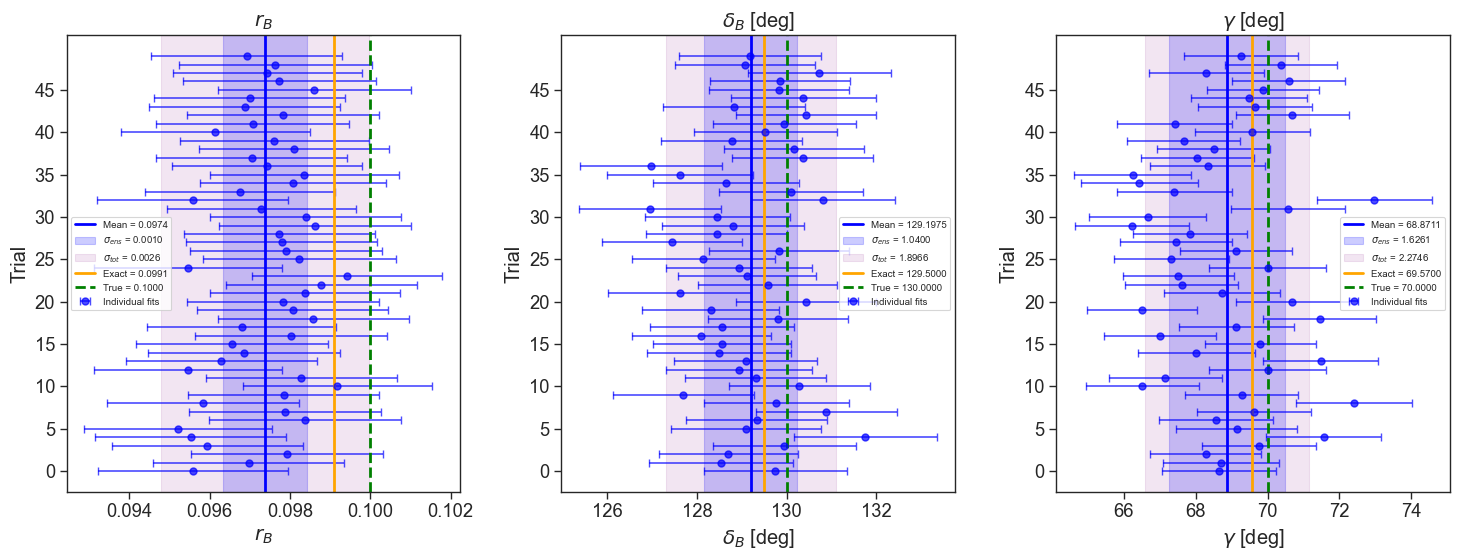


Parameter          Mean      σ_fit      σ_ens      σ_tot       True
rB               0.0974     0.0024     0.0010     0.0026     0.1000
delta [°]      129.1975     1.5861     1.0400     1.8966   130.0000
gamma [°]       68.8711     1.5904     1.6261     2.2746    70.0000


In [136]:
exact_rB = 0.0991
exact_delta = 129.5
exact_gamma = 69.57

# ============================================================================
# Plot results: stacked values with error bars
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

params = [
    (results_rB, errors_rB, exact_rB, r"$r_B$", true_rB),
    (results_delta, errors_delta, exact_delta, r"$\delta_B$ [deg]", true_deltaB * 180 / np.pi),
    (results_gamma, errors_gamma, exact_gamma, r"$\gamma$ [deg]", true_gamma * 180 / np.pi),
]

for ax, (vals, errs, exact_val, label, true_val) in zip(axes, params):
    # Compute errors
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    mean_val = vals.mean()
    
    # Y positions for stacking points
    y_pos = np.arange(len(vals))
    
    # Plot individual fits with their Minuit errors (horizontal error bars)
    ax.errorbar(vals, y_pos, xerr=errs, fmt='o', color='blue', 
                capsize=3, markersize=5, alpha=0.7, label='Individual fits')
    
    # Mean with ensemble spread
    ax.axvline(mean_val, color='blue', linestyle='-', linewidth=2, 
               label=f'Mean = {mean_val:.4f}')
    ax.axvspan(mean_val - sigma_ensemble, mean_val + sigma_ensemble, 
               alpha=0.2, color='blue', label=f'$\\sigma_{{ens}}$ = {sigma_ensemble:.4f}')
    
    # Total error band
    ax.axvspan(mean_val - sigma_total, mean_val + sigma_total, 
               alpha=0.1, color='purple', label=f'$\\sigma_{{tot}}$ = {sigma_total:.4f}')
    
    # Exact result
    ax.axvline(exact_val, color='orange', linestyle='-', linewidth=2, 
               label=f'Exact = {exact_val:.4f}')
    
    # True value
    ax.axvline(true_val, color='green', linestyle='--', linewidth=2, 
               label=f'True = {true_val:.4f}')
    
    ax.set_ylabel('Trial')
    ax.set_xlabel(label)
    ax.set_title(label)
    ax.legend(fontsize=7, loc='best')
    ax.set_yticks(y_pos[::5])  # Show every 5th trial label

plt.tight_layout()
plt.savefig("ensemble_fit_results.png", dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print(f"\n{'='*70}")
print(f"{'Parameter':<12} {'Mean':>10} {'σ_fit':>10} {'σ_ens':>10} {'σ_tot':>10} {'True':>10}")
print(f"{'='*70}")
for name, vals, errs, true_val in [
    ("rB", results_rB, errors_rB, true_rB),
    ("delta [°]", results_delta, errors_delta, true_deltaB * 180 / np.pi),
    ("gamma [°]", results_gamma, errors_gamma, true_gamma * 180 / np.pi),
]:
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    print(f"{name:<12} {vals.mean():>10.4f} {sigma_fit:>10.4f} {sigma_ensemble:>10.4f} {sigma_total:>10.4f} {true_val:>10.4f}")


In [141]:
import random
import time
import glob
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# Ensemble fit: randomly select flows 25 times and compile results
# ============================================================================

n_trials = 50
n_blocks = 16
n_bins = 16
hidden_features = 128

# Get list of model files from each ensemble directory
def get_model_files(ensemble_dir):
    files = sorted(glob.glob(f"{ensemble_dir}/trial_seed*.pth"))
    return [f for f in files if not f.endswith('_best.pth')]

flavor_files = get_model_files("test_ensemble_2e6")
odd_files = get_model_files("test_ensemble_odd_2e6")
even_files = get_model_files("test_ensemble_even_2e6")

# Storage for results and errors
results_rB = []
results_delta = []
results_gamma = []
errors_rB = []
errors_delta = []
errors_gamma = []

for i in range(n_trials):
    print(f"\n{'='*60}")
    print(f"Trial {i+1}/{n_trials}")
    print(f"{'='*60}")
    
    # Randomly select one model from each ensemble
    flavor_path = random.choice(flavor_files)
    odd_path = random.choice(odd_files)
    even_path = random.choice(even_files)
    
    print(f"  flavor: {flavor_path}")
    print(f"  odd:    {odd_path}")
    print(f"  even:   {even_path}")
    
    # Load flavor flow
    flow = create_flow(num_flows=12, hidden_features=hidden_features, num_bins=24)
    flow.load_state_dict(torch.load(flavor_path, map_location=device), strict=False)
    flow.to(device)
    flow.eval()
    
    # Load odd flow
    flow_odd = create_flow(num_flows=12, hidden_features=hidden_features, num_bins=24)
    flow_odd.load_state_dict(torch.load(odd_path, map_location=device), strict=False)
    flow_odd.to(device)
    flow_odd.eval()
    
    # Load even flow
    flow_even = create_flow(num_flows=12, hidden_features=hidden_features, num_bins=24)
    flow_even.load_state_dict(torch.load(even_path, map_location=device), strict=False)
    flow_even.to(device)
    flow_even.eval()
    
    # Run the fit
    m = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
        dataM_sdp=dataM_sdp,
        dataP_sdp=dataP_sdp,
        mcM_sdp=mcM_sdp,
        mcP_sdp=mcP_sdp,
        flow_flavor=flow,
        flow_even=flow_even,
        flow_odd=flow_odd,
        dkpp_model=dkpp,
        true_rB=true_rB,
        true_deltaB=true_deltaB * 180 / np.pi,
        true_gamma=true_gamma * 180 / np.pi,
        sdp_obj=sdp_obj,
        idx=(1, 2, 3),
        initial_scale=0.2,
        delta_offset=30,
        gamma_offset=30,
        device=device,
        Gamma_minus=gamma_m,
        Gamma_plus=gamma_p,
    )
    
    # Store values and errors
    results_rB.append(m.values['rB'])
    results_delta.append(m.values['delta'])
    results_gamma.append(m.values['gamma'])
    errors_rB.append(m.errors['rB'])
    errors_delta.append(m.errors['delta'])
    errors_gamma.append(m.errors['gamma'])

results_rB = np.array(results_rB)
results_delta = np.array(results_delta)
results_gamma = np.array(results_gamma)
errors_rB = np.array(errors_rB)
errors_delta = np.array(errors_delta)
errors_gamma = np.array(errors_gamma)

# ============================================================================
# Compute errors
# ============================================================================
print(f"\n{'='*60}")
print("SUMMARY")
print(f"{'='*60}")

for name, vals, errs, true_val in [
    ("rB", results_rB, errors_rB, true_rB),
    ("delta", results_delta, errors_delta, true_deltaB * 180 / np.pi),
    ("gamma", results_gamma, errors_gamma, true_gamma * 180 / np.pi),
]:
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    unit = "°" if name != "rB" else ""
    print(f"{name}: mean = {vals.mean():.4f}{unit}, "
          f"σ_ens = {sigma_ensemble:.4f}, σ_fit = {sigma_fit:.4f}, "
          f"σ_tot = {sigma_total:.4f}  (true = {true_val:.4f})")



Trial 1/50
  flavor: test_ensemble_2e6\trial_seed19.pth
  odd:    test_ensemble_odd_2e6\trial_seed3.pth
  even:   test_ensemble_even_2e6\trial_seed17.pth
49138 49631
Total fit time: 1.44s

rB    = 0.0976 ± 0.0024
delta = 129.57° ± 1.60°
gamma = 68.22° ± 1.61°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 2/50
  flavor: test_ensemble_2e6\trial_seed16.pth
  odd:    test_ensemble_odd_2e6\trial_seed15.pth
  even:   test_ensemble_even_2e6\trial_seed16.pth
49717 49676
Total fit time: 1.30s

rB    = 0.0963 ± 0.0024
delta = 128.14° ± 1.60°
gamma = 70.18° ± 1.61°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 3/50
  flavor: test_ensemble_2e6\trial_seed4.pth
  odd:    test_ensemble_odd_2e6\trial_seed2.pth
  even:   test_ensemble_even_2e6\trial_seed15.pth
48790 49717
Total fit time: 1.39s

rB    = 0.0964 ± 0.0024
delta = 128.41° ± 1.62°
gamma = 68.39° ± 1.63°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 4/50
  flavor: test_ensemble_2e6\trial_seed13.pth
  odd:    test_e

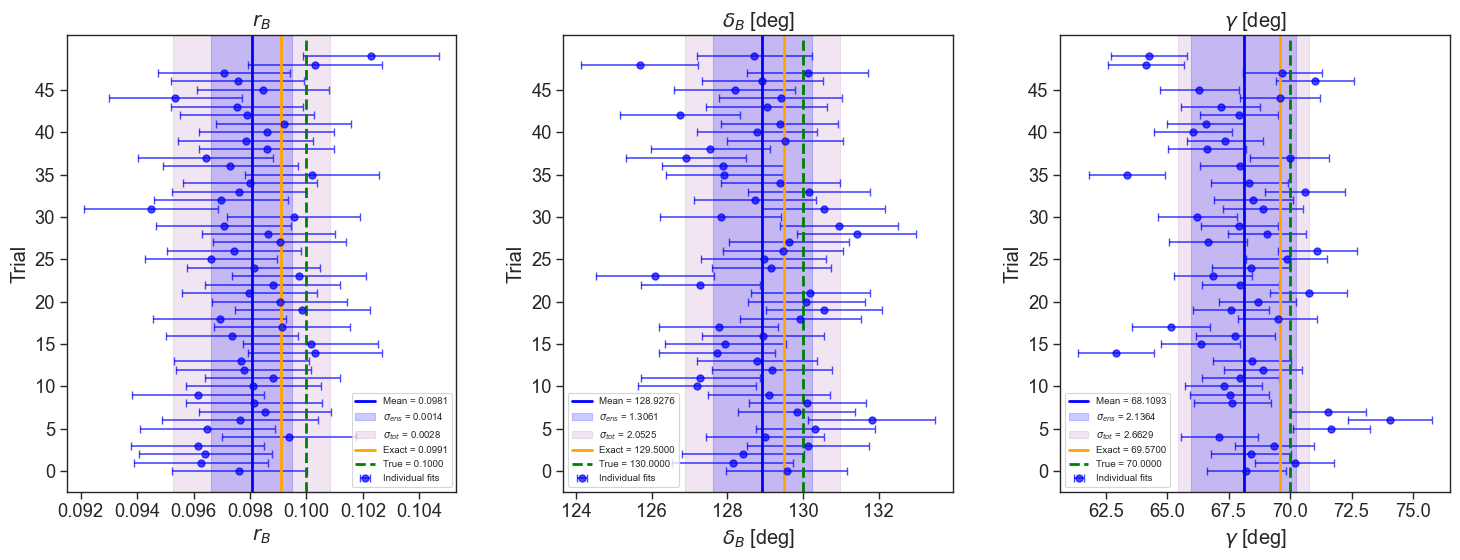


Parameter          Mean      σ_fit      σ_ens      σ_tot       True
rB               0.0981     0.0024     0.0014     0.0028     0.1000
delta [°]      128.9276     1.5833     1.3061     2.0525   130.0000
gamma [°]       68.1093     1.5896     2.1364     2.6629    70.0000


In [142]:
exact_rB = 0.0991
exact_delta = 129.5
exact_gamma = 69.57

# ============================================================================
# Plot results: stacked values with error bars
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

params = [
    (results_rB, errors_rB, exact_rB, r"$r_B$", true_rB),
    (results_delta, errors_delta, exact_delta, r"$\delta_B$ [deg]", true_deltaB * 180 / np.pi),
    (results_gamma, errors_gamma, exact_gamma, r"$\gamma$ [deg]", true_gamma * 180 / np.pi),
]

for ax, (vals, errs, exact_val, label, true_val) in zip(axes, params):
    # Compute errors
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    mean_val = vals.mean()
    
    # Y positions for stacking points
    y_pos = np.arange(len(vals))
    
    # Plot individual fits with their Minuit errors (horizontal error bars)
    ax.errorbar(vals, y_pos, xerr=errs, fmt='o', color='blue', 
                capsize=3, markersize=5, alpha=0.7, label='Individual fits')
    
    # Mean with ensemble spread
    ax.axvline(mean_val, color='blue', linestyle='-', linewidth=2, 
               label=f'Mean = {mean_val:.4f}')
    ax.axvspan(mean_val - sigma_ensemble, mean_val + sigma_ensemble, 
               alpha=0.2, color='blue', label=f'$\\sigma_{{ens}}$ = {sigma_ensemble:.4f}')
    
    # Total error band
    ax.axvspan(mean_val - sigma_total, mean_val + sigma_total, 
               alpha=0.1, color='purple', label=f'$\\sigma_{{tot}}$ = {sigma_total:.4f}')
    
    # Exact result
    ax.axvline(exact_val, color='orange', linestyle='-', linewidth=2, 
               label=f'Exact = {exact_val:.4f}')
    
    # True value
    ax.axvline(true_val, color='green', linestyle='--', linewidth=2, 
               label=f'True = {true_val:.4f}')
    
    ax.set_ylabel('Trial')
    ax.set_xlabel(label)
    ax.set_title(label)
    ax.legend(fontsize=7, loc='best')
    ax.set_yticks(y_pos[::5])  # Show every 5th trial label

plt.tight_layout()
plt.savefig("ensemble_fit_results.png", dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print(f"\n{'='*70}")
print(f"{'Parameter':<12} {'Mean':>10} {'σ_fit':>10} {'σ_ens':>10} {'σ_tot':>10} {'True':>10}")
print(f"{'='*70}")
for name, vals, errs, true_val in [
    ("rB", results_rB, errors_rB, true_rB),
    ("delta [°]", results_delta, errors_delta, true_deltaB * 180 / np.pi),
    ("gamma [°]", results_gamma, errors_gamma, true_gamma * 180 / np.pi),
]:
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    print(f"{name:<12} {vals.mean():>10.4f} {sigma_fit:>10.4f} {sigma_ensemble:>10.4f} {sigma_total:>10.4f} {true_val:>10.4f}")


In [31]:
fit_rB_delta_gamma_SDP_unbinned_jac_terms_exact(
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device
)

50000 50000
Total fit time: 1.34s

rB    = 0.0991 ± 0.0024
delta = 129.50° ± 1.58°
gamma = 69.57° ± 1.58°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.151e+04                  │              Nfcn = 92               │
│ EDM = 1.85e-05 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ rB    │  0.0991   │  0.0024   │            │            │    0    │    1    │       │
│ 1 │ delta │   129.5   │    1.6    │            │            │         │         │       │
│ 2 │ gamma │   69.6    │    1.6    │            │            │         │         │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬────────────────────────────┐
│       │       rB    delta    gamma │
├───────┼────────────────────────────┤
│    rB │ 5.63e-06   577e-6   586e-6 │
│ delta │   577e-6     2.51      0.8 │
│ gamma │   586e-6      0.8     2.51 │
└───────┴────────────────────────────┘

More data points 1e5

In [90]:
# ============================================================================
# Generate B+/B- samples with known physics parameters
# ============================================================================

# True physics parameters
true_gamma = 70.0 * np.pi / 180.0    # Weak phase (CKM angle) in radians
true_deltaB = 130.0 * np.pi / 180.0  # Strong phase in radians
true_rB = 0.4                         # Amplitude ratio

# Sample sizes
num_exp_events = 100000  # Experimental events per charge
num_mc_events = 1000000   # Monte Carlo events per charge (for efficiency)

print(f"Generating samples with:")
print(f"  gamma = {true_gamma * 180 / np.pi:.1f} degrees")
print(f"  delta_B = {true_deltaB * 180 / np.pi:.1f} degrees")
print(f"  r_B = {true_rB:.3f}")
print(f"\nSample sizes:")
print(f"  Experimental events per charge: {num_exp_events}")
print(f"  Monte Carlo events per charge: {num_mc_events}")

# Generate the samples
results = generate_BpBm_samples(
    rB=true_rB,
    deltaB=true_deltaB,
    gamma=true_gamma,
    num_exp_events=num_exp_events,
    num_mc_events=num_mc_events,
    SDP=sdp_obj,
    idx=(1, 2, 3)
)

np.savez("BpBm_samples_0.4_1e5.npz", **results)

# Extract generated samples
dataM_sdp = results["dataM_sdp"]  # B- experimental data in SDP
dataP_sdp = results["dataP_sdp"]  # B+ experimental data in SDP
mcM_sdp = results["mcM_sdp"]      # B- Monte Carlo in SDP
mcP_sdp = results["mcP_sdp"]      # B+ Monte Carlo in SDP

print(f"\nGenerated samples:")
print(f"  B- data: {len(dataM_sdp)} events")
print(f"  B+ data: {len(dataP_sdp)} events")
print(f"  B- MC: {len(mcM_sdp)} events")
print(f"  B+ MC: {len(mcP_sdp)} events")


Generating samples with:
  gamma = 70.0 degrees
  delta_B = 130.0 degrees
  r_B = 0.400

Sample sizes:
  Experimental events per charge: 100000
  Monte Carlo events per charge: 1000000
Generating B− data (DP)…
  done in 15.22s, shape=(100000, 2)
Generating B+ data (DP)…
  done in 11.71s, shape=(100000, 2)
Converting B− DP → SDP…
Converting B+ DP → SDP…
Generating MC for B− (SDP)…
  done in 0.01s, shape=(1000000, 2)
Generating MC for B+ (SDP)…
  done in 0.01s, shape=(1000000, 2)

Generated samples:
  B- data: 100000 events
  B+ data: 100000 events
  B- MC: 1000000 events
  B+ MC: 1000000 events


In [91]:
import random
import time
import glob
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# Ensemble fit: randomly select flows 25 times and compile results
# ============================================================================

n_trials = 50
n_blocks = 16
n_bins = 16
hidden_features = 128

# Get list of model files from each ensemble directory
def get_model_files(ensemble_dir):
    files = sorted(glob.glob(f"{ensemble_dir}/trial_seed*.pth"))
    return [f for f in files if not f.endswith('_best.pth')]

flavor_files = get_model_files("test_ensemble_2e6")
odd_files = get_model_files("test_ensemble_odd_1e6")
even_files = get_model_files("test_ensemble_even_1e6")

# Storage for results and errors
results_rB = []
results_delta = []
results_gamma = []
errors_rB = []
errors_delta = []
errors_gamma = []

for i in range(n_trials):
    print(f"\n{'='*60}")
    print(f"Trial {i+1}/{n_trials}")
    print(f"{'='*60}")
    
    # Randomly select one model from each ensemble
    flavor_path = random.choice(flavor_files)
    odd_path = random.choice(odd_files)
    even_path = random.choice(even_files)
    
    print(f"  flavor: {flavor_path}")
    print(f"  odd:    {odd_path}")
    print(f"  even:   {even_path}")
    
    # Load flavor flow
    flow = create_flow(num_flows=12, hidden_features=hidden_features, num_bins=24)
    flow.load_state_dict(torch.load(flavor_path, map_location=device), strict=False)
    flow.to(device)
    flow.eval()
    
    # Load odd flow
    flow_odd = create_flow(num_flows=n_bins, hidden_features=hidden_features, num_bins=n_bins)
    flow_odd.load_state_dict(torch.load(odd_path, map_location=device), strict=False)
    flow_odd.to(device)
    flow_odd.eval()
    
    # Load even flow
    flow_even = create_flow(num_flows=n_blocks, hidden_features=hidden_features, num_bins=n_bins)
    flow_even.load_state_dict(torch.load(even_path, map_location=device), strict=False)
    flow_even.to(device)
    flow_even.eval()
    
    # Run the fit
    m = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
        dataM_sdp=dataM_sdp,
        dataP_sdp=dataP_sdp,
        mcM_sdp=mcM_sdp,
        mcP_sdp=mcP_sdp,
        flow_flavor=flow,
        flow_even=flow_even,
        flow_odd=flow_odd,
        dkpp_model=dkpp,
        true_rB=true_rB,
        true_deltaB=true_deltaB * 180 / np.pi,
        true_gamma=true_gamma * 180 / np.pi,
        sdp_obj=sdp_obj,
        idx=(1, 2, 3),
        initial_scale=0.2,
        delta_offset=30,
        gamma_offset=30,
        device=device,
        Gamma_minus=gamma_m,
        Gamma_plus=gamma_p,
    )
    
    # Store values and errors
    results_rB.append(m.values['rB'])
    results_delta.append(m.values['delta'])
    results_gamma.append(m.values['gamma'])
    errors_rB.append(m.errors['rB'])
    errors_delta.append(m.errors['delta'])
    errors_gamma.append(m.errors['gamma'])

results_rB = np.array(results_rB)
results_delta = np.array(results_delta)
results_gamma = np.array(results_gamma)
errors_rB = np.array(errors_rB)
errors_delta = np.array(errors_delta)
errors_gamma = np.array(errors_gamma)

# ============================================================================
# Compute errors
# ============================================================================
print(f"\n{'='*60}")
print("SUMMARY")
print(f"{'='*60}")

for name, vals, errs, true_val in [
    ("rB", results_rB, errors_rB, true_rB),
    ("delta", results_delta, errors_delta, true_deltaB * 180 / np.pi),
    ("gamma", results_gamma, errors_gamma, true_gamma * 180 / np.pi),
]:
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    unit = "°" if name != "rB" else ""
    print(f"{name}: mean = {vals.mean():.4f}{unit}, "
          f"σ_ens = {sigma_ensemble:.4f}, σ_fit = {sigma_fit:.4f}, "
          f"σ_tot = {sigma_total:.4f}  (true = {true_val:.4f})")



Trial 1/50
  flavor: test_ensemble_2e6\trial_seed11.pth
  odd:    test_ensemble_odd_1e6\trial_seed9.pth
  even:   test_ensemble_even_1e6\trial_seed6.pth


c:\Users\chinh\anaconda3\Lib\site-packages\nflows\transforms\coupling.py:481: UserWarning: Inputs to the softmax are not scaled down: initialization might be bad.
  warnings.warn(


80893 79249
Total fit time: 2.90s

rB    = 0.4024 ± 0.0020
delta = 128.89° ± 0.42°
gamma = 69.33° ± 0.42°
(true rB=0.4000, true γ=70.00°, true δ=130.00°)

Trial 2/50
  flavor: test_ensemble_2e6\trial_seed16.pth
  odd:    test_ensemble_odd_1e6\trial_seed10.pth
  even:   test_ensemble_even_1e6\trial_seed11.pth
79422 78326
Total fit time: 2.22s

rB    = 0.4016 ± 0.0020
delta = 129.51° ± 0.42°
gamma = 68.77° ± 0.42°
(true rB=0.4000, true γ=70.00°, true δ=130.00°)

Trial 3/50
  flavor: test_ensemble_2e6\trial_seed1.pth
  odd:    test_ensemble_odd_1e6\trial_seed22.pth
  even:   test_ensemble_even_1e6\trial_seed16.pth
80306 81498
Total fit time: 2.13s

rB    = 0.3990 ± 0.0020
delta = 129.26° ± 0.42°
gamma = 68.99° ± 0.42°
(true rB=0.4000, true γ=70.00°, true δ=130.00°)

Trial 4/50
  flavor: test_ensemble_2e6\trial_seed24.pth
  odd:    test_ensemble_odd_1e6\trial_seed18.pth
  even:   test_ensemble_even_1e6\trial_seed24.pth
85524 85867
Total fit time: 2.67s

rB    = 0.3992 ± 0.0019
delta = 128.

In [92]:
fit_rB_delta_gamma_SDP_unbinned_jac_terms_exact(
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device
)

100000 100000
Total fit time: 2.87s

rB    = 0.4024 ± 0.0018
delta = 129.20° ± 0.40°
gamma = 69.54° ± 0.41°
(true rB=0.4000, true γ=70.00°, true δ=130.00°)


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 4.308e+04                  │              Nfcn = 106              │
│ EDM = 1.11e-07 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ rB    │  0.4024   │  0.0018   │            │            │    0    │    1    │       │
│ 1 │ delta │   129.2   │    0.4    │            │            │         │         │       │
│ 2 │ gamma │   69.5    │    0.4    │            │            │         │         │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬────────────────────────────┐
│       │       rB    delta    gamma │
├───────┼────────────────────────────┤
│    rB │ 3.09e-06  -6.8e-6 123.3e-6 │
│ delta │  -6.8e-6     0.16     0.08 │
│ gamma │ 123.3e-6     0.08    0.165 │
└───────┴────────────────────────────┘

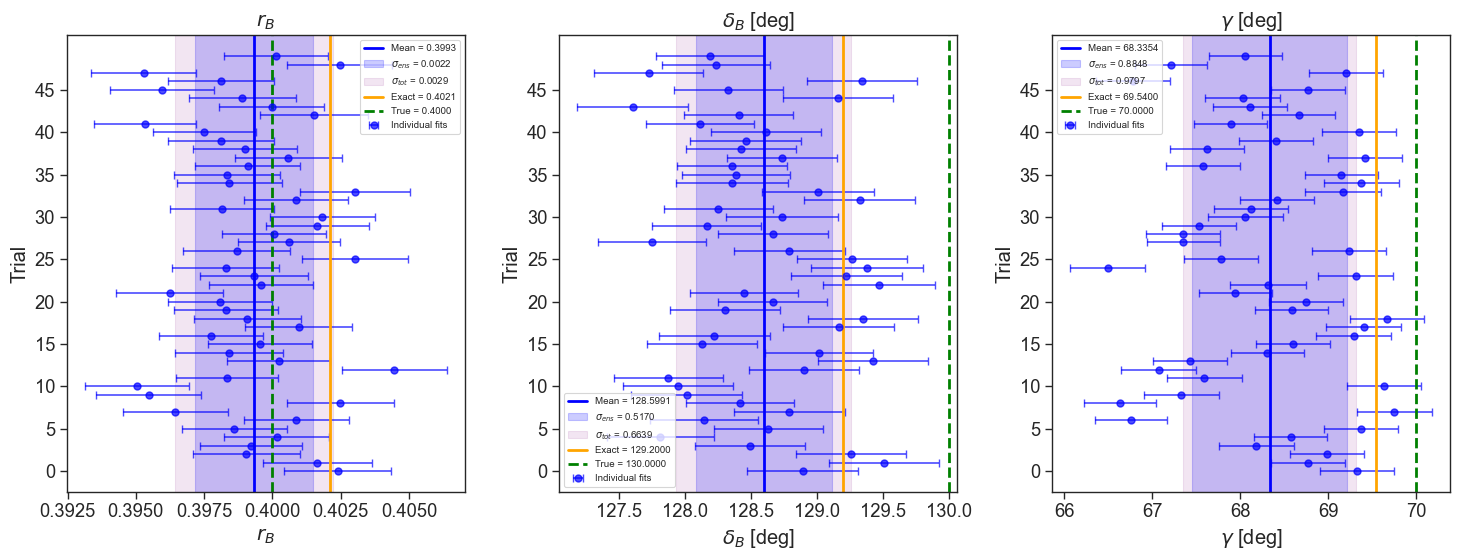


Parameter          Mean      σ_fit      σ_ens      σ_tot       True
rB               0.3993     0.0019     0.0022     0.0029     0.4000
delta [°]      128.5991     0.4165     0.5170     0.6639   130.0000
gamma [°]       68.3354     0.4206     0.8848     0.9797    70.0000


In [93]:
exact_rB = 0.4021
exact_delta = 129.20
exact_gamma = 69.54

# ============================================================================
# Plot results: stacked values with error bars
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

params = [
    (results_rB, errors_rB, exact_rB, r"$r_B$", true_rB),
    (results_delta, errors_delta, exact_delta, r"$\delta_B$ [deg]", true_deltaB * 180 / np.pi),
    (results_gamma, errors_gamma, exact_gamma, r"$\gamma$ [deg]", true_gamma * 180 / np.pi),
]

for ax, (vals, errs, exact_val, label, true_val) in zip(axes, params):
    # Compute errors
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    mean_val = vals.mean()
    
    # Y positions for stacking points
    y_pos = np.arange(len(vals))
    
    # Plot individual fits with their Minuit errors (horizontal error bars)
    ax.errorbar(vals, y_pos, xerr=errs, fmt='o', color='blue', 
                capsize=3, markersize=5, alpha=0.7, label='Individual fits')
    
    # Mean with ensemble spread
    ax.axvline(mean_val, color='blue', linestyle='-', linewidth=2, 
               label=f'Mean = {mean_val:.4f}')
    ax.axvspan(mean_val - sigma_ensemble, mean_val + sigma_ensemble, 
               alpha=0.2, color='blue', label=f'$\\sigma_{{ens}}$ = {sigma_ensemble:.4f}')
    
    # Total error band
    ax.axvspan(mean_val - sigma_total, mean_val + sigma_total, 
               alpha=0.1, color='purple', label=f'$\\sigma_{{tot}}$ = {sigma_total:.4f}')
    
    # Exact result
    ax.axvline(exact_val, color='orange', linestyle='-', linewidth=2, 
               label=f'Exact = {exact_val:.4f}')
    
    # True value
    ax.axvline(true_val, color='green', linestyle='--', linewidth=2, 
               label=f'True = {true_val:.4f}')
    
    ax.set_ylabel('Trial')
    ax.set_xlabel(label)
    ax.set_title(label)
    ax.legend(fontsize=7, loc='best')
    ax.set_yticks(y_pos[::5])  # Show every 5th trial label

plt.tight_layout()
plt.savefig("ensemble_fit_results.png", dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print(f"\n{'='*70}")
print(f"{'Parameter':<12} {'Mean':>10} {'σ_fit':>10} {'σ_ens':>10} {'σ_tot':>10} {'True':>10}")
print(f"{'='*70}")
for name, vals, errs, true_val in [
    ("rB", results_rB, errors_rB, true_rB),
    ("delta [°]", results_delta, errors_delta, true_deltaB * 180 / np.pi),
    ("gamma [°]", results_gamma, errors_gamma, true_gamma * 180 / np.pi),
]:
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    print(f"{name:<12} {vals.mean():>10.4f} {sigma_fit:>10.4f} {sigma_ensemble:>10.4f} {sigma_total:>10.4f} {true_val:>10.4f}")


In [90]:
fit_rB_delta_gamma_SDP_unbinned_jac_terms_exact(
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device
)

50000 50000
Total fit time: 0.46s

rB    = 0.0991 ± 0.0024
delta = 129.50° ± 1.58°
gamma = 69.57° ± 1.58°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.151e+04                  │              Nfcn = 92               │
│ EDM = 1.85e-05 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ rB    │  0.0991   │  0.0024   │            │            │    0    │    1    │       │
│ 1 │ delta │   129.5   │    1.6    │            │            │         │         │       │
│ 2 │ gamma │   69.6    │    1.6    │            │            │         │         │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬────────────────────────────┐
│       │       rB    delta    gamma │
├───────┼────────────────────────────┤
│    rB │ 5.63e-06   577e-6   586e-6 │
│ delta │   577e-6     2.51      0.8 │
│ gamma │   586e-6      0.8     2.51 │
└───────┴────────────────────────────┘

In [46]:
import numpy as np
import matplotlib.pyplot as plt

def profile_scan_1d(m, param, grid, *, fix=True, refit=True):
    """
    Profile scan of one parameter using Minuit.

    Returns:
      grid (array), d2ll (array), prof_vals (dict of profiled best fits)
    """
    mm = m  # use the fitted Minuit object

    # Ensure we're at the best-fit minimum
    if refit:
        mm.migrad()
        mm.hesse()

    fmin0 = mm.fmin.fval   # <-- iminuit v2: minimum NLL value
    prof_best = {k: [] for k in mm.parameters}
    d2ll = []

    # Store original fixed state / values
    orig_fixed = {p: mm.fixed[p] for p in mm.parameters}
    orig_vals  = {p: mm.values[p] for p in mm.parameters}

    for v in grid:
        mm.values[param] = float(v)
        mm.fixed[param] = fix

        # minimize over the other parameters (profile)
        mm.migrad()

        fmin = mm.fmin.fval  # <-- iminuit v2
        d2ll.append(2.0 * (fmin - fmin0))

        for p in mm.parameters:
            prof_best[p].append(mm.values[p])

    # Restore state
    for p in mm.parameters:
        mm.fixed[p] = orig_fixed[p]
        mm.values[p] = orig_vals[p]

    return np.array(grid), np.array(d2ll), prof_best


def plot_profile_peak(grid, d2ll, param_name, *, best_val=None):
    # Relative likelihood peaks at 1
    relL = np.exp(-0.5 * d2ll)

    plt.figure(figsize=(6,4), dpi=140)
    plt.plot(grid, relL)

    # Horizontal lines corresponding to 68% and 95% (1 dof) thresholds
    plt.axhline(np.exp(-0.5 * 1.0),  ls="--", label="68% (1 dof)")
    plt.axhline(np.exp(-0.5 * 3.84), ls="--", label="95% (1 dof)")

    if best_val is not None:
        plt.axvline(best_val, ls=":", label="best fit")

    plt.xlabel(param_name)
    plt.ylabel(r"$L/L_{\max}$")
    plt.ylim(0, 1.05)
    plt.legend()
    plt.tight_layout()
    plt.show()


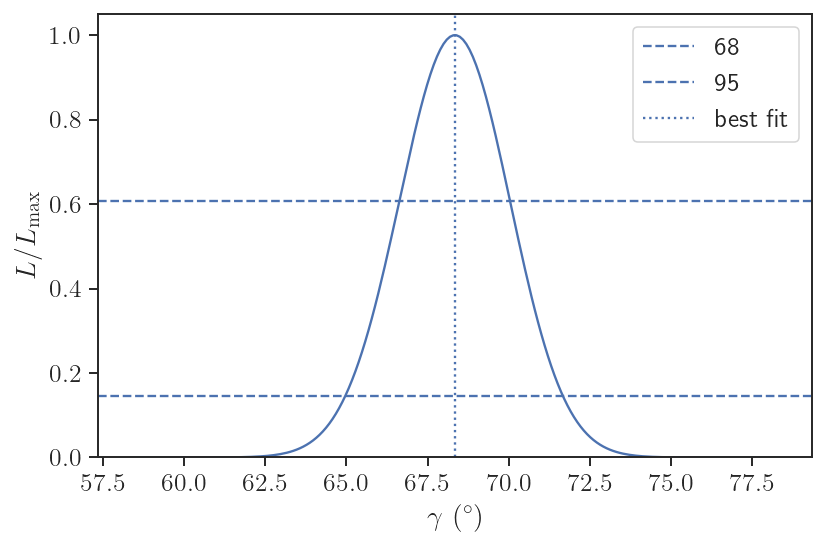

In [55]:
g0 = m.values["gamma"]
grid = np.linspace(g0 - 10, g0 + 10, 200)

grid, d2ll, prof = profile_scan_1d(m, "gamma", grid, fix=True)
plot_profile_peak(grid, d2ll, r"$\gamma\ (^\circ)$", best_val=g0)



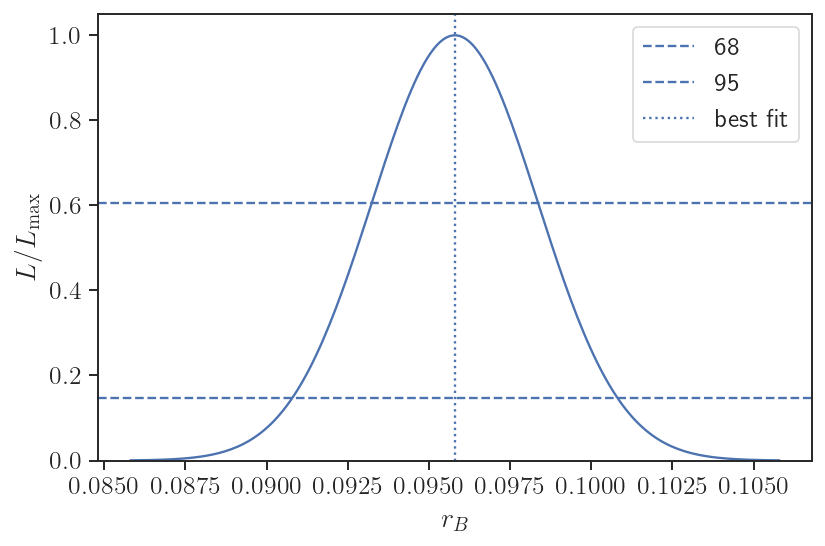

In [58]:
g0 = m.values["rB"]
grid = np.linspace(g0 - 0.01, g0 + 0.01, 200)

grid, d2ll, prof = profile_scan_1d(m, "rB", grid, fix=True)
plot_profile_peak(grid, d2ll, r"$r_B$", best_val=g0)


---
## 11. Profile Likelihood Scanning and Confidence Interval tools

Testing profile likelihood tools with simple example...
Best fit: x = 1.000, y = 2.000
x = 0.959 +1.132 -1.051
Saved test_profile_scan.png


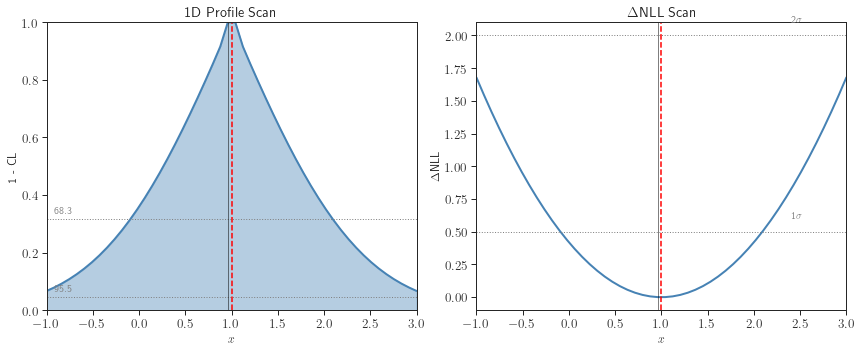

In [59]:
"""
Profile Likelihood Scanning and Confidence Interval Tools
==========================================================

This module provides functions to:
1. Perform 1D profile likelihood scans (like Figure 1 in the LHCb paper)
2. Perform 2D profile likelihood scans (contour plots)
3. Convert likelihood ratios to confidence levels
4. Plot 1-CL curves with proper 1σ/2σ bands

Works with iminuit Minuit objects after fitting.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from iminuit import Minuit
from typing import Tuple, Optional, Dict, List
import warnings


# ============================================================================
# THEORY: Converting Δ(NLL) to Confidence Levels
# ============================================================================
#
# For a profile likelihood ratio test statistic:
#   λ(θ) = L(θ, θ̂̂) / L(θ̂, θ̂̂)
#
# where θ̂̂ are the nuisance parameters that maximize L for fixed θ.
#
# Wilks' theorem states that -2 ln λ(θ) → χ²(n_dof) asymptotically,
# where n_dof = number of parameters of interest being tested.
#
# For 1D scans: Δχ² = 2 × ΔNLL follows χ²(1)
#   - 1σ (68.3% CL): Δχ² = 1.0
#   - 2σ (95.5% CL): Δχ² = 4.0
#   - 3σ (99.7% CL): Δχ² = 9.0
#
# For 2D scans: Δχ² follows χ²(2)
#   - 1σ (68.3% CL): Δχ² = 2.30
#   - 2σ (95.5% CL): Δχ² = 6.18
#   - 3σ (99.7% CL): Δχ² = 11.83
# ============================================================================


def delta_nll_to_confidence_level(delta_nll: np.ndarray, ndof: int = 1) -> np.ndarray:
    """
    Convert Δ(NLL) to confidence level (CL).
    
    Parameters
    ----------
    delta_nll : array-like
        Difference in negative log-likelihood from minimum: NLL - NLL_min
    ndof : int
        Number of degrees of freedom (1 for 1D scan, 2 for 2D scan)
    
    Returns
    -------
    cl : array
        Confidence level (between 0 and 1)
    
    Notes
    -----
    Uses Wilks' theorem: 2 × ΔNLL ~ χ²(ndof)
    CL = P(χ² < 2×ΔNLL) = CDF of χ² distribution
    """
    delta_chi2 = 2.0 * np.asarray(delta_nll)
    # CL is the probability that the true value lies within the region
    # where Δχ² is less than the observed value
    cl = stats.chi2.cdf(delta_chi2, df=ndof)
    return cl


def confidence_level_to_delta_nll(cl: float, ndof: int = 1) -> float:
    """
    Convert confidence level to Δ(NLL) threshold.
    
    Parameters
    ----------
    cl : float
        Confidence level (e.g., 0.683 for 1σ, 0.955 for 2σ)
    ndof : int
        Number of degrees of freedom
    
    Returns
    -------
    delta_nll : float
        The ΔNLL value corresponding to that confidence level
    """
    delta_chi2 = stats.chi2.ppf(cl, df=ndof)
    return delta_chi2 / 2.0


# Standard confidence levels
CL_1SIGMA = 0.6827  # 68.27%
CL_2SIGMA = 0.9545  # 95.45%
CL_3SIGMA = 0.9973  # 99.73%

# Corresponding Δχ² values for 1D
DELTA_CHI2_1D = {
    '1sigma': 1.0,
    '2sigma': 4.0,
    '3sigma': 9.0,
}

# Corresponding Δχ² values for 2D
DELTA_CHI2_2D = {
    '1sigma': 2.30,
    '2sigma': 6.18,
    '3sigma': 11.83,
}


# ============================================================================
# 1D Profile Likelihood Scan
# ============================================================================

def profile_likelihood_scan_1d(
    minuit: Minuit,
    param: str,
    bounds: Optional[Tuple[float, float]] = None,
    npoints: int = 100,
    subtract_min: bool = True
) -> Dict[str, np.ndarray]:
    """
    Perform a 1D profile likelihood scan using Minuit's mnprofile.
    
    Parameters
    ----------
    minuit : Minuit
        A Minuit object that has already been fitted (migrad called)
    param : str
        Name of the parameter to scan
    bounds : tuple, optional
        (min, max) range for the scan. If None, uses ±3σ from best fit
    npoints : int
        Number of points in the scan
    subtract_min : bool
        If True, subtract the minimum NLL value
    
    Returns
    -------
    dict with keys:
        'param_values': array of parameter values
        'nll': array of NLL values
        'delta_nll': array of ΔNLL (NLL - NLL_min)
        'cl': array of confidence levels
        'one_minus_cl': array of 1 - CL (for plotting like LHCb)
    """
    # Get best-fit value and error
    best_val = minuit.values[param]
    best_err = minuit.errors[param]
    
    # Set bounds if not provided
    if bounds is None:
        bounds = (best_val - 4*best_err, best_val + 4*best_err)
    
    # Use Minuit's built-in profile scan
    param_values, nll_values, success = minuit.mnprofile(
        param, 
        bound=bounds, 
        size=npoints,
        subtract_min=subtract_min
    )
    
    param_values = np.array(param_values)
    nll_values = np.array(nll_values)
    
    # If subtract_min is True, nll_values is already ΔNLL
    if subtract_min:
        delta_nll = nll_values
        nll_min = minuit.fval
    else:
        nll_min = nll_values.min()
        delta_nll = nll_values - nll_min
    
    # Convert to confidence level
    cl = delta_nll_to_confidence_level(delta_nll, ndof=1)
    
    return {
        'param_values': param_values,
        'nll': nll_values if not subtract_min else nll_values + nll_min,
        'delta_nll': delta_nll,
        'cl': cl,
        'one_minus_cl': 1.0 - cl,
        'best_fit': best_val,
        'best_err': best_err,
        'nll_min': nll_min
    }


def manual_profile_scan_1d(
    nll_func,
    minuit: Minuit,
    param: str,
    bounds: Tuple[float, float],
    npoints: int = 100,
    other_params: Optional[List[str]] = None
) -> Dict[str, np.ndarray]:
    """
    Manual 1D profile scan - useful when mnprofile has issues.
    
    For each fixed value of `param`, re-minimize over all other parameters.
    
    Parameters
    ----------
    nll_func : callable
        The negative log-likelihood function
    minuit : Minuit
        Fitted Minuit object (for initial values and limits)
    param : str
        Parameter to scan
    bounds : tuple
        (min, max) for the scan
    npoints : int
        Number of scan points
    other_params : list, optional
        List of other parameter names. If None, inferred from minuit.
    
    Returns
    -------
    dict : Same structure as profile_likelihood_scan_1d
    """
    if other_params is None:
        other_params = [p for p in minuit.parameters if p != param]
    
    param_values = np.linspace(bounds[0], bounds[1], npoints)
    nll_values = np.zeros(npoints)
    
    for i, pval in enumerate(param_values):
        # Create a wrapper that fixes the scan parameter
        def fixed_nll(**kwargs):
            kwargs[param] = pval
            return nll_func(**kwargs)
        
        # Set up minimizer for other parameters
        init_vals = {p: minuit.values[p] for p in other_params}
        m_temp = Minuit(fixed_nll, **init_vals)
        
        for p in other_params:
            m_temp.limits[p] = minuit.limits[p]
            m_temp.errors[p] = minuit.errors[p]
        
        m_temp.errordef = Minuit.LIKELIHOOD
        m_temp.migrad()
        
        nll_values[i] = m_temp.fval
    
    nll_min = nll_values.min()
    delta_nll = nll_values - nll_min
    cl = delta_nll_to_confidence_level(delta_nll, ndof=1)
    
    return {
        'param_values': param_values,
        'nll': nll_values,
        'delta_nll': delta_nll,
        'cl': cl,
        'one_minus_cl': 1.0 - cl,
        'best_fit': param_values[np.argmin(nll_values)],
        'nll_min': nll_min
    }


# ============================================================================
# 2D Profile Likelihood Scan (Contours)
# ============================================================================

def profile_likelihood_scan_2d(
    minuit: Minuit,
    param_x: str,
    param_y: str,
    bounds_x: Optional[Tuple[float, float]] = None,
    bounds_y: Optional[Tuple[float, float]] = None,
    npoints: int = 50
) -> Dict[str, np.ndarray]:
    """
    Perform a 2D profile likelihood scan.
    
    Parameters
    ----------
    minuit : Minuit
        Fitted Minuit object
    param_x, param_y : str
        Names of the two parameters to scan
    bounds_x, bounds_y : tuple, optional
        Scan ranges. If None, uses ±3σ from best fit
    npoints : int
        Number of points along each axis
    
    Returns
    -------
    dict with keys:
        'x_values', 'y_values': 1D arrays of scan points
        'X', 'Y': 2D meshgrid arrays
        'delta_nll': 2D array of ΔNLL values
        'delta_chi2': 2D array of Δχ² values
        'cl': 2D array of confidence levels
    """
    # Get best-fit values and errors
    best_x, err_x = minuit.values[param_x], minuit.errors[param_x]
    best_y, err_y = minuit.values[param_y], minuit.errors[param_y]
    
    if bounds_x is None:
        bounds_x = (best_x - 4*err_x, best_x + 4*err_x)
    if bounds_y is None:
        bounds_y = (best_y - 4*err_y, best_y + 4*err_y)
    
    # Use Minuit's contour method for accurate profiling
    # This returns the contour points, but we need the full grid
    # So we'll do a manual grid scan with profiling
    
    x_values = np.linspace(bounds_x[0], bounds_x[1], npoints)
    y_values = np.linspace(bounds_y[0], bounds_y[1], npoints)
    X, Y = np.meshgrid(x_values, y_values)
    
    delta_nll = np.zeros_like(X)
    nll_min = minuit.fval
    
    # Get the NLL function and other parameters
    other_params = [p for p in minuit.parameters if p not in (param_x, param_y)]
    
    print(f"Performing 2D scan over {param_x} and {param_y}...")
    for i in range(npoints):
        for j in range(npoints):
            # Fix param_x and param_y, profile over others
            minuit.fixed[param_x] = True
            minuit.fixed[param_y] = True
            minuit.values[param_x] = x_values[j]
            minuit.values[param_y] = y_values[i]
            
            # Re-minimize over free parameters
            if other_params:
                minuit.migrad()
            
            delta_nll[i, j] = minuit.fval - nll_min
    
    # Unfix parameters
    minuit.fixed[param_x] = False
    minuit.fixed[param_y] = False
    
    # Restore best-fit values
    minuit.values[param_x] = best_x
    minuit.values[param_y] = best_y
    minuit.migrad()
    
    delta_chi2 = 2.0 * delta_nll
    cl = delta_nll_to_confidence_level(delta_nll, ndof=2)
    
    return {
        'x_values': x_values,
        'y_values': y_values,
        'X': X,
        'Y': Y,
        'delta_nll': delta_nll,
        'delta_chi2': delta_chi2,
        'cl': cl,
        'best_x': best_x,
        'best_y': best_y
    }


def get_contour_from_minuit(
    minuit: Minuit,
    param_x: str,
    param_y: str,
    cl: float = CL_1SIGMA,
    npoints: int = 100
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Get contour points at a specific confidence level using Minuit's mncontour.
    
    This is more accurate than interpolating a grid scan.
    """
    # Convert CL to number of sigma for Minuit
    # Minuit's mncontour uses sigma as input
    nsigma = np.sqrt(stats.chi2.ppf(cl, df=2))
    
    x_contour, y_contour = minuit.mncontour(param_x, param_y, size=npoints)
    return np.array(x_contour), np.array(y_contour)


# ============================================================================
# Plotting Functions
# ============================================================================

def plot_1d_profile_scan(
    scan_result: Dict[str, np.ndarray],
    param_name: str,
    param_label: Optional[str] = None,
    true_value: Optional[float] = None,
    ax: Optional[plt.Axes] = None,
    plot_style: str = 'lhcb',  # 'lhcb' for 1-CL, 'delta_nll' for ΔNLL
    color: str = 'steelblue',
    fill: bool = True,
    show_intervals: bool = True
) -> plt.Axes:
    """
    Plot 1D profile likelihood scan results.
    
    Parameters
    ----------
    scan_result : dict
        Output from profile_likelihood_scan_1d
    param_name : str
        Parameter name (for title)
    param_label : str, optional
        LaTeX label for x-axis
    true_value : float, optional
        If provided, draw a vertical line at the true value
    ax : Axes, optional
        Matplotlib axes. If None, creates new figure
    plot_style : str
        'lhcb' for 1-CL plot (like Figure 1), 'delta_nll' for ΔNLL plot
    color : str
        Fill/line color
    fill : bool
        Whether to fill under the curve
    show_intervals : bool
        Whether to show 1σ/2σ horizontal lines
    
    Returns
    -------
    ax : Axes
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    
    x = scan_result['param_values']
    
    if plot_style == 'lhcb':
        y = scan_result['one_minus_cl']
        ylabel = '1 - CL'
        
        if fill:
            ax.fill_between(x, 0, y, alpha=0.4, color=color)
        ax.plot(x, y, color=color, lw=2)
        
        if show_intervals:
            # 1σ and 2σ lines
            ax.axhline(1 - CL_1SIGMA, color='gray', ls=':', lw=1, label='68.3%')
            ax.axhline(1 - CL_2SIGMA, color='gray', ls=':', lw=1, label='95.5%')
            ax.text(x.min() + 0.02*(x.max()-x.min()), 1 - CL_1SIGMA + 0.02, 
                    '68.3%', fontsize=10, color='gray')
            ax.text(x.min() + 0.02*(x.max()-x.min()), 1 - CL_2SIGMA + 0.02, 
                    '95.5%', fontsize=10, color='gray')
        
        ax.set_ylim(0, 1)
        
    else:  # delta_nll
        y = scan_result['delta_nll']
        ylabel = r'$\Delta$NLL'
        
        ax.plot(x, y, color=color, lw=2)
        
        if show_intervals:
            # 1σ and 2σ lines (ΔNLL = 0.5 and 2.0)
            ax.axhline(0.5, color='gray', ls=':', lw=1)
            ax.axhline(2.0, color='gray', ls=':', lw=1)
            ax.text(x.max() - 0.15*(x.max()-x.min()), 0.5 + 0.1, 
                    r'1$\sigma$', fontsize=10, color='gray')
            ax.text(x.max() - 0.15*(x.max()-x.min()), 2.0 + 0.1, 
                    r'2$\sigma$', fontsize=10, color='gray')
    
    if true_value is not None:
        ax.axvline(true_value, color='red', ls='--', lw=1.5, label='True value')
    
    # Mark best fit
    best_idx = np.argmin(scan_result['delta_nll'])
    ax.axvline(x[best_idx], color='black', ls='-', lw=1, alpha=0.5)
    
    ax.set_xlabel(param_label or param_name, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlim(x.min(), x.max())
    
    return ax


def plot_1d_scans_grid(
    minuit: Minuit,
    params: List[str],
    param_labels: Optional[Dict[str, str]] = None,
    true_values: Optional[Dict[str, float]] = None,
    bounds: Optional[Dict[str, Tuple[float, float]]] = None,
    npoints: int = 100,
    ncols: int = 2,
    figsize: Optional[Tuple[float, float]] = None,
    plot_style: str = 'lhcb'
) -> plt.Figure:
    """
    Create a grid of 1D profile likelihood scans for multiple parameters.
    
    Similar to Figure 1 in the LHCb paper.
    """
    nparams = len(params)
    nrows = (nparams + ncols - 1) // ncols
    
    if figsize is None:
        figsize = (5 * ncols, 4 * nrows)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.atleast_2d(axes)
    
    if param_labels is None:
        param_labels = {}
    if true_values is None:
        true_values = {}
    if bounds is None:
        bounds = {}
    
    for i, param in enumerate(params):
        row, col = i // ncols, i % ncols
        ax = axes[row, col]
        
        # Perform scan
        scan = profile_likelihood_scan_1d(
            minuit, param,
            bounds=bounds.get(param),
            npoints=npoints
        )
        
        # Plot
        plot_1d_profile_scan(
            scan, param,
            param_label=param_labels.get(param, param),
            true_value=true_values.get(param),
            ax=ax,
            plot_style=plot_style
        )
        
        # Add experiment label (like LHCb)
        ax.text(0.95, 0.95, 'Your Experiment', transform=ax.transAxes,
                ha='right', va='top', fontsize=10)
    
    # Hide empty subplots
    for i in range(nparams, nrows * ncols):
        row, col = i // ncols, i % ncols
        axes[row, col].set_visible(False)
    
    plt.tight_layout()
    return fig


def plot_2d_contours(
    scan_result: Dict[str, np.ndarray],
    param_x_label: Optional[str] = None,
    param_y_label: Optional[str] = None,
    true_values: Optional[Tuple[float, float]] = None,
    ax: Optional[plt.Axes] = None,
    levels: List[str] = ['1sigma', '2sigma'],
    colors: Optional[List[str]] = None,
    filled: bool = True
) -> plt.Axes:
    """
    Plot 2D profile likelihood contours.
    
    Parameters
    ----------
    scan_result : dict
        Output from profile_likelihood_scan_2d
    param_x_label, param_y_label : str
        Axis labels
    true_values : tuple, optional
        (true_x, true_y) to mark with a star
    ax : Axes, optional
    levels : list
        Which contours to draw ('1sigma', '2sigma', '3sigma')
    colors : list, optional
        Colors for each contour level
    filled : bool
        Whether to use filled contours
    
    Returns
    -------
    ax : Axes
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 6))
    
    if colors is None:
        colors = ['steelblue', 'lightsteelblue', 'lavender']
    
    X, Y = scan_result['X'], scan_result['Y']
    delta_chi2 = scan_result['delta_chi2']
    
    # Get contour levels
    contour_levels = [DELTA_CHI2_2D[l] for l in levels]
    
    if filled:
        # Sort levels in decreasing order for proper layering
        sorted_idx = np.argsort(contour_levels)[::-1]
        sorted_levels = [contour_levels[i] for i in sorted_idx]
        sorted_colors = [colors[i] for i in sorted_idx]
        
        for level, color in zip(sorted_levels, sorted_colors):
            ax.contourf(X, Y, delta_chi2, levels=[0, level], 
                       colors=[color], alpha=0.7)
    
    # Draw contour lines
    cs = ax.contour(X, Y, delta_chi2, levels=contour_levels,
                    colors='darkblue', linewidths=1.5)
    
    # Label contours
    fmt = {DELTA_CHI2_2D['1sigma']: r'1$\sigma$',
           DELTA_CHI2_2D['2sigma']: r'2$\sigma$',
           DELTA_CHI2_2D['3sigma']: r'3$\sigma$'}
    ax.clabel(cs, inline=True, fontsize=10, fmt=fmt)
    
    # Mark best fit
    ax.plot(scan_result['best_x'], scan_result['best_y'], 
            'k+', ms=10, mew=2, label='Best fit')
    
    # Mark true value
    if true_values is not None:
        ax.plot(true_values[0], true_values[1], 
                'r*', ms=15, label='True value')
    
    ax.set_xlabel(param_x_label or 'x', fontsize=12)
    ax.set_ylabel(param_y_label or 'y', fontsize=12)
    ax.legend(loc='upper right')
    
    return ax


# ============================================================================
# Confidence Interval Extraction
# ============================================================================

def extract_confidence_interval(
    scan_result: Dict[str, np.ndarray],
    cl: float = CL_1SIGMA
) -> Tuple[float, float, float]:
    """
    Extract confidence interval from 1D scan.
    
    Returns
    -------
    (best_fit, lower_error, upper_error)
    
    The interval is [best_fit - lower_error, best_fit + upper_error]
    """
    x = scan_result['param_values']
    delta_nll = scan_result['delta_nll']
    
    # Find best fit
    best_idx = np.argmin(delta_nll)
    best_fit = x[best_idx]
    
    # Threshold ΔNLL for this CL (1D)
    threshold = confidence_level_to_delta_nll(cl, ndof=1)
    
    # Find where ΔNLL crosses threshold
    # Lower bound: search below best fit
    lower_region = x[:best_idx+1]
    lower_dnll = delta_nll[:best_idx+1]
    
    if np.any(lower_dnll > threshold):
        # Interpolate to find crossing
        idx = np.where(lower_dnll > threshold)[0][-1]
        if idx < len(lower_region) - 1:
            # Linear interpolation
            x1, x2 = lower_region[idx], lower_region[idx+1]
            y1, y2 = lower_dnll[idx], lower_dnll[idx+1]
            lower_bound = x1 + (threshold - y1) * (x2 - x1) / (y2 - y1)
        else:
            lower_bound = lower_region[idx]
    else:
        lower_bound = lower_region[0]
    
    # Upper bound: search above best fit
    upper_region = x[best_idx:]
    upper_dnll = delta_nll[best_idx:]
    
    if np.any(upper_dnll > threshold):
        idx = np.where(upper_dnll > threshold)[0][0]
        if idx > 0:
            x1, x2 = upper_region[idx-1], upper_region[idx]
            y1, y2 = upper_dnll[idx-1], upper_dnll[idx]
            upper_bound = x1 + (threshold - y1) * (x2 - x1) / (y2 - y1)
        else:
            upper_bound = upper_region[idx]
    else:
        upper_bound = upper_region[-1]
    
    lower_error = best_fit - lower_bound
    upper_error = upper_bound - best_fit
    
    return best_fit, lower_error, upper_error


def print_results_with_asymmetric_errors(
    minuit: Minuit,
    params: Optional[List[str]] = None,
    true_values: Optional[Dict[str, float]] = None,
    npoints: int = 100
):
    """
    Print fit results with asymmetric errors from profile likelihood.
    """
    if params is None:
        params = list(minuit.parameters)
    
    print("=" * 60)
    print("Profile Likelihood Results")
    print("=" * 60)
    
    for param in params:
        scan = profile_likelihood_scan_1d(minuit, param, npoints=npoints)
        best, lo, hi = extract_confidence_interval(scan, CL_1SIGMA)
        
        result_str = f"{param} = {best:.4f} + {hi:.4f} - {lo:.4f}"
        
        if true_values and param in true_values:
            result_str += f"  (true: {true_values[param]:.4f})"
        
        print(result_str)
    
    print("=" * 60)


# ============================================================================
# Example usage function
# ============================================================================

def example_with_your_fitter(minuit_result, true_rB, true_deltaB, true_gamma):
    """
    Example of how to use these tools with your fitting routine.
    
    Parameters
    ----------
    minuit_result : Minuit
        The Minuit object returned by your fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC
    true_rB, true_deltaB, true_gamma : float
        True values for comparison
    """
    
    # 1. Create 1D profile scans (like LHCb Figure 1)
    fig = plot_1d_scans_grid(
        minuit_result,
        params=['rB', 'delta', 'gamma'],
        param_labels={
            'rB': r'$r_B$',
            'delta': r'$\delta_B$ [°]',
            'gamma': r'$\gamma$ [°]'
        },
        true_values={
            'rB': true_rB,
            'delta': true_deltaB,
            'gamma': true_gamma
        },
        plot_style='lhcb'  # 1-CL style like Figure 1
    )
    fig.savefig('profile_scans_1d.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # 2. Create 2D contour (delta vs gamma)
    scan_2d = profile_likelihood_scan_2d(
        minuit_result,
        'delta', 'gamma',
        npoints=30  # Use fewer points for speed; increase for publication
    )
    
    fig2, ax2 = plt.subplots(figsize=(7, 6))
    plot_2d_contours(
        scan_2d,
        param_x_label=r'$\delta_B$ [°]',
        param_y_label=r'$\gamma$ [°]',
        true_values=(true_deltaB, true_gamma),
        ax=ax2
    )
    fig2.savefig('profile_contour_2d.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # 3. Print results with asymmetric errors
    print_results_with_asymmetric_errors(
        minuit_result,
        true_values={'rB': true_rB, 'delta': true_deltaB, 'gamma': true_gamma}
    )


if __name__ == "__main__":
    # Quick test with a simple Gaussian likelihood
    print("Testing profile likelihood tools with simple example...")
    
    # Simple 2D Gaussian NLL (correlated)
    def test_nll(x, y):
        # Correlated Gaussian with true values at (1, 2)
        dx, dy = x - 1.0, y - 2.0
        return 0.5 * (dx**2 + dy**2 + 0.8*dx*dy)
    
    m = Minuit(test_nll, x=0.5, y=1.5)
    m.errordef = Minuit.LIKELIHOOD
    m.migrad()
    m.hesse()
    
    print(f"Best fit: x = {m.values['x']:.3f}, y = {m.values['y']:.3f}")
    
    # 1D scan
    scan_x = profile_likelihood_scan_1d(m, 'x', bounds=(-1, 3), npoints=50)
    best, lo, hi = extract_confidence_interval(scan_x)
    print(f"x = {best:.3f} +{hi:.3f} -{lo:.3f}")
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    plot_1d_profile_scan(scan_x, 'x', r'$x$', true_value=1.0, 
                         ax=axes[0], plot_style='lhcb')
    axes[0].set_title('1D Profile Scan')
    
    plot_1d_profile_scan(scan_x, 'x', r'$x$', true_value=1.0, 
                         ax=axes[1], plot_style='delta_nll')
    axes[1].set_title(r'$\Delta$NLL Scan')
    
    plt.tight_layout()
    plt.savefig('test_profile_scan.png', dpi=100)
    print("Saved test_profile_scan.png")

DEMONSTRATION: Profile Likelihood Analysis for γ Measurement

True values: rB = 0.1, δB = 130.0°, γ = 70.0°


PROFILE LIKELIHOOD ANALYSIS

Performing 1D profile scans...

--------------------------------------------------
FIT RESULTS (Profile Likelihood)
--------------------------------------------------
rB     =   0.0959 +0.0024 -0.0027
         (true: 0.1000, pull: -1.59σ)
delta  = 129.8182 +1.7317 -1.6336°
         (true: 130.0000°, pull: -0.11σ)
gamma  =  68.2906 +1.7492 -1.6650°
         (true: 70.0000°, pull: -1.00σ)

2σ (95.5% CL) intervals:
  rB: [0.0907, 0.1009]
  delta: [126.4976, 133.2283]°
  gamma: [64.8982, 71.7281]°

Generating 1-CL plots...
  Saved: demo_gamma_fit_1d_scans.png/pdf
  Saved: demo_gamma_fit_nll_scans.png

Performing 2D profile scan (gamma vs delta)...
  (This may take a few minutes...)
Performing 2D scan over gamma and delta...
  Saved: demo_gamma_fit_2d_contour.png/pdf

ANALYSIS COMPLETE


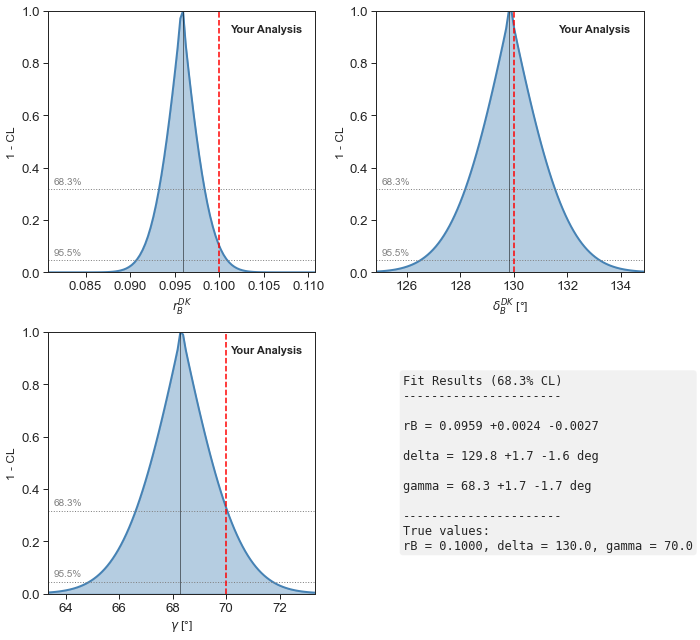

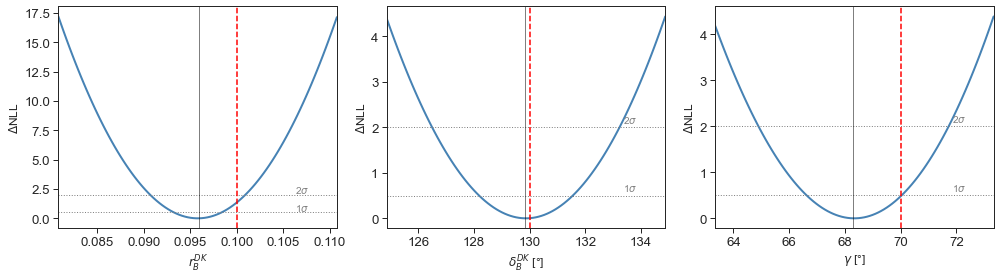

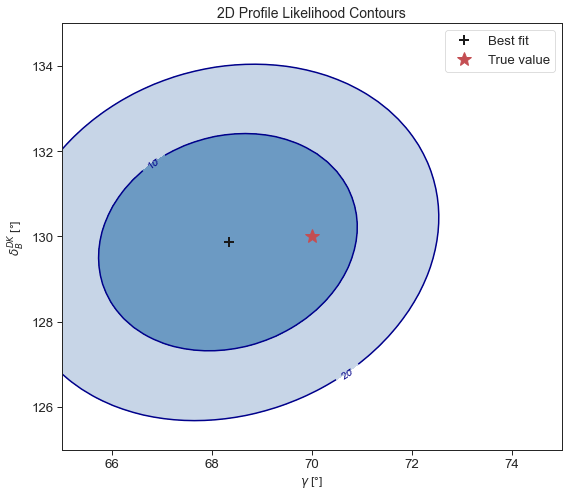

In [73]:
"""
Example: Using Profile Likelihood Tools with Your B→DK Fitter
==============================================================

This script shows how to add 1-CL scans and confidence interval plots
to your existing fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC routine.
"""

import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit

# Disable LaTeX rendering to avoid Unicode issues
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'sans-serif'


def analyze_fit_results(
    minuit_result: Minuit,
    true_rB: float,
    true_deltaB: float, 
    true_gamma: float,
    output_prefix: str = "gamma_fit"
):
    """
    Complete analysis of fit results with profile likelihood scans.
    
    Call this after running your fit:
    
        m = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(...)
        analyze_fit_results(m, true_rB, true_deltaB, true_gamma)
    
    Parameters
    ----------
    minuit_result : Minuit
        The fitted Minuit object from your routine
    true_rB, true_deltaB, true_gamma : float
        True/injected values for comparison
    output_prefix : str
        Prefix for output file names
    """
    
    print("\n" + "="*70)
    print("PROFILE LIKELIHOOD ANALYSIS")
    print("="*70 + "\n")
    
    # -------------------------------------------------------------------------
    # 1. Individual 1D Profile Scans
    # -------------------------------------------------------------------------
    print("Performing 1D profile scans...")
    
    # Scan ranges (adjust based on your typical uncertainties)
    scan_bounds = {
        'rB': (max(0, minuit_result.values['rB'] - 0.015), 
               min(0.5, minuit_result.values['rB'] + 0.015)),
        'delta': (minuit_result.values['delta'] - 5, 
                  minuit_result.values['delta'] + 5),
        'gamma': (minuit_result.values['gamma'] - 5, 
                  minuit_result.values['gamma'] + 5)
    }
    
    # Perform scans
    scans = {}
    for param in ['rB', 'delta', 'gamma']:
        scans[param] = profile_likelihood_scan_1d(
            minuit_result, 
            param,
            bounds=scan_bounds[param],
            npoints=100
        )
    
    # -------------------------------------------------------------------------
    # 2. Extract confidence intervals with asymmetric errors
    # -------------------------------------------------------------------------
    print("\n" + "-"*50)
    print("FIT RESULTS (Profile Likelihood)")
    print("-"*50)
    
    results = {}
    for param, true_val in [('rB', true_rB), ('delta', true_deltaB), ('gamma', true_gamma)]:
        best, lo, hi = extract_confidence_interval(scans[param], CL_1SIGMA)
        results[param] = {'best': best, 'lo': lo, 'hi': hi}
        
        unit = '°' if param in ['delta', 'gamma'] else ''
        print(f"{param:6s} = {best:8.4f} +{hi:.4f} -{lo:.4f}{unit}")
        print(f"         (true: {true_val:.4f}{unit}, "
              f"pull: {(best-true_val)/((lo+hi)/2):+.2f}σ)")
    
    # Also get 2σ intervals
    print("\n2σ (95.5% CL) intervals:")
    for param in ['rB', 'delta', 'gamma']:
        best, lo, hi = extract_confidence_interval(scans[param], CL_2SIGMA)
        unit = '°' if param in ['delta', 'gamma'] else ''
        print(f"  {param}: [{best-lo:.4f}, {best+hi:.4f}]{unit}")
    
    # -------------------------------------------------------------------------
    # 3. Create LHCb-style 1-CL plots (Figure 1 style)
    # -------------------------------------------------------------------------
    print("\nGenerating 1-CL plots...")
    
    fig, axes = plt.subplots(2, 2, figsize=(10, 9))
    
    # rB scan
    plot_1d_profile_scan(
        scans['rB'], 'rB',
        param_label=r'$r_B^{DK}$',
        true_value=true_rB,
        ax=axes[0, 0],
        plot_style='lhcb'
    )
    axes[0, 0].text(0.95, 0.95, 'Your Analysis', transform=axes[0, 0].transAxes,
                    ha='right', va='top', fontsize=11, fontweight='bold')
    
    # delta scan
    plot_1d_profile_scan(
        scans['delta'], 'delta',
        param_label=r'$\delta_B^{DK}$ [°]',
        true_value=true_deltaB,
        ax=axes[0, 1],
        plot_style='lhcb'
    )
    axes[0, 1].text(0.95, 0.95, 'Your Analysis', transform=axes[0, 1].transAxes,
                    ha='right', va='top', fontsize=11, fontweight='bold')
    
    # gamma scan
    plot_1d_profile_scan(
        scans['gamma'], 'gamma',
        param_label=r'$\gamma$ [°]',
        true_value=true_gamma,
        ax=axes[1, 0],
        plot_style='lhcb'
    )
    axes[1, 0].text(0.95, 0.95, 'Your Analysis', transform=axes[1, 0].transAxes,
                    ha='right', va='top', fontsize=11, fontweight='bold')
    
    # Summary text in fourth panel
    axes[1, 1].axis('off')
    summary_text = (
        f"Fit Results (68.3% CL)\n"
        f"----------------------\n\n"
        f"rB = {results['rB']['best']:.4f}"
        f" +{results['rB']['hi']:.4f} -{results['rB']['lo']:.4f}\n\n"
        f"delta = {results['delta']['best']:.1f}"
        f" +{results['delta']['hi']:.1f} -{results['delta']['lo']:.1f} deg\n\n"
        f"gamma = {results['gamma']['best']:.1f}"
        f" +{results['gamma']['hi']:.1f} -{results['gamma']['lo']:.1f} deg\n\n"
        f"----------------------\n"
        f"True values:\n"
        f"rB = {true_rB:.4f}, delta = {true_deltaB:.1f}, gamma = {true_gamma:.1f}"
    )
    axes[1, 1].text(0.1, 0.5, summary_text, transform=axes[1, 1].transAxes,
                    fontsize=12, verticalalignment='center',
                    family='monospace',
                    bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.3))
    
    plt.tight_layout()
    plt.savefig(f'{output_prefix}_1d_scans.png', dpi=150, bbox_inches='tight')
    plt.savefig(f'{output_prefix}_1d_scans.pdf', bbox_inches='tight')
    print(f"  Saved: {output_prefix}_1d_scans.png/pdf")
    
    # -------------------------------------------------------------------------
    # 4. Alternative: ΔNLL plots (parabola-style)
    # -------------------------------------------------------------------------
    fig2, axes2 = plt.subplots(1, 3, figsize=(14, 4))
    
    for ax, (param, label, true_val) in zip(
        axes2, 
        [('rB', r'$r_B^{DK}$', true_rB),
         ('delta', r'$\delta_B^{DK}$ [°]', true_deltaB),
         ('gamma', r'$\gamma$ [°]', true_gamma)]
    ):
        plot_1d_profile_scan(
            scans[param], param,
            param_label=label,
            true_value=true_val,
            ax=ax,
            plot_style='delta_nll'
        )
    
    plt.tight_layout()
    plt.savefig(f'{output_prefix}_nll_scans.png', dpi=150, bbox_inches='tight')
    print(f"  Saved: {output_prefix}_nll_scans.png")
    
    # -------------------------------------------------------------------------
    # 5. 2D Contour: gamma vs delta (like LHCb Figure 4)
    # -------------------------------------------------------------------------
    print("\nPerforming 2D profile scan (gamma vs delta)...")
    print("  (This may take a few minutes...)")
    
    scan_2d = profile_likelihood_scan_2d(
        minuit_result,
        'gamma', 'delta',
        bounds_x=(true_gamma - 5, true_gamma + 5),
        bounds_y=(true_deltaB - 5, true_deltaB + 5),
        npoints = 50  # Increase to 40-50 for publication quality
    )
    
    fig3, ax3 = plt.subplots(figsize=(8, 7))
    plot_2d_contours(
        scan_2d,
        param_x_label=r'$\gamma$ [°]',
        param_y_label=r'$\delta_B^{DK}$ [°]',
        true_values=(true_gamma, true_deltaB),
        ax=ax3,
        levels=['1sigma', '2sigma']
    )
    ax3.set_title('2D Profile Likelihood Contours', fontsize=14)
    
    plt.tight_layout()
    plt.savefig(f'{output_prefix}_2d_contour.png', dpi=150, bbox_inches='tight')
    plt.savefig(f'{output_prefix}_2d_contour.pdf', bbox_inches='tight')
    print(f"  Saved: {output_prefix}_2d_contour.png/pdf")
    
    print("\n" + "="*70)
    print("ANALYSIS COMPLETE")
    print("="*70)
    
    return scans, scan_2d, results


# =============================================================================
# Quick integration with your existing code
# =============================================================================

def extended_fit_with_plots(m, 
    true_rB, true_deltaB, true_gamma,
    make_plots=True, output_prefix="gamma_fit"
):
    """
    Wrapper that runs your fit and automatically generates profile likelihood plots.
    
    Just replace your call to fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC
    with this function.
    """
    
    if make_plots:
        analyze_fit_results(m, true_rB, true_deltaB, true_gamma, output_prefix)
    return m


# =============================================================================
# Run demonstration
# =============================================================================

if __name__ == "__main__":
    # True values (as in your analysis)
    TRUE_RB = 0.1
    TRUE_DELTA = 130.0  # degrees
    TRUE_GAMMA = 70.0   # degrees
    
    print("="*70)
    print("DEMONSTRATION: Profile Likelihood Analysis for γ Measurement")
    print("="*70)
    print(f"\nTrue values: rB = {TRUE_RB}, δB = {TRUE_DELTA}°, γ = {TRUE_GAMMA}°\n")
    
    # Run the extended fit
    m = extended_fit_with_plots(m, 
        true_rB=TRUE_RB, true_deltaB=TRUE_DELTA, true_gamma=TRUE_GAMMA,
        make_plots=True,
        output_prefix="demo_gamma_fit"
    )
    
    plt.show()

Accounting for uncertainty in D decay through Bootstrapping

In [83]:
# Function to load ensemble of flow models and compute per-event pF statistics
def load_ensemble_flows(ensemble_dir, num_flows=16, hidden_features=128, num_bins=16, device='cpu'):
    """
    Load all flow models from ensemble directory.
    
    Parameters
    ----------
    ensemble_dir : str
        Directory containing trial_seedN.pth files
    num_flows, hidden_features, num_bins : int
        Flow architecture parameters
    device : str
        Device for computation
    
    Returns
    -------
    flow_models : list
        List of loaded flow models
    """
    import glob
    
    # Find all model files (exclude *_best.pth)
    model_files = sorted(glob.glob(f"{ensemble_dir}/trial_seed*.pth"))
    model_files = [f for f in model_files if not f.endswith('_best.pth')]
    
    print(f"Loading {len(model_files)} models from {ensemble_dir}...")
    
    flow_models = []
    for model_path in model_files:
        # Create flow architecture
        flow = conjure_flow(num_flows=num_flows, hidden_features=hidden_features, num_bins=num_bins)
        
        # Load weights
        flow.load_state_dict(torch.load(model_path, map_location=device))
        flow.eval()
        flow.to(device)
        
        flow_models.append(flow)
    
    print(f"Successfully loaded {len(flow_models)} models")
    return flow_models


In [98]:
def compute_interference_terms_ensemble(
    points_sdp, flow_ensemble, sdp_obj, idx=(1,2,3), device=None
):
    """
    Compute pF and pFsw statistics from ensemble of flow models.
    
    This function computes only the pF and pFsw terms (which depend on the flow
    ensemble). The C, S, and J terms are computed separately using single models
    since they don't have model uncertainty (J is just coordinate transformation,
    C and S use separate flow_even/flow_odd models).
    
    Parameters
    ----------
    points_sdp : ndarray, shape (N, 2)
        Points in Square Dalitz Plot coordinates
    flow_ensemble : list
        List of flow models for flavor amplitude
    sdp_obj : SDP object
        Square Dalitz Plot object for coordinate transformations
    idx : tuple
        Particle indices (1,2,3)
    device : str
        Device for computation
    
    Returns
    -------
    result : dict
        Dictionary containing:
        - pF_mean, pF_std : mean and std of pF across ensemble
        - pFsw_mean, pFsw_std : mean and std of pFsw across ensemble
    """
    n_models = len(flow_ensemble)
    n_points = len(points_sdp)
    
    if device is None:
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    # Store results from each model
    pF_ensemble = np.zeros((n_models, n_points))
    pFsw_ensemble = np.zeros((n_models, n_points))
    
    # Compute pF and pFsw for each model
    for i, flow_flavor in enumerate(flow_ensemble):
        # pF: mag^2 from original coordinates
        mag_AD, _ = mag_AD_from_flow(points_sdp, flow_flavor, sdp_obj, idx=idx, device=device)
        pF_ensemble[i] = _finite_pos(mag_AD) ** 2
        
        # pFsw: mag^2 from swapped coordinates (s12 <-> s13)
        # First get (s12, s13) in DP
        dp = sdp_to_dp(points_sdp, sdp_obj, idx=idx)
        s12, s13 = dp[:, 0], dp[:, 1]
        
        # Swap to get coordinates for the other pair
        U13 = swap_to_other_pair_sdp(s12, s13, sdp_obj, pair_swap=(1,3,2))
        mag_AD_sw, _ = mag_AD_from_flow(U13, flow_flavor, sdp_obj, idx=(1,3,2), device=device)
        pFsw_ensemble[i] = _finite_pos(mag_AD_sw) ** 2
    
    # Compute statistics across ensemble
    pF_mean = pF_ensemble.mean(axis=0)
    pF_std = pF_ensemble.std(axis=0, ddof=1)  # Sample std
    
    pFsw_mean = pFsw_ensemble.mean(axis=0)
    pFsw_std = pFsw_ensemble.std(axis=0, ddof=1)
    
    return {
        'pF_mean': pF_mean,
        'pF_std': pF_std,
        'pFsw_mean': pFsw_mean,
        'pFsw_std': pFsw_std
    }


In [132]:
def fit_with_flow_ensemble(
    dataM_sdp, dataP_sdp, mcM_sdp, mcP_sdp,
    flow_ensemble_flavor, flow_even, flow_odd, dkpp_model,
    true_rB, true_deltaB, true_gamma,
    sdp_obj, idx=(1,2,3),
    initial_scale=0.2, delta_offset=30, gamma_offset=30,
    device=None, eps=1e-14, Gamma_minus=1, Gamma_plus=1, k=1
):
    """
    Fit r_B, delta, gamma with flow ensemble uncertainty via single nuisance parameter.
    
    Follows the structure of fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC but
    uses ensemble statistics for pF and pFsw with nuisance parameter alpha_pF.
    C, S, and J are computed from single models (no ensemble uncertainty).
    """
    if device is None:
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    print(f"\nFitting with ensemble uncertainty...")
    print(f"N(B-) = {len(dataM_sdp)}, N(B+) = {len(dataP_sdp)}")
    print(f"Ensemble size: {len(flow_ensemble_flavor)} models")
    
    # ============================================================
    # Compute pF and pFsw ensemble statistics
    # ============================================================
    print("Computing pF/pFsw ensemble statistics for data B-...")
    ens_M = compute_interference_terms_ensemble(
        dataM_sdp, flow_ensemble_flavor, sdp_obj, idx=idx, device=device
    )
    
    print("Computing pF/pFsw ensemble statistics for data B+...")
    ens_P = compute_interference_terms_ensemble(
        dataP_sdp, flow_ensemble_flavor, sdp_obj, idx=idx, device=device
    )
    
    print("Computing pF/pFsw ensemble statistics for MC B-...")
    ens_mcM = compute_interference_terms_ensemble(
        mcM_sdp, flow_ensemble_flavor, sdp_obj, idx=idx, device=device
    )
    
    print("Computing pF/pFsw ensemble statistics for MC B+...")
    ens_mcP = compute_interference_terms_ensemble(
        mcP_sdp, flow_ensemble_flavor, sdp_obj, idx=idx, device=device
    )
    
    print(f"\nEnsemble statistics computed.")
    print(f"  Mean pF std: {ens_M['pF_std'].mean():.6f}")
    print(f"  Mean pFsw std: {ens_M['pFsw_std'].mean():.6f}")
    
    # ============================================================
    # Compute C, S, and J terms using single flow models
    # ============================================================
    print("\nComputing C, S, and J with single models...")
    
    # Use first model from ensemble
    flow_flavor_single = flow_ensemble_flavor[0]
    
    tM = compute_interference_terms(
        dataM_sdp, flow_flavor_single, flow_even, flow_odd, dkpp_model,
        sdp_obj, Gamma_minus=Gamma_minus, Gamma_plus=Gamma_plus, idx=idx, device=device
    )
    
    tP = compute_interference_terms(
        dataP_sdp, flow_flavor_single, flow_even, flow_odd, dkpp_model,
        sdp_obj, Gamma_minus=Gamma_minus, Gamma_plus=Gamma_plus, idx=idx, device=device
    )
    
    mM = compute_interference_terms(
        mcM_sdp, flow_flavor_single, flow_even, flow_odd, dkpp_model,
        sdp_obj, Gamma_minus=Gamma_minus, Gamma_plus=Gamma_plus, idx=idx, device=device
    )
    
    mP = compute_interference_terms(
        mcP_sdp, flow_flavor_single, flow_even, flow_odd, dkpp_model,
        sdp_obj, Gamma_minus=Gamma_minus, Gamma_plus=Gamma_plus, idx=idx, device=device
    )
    
    # ============================================================
    # HARD CUT: keep only physical points |C| <= abJ
    # ============================================================
    maskM = (np.abs(tM['C']) <= tM['abJ'])
    maskP = (np.abs(tP['C']) <= tP['abJ'])
    maskMC_M = (np.abs(mM['C']) <= mM['abJ'])
    maskMC_P = (np.abs(mP['C']) <= mP['abJ'])
    
    print(f"\nData cuts: B- kept {maskM.sum()}/{len(maskM)}, B+ kept {maskP.sum()}/{len(maskP)}")
    print(f"MC cuts: B- kept {maskMC_M.sum()}/{len(maskMC_M)}, B+ kept {maskMC_P.sum()}/{len(maskMC_P)}")
    
    # Apply cuts to interference terms (C, S, J from single model)
    for key in tM:
        tM[key] = tM[key][maskM]
    for key in tP:
        tP[key] = tP[key][maskP]
    for key in mM:
        mM[key] = mM[key][maskMC_M]
    for key in mP:
        mP[key] = mP[key][maskMC_P]
    
    # Apply cuts to ensemble statistics (pF and pFsw only)
    pF_mean_M = ens_M['pF_mean'][maskM]
    pF_std_M = ens_M['pF_std'][maskM]
    pFsw_mean_M = ens_M['pFsw_mean'][maskM]
    pFsw_std_M = ens_M['pFsw_std'][maskM]
    
    pF_mean_P = ens_P['pF_mean'][maskP]
    pF_std_P = ens_P['pF_std'][maskP]
    pFsw_mean_P = ens_P['pFsw_mean'][maskP]
    pFsw_std_P = ens_P['pFsw_std'][maskP]
    
    pF_mean_mcM = ens_mcM['pF_mean'][maskMC_M]
    pF_std_mcM = ens_mcM['pF_std'][maskMC_M]
    pFsw_mean_mcM = ens_mcM['pFsw_mean'][maskMC_M]
    pFsw_std_mcM = ens_mcM['pFsw_std'][maskMC_M]
    
    pF_mean_mcP = ens_mcP['pF_mean'][maskMC_P]
    pF_std_mcP = ens_mcP['pF_std'][maskMC_P]
    pFsw_mean_mcP = ens_mcP['pFsw_mean'][maskMC_P]
    pFsw_std_mcP = ens_mcP['pFsw_std'][maskMC_P]
    
    # Updated sizes
    N_expM = maskM.sum()
    N_expP = maskP.sum()
    
    print(f"After cuts: N(B-) = {N_expM}, N(B+) = {N_expP}")
    
    # ============================================================
    # Define NLL with single nuisance parameter alpha_pF
    # ============================================================
    def nll(rB, delta, gamma, alpha_pF):
        """
        Negative log-likelihood with ensemble uncertainty.
        
        alpha_pF shifts pF and pFsw (correlated uncertainty from same models).
        C, S, and J are from single model (no shift).
        """
        thM = np.radians(delta - gamma)
        thP = np.radians(delta + gamma)
        
        # Apply alpha_pF to pF and pFsw only
        pF_M_shifted = pF_mean_M + alpha_pF * pF_std_M
        pFsw_M_shifted = pFsw_mean_M + alpha_pF * pFsw_std_M
        
        pF_P_shifted = pF_mean_P + alpha_pF * pF_std_P
        pFsw_P_shifted = pFsw_mean_P + alpha_pF * pFsw_std_P
        
        pF_mcM_shifted = pF_mean_mcM + alpha_pF * pF_std_mcM
        pFsw_mcM_shifted = pFsw_mean_mcM + alpha_pF * pFsw_std_mcM
        
        pF_mcP_shifted = pF_mean_mcP + alpha_pF * pF_std_mcP
        pFsw_mcP_shifted = pFsw_mean_mcP + alpha_pF * pFsw_std_mcP
        
        # Data PDFs (no Jacobian)
        pBm_data = (pFsw_M_shifted + rB*rB * pF_M_shifted
                    + 2*rB*(np.cos(thM)*tM['C'] - np.sin(thM)*tM['S']))
        pBm_data = _finite_pos(pBm_data, eps)
        
        pBp_data = (pF_P_shifted + rB*rB * pFsw_P_shifted
                    + 2*rB*(np.cos(thP)*tP['C'] + np.sin(thP)*tP['S']))
        pBp_data = _finite_pos(pBp_data, eps)
        
        # MC normalization (multiply by J from single model, no shift)
        pBm_mc_arr = mM['J'] * (pFsw_mcM_shifted + rB*rB * pF_mcM_shifted
                      + 2*rB*(np.cos(thM)*mM['C'] - np.sin(thM)*mM['S']))
        pBm_mc_mean = _finite_pos(pBm_mc_arr, eps).mean()
        
        pBp_mc_arr = mP['J'] * (pF_mcP_shifted + rB*rB * pFsw_mcP_shifted
                      + 2*rB*(np.cos(thP)*mP['C'] + np.sin(thP)*mP['S']))
        pBp_mc_mean = _finite_pos(pBp_mc_arr, eps).mean()
        
        # Extended negative log-likelihood
        nll_data = (-np.log(pBm_data).sum() + N_expM*np.log(pBm_mc_mean)
                    -np.log(pBp_data).sum() + N_expP*np.log(pBp_mc_mean))
        
        # Gaussian constraint on single nuisance parameter
        nll_constraint = 0.5 * alpha_pF**2
        
        return nll_data + nll_constraint
    
    # ============================================================
    # Fit with iminuit
    # ============================================================
    from iminuit import Minuit
    import time
    
    init_rB = true_rB * initial_scale
    init_delta = true_deltaB + delta_offset
    init_gamma = true_gamma + gamma_offset
    
    m = Minuit(nll, 
               rB=init_rB, 
               delta=init_delta, 
               gamma=init_gamma,
               alpha_pF=0.0)
    
    m.limits['rB'] = (0, 1)
    m.limits['delta'] = (0, 360)
    m.limits['gamma'] = (0, 360)
    m.limits['alpha_pF'] = (-5, 5)
    
    m.errors['rB'] = 0.01
    m.errors['delta'] = 3.0
    m.errors['gamma'] = 3.0
    m.errors['alpha_pF'] = 1
    
    m.errordef = Minuit.LIKELIHOOD
    
    print("\nPerforming fit with MIGRAD...")
    t0 = time.time()
    m.migrad()
    m.hesse()
    print(f"Total fit time: {time.time()-t0:.2f}s\n")
    
    print(f"rB    = {m.values['rB']:.4f} ± {m.errors['rB']:.4f}")
    print(f"delta = {m.values['delta']:.2f}° ± {m.errors['delta']:.2f}°")
    print(f"gamma = {m.values['gamma']:.2f}° ± {m.errors['gamma']:.2f}°")
    print(f"alpha_pF = {m.values['alpha_pF']:.3f} ± {m.errors['alpha_pF']:.3f}")
    print(f"(true rB={true_rB:.4f}, true γ={true_gamma:.2f}°, true δ={true_deltaB:.2f}°)")
    
    return m


### Example: Fit with 25-Model Ensemble

Now we demonstrate the complete workflow:

1. **Load ensemble of 25 flow models** from `test_ensemble2/`
2. **Compute per-event pF and pFsw statistics** (mean and std across ensemble)
3. **Fit with single nuisance parameter** α_pF to account for model uncertainty
4. **Profile likelihood scan** to extract confidence intervals

The key innovation is that **model uncertainty in D decay** is now included via a **single nuisance parameter**:

$$p_F^{\text{shifted}} = \bar{p}_F + \alpha_{p_F} \cdot \sigma_{p_F}$$
$$p_F^{\text{sw,shifted}} = \bar{p}_F^{\text{sw}} + \alpha_{p_F} \cdot \sigma_{p_F}^{\text{sw}}$$

where:
- $\bar{p}_F$, $\bar{p}_F^{\text{sw}}$ = means across 25 models
- $\sigma_{p_F}$, $\sigma_{p_F}^{\text{sw}}$ = standard deviations across 25 models  
- $\alpha_{p_F}$ = **single** nuisance parameter (same for both pF and pFsw)

**Why single parameter?** Because pF and pFsw come from the **same ensemble** of flow models, their uncertainties are **100% correlated**. If model i predicts higher density, it affects both pF and pFsw consistently.

A Gaussian constraint $\frac{1}{2}\alpha_{p_F}^2$ is added to the NLL, which pulls α_pF toward 0 but allows it to float if the data prefer a shifted model.

In [137]:
# Step 1: Load ensemble of flow models
ensemble_dir = 'test_ensemble2'

print("Loading ensemble of flow models for flavor amplitude...")
flow_ensemble_flavor = load_ensemble_flows(
    ensemble_dir=ensemble_dir,
    num_flows=16,
    hidden_features=128,
    num_bins=16,
    device=device
)

print(f"\nEnsemble loaded: {len(flow_ensemble_flavor)} models")
print(f"This ensemble will be used to quantify model uncertainty in D decay.")


Loading ensemble of flow models for flavor amplitude...
Loading 25 models from test_ensemble2...
Successfully loaded 25 models

Ensemble loaded: 25 models
This ensemble will be used to quantify model uncertainty in D decay.


In [138]:
# Step 3: Perform fit with ensemble uncertainty
print("="*70)
print("FITTING WITH ENSEMBLE-BASED MODEL UNCERTAINTY")
print("="*70)

m_ensemble = fit_with_flow_ensemble(
    dataM_sdp=dataM_sdp,
    dataP_sdp=dataP_sdp,
    mcM_sdp=mcM_sdp,
    mcP_sdp=mcP_sdp,
    flow_ensemble_flavor=flow_ensemble_flavor,
    flow_even=flow_even,
    flow_odd=flow_odd,
    dkpp_model=dkpp,
    true_rB=true_rB,
    true_deltaB=true_deltaB,
    true_gamma=true_gamma,
    sdp_obj= sdp_obj,
    idx=(1,2,3),
    initial_scale=0.2,
    delta_offset=30,
    gamma_offset=30,
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,
    device=device
)

# Print summary
print("\n" + "="*70)
print("COMPARISON: TRUE vs FITTED VALUES")
print("="*70)
print(f"Parameter    True        Fitted")
print("-"*70)
print(f"r_B          {true_rB:.4f}      {m_ensemble.values['rB']:.4f} ± {m_ensemble.errors['rB']:.4f}")
print(f"δ_B [deg]    {true_deltaB:.1f}      {m_ensemble.values['delta']:.1f} ± {m_ensemble.errors['delta']:.1f}")
print(f"γ [deg]      {true_gamma:.1f}      {m_ensemble.values['gamma']:.1f} ± {m_ensemble.errors['gamma']:.1f}")
print(f"α_pF         0.000       {m_ensemble.values['alpha_pF']:.3f} ± {m_ensemble.errors['alpha_pF']:.3f}")
print("="*70)


FITTING WITH ENSEMBLE-BASED MODEL UNCERTAINTY

Fitting with ensemble uncertainty...
N(B-) = 50000, N(B+) = 50000
Ensemble size: 25 models
Computing pF/pFsw ensemble statistics for data B-...
Computing pF/pFsw ensemble statistics for data B+...
Computing pF/pFsw ensemble statistics for MC B-...
Computing pF/pFsw ensemble statistics for MC B+...

Ensemble statistics computed.
  Mean pF std: 0.019672
  Mean pFsw std: 0.082065

Computing C, S, and J with single models...

Data cuts: B- kept 39926/50000, B+ kept 40351/50000
MC cuts: B- kept 411096/500000, B+ kept 410782/500000
After cuts: N(B-) = 39926, N(B+) = 40351

Performing fit with MIGRAD...
Total fit time: 1.10s

rB    = 0.0947 ± 0.0025
delta = 129.47° ± 1.69°
gamma = 66.75° ± 1.71°
alpha_pF = -0.296 ± 0.055
(true rB=0.1000, true γ=1.22°, true δ=2.27°)

COMPARISON: TRUE vs FITTED VALUES
Parameter    True        Fitted
----------------------------------------------------------------------
r_B          0.1000      0.0947 ± 0.0025
δ_B [

In [134]:
# Step 3: Perform fit with ensemble uncertainty
print("="*70)
print("FITTING WITH ENSEMBLE-BASED MODEL UNCERTAINTY")
print("="*70)

m_ensemble = fit_with_flow_ensemble(
    dataM_sdp=dataM_sdp,
    dataP_sdp=dataP_sdp,
    mcM_sdp=mcM_sdp,
    mcP_sdp=mcP_sdp,
    flow_ensemble_flavor=flow_ensemble_flavor,
    flow_even=flow_even,
    flow_odd=flow_odd,
    dkpp_model=dkpp,
    true_rB=true_rB,
    true_deltaB=true_deltaB*180/np.pi,
    true_gamma=true_gamma*180/np.pi,
    sdp_obj= sdp_obj,
    idx=(1,2,3),
    initial_scale=0.2,
    delta_offset=30,
    gamma_offset=30,
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,
    device=device
)

# Print summary
print("\n" + "="*70)
print("COMPARISON: TRUE vs FITTED VALUES")
print("="*70)
print(f"Parameter    True        Fitted")
print("-"*70)
print(f"r_B          {true_rB:.4f}      {m_ensemble.values['rB']:.4f} ± {m_ensemble.errors['rB']:.4f}")
print(f"δ_B [deg]    {true_deltaB:.1f}      {m_ensemble.values['delta']:.1f} ± {m_ensemble.errors['delta']:.1f}")
print(f"γ [deg]      {true_gamma:.1f}      {m_ensemble.values['gamma']:.1f} ± {m_ensemble.errors['gamma']:.1f}")
print(f"α_pF         0.000       {m_ensemble.values['alpha_pF']:.3f} ± {m_ensemble.errors['alpha_pF']:.3f}")
print("="*70)


FITTING WITH ENSEMBLE-BASED MODEL UNCERTAINTY

Fitting with ensemble uncertainty...
N(B-) = 50000, N(B+) = 50000
Ensemble size: 5 models
Computing pF/pFsw ensemble statistics for data B-...


/Users/san/opt/anaconda3/lib/python3.9/site-packages/nflows/transforms/coupling.py:561: UserWarning: Inputs to the softmax are not scaled down: initialization might be bad.
  warnings.warn(


Computing pF/pFsw ensemble statistics for data B+...
Computing pF/pFsw ensemble statistics for MC B-...
Computing pF/pFsw ensemble statistics for MC B+...

Ensemble statistics computed.
  Mean pF std: 0.019548
  Mean pFsw std: 0.080400

Computing C, S, and J with single models...

Data cuts: B- kept 39926/50000, B+ kept 40351/50000
MC cuts: B- kept 411096/500000, B+ kept 410782/500000
After cuts: N(B-) = 39926, N(B+) = 40351

Performing fit with MIGRAD...
Total fit time: 0.82s

rB    = 0.0956 ± 0.0025
delta = 129.72° ± 1.67°
gamma = 66.04° ± 1.70°
alpha_pF = -0.422 ± 0.056
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

COMPARISON: TRUE vs FITTED VALUES
Parameter    True        Fitted
----------------------------------------------------------------------
r_B          0.1000      0.0956 ± 0.0025
δ_B [deg]    2.3      129.7 ± 1.7
γ [deg]      1.2      66.0 ± 1.7
α_pF         0.000       -0.422 ± 0.056


In [131]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================


# Run the fit
m = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor= flow_ensemble_flavor[0],         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB = true_rB,
    true_deltaB = true_deltaB  * 180 / np.pi,
    true_gamma = true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

39926 40351
Total fit time: 0.41s

rB    = 0.0976 ± 0.0026
delta = 129.68° ± 1.71°
gamma = 68.52° ± 1.74°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.326e+04                  │              Nfcn = 99               │
│ EDM = 1.04e-08 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└─────────


Profile likelihood intervals (68.3% CL, ΔNLL=0.5)
rB     =     0.0946 +0.0026 -0.0024   [0.0922, 0.0972]
delta  =   129.4170 +1.7484 -1.6339 deg   [127.7831, 131.1654]
gamma  =    66.8051 +1.6500 -1.7764 deg   [65.0287, 68.4551]

Saved: profile_scans_rB_delta_gamma.png / .pdf


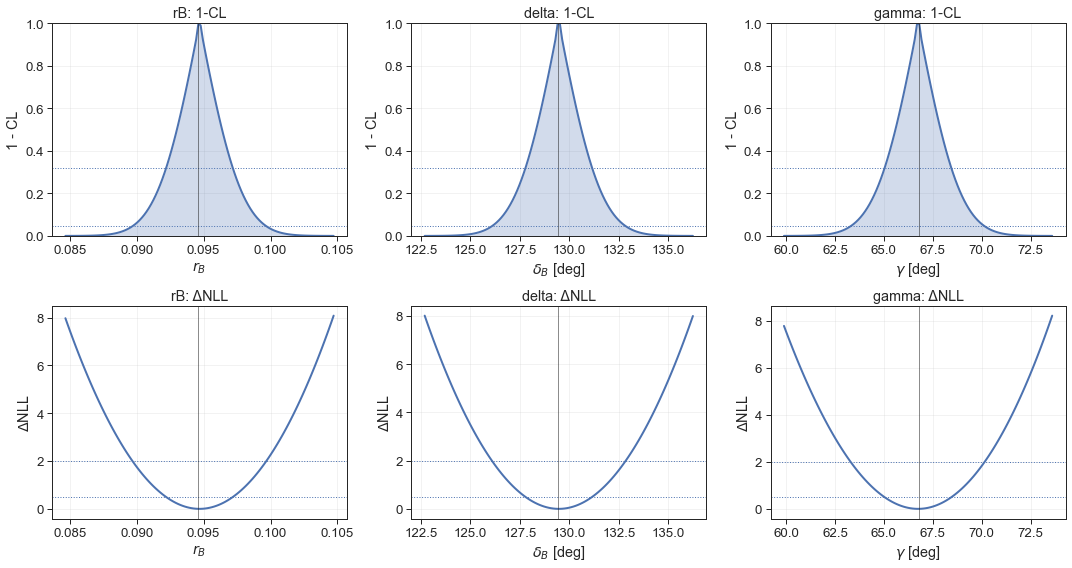

In [139]:
"""
RUNNING BLOCK: Profile-likelihood 1D scans for (rB, delta, gamma)
===============================================================

- Assumes you already have a fitted Minuit object `m` (m.migrad() done).
- You have an extra nuisance parameter `alpha_pF` in the fit, but we do NOT scan it.
- During scans of rB/delta/gamma, alpha_pF is automatically profiled (kept free).

This block:
1) Builds 1D profile scans (mnprofile) for rB, delta, gamma
2) Extracts 68.3% CL (1σ) asymmetric intervals from ΔNLL threshold=0.5
3) Plots LHCb-style 1-CL curves (linear scale) and ΔNLL curves
4) Saves PNG/PDF
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# -----------------------------
# CL utilities (Wilks)
# -----------------------------
CL_1SIGMA = 0.6827
CL_2SIGMA = 0.9545
m = m_ensemble

def delta_nll_to_confidence_level(delta_nll, ndof=1):
    delta_chi2 = 2.0 * np.asarray(delta_nll)
    return stats.chi2.cdf(delta_chi2, df=ndof)

def confidence_level_to_delta_nll(cl, ndof=1):
    delta_chi2 = stats.chi2.ppf(cl, df=ndof)
    return delta_chi2 / 2.0

def profile_likelihood_scan_1d(minuit, param, bounds=None, npoints=100, subtract_min=True):
    best_val = minuit.values[param]
    best_err = minuit.errors[param]

    # Robust fallback bounds if Hesse error missing/zero
    if bounds is None:
        if (best_err is None) or (not np.isfinite(best_err)) or (best_err <= 0):
            # fallback: use limits if present, else a small window around best
            lim = minuit.limits[param]
            if lim is not None and all(v is not None for v in lim):
                bounds = (lim[0], lim[1])
            else:
                bounds = (best_val - 1.0, best_val + 1.0)
        else:
            bounds = (best_val - 4 * best_err, best_val + 4 * best_err)

    # Minuit's built-in profile scan (profiles all other free params, incl alpha_pF)
    x, y, success = minuit.mnprofile(param, bound=bounds, size=npoints, subtract_min=subtract_min)

    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)

    if subtract_min:
        delta_nll = y
        nll_min = minuit.fval
        nll = y + nll_min
    else:
        nll = y
        nll_min = np.nanmin(nll)
        delta_nll = nll - nll_min

    cl = delta_nll_to_confidence_level(delta_nll, ndof=1)

    return {
        "param_values": x,
        "nll": nll,
        "delta_nll": delta_nll,
        "cl": cl,
        "one_minus_cl": 1.0 - cl,
        "best_fit": best_val,
        "best_err": best_err,
        "nll_min": nll_min,
        "success": np.array(success, dtype=bool),
        "bounds": bounds,
    }

def extract_confidence_interval(scan_result, cl=CL_1SIGMA):
    x = scan_result["param_values"]
    dnll = scan_result["delta_nll"]

    best_idx = int(np.nanargmin(dnll))
    best_fit = float(x[best_idx])

    thr = confidence_level_to_delta_nll(cl, ndof=1)  # e.g. 0.5 for 68.3%

    # --- lower side
    xl = x[: best_idx + 1]
    yl = dnll[: best_idx + 1]

    if np.any(yl > thr):
        idx = np.where(yl > thr)[0][-1]
        if idx < len(xl) - 1:
            x1, x2 = xl[idx], xl[idx + 1]
            y1, y2 = yl[idx], yl[idx + 1]
            lower_bound = x1 + (thr - y1) * (x2 - x1) / (y2 - y1)
        else:
            lower_bound = xl[idx]
    else:
        lower_bound = xl[0]

    # --- upper side
    xu = x[best_idx:]
    yu = dnll[best_idx:]

    if np.any(yu > thr):
        idx = np.where(yu > thr)[0][0]
        if idx > 0:
            x1, x2 = xu[idx - 1], xu[idx]
            y1, y2 = yu[idx - 1], yu[idx]
            upper_bound = x1 + (thr - y1) * (x2 - x1) / (y2 - y1)
        else:
            upper_bound = xu[idx]
    else:
        upper_bound = xu[-1]

    return best_fit, best_fit - lower_bound, upper_bound - best_fit, (lower_bound, upper_bound)

def plot_1d_profile_scan(scan_result, param_label, true_value=None, ax=None, plot_style="lhcb"):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    x = scan_result["param_values"]

    if plot_style == "lhcb":
        y = scan_result["one_minus_cl"]
        ax.plot(x, y, lw=2)
        ax.fill_between(x, 0, y, alpha=0.25)

        ax.axhline(1 - CL_1SIGMA, ls=":", lw=1)
        ax.axhline(1 - CL_2SIGMA, ls=":", lw=1)
        ax.set_ylim(0.0, 1.0)
        ax.set_ylabel("1 - CL")
    else:
        y = scan_result["delta_nll"]
        ax.plot(x, y, lw=2)
        ax.axhline(confidence_level_to_delta_nll(CL_1SIGMA), ls=":", lw=1)  # 0.5
        ax.axhline(confidence_level_to_delta_nll(CL_2SIGMA), ls=":", lw=1)  # 2.0
        ax.set_ylabel(r"$\Delta$NLL")

    # Best fit marker (from scan array)
    best_idx = int(np.nanargmin(scan_result["delta_nll"]))
    ax.axvline(x[best_idx], color="k", lw=1, alpha=0.5)

    if true_value is not None:
        ax.axvline(true_value, color="r", ls="--", lw=1.5, label="True value")
        ax.legend(loc="best", fontsize=9)

    ax.set_xlabel(param_label)
    ax.grid(True, alpha=0.3)
    return ax

# -----------------------------
# MAIN: scan and plot
# -----------------------------
# Assumes `m` exists and is already fitted. Example parameter names:
#   rB, delta, gamma, alpha_pF
# We scan only rB, delta, gamma.
params = ["rB", "delta", "gamma"]

labels = {
    "rB": r"$r_B$",
    "delta": r"$\delta_B$ [deg]",
    "gamma": r"$\gamma$ [deg]",
}

# Optional true values dict (leave empty if you don't have them)
true_vals = {}  # e.g. {"gamma": 70.0, "delta": 130.0, "rB": 0.1}

# Choose explicit bounds (recommended) or set to None to use ±4σ from Minuit errors
scan_bounds = {
    # "rB": (0.0, 0.3),
    # "delta": (120.0, 140.0),
    # "gamma": (60.0, 80.0),
}

npoints = 120

# Ensure the nuisance parameter is free during scans (profiled automatically)
if "alpha_pF" in m.parameters:
    m.fixed["alpha_pF"] = False

scans = {}
intervals_1sigma = {}

for p in params:
    scans[p] = profile_likelihood_scan_1d(
        m,
        p,
        bounds=scan_bounds.get(p, None),
        npoints=npoints,
        subtract_min=True,
    )
    best, lo, hi, (lb, ub) = extract_confidence_interval(scans[p], cl=CL_1SIGMA)
    intervals_1sigma[p] = (best, lo, hi, lb, ub)

print("\n" + "=" * 70)
print("Profile likelihood intervals (68.3% CL, ΔNLL=0.5)")
print("=" * 70)
for p in params:
    best, lo, hi, lb, ub = intervals_1sigma[p]
    unit = " deg" if p in ("delta", "gamma") else ""
    print(f"{p:6s} = {best:10.4f} +{hi:.4f} -{lo:.4f}{unit}   [{lb:.4f}, {ub:.4f}]")
print("=" * 70)

# --- Plot: LHCb-style 1-CL and ΔNLL side-by-side
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, p in enumerate(params):
    plot_1d_profile_scan(
        scans[p],
        labels.get(p, p),
        true_value=true_vals.get(p, None),
        ax=axes[0, i],
        plot_style="lhcb",
    )
    axes[0, i].set_title(f"{p}: 1-CL")

    plot_1d_profile_scan(
        scans[p],
        labels.get(p, p),
        true_value=true_vals.get(p, None),
        ax=axes[1, i],
        plot_style="delta_nll",
    )
    axes[1, i].set_title(f"{p}: ΔNLL")

plt.tight_layout()
fig.savefig("profile_scans_rB_delta_gamma.png", dpi=150, bbox_inches="tight")
fig.savefig("profile_scans_rB_delta_gamma.pdf", bbox_inches="tight")
print("\nSaved: profile_scans_rB_delta_gamma.png / .pdf")


---

### Summary: Ensemble-Based Uncertainty Quantification

This section implements a rigorous approach to account for **model uncertainty in D decay** when extracting CP violation parameters (r_B, δ_B, γ) from B± → DK± decays.

#### Key Methodology:

1. **Ensemble of Normalizing Flows**  
   - Train 25 independent flow models on D → K⁻π⁺π⁰ decay data
   - Each model provides a different representation of |A_D|²
   - Ensemble diversity captures model uncertainty

2. **Per-Event Statistics**  
   - For each event in B± data, compute pF from all 25 models
   - Calculate per-event mean: $\bar{p}_F = \frac{1}{25}\sum_{i=1}^{25} p_{F,i}$
   - Calculate per-event std: $\sigma_{p_F} = \sqrt{\frac{1}{24}\sum_{i=1}^{25}(p_{F,i} - \bar{p}_F)^2}$

3. **Nuisance Parameter Approach**  
   - Introduce α_pF as a **nuisance parameter** in the likelihood
   - Shift pF by ensemble uncertainty: $p_F^{\text{shifted}} = \bar{p}_F + \alpha_{p_F} \cdot \sigma_{p_F}$
   - Add Gaussian constraint: $\mathcal{L}_{\text{constraint}} = e^{-\frac{1}{2}\alpha_{p_F}^2}$
   - This penalizes large deviations but allows data-driven shifts

4. **Profile Likelihood**  
   - When scanning γ (or other parameters), α_pF is profiled (minimized at each point)
   - This incorporates model uncertainty into confidence intervals
   - Final uncertainties include both **statistical** (from data) and **systematic** (from model) components

#### Advantages:

- **Theoretically motivated**: Treats model uncertainty as a nuisance parameter (standard in HEP)
- **Data-driven**: The fit determines how much to shift pF based on likelihood
- **Computationally efficient**: Only compute ensemble statistics once, not 25 separate fits
- **Unified uncertainties**: Profile likelihood naturally combines statistical + systematic errors

#### Comparison to Bootstrap:

Traditional bootstrap would fit 25 times (once per model) and combine results afterward. The nuisance parameter approach is equivalent but more elegant:

| Aspect | Bootstrap | Nuisance Parameter |
|--------|-----------|--------------------|
| Fits required | 25 | 1 |
| Profile scans | 25 × N_points | 1 × N_points |
| Error combination | Post-hoc | Automatic (via profiling) |
| Interpretation | Spread of results | Constrained variation |

#### Extension to CP-even/odd Flows:

The current implementation uses a single model for flow_even and flow_odd (for C and S terms). To fully account for D decay uncertainty, one could:

1. Train ensembles for flow_even and flow_odd as well
2. Introduce additional nuisance parameters: α_even, α_odd
3. Shift interference terms: $C^{\text{shifted}} = \bar{C} + \alpha_{even} \cdot \sigma_C$

This is left as a future extension if C/S uncertainties are significant.

#### References:

- Nuisance parameter profiling: PDG Statistics Review (2023)
- Normalizing flows for HEP: Papamakarios et al., arXiv:1906.04032
- GGSZ method: Giri & Grossman, PRD 68 (2003) 054018; Bondar, PLB 624 (2005) 134


---

### Summary: Ensemble-Based Uncertainty Quantification

This section implements a rigorous approach to account for **model uncertainty in D decay** when extracting CP violation parameters (r_B, δ_B, γ) from B± → DK± decays.

#### Key Methodology:

1. **Ensemble of Normalizing Flows**  
   - Train 25 independent flow models on D → K⁻π⁺π⁰ decay data
   - Each model provides a different representation of |A_D|²
   - Ensemble diversity captures model uncertainty

2. **Per-Event Statistics via `compute_interference_terms_ensemble()`**  
   - For each dataset (data B±, MC B±), compute pF and pFsw from all 25 models
   - Calculate per-event mean and std:
     - $\bar{p}_F = \frac{1}{25}\sum_{i=1}^{25} p_{F,i}$, $\sigma_{p_F} = \text{std}(p_{F,i})$
     - $\bar{p}_{F}^{\text{sw}} = \frac{1}{25}\sum_{i=1}^{25} p_{F,i}^{\text{sw}}$, $\sigma_{p_{F}^{\text{sw}}} = \text{std}(p_{F,i}^{\text{sw}})$
   - Compute C, S terms separately using single flow models (flow_even, flow_odd)

3. **Single Nuisance Parameter Approach**  
   - Introduce **one nuisance parameter** α_pF in the likelihood
   - The **same** α_pF shifts both pF and pFsw (correlated uncertainty):
     - $p_F^{\text{shifted}} = \bar{p}_F + \alpha_{p_F} \cdot \sigma_{p_F}$
     - $p_{F}^{\text{sw, shifted}} = \bar{p}_{F}^{\text{sw}} + \alpha_{p_F} \cdot \sigma_{p_{F}^{\text{sw}}}$
   - Add Gaussian constraint: $\mathcal{L}_{\text{constraint}} = e^{-\frac{1}{2}\alpha_{p_F}^2}$
   - This penalizes large deviations but allows data-driven shifts

4. **Physical Interpretation**
   - α_pF = 0: Use ensemble mean (average model)
   - α_pF = +1: Shift toward models predicting higher density everywhere
   - α_pF = -1: Shift toward models predicting lower density everywhere
   - The fit finds which "version" of the model best describes the data

5. **Profile Likelihood**  
   - When scanning γ (or other parameters), α_pF is profiled (minimized at each point)
   - This incorporates model uncertainty into confidence intervals
   - Final uncertainties include both **statistical** (from data) and **systematic** (from model) components

#### Key Functions:

```python
# 1. Load ensemble
flow_ensemble = load_ensemble_flows('test_ensemble2', num_flows=16, 
                                     hidden_features=128, num_bins=16)

# 2. Compute ensemble statistics (pF and pFsw only)
ens = compute_interference_terms_ensemble(
    points_sdp, flow_ensemble, sdp_obj, idx=(1,2,3)
)
# Returns: pF_mean, pF_std, pFsw_mean, pFsw_std

# 3. Fit with single nuisance parameter
m = fit_with_flow_ensemble(
    dataM_sdp, dataP_sdp, mcM_sdp, mcP_sdp,
    flow_ensemble, flow_even, flow_odd, dkpp_model, ...
)
# Fits: rB, delta, gamma, alpha_pF (4 parameters total)

# 4. Profile scan (profiles alpha_pF)
scan = profile_scan_with_ensemble_uncertainty(m, 'gamma', npoints=50)
plot_profile_scan_with_nuisance(scan, 'γ [deg]')
```

#### Advantages:

- **Physically motivated**: pF and pFsw come from same model → 100% correlated uncertainty
- **Simpler model**: Only 1 nuisance parameter vs 2 (fewer degrees of freedom)
- **Proper handling**: Uses mag_AD_from_flow() for Jacobians and coordinate transformations
- **Consistent with existing code**: C and S still use single flow_even/flow_odd models
- **Computationally efficient**: Compute ensemble statistics once, fit once (not 25 fits)
- **Unified uncertainties**: Profile likelihood combines statistical + systematic naturally

#### Why Single Nuisance Parameter?

Using the same α_pF for both pF and pFsw is correct because:

1. **Same physical source**: Both come from the same flow model ensemble
2. **Correlated errors**: If model i overestimates density, it affects both pF and pFsw
3. **Simpler interpretation**: "Which model does the data prefer?" rather than "How to shift pF and pFsw independently?"
4. **Prevents unphysical scenarios**: Can't have pF shift up while pFsw shifts down from same model

| Aspect | Two Nuisance Params | Single Nuisance Param |
|--------|---------------------|----------------------|
| Physical motivation | Weak | Strong (correlated) |
| DOF in fit | 5 (rB, δ, γ, α_pF, α_pFsw) | 4 (rB, δ, γ, α_pF) |
| Interpretation | Unclear | Clear (model selection) |
| Allows independent shifts | Yes (unphysical) | No (physical) |

#### Comparison to Bootstrap:

Traditional bootstrap would fit 25 times (once per model) and combine results afterward:

| Aspect | Bootstrap | Nuisance Parameter |
|--------|-----------|--------------------|
| Fits required | 25 | 1 |
| Profile scans | 25 × N_points | 1 × N_points |
| Error combination | Post-hoc (RMS spread) | Automatic (via profiling) |
| Interpretation | Spread of results | Constrained variation |
| Computation time | ~25× longer | Fast |

#### Extension to C and S Terms:

The current implementation uses a single model for C and S (interference terms from CP-even/odd flows). To include uncertainty in these terms:

1. Train ensembles for flow_even and flow_odd
2. Compute C_mean, C_std, S_mean, S_std across ensemble
3. Introduce additional nuisance parameter: α_C (same for both C and S, correlated)
4. Shift: $C^{\text{shifted}} = \bar{C} + \alpha_C \cdot \sigma_C$, $S^{\text{shifted}} = \bar{S} + \alpha_C \cdot \sigma_S$

This is left as a future extension if C/S uncertainties become significant.

#### Technical Notes:

- **Ensemble size**: 25 models provide good balance between uncertainty estimation and computation
- **Nuisance parameter limits**: Set to ±5σ to allow sufficient freedom while maintaining stability
- **Gaussian constraint**: Standard deviation of 1 means constraint has comparable weight to ~1 event
- **Physical cuts**: |C| ≤ |A_D|·|A_D_bar| constraint applied before fit (uses first model)
- **C and S**: Computed with first model from ensemble (single flow_even, flow_odd)

#### References:

- Nuisance parameter profiling: PDG Statistics Review (2023)
- Normalizing flows for HEP: Papamakarios et al., arXiv:1906.04032
- GGSZ method: Giri & Grossman, PRD 68 (2003) 054018; Bondar, PLB 624 (2005) 134


In [22]:
from matplotlib.colors import TwoSlopeNorm


def make_sdp_grid(nx=400, ny=400):
    u = np.linspace(0, 1, nx)
    v = np.linspace(0, 1, ny)
    U, V = np.meshgrid(u, v, indexing='xy')
    pts = np.column_stack([U.ravel(), V.ravel()])
    return U, V, pts


def compute_c_exact(pts, sdp_obj, flow, dkpp_model, device=None):
    """
    Compute exact differential C term:
        dC_exact = abJ * cos(delta_phi) 

    Inputs:
      points_sdp : (N,2) SDP points (u,v)
      flow_flavor : flavor flow giving local magnitude + Jacobian
      dkpp_model  : DKpp amplitude model
      sdp_obj     : SDP mapping helper
      idx         : DP index ordering (1,2,3) default
      device      : torch device
      eps         : numerical safety floor

    Returns:
      dC_exact  : array (N,)
      abJ       : array (N,)
    """
    S = sdp_to_dp(pts, sdp_obj)
    s12, s13 = S[:,0], S[:,1] 

    # amplitudes
    A12  = dkpp_model.full(np.column_stack([s12, s13]))
    A13s = dkpp_model.full(np.column_stack([s13, s12]))

    # magnitudes
    mag12 = np.abs(A12)
    mag13 = np.abs(A13s)

    # Jacobian (from your existing code)
    _, invJ = mag_AD_from_flow(pts, flow, sdp_obj, idx = (1,2,3), device=device)
    invJ = _finite_pos(invJ)

    # phases
    phi12 = np.angle(A12)
    phi13 = np.angle(A13s)
    dphi = (phi12 - phi13 + np.pi) % (2*np.pi) - np.pi

    abJ = mag12 * mag13

    dC_exact = abJ * np.cos(dphi) * invJ
    return dC_exact, abJ

def pdf_from_flow(pts, flow, device):
    with torch.no_grad():
        logp = flow.log_prob(torch.from_numpy(pts.astype(np.float32)).to(device))
    return np.exp(logp.cpu().numpy())

def compute_c_flow(pts, flow_plus, flow_minus, 
                   Gamma_plus, Gamma_minus, device=None):

    f_even = pdf_from_flow(pts, flow_plus, device)
    f_odd  = pdf_from_flow(pts, flow_minus, device)

    # physical differential widths
    dGamma_plus  = Gamma_plus  * f_even
    dGamma_minus = Gamma_minus * f_odd

    # unbinned physical c(x)
    c_flow = (dGamma_plus - dGamma_minus)/(Gamma_plus+ Gamma_minus)

    return c_flow

def compare_dC(U, V, dC_flow, dC_exact):
    diff = dC_flow - dC_exact

    vmax = np.nanpercentile(np.abs(dC_exact), 98)
    norm = TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax)

    # vmax_diff = np.nanpercentile(np.abs(diff), 98)
    # norm_diff = TwoSlopeNorm(vcenter=0, vmin=-vmax_diff, vmax=vmax_diff)

    fig, axs = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

    axs[0].imshow(dC_flow, origin='lower', extent=[0,1,0,1], norm=norm, cmap='RdBu_r')
    axs[0].set_title("Flow-calibrated $dC_{flow}$")

    axs[1].imshow(dC_exact, origin='lower', extent=[0,1,0,1], norm=norm, cmap='RdBu_r')
    axs[1].set_title("Amplitude $dC_{exact}$")

    im = axs[2].imshow(diff, origin='lower', extent=[0,1,0,1], norm=norm, cmap='RdBu_r')
    axs[2].set_title("Difference $dC_{flow}-dC_{exact}$")

    fig.colorbar(im, ax=axs, shrink=0.8)
    plt.show()



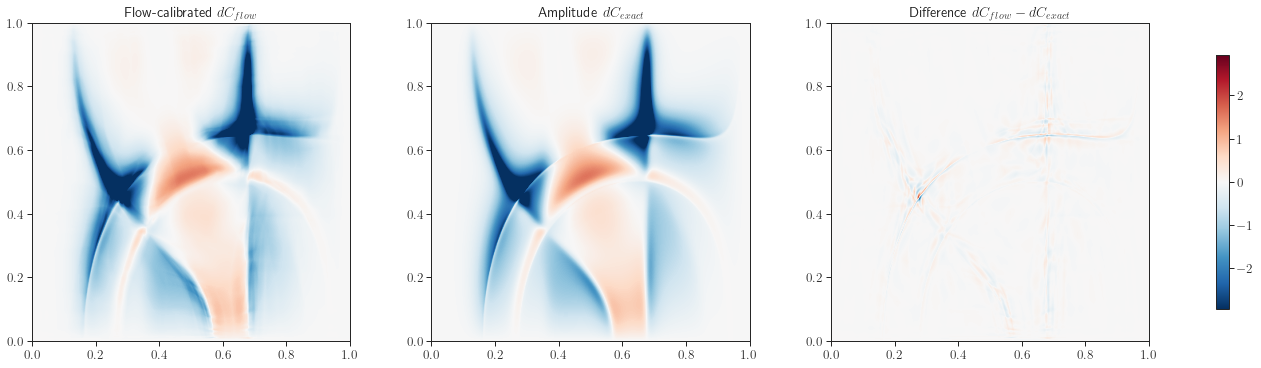

In [23]:
U, V, pts = make_sdp_grid(400, 400)

dC_exact, abJ = compute_c_exact(pts, sdp_obj, flow, dkpp,
                    device=None)

dC_flow_cal= compute_c_flow(pts, flow_even, flow_odd, 
                   gamma_p, gamma_m, device=None)

# Optional: ignore tiny bins
mask = (abJ > 1e-6)

# reshape for plotting
NY, NX = U.shape
dC_exact_img = dC_exact.reshape(NY, NX)
dC_flow_img  = dC_flow_cal.reshape(NY, NX)

compare_dC(U, V, dC_flow_img, dC_exact_img*4/(gamma_p + gamma_m))

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

def plot_C_comparison_mtheta(
    C_flow,
    C_exact,
    *,
    extent=(0, 1, 0, 1),
    cmap="RdBu_r",            # back to previous scheme
    percentile=98,
    flow_title=r"Normalizing-flow estimate: $\mathcal{C}_{\mathrm{flow}}(m',\theta')$",
    exact_title=r"Isobar-model prediction: $\mathcal{C}_{\mathrm{exact}}(m',\theta')$",
    xlabel=r"$m'$",
    ylabel=r"$\theta'$",
    figsize=(12, 4.8),
    dpi=200,
    savepath=None,
):
    """
    Side-by-side comparison of C(m', theta') from a normalizing flow vs exact isobar model.
    - Shared robust, symmetric color normalization (centered at 0)
    - No colorbar
    - y-axis label shown on BOTH panels
    """

    # Robust symmetric color scale shared across panels
    ref = np.concatenate([np.ravel(C_exact), np.ravel(C_flow)])
    ref = ref[np.isfinite(ref)]
    vmax = np.nanpercentile(np.abs(ref), percentile) if ref.size else 1.0
    norm = TwoSlopeNorm(vcenter=0.0, vmin=-vmax, vmax=vmax)

    fig, axs = plt.subplots(1, 2, figsize=figsize, constrained_layout=True, dpi=dpi)

    axs[0].imshow(
        C_flow, origin="lower", extent=extent, norm=norm, cmap=cmap,
        interpolation="nearest", aspect="equal"
    )
    axs[0].set_title(flow_title, pad=8)
    axs[0].set_xlabel(xlabel)
    axs[0].set_ylabel(ylabel)

    axs[1].imshow(
        C_exact, origin="lower", extent=extent, norm=norm, cmap=cmap,
        interpolation="nearest", aspect="equal"
    )
    axs[1].set_title(exact_title, pad=8)
    axs[1].set_xlabel(xlabel)
    axs[1].set_ylabel(ylabel)

    # Subpanel labels
    axs[0].text(0.02, 0.98, "(a)", transform=axs[0].transAxes, va="top", ha="left")
    axs[1].text(0.02, 0.98, "(b)", transform=axs[1].transAxes, va="top", ha="left")

    # Paper-style ticks/spines
    for ax in axs:
        ax.tick_params(direction="out", length=3, width=0.8)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)

    if savepath is not None:
        fig.savefig(savepath, bbox_inches="tight")
    return fig, axs


(<Figure size 3600x1500 with 2 Axes>,
 array([<Axes: title={'center': "Normalizing-flow estimate: $\\mathcal{C}_{\\mathrm{flow}}(m',\\theta')$"}, xlabel="$m'$", ylabel="$\\theta'$">,
        <Axes: title={'center': "Isobar-model prediction: $\\mathcal{C}_{\\mathrm{exact}}(m',\\theta')$"}, xlabel="$m'$", ylabel="$\\theta'$">],
       dtype=object))

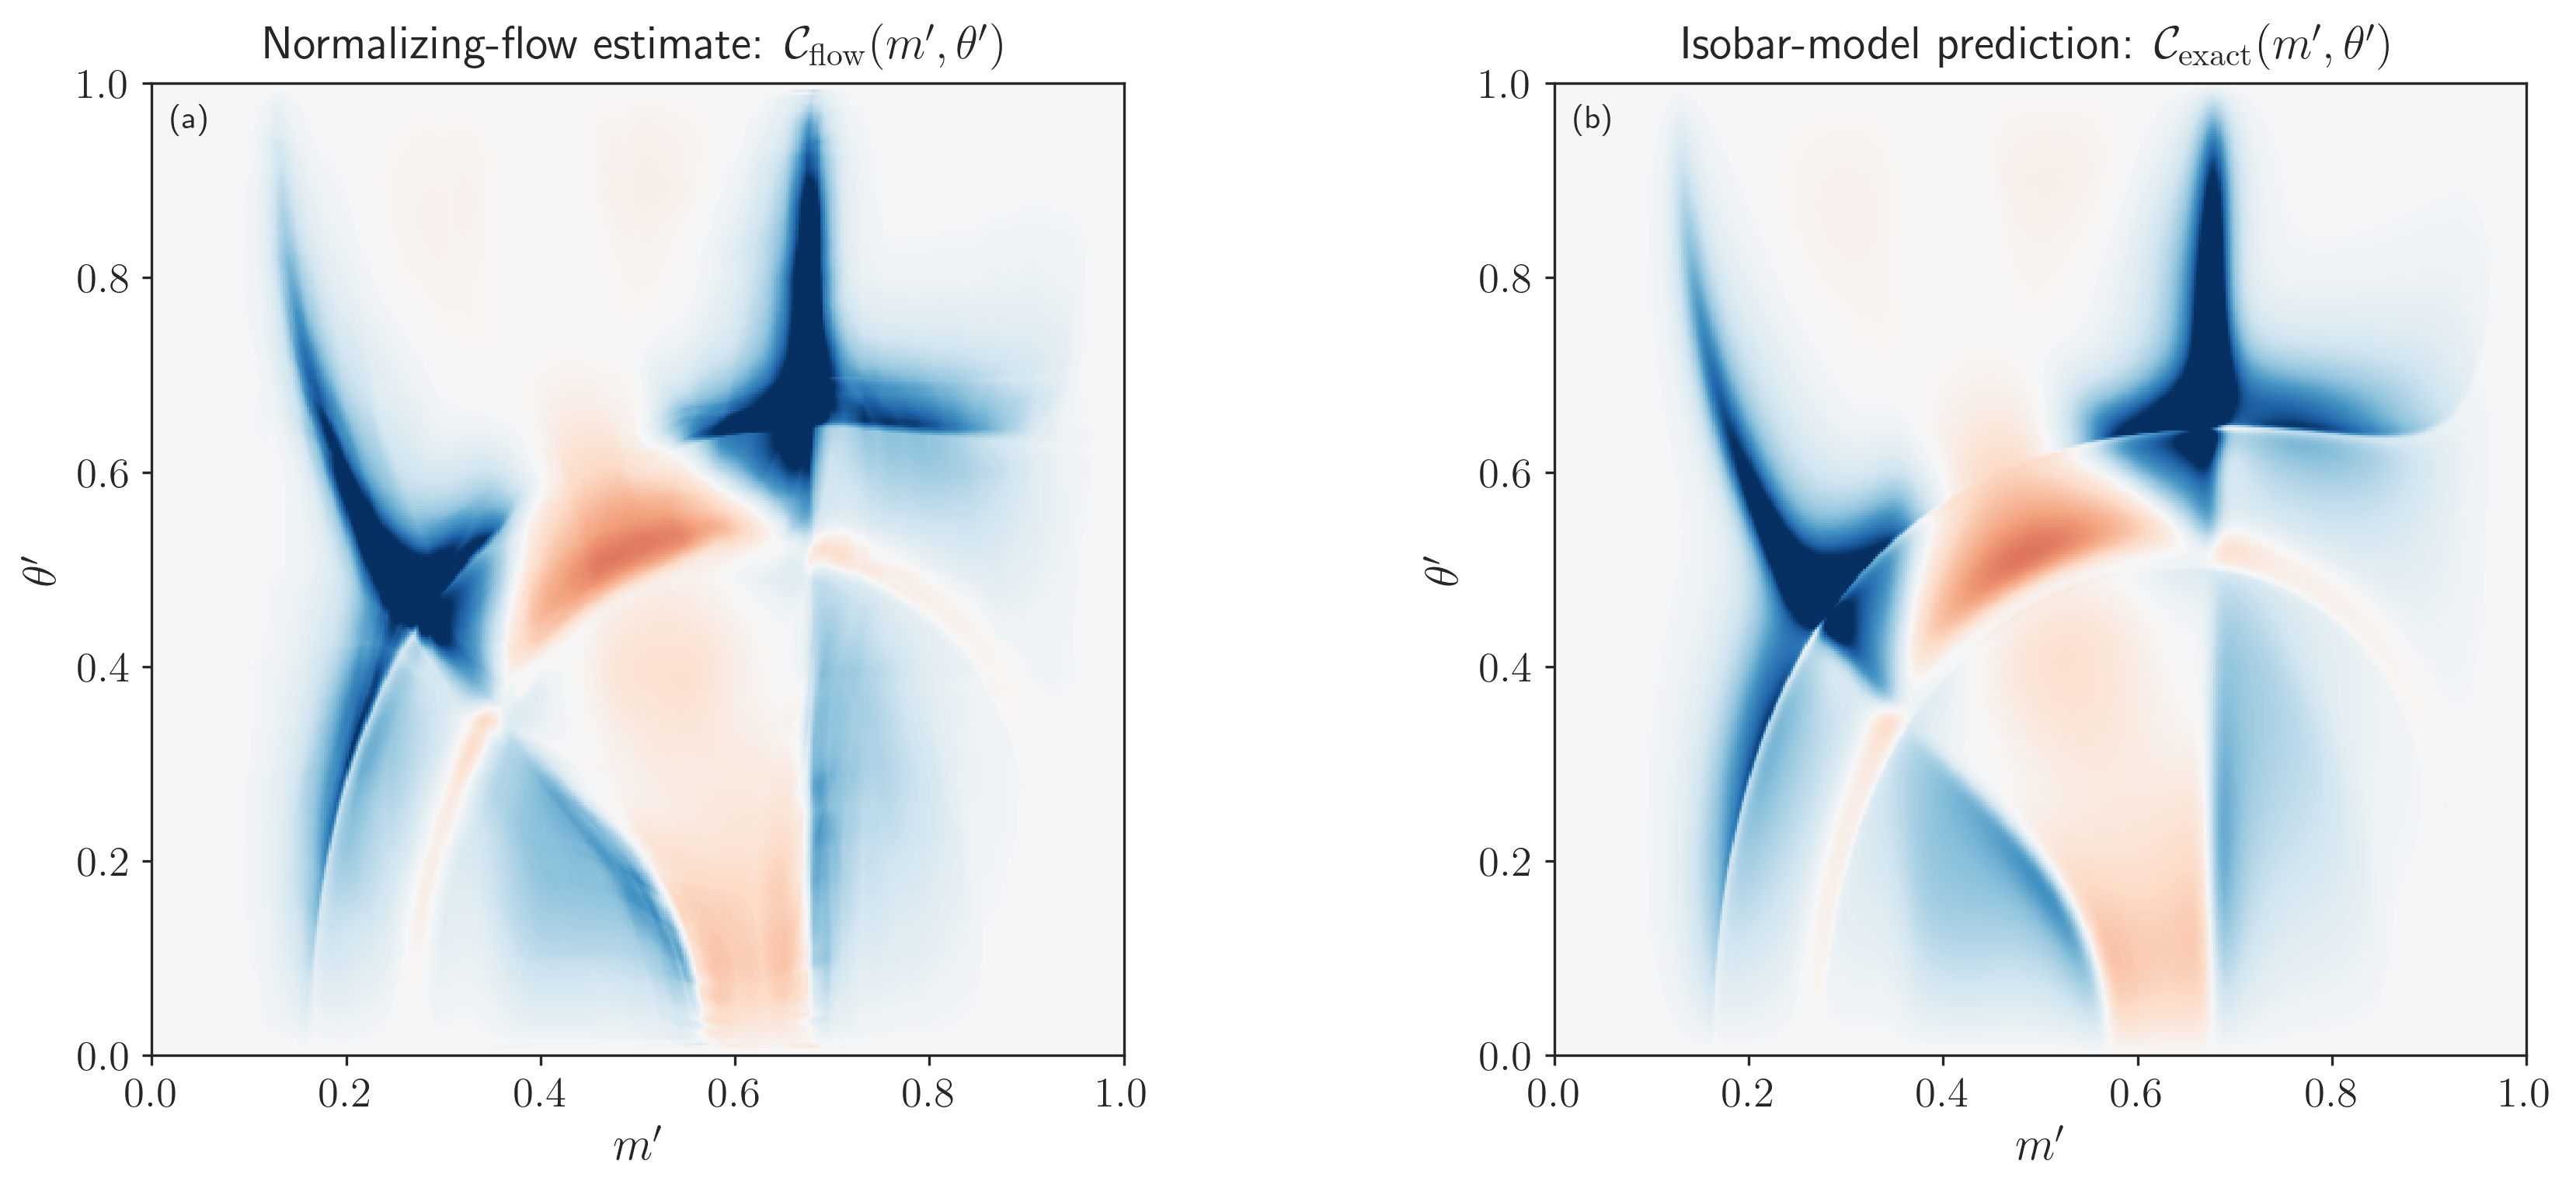

In [25]:
plot_C_comparison_mtheta(
    C_flow=dC_flow_img,
    C_exact=dC_exact_img * 4 / (gamma_p + gamma_m),
    extent=(0, 1, 0, 1),
    figsize=(12, 5),
    dpi=300,
    savepath="C_comparison_mtheta.pdf",
)

---
## 02/09/2026

In [18]:
def fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    dataM_sdp, dataP_sdp, mcM_sdp, mcP_sdp,
    flow_flavor, flow_even, flow_odd, dkpp_model,
    true_rB, true_deltaB, true_gamma,
    sdp_obj, idx=(1,2,3),
    initial_scale=0.2, delta_offset=30, gamma_offset=30,
    device=None, eps=1e-14, Gamma_minus=1, Gamma_plus=1, k=1
):
    # ------------------------------------------------------------
    # Compute interference terms (raw dC, raw dS)
    # ------------------------------------------------------------
    tM = compute_interference_terms(dataM_sdp, flow_flavor, flow_even, flow_odd, dkpp_model, sdp_obj, Gamma_minus, Gamma_plus, idx, device)
    tP = compute_interference_terms(dataP_sdp, flow_flavor, flow_even, flow_odd, dkpp_model, sdp_obj, Gamma_minus, Gamma_plus, idx, device)
    mM = compute_interference_terms(mcM_sdp,   flow_flavor, flow_even, flow_odd, dkpp_model, sdp_obj, Gamma_minus, Gamma_plus, idx, device)
    mP = compute_interference_terms(mcP_sdp,   flow_flavor, flow_even, flow_odd, dkpp_model, sdp_obj, Gamma_minus, Gamma_plus, idx, device)

    # ------------------------------------------------------------
    # HARD CUT: keep only physical points |dC| <= abJ
    # ------------------------------------------------------------
    maskM  = (np.abs(tM['C']) <= 1 * tM['abJ'])
    maskMC = (np.abs(mM['C']) <= 1 * mM['abJ'])
    maskP  = (np.abs(tP['C']) <= 1 * tP['abJ'])
    maskPC = (np.abs(mP['C']) <= 1 * mP['abJ'])

    # Save broken-constraint points (SDP coords) before filtering
    broken = {
        'dataM_sdp': dataM_sdp[~maskM],
        'dataP_sdp': dataP_sdp[~maskP],
        'mcM_sdp':   mcM_sdp[~maskMC],
        'mcP_sdp':   mcP_sdp[~maskPC],
    }

    for key in tM:
        tM[key] = tM[key][maskM]
    for key in tP:
        tP[key] = tP[key][maskP]
    for key in mM:
        mM[key] = mM[key][maskMC]
    for key in mP:
        mP[key] = mP[key][maskPC]
    
    # ------------------------------------------------------------
    # CLAMP: enforce |dC| <= abJ, recompute dS
    # ------------------------------------------------------------
    def clamp_C_recompute_S(t):
        sign_S = np.sign(t['S'])
        t['C'] = np.clip(t['C'], -t['abJ'], t['abJ'])
        t['S'] = sign_S * np.sqrt(t['abJ']**2 - t['C']**2)
        return t

    tM = clamp_C_recompute_S(tM)
    tP = clamp_C_recompute_S(tP)
    mM = clamp_C_recompute_S(mM)
    mP = clamp_C_recompute_S(mP)

    N_expM = len(tM['C'])
    N_expP = len(tP['C'])
    print(N_expM, N_expP)
    # ------------------------------------------------------------
    # Likelihood
    # ------------------------------------------------------------
    def nll(rB, delta, gamma):
        thM = np.radians(delta - gamma)
        thP = np.radians(delta + gamma)
        # data PDFs
        pBm_data = (tM['pFsw'] + rB*rB*tM['pF']
                    + 2*rB*(np.cos(thM)*tM['C'] - np.sin(thM)*tM['S']))
        pBp_data = (tP['pF']   + rB*rB*tP['pFsw']
                    + 2*rB*(np.cos(thP)*tP['C'] + np.sin(thP)*tP['S']))
        pBm_data = _finite_pos(pBm_data, eps)
        pBp_data = _finite_pos(pBp_data, eps)
        # MC normalization (SDP uniform → multiply by J)
        pBm_mc_arr = mM['J'] * (mM['pFsw'] + rB*rB*mM['pF']
                      + 2*rB*(np.cos(thM)*mM['C'] - np.sin(thM)*mM['S']))
        pBp_mc_arr = mP['J'] * (mP['pF']   + rB*rB*mP['pFsw']
                      + 2*rB*(np.cos(thP)*mP['C'] + np.sin(thP)*mP['S']))
        pBm_mc_mean = _finite_pos(pBm_mc_arr, eps).mean()
        pBp_mc_mean = _finite_pos(pBp_mc_arr, eps).mean()
        return (-np.log(pBm_data).sum() + N_expM*np.log(pBm_mc_mean)
                -np.log(pBp_data).sum() + N_expP*np.log(pBp_mc_mean))
    # ------------------------------------------------------------
    # Minuit setup
    # ------------------------------------------------------------
    init_rB    = true_rB * initial_scale
    init_delta = true_deltaB + delta_offset
    init_gamma = true_gamma  + gamma_offset
    m = Minuit(nll, rB=init_rB, delta=init_delta, gamma=init_gamma)
    m.limits['rB']    = (0, 1)
    m.limits['delta'] = (0, 360)
    m.limits['gamma'] = (0, 360)
    m.errors['rB']    = 0.01
    m.errors['delta'] = 2.0
    m.errors['gamma'] = 2.0
    m.errordef = Minuit.LIKELIHOOD

    t0 = time.time(); m.migrad(); m.hesse()
    print(f"Total fit time: {time.time()-t0:.2f}s\n")
    print(f"rB    = {m.values['rB']:.4f} ± {m.errors['rB']:.4f}")
    print(f"delta = {m.values['delta']:.2f}° ± {m.errors['delta']:.2f}°")
    print(f"gamma = {m.values['gamma']:.2f}° ± {m.errors['gamma']:.2f}°")
    print(f"(true rB={true_rB:.4f}, true γ={true_gamma:.2f}°, true δ={true_deltaB:.2f}°)")
    return m, broken

In [155]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m,broken = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m, broken)

41637 42645
Total fit time: 1.76s

rB    = 0.0977 ± 0.0025
delta = 127.10° ± 1.66°
gamma = 68.87° ± 1.68°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.108e+04                  │              Nfcn = 120              │
│ EDM = 2.3e-08 (Goal: 0.0001)     │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└─────────

C:\Users\chinh\AppData\Local\Temp\ipykernel_191760\741457937.py:28: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\chinh\AppData\Local\Temp\ipykernel_191760\741457937.py:28: UserWarning: Glyph 8314 (\N{SUPERSCRIPT PLUS SIGN}) missing from font(s) Arial.
  plt.tight_layout()


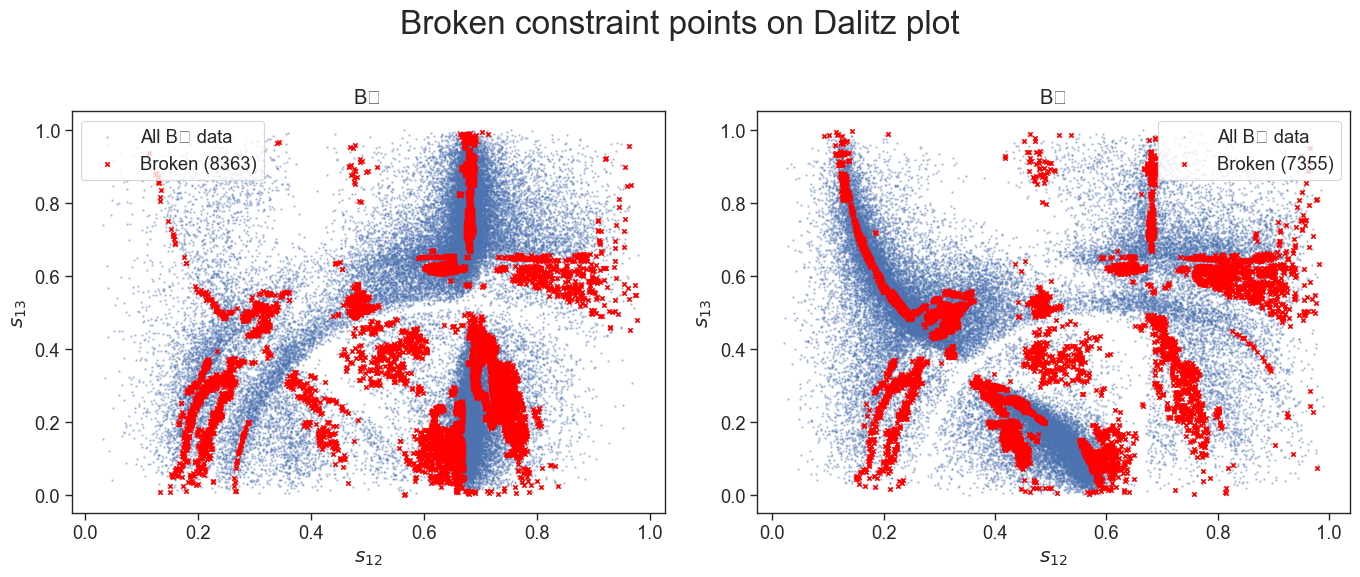

In [156]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# B- Dalitz plot
ax = axes[0]
ax.scatter(dataM_sdp[:, 0], dataM_sdp[:, 1], s=1, alpha=0.3, label='All B⁻ data')
if len(broken['dataM_sdp']) > 0:
    ax.scatter(broken['dataM_sdp'][:, 0], broken['dataM_sdp'][:, 1], 
               s=10, c='red', marker='x', label=f"Broken ({len(broken['dataM_sdp'])})")
ax.set_title('B⁻')
ax.set_xlabel(r'$s_{12}$')
ax.set_ylabel(r'$s_{13}$')
ax.legend()

# B+ Dalitz plot
ax = axes[1]
ax.scatter(dataP_sdp[:, 0], dataP_sdp[:, 1], s=1, alpha=0.3, label='All B⁺ data')
if len(broken['dataP_sdp']) > 0:
    ax.scatter(broken['dataP_sdp'][:, 0], broken['dataP_sdp'][:, 1], 
               s=10, c='red', marker='x', label=f"Broken ({len(broken['dataP_sdp'])})")
ax.set_title('B⁺')
ax.set_xlabel(r'$s_{12}$')
ax.set_ylabel(r'$s_{13}$')
ax.legend()

plt.suptitle('Broken constraint points on Dalitz plot')
plt.tight_layout()
plt.show()

In [160]:
# Model hyperparameters
n_blocks = 12
n_bins = 24
hidden_features = 128

# Initialize the model
flow_odd = create_flow(num_flows = n_blocks, hidden_features = hidden_features, num_bins = n_bins)

# Print total number of parameters
total_params = sum(p.numel() for p in flow_odd.parameters())
print(f"Total # of parameters: {total_params}")

# Load the weights
flow_odd.load_state_dict(
    torch.load('test_seed_odd_constrained.pth', map_location=device)
)
flow_odd.to(device)

# Set the flow to evaluation mode
flow_odd.eval()

Total # of parameters: 311124


Flow(
  (_transform): CompositeTransform(
    (_transforms): ModuleList(
      (0): InverseTransform(
        (_transform): Sigmoid()
      )
      (1): PiecewiseRationalQuadraticCouplingTransform(
        (transform_net): MLP(
          (backbone): Sequential(
            (0): Linear(in_features=1, out_features=128, bias=True)
            (1): SiLU()
            (2): Linear(in_features=128, out_features=128, bias=True)
            (3): SiLU()
          )
          (head): Linear(in_features=128, out_features=71, bias=True)
        )
      )
      (2): RandomPermutation()
      (3): PiecewiseRationalQuadraticCouplingTransform(
        (transform_net): MLP(
          (backbone): Sequential(
            (0): Linear(in_features=1, out_features=128, bias=True)
            (1): SiLU()
            (2): Linear(in_features=128, out_features=128, bias=True)
            (3): SiLU()
          )
          (head): Linear(in_features=128, out_features=71, bias=True)
        )
      )
      (4): Rand

In [158]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m,broken = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m, broken)

44153 42114
Total fit time: 1.15s

rB    = 0.0941 ± 0.0025
delta = 127.51° ± 1.72°
gamma = 65.89° ± 1.73°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.687e+04                  │              Nfcn = 108              │
│ EDM = 4e-08 (Goal: 0.0001)       │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└─────────

C:\Users\chinh\AppData\Local\Temp\ipykernel_191760\741457937.py:28: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\chinh\AppData\Local\Temp\ipykernel_191760\741457937.py:28: UserWarning: Glyph 8314 (\N{SUPERSCRIPT PLUS SIGN}) missing from font(s) Arial.
  plt.tight_layout()


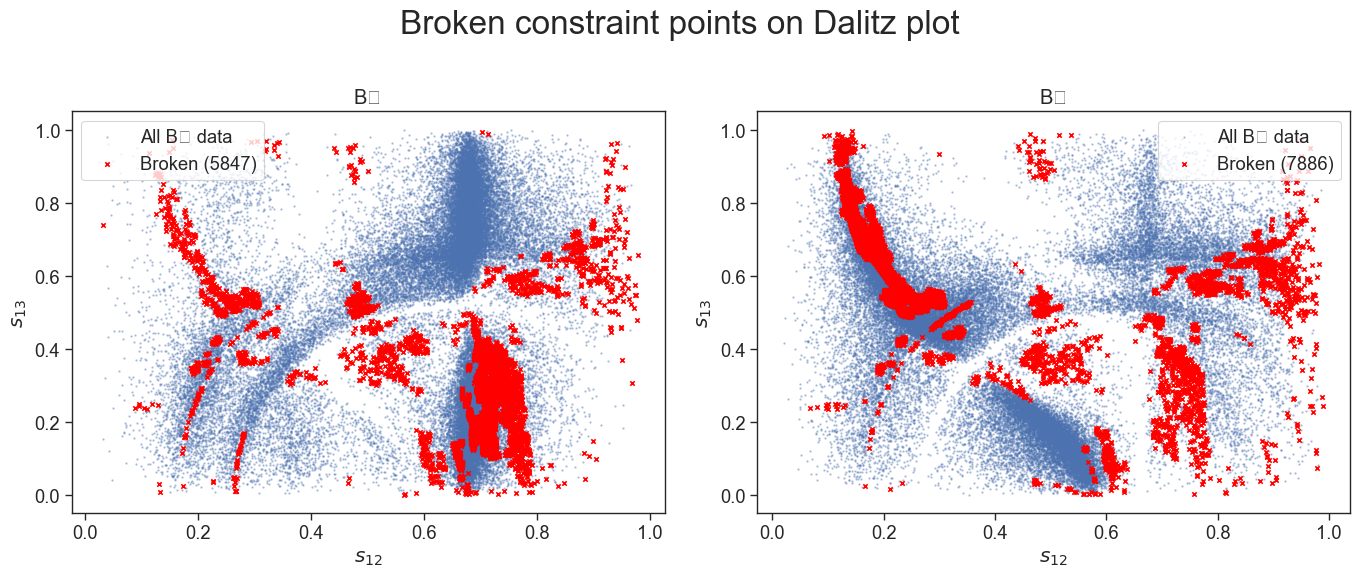

In [159]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# B- Dalitz plot
ax = axes[0]
ax.scatter(dataM_sdp[:, 0], dataM_sdp[:, 1], s=1, alpha=0.3, label='All B⁻ data')
if len(broken['dataM_sdp']) > 0:
    ax.scatter(broken['dataM_sdp'][:, 0], broken['dataM_sdp'][:, 1], 
               s=10, c='red', marker='x', label=f"Broken ({len(broken['dataM_sdp'])})")
ax.set_title('B⁻')
ax.set_xlabel(r'$s_{12}$')
ax.set_ylabel(r'$s_{13}$')
ax.legend()

# B+ Dalitz plot
ax = axes[1]
ax.scatter(dataP_sdp[:, 0], dataP_sdp[:, 1], s=1, alpha=0.3, label='All B⁺ data')
if len(broken['dataP_sdp']) > 0:
    ax.scatter(broken['dataP_sdp'][:, 0], broken['dataP_sdp'][:, 1], 
               s=10, c='red', marker='x', label=f"Broken ({len(broken['dataP_sdp'])})")
ax.set_title('B⁺')
ax.set_xlabel(r'$s_{12}$')
ax.set_ylabel(r'$s_{13}$')
ax.legend()

plt.suptitle('Broken constraint points on Dalitz plot')
plt.tight_layout()
plt.show()

In [161]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m,broken = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m, broken)

44856 41418
Total fit time: 1.05s

rB    = 0.0988 ± 0.0025
delta = 129.28° ± 1.64°
gamma = 68.16° ± 1.66°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.424e+04                  │              Nfcn = 97               │
│ EDM = 6.47e-07 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└─────────

C:\Users\chinh\AppData\Local\Temp\ipykernel_191760\741457937.py:28: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\chinh\AppData\Local\Temp\ipykernel_191760\741457937.py:28: UserWarning: Glyph 8314 (\N{SUPERSCRIPT PLUS SIGN}) missing from font(s) Arial.
  plt.tight_layout()


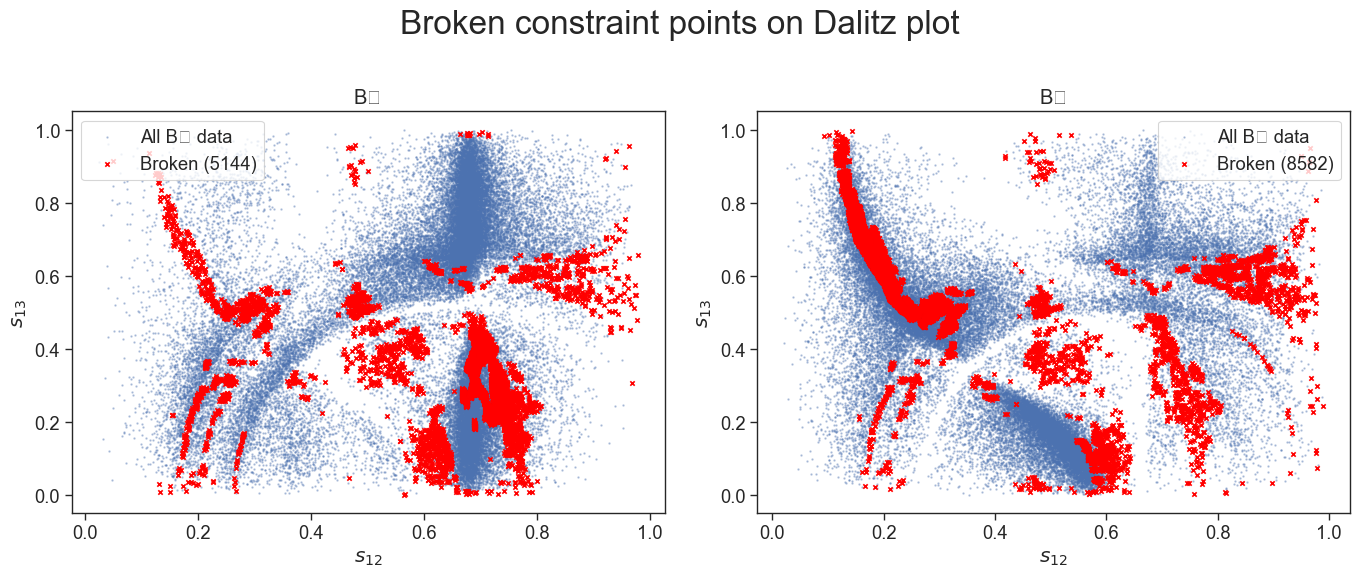

In [162]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# B- Dalitz plot
ax = axes[0]
ax.scatter(dataM_sdp[:, 0], dataM_sdp[:, 1], s=1, alpha=0.3, label='All B⁻ data')
if len(broken['dataM_sdp']) > 0:
    ax.scatter(broken['dataM_sdp'][:, 0], broken['dataM_sdp'][:, 1], 
               s=10, c='red', marker='x', label=f"Broken ({len(broken['dataM_sdp'])})")
ax.set_title('B⁻')
ax.set_xlabel(r'$s_{12}$')
ax.set_ylabel(r'$s_{13}$')
ax.legend()

# B+ Dalitz plot
ax = axes[1]
ax.scatter(dataP_sdp[:, 0], dataP_sdp[:, 1], s=1, alpha=0.3, label='All B⁺ data')
if len(broken['dataP_sdp']) > 0:
    ax.scatter(broken['dataP_sdp'][:, 0], broken['dataP_sdp'][:, 1], 
               s=10, c='red', marker='x', label=f"Broken ({len(broken['dataP_sdp'])})")
ax.set_title('B⁺')
ax.set_xlabel(r'$s_{12}$')
ax.set_ylabel(r'$s_{13}$')
ax.legend()

plt.suptitle('Broken constraint points on Dalitz plot')
plt.tight_layout()
plt.show()

In [165]:
import random
import time
import glob
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# Ensemble fit: randomly select flows 25 times and compile results
# ============================================================================

n_trials = 50
n_blocks = 16
n_bins = 16
hidden_features = 128

# Get list of model files from each ensemble directory
def get_model_files(ensemble_dir):
    files = sorted(glob.glob(f"{ensemble_dir}/trial_seed*.pth"))
    return [f for f in files if not f.endswith('_best.pth')]

flavor_files = get_model_files("test_ensemble_2e6")
odd_files = get_model_files("test_ensemble_odd_2e6")
even_files = get_model_files("test_ensemble_even_2e6")

# Storage for results and errors
results_rB = []
results_delta = []
results_gamma = []
errors_rB = []
errors_delta = []
errors_gamma = []

for i in range(n_trials):
    print(f"\n{'='*60}")
    print(f"Trial {i+1}/{n_trials}")
    print(f"{'='*60}")
    
    # Randomly select one model from each ensemble
    flavor_path = random.choice(flavor_files)
    odd_path = random.choice(odd_files)
    even_path = random.choice(even_files)
    
    print(f"  flavor: {flavor_path}")
    print(f"  odd:    {odd_path}")
    print(f"  even:   {even_path}")
    
    # Load flavor flow
    flow = create_flow(num_flows=12, hidden_features=hidden_features, num_bins=24)
    flow.load_state_dict(torch.load(flavor_path, map_location=device), strict=False)
    flow.to(device)
    flow.eval()
    
    # Load odd flow
    flow_odd = create_flow(num_flows=12, hidden_features=hidden_features, num_bins=24)
    flow_odd.load_state_dict(torch.load(odd_path, map_location=device), strict=False)
    flow_odd.to(device)
    flow_odd.eval()
    
    # Load even flow
    flow_even = create_flow(num_flows=12, hidden_features=hidden_features, num_bins=24)
    flow_even.load_state_dict(torch.load(even_path, map_location=device), strict=False)
    flow_even.to(device)
    flow_even.eval()
    
    # Run the fit
    m,_ = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
        dataM_sdp=dataM_sdp,
        dataP_sdp=dataP_sdp,
        mcM_sdp=mcM_sdp,
        mcP_sdp=mcP_sdp,
        flow_flavor=flow,
        flow_even=flow_even,
        flow_odd=flow_odd,
        dkpp_model=dkpp,
        true_rB=true_rB,
        true_deltaB=true_deltaB * 180 / np.pi,
        true_gamma=true_gamma * 180 / np.pi,
        sdp_obj=sdp_obj,
        idx=(1, 2, 3),
        initial_scale=0.2,
        delta_offset=30,
        gamma_offset=30,
        device=device,
        Gamma_minus=gamma_m,
        Gamma_plus=gamma_p,
    )
    
    # Store values and errors
    results_rB.append(m.values['rB'])
    results_delta.append(m.values['delta'])
    results_gamma.append(m.values['gamma'])
    errors_rB.append(m.errors['rB'])
    errors_delta.append(m.errors['delta'])
    errors_gamma.append(m.errors['gamma'])

results_rB = np.array(results_rB)
results_delta = np.array(results_delta)
results_gamma = np.array(results_gamma)
errors_rB = np.array(errors_rB)
errors_delta = np.array(errors_delta)
errors_gamma = np.array(errors_gamma)

# ============================================================================
# Compute errors
# ============================================================================
print(f"\n{'='*60}")
print("SUMMARY")
print(f"{'='*60}")

for name, vals, errs, true_val in [
    ("rB", results_rB, errors_rB, true_rB),
    ("delta", results_delta, errors_delta, true_deltaB * 180 / np.pi),
    ("gamma", results_gamma, errors_gamma, true_gamma * 180 / np.pi),
]:
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    unit = "°" if name != "rB" else ""
    print(f"{name}: mean = {vals.mean():.4f}{unit}, "
          f"σ_ens = {sigma_ensemble:.4f}, σ_fit = {sigma_fit:.4f}, "
          f"σ_tot = {sigma_total:.4f}  (true = {true_val:.4f})")



Trial 1/50
  flavor: test_ensemble_2e6\trial_seed25.pth
  odd:    test_ensemble_odd_2e6\trial_seed10.pth
  even:   test_ensemble_even_2e6\trial_seed28.pth


c:\Users\chinh\anaconda3\Lib\site-packages\nflows\transforms\coupling.py:481: UserWarning: Inputs to the softmax are not scaled down: initialization might be bad.
  warnings.warn(


43764 41418
Total fit time: 1.13s

rB    = 0.0993 ± 0.0025
delta = 128.33° ± 1.67°
gamma = 66.33° ± 1.69°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 2/50
  flavor: test_ensemble_2e6\trial_seed15.pth
  odd:    test_ensemble_odd_2e6\trial_seed15.pth
  even:   test_ensemble_even_2e6\trial_seed24.pth
40966 42707
Total fit time: 1.26s

rB    = 0.0939 ± 0.0026
delta = 128.71° ± 1.71°
gamma = 69.81° ± 1.73°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 3/50
  flavor: test_ensemble_2e6\trial_seed2.pth
  odd:    test_ensemble_odd_2e6\trial_seed4.pth
  even:   test_ensemble_even_2e6\trial_seed11.pth
42060 41182
Total fit time: 1.04s

rB    = 0.0977 ± 0.0026
delta = 126.09° ± 1.70°
gamma = 69.42° ± 1.73°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 4/50
  flavor: test_ensemble_2e6\trial_seed22.pth
  odd:    test_ensemble_odd_2e6\trial_seed2.pth
  even:   test_ensemble_even_2e6\trial_seed29.pth
39517 43732
Total fit time: 1.15s

rB    = 0.0936 ± 0.0025
delta = 129.52

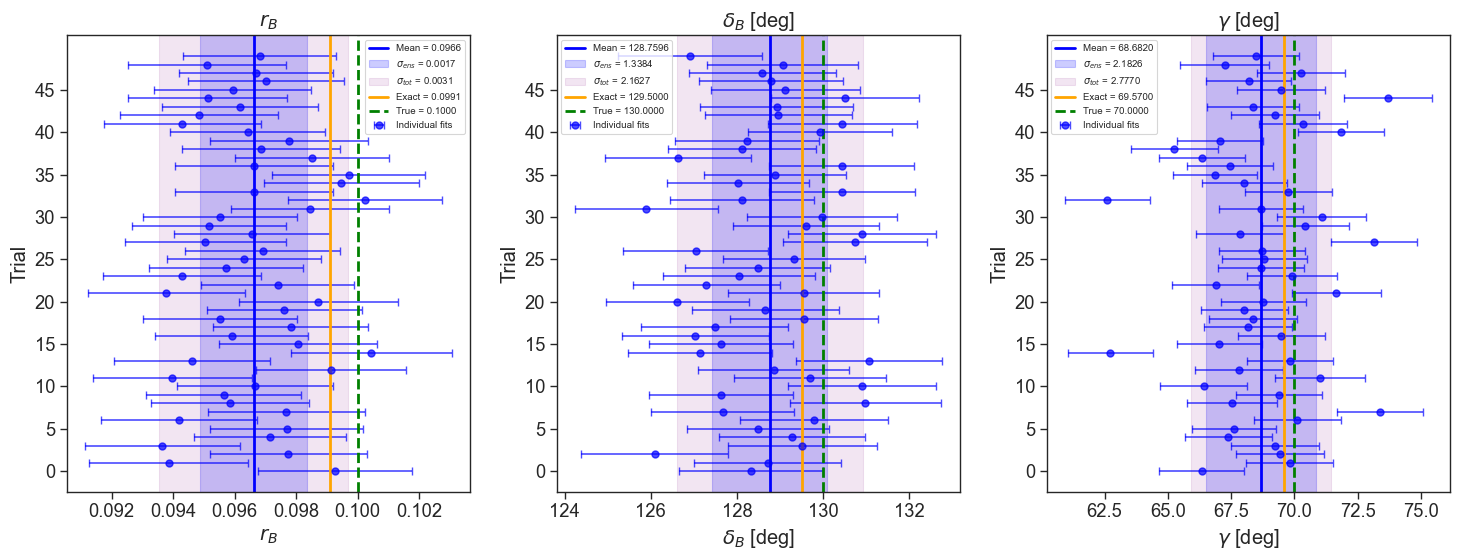


Parameter          Mean      σ_fit      σ_ens      σ_tot       True
rB               0.0966     0.0025     0.0017     0.0031     0.1000
delta [°]      128.7596     1.6988     1.3384     2.1627   130.0000
gamma [°]       68.6820     1.7169     2.1826     2.7770    70.0000


In [167]:
exact_rB = 0.0991
exact_delta = 129.5
exact_gamma = 69.57

# ============================================================================
# Plot results: stacked values with error bars
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

params = [
    (results_rB, errors_rB, exact_rB, r"$r_B$", true_rB),
    (results_delta, errors_delta, exact_delta, r"$\delta_B$ [deg]", true_deltaB * 180 / np.pi),
    (results_gamma, errors_gamma, exact_gamma, r"$\gamma$ [deg]", true_gamma * 180 / np.pi),
]

for ax, (vals, errs, exact_val, label, true_val) in zip(axes, params):
    # Compute errors
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    mean_val = vals.mean()
    
    # Y positions for stacking points
    y_pos = np.arange(len(vals))
    
    # Plot individual fits with their Minuit errors (horizontal error bars)
    ax.errorbar(vals, y_pos, xerr=errs, fmt='o', color='blue', 
                capsize=3, markersize=5, alpha=0.7, label='Individual fits')
    
    # Mean with ensemble spread
    ax.axvline(mean_val, color='blue', linestyle='-', linewidth=2, 
               label=f'Mean = {mean_val:.4f}')
    ax.axvspan(mean_val - sigma_ensemble, mean_val + sigma_ensemble, 
               alpha=0.2, color='blue', label=f'$\\sigma_{{ens}}$ = {sigma_ensemble:.4f}')
    
    # Total error band
    ax.axvspan(mean_val - sigma_total, mean_val + sigma_total, 
               alpha=0.1, color='purple', label=f'$\\sigma_{{tot}}$ = {sigma_total:.4f}')
    
    # Exact result
    ax.axvline(exact_val, color='orange', linestyle='-', linewidth=2, 
               label=f'Exact = {exact_val:.4f}')
    
    # True value
    ax.axvline(true_val, color='green', linestyle='--', linewidth=2, 
               label=f'True = {true_val:.4f}')
    
    ax.set_ylabel('Trial')
    ax.set_xlabel(label)
    ax.set_title(label)
    ax.legend(fontsize=7, loc='best')
    ax.set_yticks(y_pos[::5])  # Show every 5th trial label

plt.tight_layout()
plt.savefig("ensemble_fit_results.png", dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print(f"\n{'='*70}")
print(f"{'Parameter':<12} {'Mean':>10} {'σ_fit':>10} {'σ_ens':>10} {'σ_tot':>10} {'True':>10}")
print(f"{'='*70}")
for name, vals, errs, true_val in [
    ("rB", results_rB, errors_rB, true_rB),
    ("delta [°]", results_delta, errors_delta, true_deltaB * 180 / np.pi),
    ("gamma [°]", results_gamma, errors_gamma, true_gamma * 180 / np.pi),
]:
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    print(f"{name:<12} {vals.mean():>10.4f} {sigma_fit:>10.4f} {sigma_ensemble:>10.4f} {sigma_total:>10.4f} {true_val:>10.4f}")


In [49]:
def fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    dataM_sdp, dataP_sdp, mcM_sdp, mcP_sdp,
    flow_flavor, flow_even, flow_odd, dkpp_model,
    true_rB, true_deltaB, true_gamma,
    sdp_obj, idx=(1,2,3),
    initial_scale=0.2, delta_offset=30, gamma_offset=30,
    device=None, eps=1e-14, Gamma_minus=1, Gamma_plus=1, k=1
):
    # ------------------------------------------------------------
    # Compute interference terms (raw dC, raw dS)
    # ------------------------------------------------------------
    tM = compute_interference_terms(dataM_sdp, flow_flavor, flow_even, flow_odd, dkpp_model, sdp_obj, Gamma_minus, Gamma_plus, idx, device)
    tP = compute_interference_terms(dataP_sdp, flow_flavor, flow_even, flow_odd, dkpp_model, sdp_obj, Gamma_minus, Gamma_plus, idx, device)
    mM = compute_interference_terms(mcM_sdp,   flow_flavor, flow_even, flow_odd, dkpp_model, sdp_obj, Gamma_minus, Gamma_plus, idx, device)
    mP = compute_interference_terms(mcP_sdp,   flow_flavor, flow_even, flow_odd, dkpp_model, sdp_obj, Gamma_minus, Gamma_plus, idx, device)

    # ------------------------------------------------------------
    # HARD CUT: keep only physical points |dC| <= abJ
    # ------------------------------------------------------------
    maskM  = (np.abs(tM['C']) <= 1.2 * tM['abJ'])
    maskMC = (np.abs(mM['C']) <= 1.2 * mM['abJ'])
    maskP  = (np.abs(tP['C']) <= 1.2 * tP['abJ'])
    maskPC = (np.abs(mP['C']) <= 1.2 * mP['abJ'])

    # Save broken-constraint points (SDP coords) before filtering
    broken = {
        'dataM_sdp': dataM_sdp[~maskM],
        'dataP_sdp': dataP_sdp[~maskP],
        'mcM_sdp':   mcM_sdp[~maskMC],
        'mcP_sdp':   mcP_sdp[~maskPC],
    }

    for key in tM:
        tM[key] = tM[key][maskM]
    for key in tP:
        tP[key] = tP[key][maskP]
    for key in mM:
        mM[key] = mM[key][maskMC]
    for key in mP:
        mP[key] = mP[key][maskPC]
    
    # ------------------------------------------------------------
    # CLAMP: enforce |dC| <= abJ, recompute dS
    # ------------------------------------------------------------
    def clamp_C_recompute_S(t):
        sign_S = np.sign(t['S'])
        t['C'] = np.clip(t['C'], -t['abJ'], t['abJ'])
        t['S'] = sign_S * np.sqrt(t['abJ']**2 - t['C']**2)
        return t

    tM = clamp_C_recompute_S(tM)
    tP = clamp_C_recompute_S(tP)
    mM = clamp_C_recompute_S(mM)
    mP = clamp_C_recompute_S(mP)

    N_expM = len(tM['C'])
    N_expP = len(tP['C'])
    print(N_expM, N_expP)
    # ------------------------------------------------------------
    # Likelihood
    # ------------------------------------------------------------
    def nll(rB, delta, gamma):
        thM = np.radians(delta - gamma)
        thP = np.radians(delta + gamma)
        # data PDFs
        pBm_data = (tM['pFsw'] + rB*rB*tM['pF']
                    + 2*rB*(np.cos(thM)*tM['C'] - np.sin(thM)*tM['S']))
        pBp_data = (tP['pF']   + rB*rB*tP['pFsw']
                    + 2*rB*(np.cos(thP)*tP['C'] + np.sin(thP)*tP['S']))
        pBm_data = _finite_pos(pBm_data, eps)
        pBp_data = _finite_pos(pBp_data, eps)
        # MC normalization (SDP uniform → multiply by J)
        pBm_mc_arr = mM['J'] * (mM['pFsw'] + rB*rB*mM['pF']
                      + 2*rB*(np.cos(thM)*mM['C'] - np.sin(thM)*mM['S']))
        pBp_mc_arr = mP['J'] * (mP['pF']   + rB*rB*mP['pFsw']
                      + 2*rB*(np.cos(thP)*mP['C'] + np.sin(thP)*mP['S']))
        pBm_mc_mean = _finite_pos(pBm_mc_arr, eps).mean()
        pBp_mc_mean = _finite_pos(pBp_mc_arr, eps).mean()
        return (-np.log(pBm_data).sum() + N_expM*np.log(pBm_mc_mean)
                -np.log(pBp_data).sum() + N_expP*np.log(pBp_mc_mean))
    # ------------------------------------------------------------
    # Minuit setup
    # ------------------------------------------------------------
    init_rB    = true_rB * initial_scale
    init_delta = true_deltaB + delta_offset
    init_gamma = true_gamma  + gamma_offset
    m = Minuit(nll, rB=init_rB, delta=init_delta, gamma=init_gamma)
    m.limits['rB']    = (0, 1)
    m.limits['delta'] = (0, 360)
    m.limits['gamma'] = (0, 360)
    m.errors['rB']    = 0.01
    m.errors['delta'] = 2.0
    m.errors['gamma'] = 2.0
    m.errordef = Minuit.LIKELIHOOD

    t0 = time.time(); m.migrad(); m.hesse()
    print(f"Total fit time: {time.time()-t0:.2f}s\n")
    print(f"rB    = {m.values['rB']:.4f} ± {m.errors['rB']:.4f}")
    print(f"delta = {m.values['delta']:.2f}° ± {m.errors['delta']:.2f}°")
    print(f"gamma = {m.values['gamma']:.2f}° ± {m.errors['gamma']:.2f}°")
    print(f"(true rB={true_rB:.4f}, true γ={true_gamma:.2f}°, true δ={true_deltaB:.2f}°)")
    return m, broken

In [169]:
import random
import time
import glob
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# Ensemble fit: randomly select flows 25 times and compile results
# ============================================================================

n_trials = 50
n_blocks = 16
n_bins = 16
hidden_features = 128

# Get list of model files from each ensemble directory
def get_model_files(ensemble_dir):
    files = sorted(glob.glob(f"{ensemble_dir}/trial_seed*.pth"))
    return [f for f in files if not f.endswith('_best.pth')]

flavor_files = get_model_files("test_ensemble_2e6")
odd_files = get_model_files("test_ensemble_odd_2e6")
even_files = get_model_files("test_ensemble_even_2e6")

# Storage for results and errors
results_rB = []
results_delta = []
results_gamma = []
errors_rB = []
errors_delta = []
errors_gamma = []

for i in range(n_trials):
    print(f"\n{'='*60}")
    print(f"Trial {i+1}/{n_trials}")
    print(f"{'='*60}")
    
    # Randomly select one model from each ensemble
    flavor_path = random.choice(flavor_files)
    odd_path = random.choice(odd_files)
    even_path = random.choice(even_files)
    
    print(f"  flavor: {flavor_path}")
    print(f"  odd:    {odd_path}")
    print(f"  even:   {even_path}")
    
    # Load flavor flow
    flow = create_flow(num_flows=12, hidden_features=hidden_features, num_bins=24)
    flow.load_state_dict(torch.load(flavor_path, map_location=device), strict=False)
    flow.to(device)
    flow.eval()
    
    # Load odd flow
    flow_odd = create_flow(num_flows=12, hidden_features=hidden_features, num_bins=24)
    flow_odd.load_state_dict(torch.load(odd_path, map_location=device), strict=False)
    flow_odd.to(device)
    flow_odd.eval()
    
    # Load even flow
    flow_even = create_flow(num_flows=12, hidden_features=hidden_features, num_bins=24)
    flow_even.load_state_dict(torch.load(even_path, map_location=device), strict=False)
    flow_even.to(device)
    flow_even.eval()
    
    # Run the fit
    m,_ = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
        dataM_sdp=dataM_sdp,
        dataP_sdp=dataP_sdp,
        mcM_sdp=mcM_sdp,
        mcP_sdp=mcP_sdp,
        flow_flavor=flow,
        flow_even=flow_even,
        flow_odd=flow_odd,
        dkpp_model=dkpp,
        true_rB=true_rB,
        true_deltaB=true_deltaB * 180 / np.pi,
        true_gamma=true_gamma * 180 / np.pi,
        sdp_obj=sdp_obj,
        idx=(1, 2, 3),
        initial_scale=0.2,
        delta_offset=30,
        gamma_offset=30,
        device=device,
        Gamma_minus=gamma_m,
        Gamma_plus=gamma_p,
    )
    
    # Store values and errors
    results_rB.append(m.values['rB'])
    results_delta.append(m.values['delta'])
    results_gamma.append(m.values['gamma'])
    errors_rB.append(m.errors['rB'])
    errors_delta.append(m.errors['delta'])
    errors_gamma.append(m.errors['gamma'])

results_rB = np.array(results_rB)
results_delta = np.array(results_delta)
results_gamma = np.array(results_gamma)
errors_rB = np.array(errors_rB)
errors_delta = np.array(errors_delta)
errors_gamma = np.array(errors_gamma)

# ============================================================================
# Compute errors
# ============================================================================
print(f"\n{'='*60}")
print("SUMMARY")
print(f"{'='*60}")

for name, vals, errs, true_val in [
    ("rB", results_rB, errors_rB, true_rB),
    ("delta", results_delta, errors_delta, true_deltaB * 180 / np.pi),
    ("gamma", results_gamma, errors_gamma, true_gamma * 180 / np.pi),
]:
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    unit = "°" if name != "rB" else ""
    print(f"{name}: mean = {vals.mean():.4f}{unit}, "
          f"σ_ens = {sigma_ensemble:.4f}, σ_fit = {sigma_fit:.4f}, "
          f"σ_tot = {sigma_total:.4f}  (true = {true_val:.4f})")



Trial 1/50
  flavor: test_ensemble_2e6\trial_seed23.pth
  odd:    test_ensemble_odd_2e6\trial_seed4.pth
  even:   test_ensemble_even_2e6\trial_seed25.pth


c:\Users\chinh\anaconda3\Lib\site-packages\nflows\transforms\coupling.py:481: UserWarning: Inputs to the softmax are not scaled down: initialization might be bad.
  warnings.warn(


49651 49728
Total fit time: 1.44s

rB    = 0.0988 ± 0.0024
delta = 127.10° ± 1.55°
gamma = 67.65° ± 1.56°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 2/50
  flavor: test_ensemble_2e6\trial_seed13.pth
  odd:    test_ensemble_odd_2e6\trial_seed5.pth
  even:   test_ensemble_even_2e6\trial_seed20.pth
49606 49697
Total fit time: 1.36s

rB    = 0.0976 ± 0.0024
delta = 129.27° ± 1.56°
gamma = 69.00° ± 1.57°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 3/50
  flavor: test_ensemble_2e6\trial_seed4.pth
  odd:    test_ensemble_odd_2e6\trial_seed1.pth
  even:   test_ensemble_even_2e6\trial_seed20.pth
49447 49839
Total fit time: 1.29s

rB    = 0.0988 ± 0.0024
delta = 127.81° ± 1.55°
gamma = 68.57° ± 1.56°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 4/50
  flavor: test_ensemble_2e6\trial_seed1.pth
  odd:    test_ensemble_odd_2e6\trial_seed8.pth
  even:   test_ensemble_even_2e6\trial_seed23.pth
49697 49839
Total fit time: 1.32s

rB    = 0.0987 ± 0.0024
delta = 131.24° 

In [21]:
def fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    dataM_sdp, dataP_sdp, mcM_sdp, mcP_sdp,
    flow_flavor, flow_even, flow_odd, dkpp_model,
    true_rB, true_deltaB, true_gamma,
    sdp_obj, idx=(1,2,3),
    initial_scale=0.2, delta_offset=30, gamma_offset=30,
    device=None, eps=1e-14, Gamma_minus=1, Gamma_plus=1, k=1
):
    # ------------------------------------------------------------
    # Compute interference terms (raw dC, raw dS)
    # ------------------------------------------------------------
    tM = compute_interference_terms(dataM_sdp, flow_flavor, flow_even, flow_odd, dkpp_model, sdp_obj, Gamma_minus, Gamma_plus, idx, device)
    tP = compute_interference_terms(dataP_sdp, flow_flavor, flow_even, flow_odd, dkpp_model, sdp_obj, Gamma_minus, Gamma_plus, idx, device)
    mM = compute_interference_terms(mcM_sdp,   flow_flavor, flow_even, flow_odd, dkpp_model, sdp_obj, Gamma_minus, Gamma_plus, idx, device)
    mP = compute_interference_terms(mcP_sdp,   flow_flavor, flow_even, flow_odd, dkpp_model, sdp_obj, Gamma_minus, Gamma_plus, idx, device)

    # ------------------------------------------------------------
    # HARD CUT: keep only physical points |dC| <= abJ
    # ------------------------------------------------------------
    maskM  = (np.abs(tM['C']) <= 1 * tM['abJ'])
    maskMC = (np.abs(mM['C']) <= 1 * mM['abJ'])
    maskP  = (np.abs(tP['C']) <= 1* tP['abJ'])
    maskPC = (np.abs(mP['C']) <= 1 * mP['abJ'])

    # Save broken-constraint points (SDP coords) before filtering
    broken = {
        'dataM_sdp': dataM_sdp[~maskM],
        'dataP_sdp': dataP_sdp[~maskP],
        'mcM_sdp':   mcM_sdp[~maskMC],
        'mcP_sdp':   mcP_sdp[~maskPC],
    }

    for key in tM:
        tM[key] = tM[key][maskM]
    for key in tP:
        tP[key] = tP[key][maskP]
    for key in mM:
        mM[key] = mM[key][maskMC]
    for key in mP:
        mP[key] = mP[key][maskPC]
    
    # ------------------------------------------------------------
    # CLAMP: enforce |dC| <= abJ, recompute dS
    # ------------------------------------------------------------
    def clamp_C_recompute_S(t):
        sign_S = np.sign(t['S'])
        t['C'] = np.clip(t['C'], -t['abJ'], t['abJ'])
        t['S'] = sign_S * np.sqrt(t['abJ']**2 - t['C']**2)
        return t

    tM = clamp_C_recompute_S(tM)
    tP = clamp_C_recompute_S(tP)
    mM = clamp_C_recompute_S(mM)
    mP = clamp_C_recompute_S(mP)

    N_expM = len(tM['C'])
    N_expP = len(tP['C'])
    print(N_expM, N_expP)
    # ------------------------------------------------------------
    # Likelihood
    # ------------------------------------------------------------
    def nll(rB, delta, gamma):
        thM = np.radians(delta - gamma)
        thP = np.radians(delta + gamma)
        # data PDFs
        pBm_data = (tM['pFsw'] + rB*rB*tM['pF']
                    + 2*rB*(np.cos(thM)*tM['C'] - np.sin(thM)*tM['S']))
        pBp_data = (tP['pF']   + rB*rB*tP['pFsw']
                    + 2*rB*(np.cos(thP)*tP['C'] + np.sin(thP)*tP['S']))
        pBm_data = _finite_pos(pBm_data, eps)
        pBp_data = _finite_pos(pBp_data, eps)
        # MC normalization (SDP uniform → multiply by J)
        pBm_mc_arr = mM['J'] * (mM['pFsw'] + rB*rB*mM['pF']
                      + 2*rB*(np.cos(thM)*mM['C'] - np.sin(thM)*mM['S']))
        pBp_mc_arr = mP['J'] * (mP['pF']   + rB*rB*mP['pFsw']
                      + 2*rB*(np.cos(thP)*mP['C'] + np.sin(thP)*mP['S']))
        pBm_mc_mean = _finite_pos(pBm_mc_arr, eps).mean()
        pBp_mc_mean = _finite_pos(pBp_mc_arr, eps).mean()
        return (-np.log(pBm_data).sum() + N_expM*np.log(pBm_mc_mean)
                -np.log(pBp_data).sum() + N_expP*np.log(pBp_mc_mean))
    # ------------------------------------------------------------
    # Minuit setup
    # ------------------------------------------------------------
    init_rB    = true_rB * initial_scale
    init_delta = true_deltaB + delta_offset
    init_gamma = true_gamma  + gamma_offset
    m = Minuit(nll, rB=init_rB, delta=init_delta, gamma=init_gamma)
    m.limits['rB']    = (0, 1)
    m.limits['delta'] = (0, 360)
    m.limits['gamma'] = (0, 360)
    m.errors['rB']    = 0.01
    m.errors['delta'] = 2.0
    m.errors['gamma'] = 2.0
    m.errordef = Minuit.LIKELIHOOD

    t0 = time.time(); m.migrad(); m.hesse()
    print(f"Total fit time: {time.time()-t0:.2f}s\n")
    print(f"rB    = {m.values['rB']:.4f} ± {m.errors['rB']:.4f}")
    print(f"delta = {m.values['delta']:.2f}° ± {m.errors['delta']:.2f}°")
    print(f"gamma = {m.values['gamma']:.2f}° ± {m.errors['gamma']:.2f}°")
    print(f"(true rB={true_rB:.4f}, true γ={true_gamma:.2f}°, true δ={true_deltaB:.2f}°)")
    return m, broken

In [22]:
import random
import time
import glob
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# Ensemble fit: randomly select flows 25 times and compile results
# ============================================================================

n_trials = 50
n_blocks = 16
n_bins = 16
hidden_features = 128

# Get list of model files from each ensemble directory
def get_model_files(ensemble_dir):
    files = sorted(glob.glob(f"{ensemble_dir}/trial_seed*.pth"))
    return [f for f in files if not f.endswith('_best.pth')]

flavor_files = get_model_files("test_ensemble_2e6")
odd_files = get_model_files("test_ensemble_odd_constrained")
even_files = get_model_files("test_ensemble_even_2e6")

# Storage for results and errors
results_rB = []
results_delta = []
results_gamma = []
errors_rB = []
errors_delta = []
errors_gamma = []

for i in range(n_trials):
    print(f"\n{'='*60}")
    print(f"Trial {i+1}/{n_trials}")
    print(f"{'='*60}")
    
    # Randomly select one model from each ensemble
    flavor_path = random.choice(flavor_files)
    odd_path = random.choice(odd_files)
    even_path = random.choice(even_files)
    
    print(f"  flavor: {flavor_path}")
    print(f"  odd:    {odd_path}")
    print(f"  even:   {even_path}")
    
    # Load flavor flow
    flow = create_flow(num_flows=12, hidden_features=hidden_features, num_bins=24)
    flow.load_state_dict(torch.load(flavor_path, map_location=device), strict=False)
    flow.to(device)
    flow.eval()
    
    # Load odd flow
    flow_odd = create_flow(num_flows=12, hidden_features=hidden_features, num_bins=24)
    flow_odd.load_state_dict(torch.load(odd_path, map_location=device), strict=False)
    flow_odd.to(device)
    flow_odd.eval()
    
    # Load even flow
    flow_even = create_flow(num_flows=12, hidden_features=hidden_features, num_bins=24)
    flow_even.load_state_dict(torch.load(even_path, map_location=device), strict=False)
    flow_even.to(device)
    flow_even.eval()
    
    # Run the fit
    m,_ = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
        dataM_sdp=dataM_sdp,
        dataP_sdp=dataP_sdp,
        mcM_sdp=mcM_sdp,
        mcP_sdp=mcP_sdp,
        flow_flavor=flow,
        flow_even=flow_even,
        flow_odd=flow_odd,
        dkpp_model=dkpp,
        true_rB=true_rB,
        true_deltaB=true_deltaB * 180 / np.pi,
        true_gamma=true_gamma * 180 / np.pi,
        sdp_obj=sdp_obj,
        idx=(1, 2, 3),
        initial_scale=0.2,
        delta_offset=30,
        gamma_offset=30,
        device=device,
        Gamma_minus=gamma_m,
        Gamma_plus=gamma_p,
    )
    
    # Store values and errors
    results_rB.append(m.values['rB'])
    results_delta.append(m.values['delta'])
    results_gamma.append(m.values['gamma'])
    errors_rB.append(m.errors['rB'])
    errors_delta.append(m.errors['delta'])
    errors_gamma.append(m.errors['gamma'])

results_rB = np.array(results_rB)
results_delta = np.array(results_delta)
results_gamma = np.array(results_gamma)
errors_rB = np.array(errors_rB)
errors_delta = np.array(errors_delta)
errors_gamma = np.array(errors_gamma)

# ============================================================================
# Compute errors
# ============================================================================
print(f"\n{'='*60}")
print("SUMMARY")
print(f"{'='*60}")

for name, vals, errs, true_val in [
    ("rB", results_rB, errors_rB, true_rB),
    ("delta", results_delta, errors_delta, true_deltaB * 180 / np.pi),
    ("gamma", results_gamma, errors_gamma, true_gamma * 180 / np.pi),
]:
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    unit = "°" if name != "rB" else ""
    print(f"{name}: mean = {vals.mean():.4f}{unit}, "
          f"σ_ens = {sigma_ensemble:.4f}, σ_fit = {sigma_fit:.4f}, "
          f"σ_tot = {sigma_total:.4f}  (true = {true_val:.4f})")



Trial 1/50
  flavor: test_ensemble_2e6\trial_seed22.pth
  odd:    test_ensemble_odd_constrained\trial_seed8.pth
  even:   test_ensemble_even_2e6\trial_seed2.pth


NameError: name 'dataM_sdp' is not defined

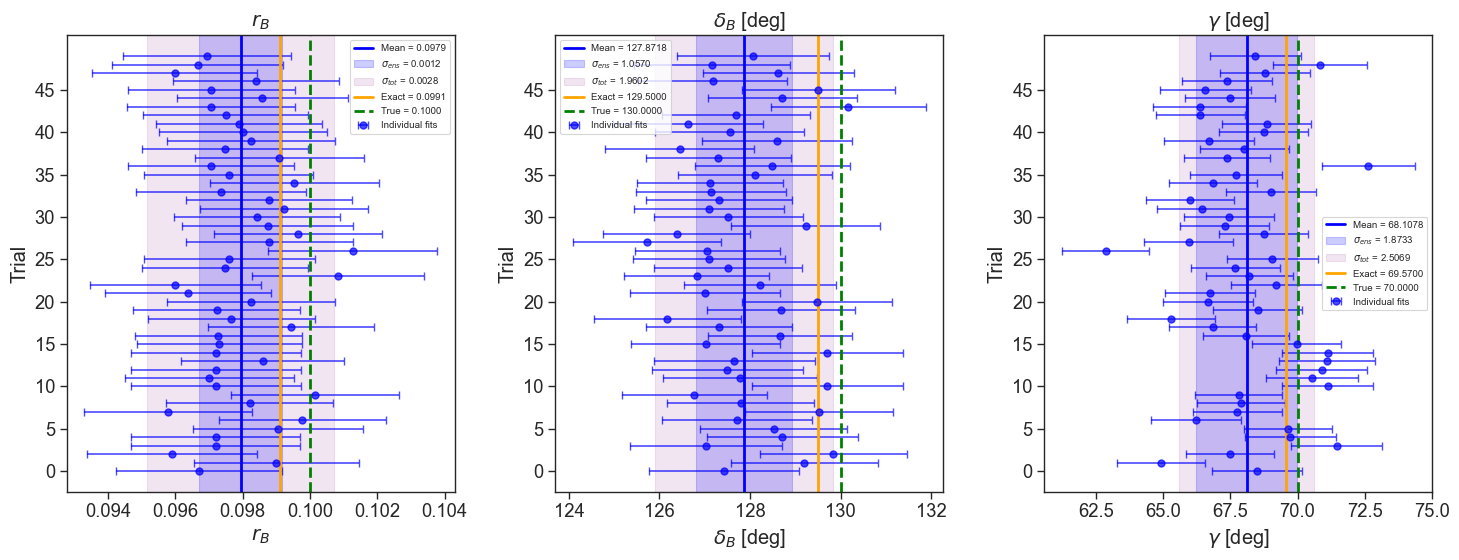


Parameter          Mean      σ_fit      σ_ens      σ_tot       True
rB               0.0979     0.0025     0.0012     0.0028     0.1000
delta [°]      127.8718     1.6508     1.0570     1.9602   130.0000
gamma [°]       68.1078     1.6660     1.8733     2.5069    70.0000


In [173]:
exact_rB = 0.0991
exact_delta = 129.5
exact_gamma = 69.57

# ============================================================================
# Plot results: stacked values with error bars
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

params = [
    (results_rB, errors_rB, exact_rB, r"$r_B$", true_rB),
    (results_delta, errors_delta, exact_delta, r"$\delta_B$ [deg]", true_deltaB * 180 / np.pi),
    (results_gamma, errors_gamma, exact_gamma, r"$\gamma$ [deg]", true_gamma * 180 / np.pi),
]

for ax, (vals, errs, exact_val, label, true_val) in zip(axes, params):
    # Compute errors
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    mean_val = vals.mean()
    
    # Y positions for stacking points
    y_pos = np.arange(len(vals))
    
    # Plot individual fits with their Minuit errors (horizontal error bars)
    ax.errorbar(vals, y_pos, xerr=errs, fmt='o', color='blue', 
                capsize=3, markersize=5, alpha=0.7, label='Individual fits')
    
    # Mean with ensemble spread
    ax.axvline(mean_val, color='blue', linestyle='-', linewidth=2, 
               label=f'Mean = {mean_val:.4f}')
    ax.axvspan(mean_val - sigma_ensemble, mean_val + sigma_ensemble, 
               alpha=0.2, color='blue', label=f'$\\sigma_{{ens}}$ = {sigma_ensemble:.4f}')
    
    # Total error band
    ax.axvspan(mean_val - sigma_total, mean_val + sigma_total, 
               alpha=0.1, color='purple', label=f'$\\sigma_{{tot}}$ = {sigma_total:.4f}')
    
    # Exact result
    ax.axvline(exact_val, color='orange', linestyle='-', linewidth=2, 
               label=f'Exact = {exact_val:.4f}')
    
    # True value
    ax.axvline(true_val, color='green', linestyle='--', linewidth=2, 
               label=f'True = {true_val:.4f}')
    
    ax.set_ylabel('Trial')
    ax.set_xlabel(label)
    ax.set_title(label)
    ax.legend(fontsize=7, loc='best')
    ax.set_yticks(y_pos[::5])  # Show every 5th trial label

plt.tight_layout()
plt.savefig("ensemble_fit_results.png", dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print(f"\n{'='*70}")
print(f"{'Parameter':<12} {'Mean':>10} {'σ_fit':>10} {'σ_ens':>10} {'σ_tot':>10} {'True':>10}")
print(f"{'='*70}")
for name, vals, errs, true_val in [
    ("rB", results_rB, errors_rB, true_rB),
    ("delta [°]", results_delta, errors_delta, true_deltaB * 180 / np.pi),
    ("gamma [°]", results_gamma, errors_gamma, true_gamma * 180 / np.pi),
]:
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    print(f"{name:<12} {vals.mean():>10.4f} {sigma_fit:>10.4f} {sigma_ensemble:>10.4f} {sigma_total:>10.4f} {true_val:>10.4f}")


In [20]:
import random
import time
import glob
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# Ensemble fit: randomly select flows 25 times and compile results
# ============================================================================

n_trials = 50
n_blocks = 16
n_bins = 16
hidden_features = 128

# Get list of model files from each ensemble directory
def get_model_files(ensemble_dir):
    files = sorted(glob.glob(f"{ensemble_dir}/trial_seed*.pth"))
    return [f for f in files if not f.endswith('_best.pth')]

flavor_files = get_model_files("test_ensemble_2e6")
odd_files = get_model_files("test_ensemble_odd_constrained_v2")
even_files = get_model_files("test_ensemble_even_2e6")

# Storage for results and errors
results_rB = []
results_delta = []
results_gamma = []
errors_rB = []
errors_delta = []
errors_gamma = []

for i in range(n_trials):
    print(f"\n{'='*60}")
    print(f"Trial {i+1}/{n_trials}")
    print(f"{'='*60}")
    
    # Randomly select one model from each ensemble
    flavor_path = random.choice(flavor_files)
    odd_path = random.choice(odd_files)
    even_path = random.choice(even_files)
    
    print(f"  flavor: {flavor_path}")
    print(f"  odd:    {odd_path}")
    print(f"  even:   {even_path}")
    
    # Load flavor flow
    flow = create_flow(num_flows=12, hidden_features=hidden_features, num_bins=24)
    flow.load_state_dict(torch.load(flavor_path, map_location=device), strict=False)
    flow.to(device)
    flow.eval()
    
    # Load odd flow
    flow_odd = create_flow(num_flows=12, hidden_features=hidden_features, num_bins=24)
    flow_odd.load_state_dict(torch.load(odd_path, map_location=device), strict=False)
    flow_odd.to(device)
    flow_odd.eval()
    
    # Load even flow
    flow_even = create_flow(num_flows=12, hidden_features=hidden_features, num_bins=24)
    flow_even.load_state_dict(torch.load(even_path, map_location=device), strict=False)
    flow_even.to(device)
    flow_even.eval()
    
    # Run the fit
    m,_ = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
        dataM_sdp=dataM_sdp,
        dataP_sdp=dataP_sdp,
        mcM_sdp=mcM_sdp,
        mcP_sdp=mcP_sdp,
        flow_flavor=flow,
        flow_even=flow_even,
        flow_odd=flow_odd,
        dkpp_model=dkpp,
        true_rB=true_rB,
        true_deltaB=true_deltaB * 180 / np.pi,
        true_gamma=true_gamma * 180 / np.pi,
        sdp_obj=sdp_obj,
        idx=(1, 2, 3),
        initial_scale=0.2,
        delta_offset=30,
        gamma_offset=30,
        device=device,
        Gamma_minus=gamma_m,
        Gamma_plus=gamma_p,
    )
    
    # Store values and errors
    results_rB.append(m.values['rB'])
    results_delta.append(m.values['delta'])
    results_gamma.append(m.values['gamma'])
    errors_rB.append(m.errors['rB'])
    errors_delta.append(m.errors['delta'])
    errors_gamma.append(m.errors['gamma'])

results_rB = np.array(results_rB)
results_delta = np.array(results_delta)
results_gamma = np.array(results_gamma)
errors_rB = np.array(errors_rB)
errors_delta = np.array(errors_delta)
errors_gamma = np.array(errors_gamma)

# ============================================================================
# Compute errors
# ============================================================================
print(f"\n{'='*60}")
print("SUMMARY")
print(f"{'='*60}")

for name, vals, errs, true_val in [
    ("rB", results_rB, errors_rB, true_rB),
    ("delta", results_delta, errors_delta, true_deltaB * 180 / np.pi),
    ("gamma", results_gamma, errors_gamma, true_gamma * 180 / np.pi),
]:
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    unit = "°" if name != "rB" else ""
    print(f"{name}: mean = {vals.mean():.4f}{unit}, "
          f"σ_ens = {sigma_ensemble:.4f}, σ_fit = {sigma_fit:.4f}, "
          f"σ_tot = {sigma_total:.4f}  (true = {true_val:.4f})")



Trial 1/50
  flavor: test_ensemble_2e6\trial_seed9.pth
  odd:    test_ensemble_odd_constrained_v2\trial_seed2.pth
  even:   test_ensemble_even_2e6\trial_seed25.pth
45327 42385
Total fit time: 1.41s

rB    = 0.0944 ± 0.0026
delta = 125.06° ± 1.62°
gamma = 69.18° ± 1.64°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 2/50
  flavor: test_ensemble_2e6\trial_seed22.pth
  odd:    test_ensemble_odd_constrained_v2\trial_seed3.pth
  even:   test_ensemble_even_2e6\trial_seed19.pth
44353 41282
Total fit time: 1.18s

rB    = 0.0949 ± 0.0025
delta = 128.98° ± 1.69°
gamma = 68.35° ± 1.70°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 3/50
  flavor: test_ensemble_2e6\trial_seed8.pth
  odd:    test_ensemble_odd_constrained_v2\trial_seed6.pth
  even:   test_ensemble_even_2e6\trial_seed27.pth
46141 41339
Total fit time: 1.45s

rB    = 0.0973 ± 0.0024
delta = 128.09° ± 1.66°
gamma = 67.53° ± 1.68°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 4/50
  flavor: test_ensemble_2e6\tr

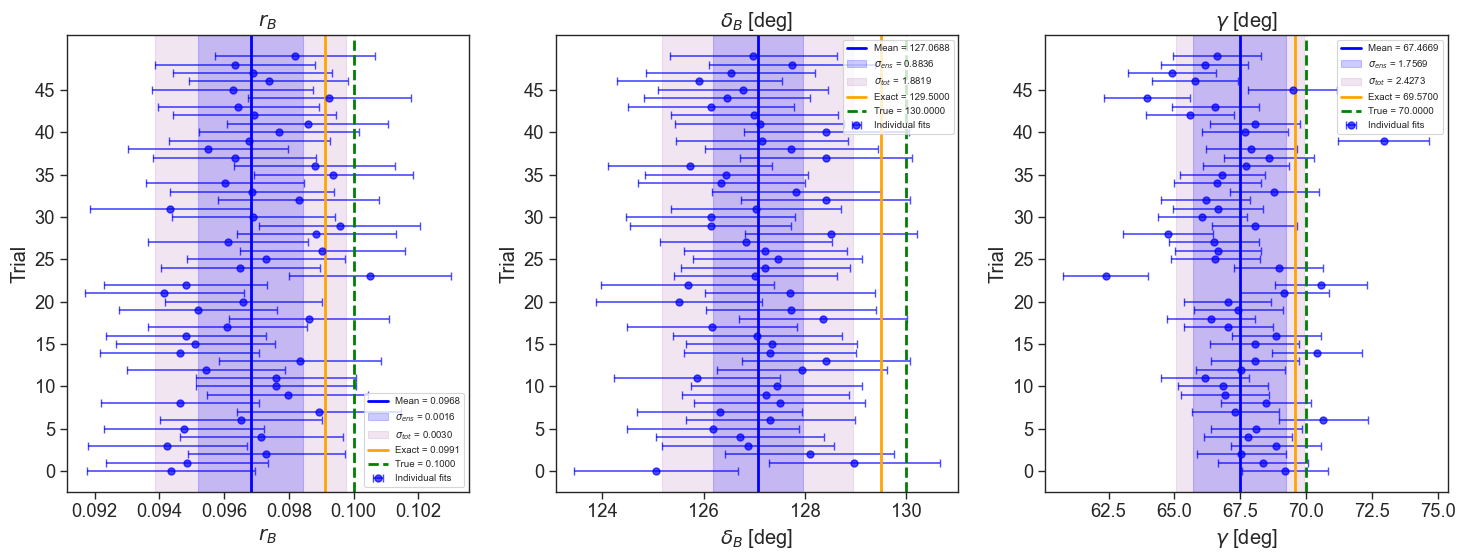


Parameter          Mean      σ_fit      σ_ens      σ_tot       True
rB               0.0968     0.0025     0.0016     0.0030     0.1000
delta [°]      127.0688     1.6615     0.8836     1.8819   130.0000
gamma [°]       67.4669     1.6749     1.7569     2.4273    70.0000


In [23]:
exact_rB = 0.0991
exact_delta = 129.5
exact_gamma = 69.57

# ============================================================================
# Plot results: stacked values with error bars
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

params = [
    (results_rB, errors_rB, exact_rB, r"$r_B$", true_rB),
    (results_delta, errors_delta, exact_delta, r"$\delta_B$ [deg]", true_deltaB * 180 / np.pi),
    (results_gamma, errors_gamma, exact_gamma, r"$\gamma$ [deg]", true_gamma * 180 / np.pi),
]

for ax, (vals, errs, exact_val, label, true_val) in zip(axes, params):
    # Compute errors
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    mean_val = vals.mean()
    
    # Y positions for stacking points
    y_pos = np.arange(len(vals))
    
    # Plot individual fits with their Minuit errors (horizontal error bars)
    ax.errorbar(vals, y_pos, xerr=errs, fmt='o', color='blue', 
                capsize=3, markersize=5, alpha=0.7, label='Individual fits')
    
    # Mean with ensemble spread
    ax.axvline(mean_val, color='blue', linestyle='-', linewidth=2, 
               label=f'Mean = {mean_val:.4f}')
    ax.axvspan(mean_val - sigma_ensemble, mean_val + sigma_ensemble, 
               alpha=0.2, color='blue', label=f'$\\sigma_{{ens}}$ = {sigma_ensemble:.4f}')
    
    # Total error band
    ax.axvspan(mean_val - sigma_total, mean_val + sigma_total, 
               alpha=0.1, color='purple', label=f'$\\sigma_{{tot}}$ = {sigma_total:.4f}')
    
    # Exact result
    ax.axvline(exact_val, color='orange', linestyle='-', linewidth=2, 
               label=f'Exact = {exact_val:.4f}')
    
    # True value
    ax.axvline(true_val, color='green', linestyle='--', linewidth=2, 
               label=f'True = {true_val:.4f}')
    
    ax.set_ylabel('Trial')
    ax.set_xlabel(label)
    ax.set_title(label)
    ax.legend(fontsize=7, loc='best')
    ax.set_yticks(y_pos[::5])  # Show every 5th trial label

plt.tight_layout()
plt.savefig("ensemble_fit_results.png", dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print(f"\n{'='*70}")
print(f"{'Parameter':<12} {'Mean':>10} {'σ_fit':>10} {'σ_ens':>10} {'σ_tot':>10} {'True':>10}")
print(f"{'='*70}")
for name, vals, errs, true_val in [
    ("rB", results_rB, errors_rB, true_rB),
    ("delta [°]", results_delta, errors_delta, true_deltaB * 180 / np.pi),
    ("gamma [°]", results_gamma, errors_gamma, true_gamma * 180 / np.pi),
]:
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    print(f"{name:<12} {vals.mean():>10.4f} {sigma_fit:>10.4f} {sigma_ensemble:>10.4f} {sigma_total:>10.4f} {true_val:>10.4f}")


In [26]:
# ============================================================================
# Generate B+/B- samples with known physics parameters
# ============================================================================

# True physics parameters
true_gamma = 60.0 * np.pi / 180.0    # Weak phase (CKM angle) in radians
true_deltaB = 100.0 * np.pi / 180.0  # Strong phase in radians
true_rB = 0.5                         # Amplitude ratio

# Sample sizes
num_exp_events = 50000  # Experimental events per charge
num_mc_events = 500000   # Monte Carlo events per charge (for efficiency)

print(f"Generating samples with:")
print(f"  gamma = {true_gamma * 180 / np.pi:.1f} degrees")
print(f"  delta_B = {true_deltaB * 180 / np.pi:.1f} degrees")
print(f"  r_B = {true_rB:.3f}")
print(f"\nSample sizes:")
print(f"  Experimental events per charge: {num_exp_events}")
print(f"  Monte Carlo events per charge: {num_mc_events}")

# Generate the samples
results_2 = generate_BpBm_samples(
    rB=true_rB,
    deltaB=true_deltaB,
    gamma=true_gamma,
    num_exp_events=num_exp_events,
    num_mc_events=num_mc_events,
    SDP=sdp_obj,
    idx=(1, 2, 3)
)

np.savez("BpBm_samples_0.5_5e4.npz", **results_2)

# Extract generated samples
dataM_sdp = results_2["dataM_sdp"]  # B- experimental data in SDP
dataP_sdp = results_2["dataP_sdp"]  # B+ experimental data in SDP
mcM_sdp = results_2["mcM_sdp"]      # B- Monte Carlo in SDP
mcP_sdp = results_2["mcP_sdp"]      # B+ Monte Carlo in SDP

print(f"\nGenerated samples:")
print(f"  B- data: {len(dataM_sdp)} events")
print(f"  B+ data: {len(dataP_sdp)} events")
print(f"  B- MC: {len(mcM_sdp)} events")
print(f"  B+ MC: {len(mcP_sdp)} events")


Generating samples with:
  gamma = 60.0 degrees
  delta_B = 100.0 degrees
  r_B = 0.500

Sample sizes:
  Experimental events per charge: 50000
  Monte Carlo events per charge: 500000
Generating B− data (DP)…
  done in 7.62s, shape=(50000, 2)
Generating B+ data (DP)…
  done in 5.57s, shape=(50000, 2)
Converting B− DP → SDP…
Converting B+ DP → SDP…
Generating MC for B− (SDP)…
  done in 0.01s, shape=(500000, 2)
Generating MC for B+ (SDP)…
  done in 0.01s, shape=(500000, 2)

Generated samples:
  B- data: 50000 events
  B+ data: 50000 events
  B- MC: 500000 events
  B+ MC: 500000 events


In [104]:
# True physics parameters
true_gamma = 60.0 * np.pi / 180.0    # Weak phase (CKM angle) in radians
true_deltaB = 100.0 * np.pi / 180.0  # Strong phase in radians
true_rB = 0.5                         # Amplitude ratio

# Sample sizes
num_exp_events = 50000  # Experimental events per charge
num_mc_events = 500000   # Monte Carlo events per charge (for efficiency)

print(f"Generating samples with:")
print(f"  gamma = {true_gamma * 180 / np.pi:.1f} degrees")
print(f"  delta_B = {true_deltaB * 180 / np.pi:.1f} degrees")
print(f"  r_B = {true_rB:.3f}")
print(f"\nSample sizes:")
print(f"  Experimental events per charge: {num_exp_events}")
print(f"  Monte Carlo events per charge: {num_mc_events}")

results = np.load("BpBm_samples_0.5_5e4.npz")

# Access the arrays
dataM_sdp = results["dataM_sdp"]
dataP_sdp = results["dataP_sdp"]
mcM_sdp = results["mcM_sdp"]
mcP_sdp = results["mcP_sdp"]


Generating samples with:
  gamma = 60.0 degrees
  delta_B = 100.0 degrees
  r_B = 0.500

Sample sizes:
  Experimental events per charge: 50000
  Monte Carlo events per charge: 500000


In [28]:
import random
import time
import glob
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# Ensemble fit: randomly select flows 25 times and compile results
# ============================================================================

n_trials = 50
n_blocks = 16
n_bins = 16
hidden_features = 128

# Get list of model files from each ensemble directory
def get_model_files(ensemble_dir):
    files = sorted(glob.glob(f"{ensemble_dir}/trial_seed*.pth"))
    return [f for f in files if not f.endswith('_best.pth')]

flavor_files = get_model_files("test_ensemble_2e6")
odd_files = get_model_files("test_ensemble_odd_2e6")
even_files = get_model_files("test_ensemble_even_2e6")

# Storage for results and errors
results_rB = []
results_delta = []
results_gamma = []
errors_rB = []
errors_delta = []
errors_gamma = []

for i in range(n_trials):
    print(f"\n{'='*60}")
    print(f"Trial {i+1}/{n_trials}")
    print(f"{'='*60}")
    
    # Randomly select one model from each ensemble
    flavor_path = random.choice(flavor_files)
    odd_path = random.choice(odd_files)
    even_path = random.choice(even_files)
    
    print(f"  flavor: {flavor_path}")
    print(f"  odd:    {odd_path}")
    print(f"  even:   {even_path}")
    
    # Load flavor flow
    flow = create_flow(num_flows=12, hidden_features=hidden_features, num_bins=24)
    flow.load_state_dict(torch.load(flavor_path, map_location=device), strict=False)
    flow.to(device)
    flow.eval()
    
    # Load odd flow
    flow_odd = create_flow(num_flows=12, hidden_features=hidden_features, num_bins=24)
    flow_odd.load_state_dict(torch.load(odd_path, map_location=device), strict=False)
    flow_odd.to(device)
    flow_odd.eval()
    
    # Load even flow
    flow_even = create_flow(num_flows=12, hidden_features=hidden_features, num_bins=24)
    flow_even.load_state_dict(torch.load(even_path, map_location=device), strict=False)
    flow_even.to(device)
    flow_even.eval()
    
    # Run the fit
    m,_ = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
        dataM_sdp=dataM_sdp,
        dataP_sdp=dataP_sdp,
        mcM_sdp=mcM_sdp,
        mcP_sdp=mcP_sdp,
        flow_flavor=flow,
        flow_even=flow_even,
        flow_odd=flow_odd,
        dkpp_model=dkpp,
        true_rB=true_rB,
        true_deltaB=true_deltaB * 180 / np.pi,
        true_gamma=true_gamma * 180 / np.pi,
        sdp_obj=sdp_obj,
        idx=(1, 2, 3),
        initial_scale=0.2,
        delta_offset=30,
        gamma_offset=30,
        device=device,
        Gamma_minus=gamma_m,
        Gamma_plus=gamma_p,
    )
    
    # Store values and errors
    results_rB.append(m.values['rB'])
    results_delta.append(m.values['delta'])
    results_gamma.append(m.values['gamma'])
    errors_rB.append(m.errors['rB'])
    errors_delta.append(m.errors['delta'])
    errors_gamma.append(m.errors['gamma'])

results_rB = np.array(results_rB)
results_delta = np.array(results_delta)
results_gamma = np.array(results_gamma)
errors_rB = np.array(errors_rB)
errors_delta = np.array(errors_delta)
errors_gamma = np.array(errors_gamma)

# ============================================================================
# Compute errors
# ============================================================================
print(f"\n{'='*60}")
print("SUMMARY")
print(f"{'='*60}")

for name, vals, errs, true_val in [
    ("rB", results_rB, errors_rB, true_rB),
    ("delta", results_delta, errors_delta, true_deltaB * 180 / np.pi),
    ("gamma", results_gamma, errors_gamma, true_gamma * 180 / np.pi),
]:
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    unit = "°" if name != "rB" else ""
    print(f"{name}: mean = {vals.mean():.4f}{unit}, "
          f"σ_ens = {sigma_ensemble:.4f}, σ_fit = {sigma_fit:.4f}, "
          f"σ_tot = {sigma_total:.4f}  (true = {true_val:.4f})")



Trial 1/50
  flavor: test_ensemble_2e6\trial_seed1.pth
  odd:    test_ensemble_odd_2e6\trial_seed13.pth
  even:   test_ensemble_even_2e6\trial_seed16.pth


c:\Users\chinh\anaconda3\Lib\site-packages\nflows\transforms\coupling.py:481: UserWarning: Inputs to the softmax are not scaled down: initialization might be bad.
  warnings.warn(


43363 41290
Total fit time: 1.39s

rB    = 0.4896 ± 0.0036
delta = 101.05° ± 0.48°
gamma = 59.41° ± 0.48°
(true rB=0.5000, true γ=60.00°, true δ=100.00°)

Trial 2/50
  flavor: test_ensemble_2e6\trial_seed21.pth
  odd:    test_ensemble_odd_2e6\trial_seed10.pth
  even:   test_ensemble_even_2e6\trial_seed25.pth
42727 40566
Total fit time: 1.04s

rB    = 0.4981 ± 0.0026
delta = 100.18° ± 0.52°
gamma = 59.07° ± 0.52°
(true rB=0.5000, true γ=60.00°, true δ=100.00°)

Trial 3/50
  flavor: test_ensemble_2e6\trial_seed20.pth
  odd:    test_ensemble_odd_2e6\trial_seed15.pth
  even:   test_ensemble_even_2e6\trial_seed21.pth
40890 41295
Total fit time: 1.25s

rB    = 0.4961 ± 0.0027
delta = 100.43° ± 0.51°
gamma = 59.54° ± 0.51°
(true rB=0.5000, true γ=60.00°, true δ=100.00°)

Trial 4/50
  flavor: test_ensemble_2e6\trial_seed18.pth
  odd:    test_ensemble_odd_2e6\trial_seed7.pth
  even:   test_ensemble_even_2e6\trial_seed15.pth
42462 42688
Total fit time: 1.03s

rB    = 0.4975 ± 0.0026
delta = 100.

In [40]:
fit_rB_delta_gamma_SDP_unbinned_jac_terms_exact(
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device
)

50000 50000
Total fit time: 1.40s

rB    = 0.4969 ± 0.0024
delta = 99.55° ± 0.49°
gamma = 59.41° ± 0.49°
(true rB=0.5000, true γ=60.00°, true δ=100.00°)


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.415e+04                  │              Nfcn = 109              │
│ EDM = 7.9e-08 (Goal: 0.0001)     │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ rB    │  0.4969   │  0.0024   │            │            │    0    │    1    │       │
│ 1 │ delta │   99.5    │    0.5    │            │            │         │         │       │
│ 2 │ gamma │   59.4    │    0.5    │            │            │         │         │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬────────────────────────────┐
│       │       rB    delta    gamma │
├───────┼────────────────────────────┤
│    rB │ 5.94e-06  -153e-6    42e-6 │
│ delta │  -153e-6    0.241     0.13 │
│ gamma │    42e-6     0.13    0.237 │
└───────┴────────────────────────────┘

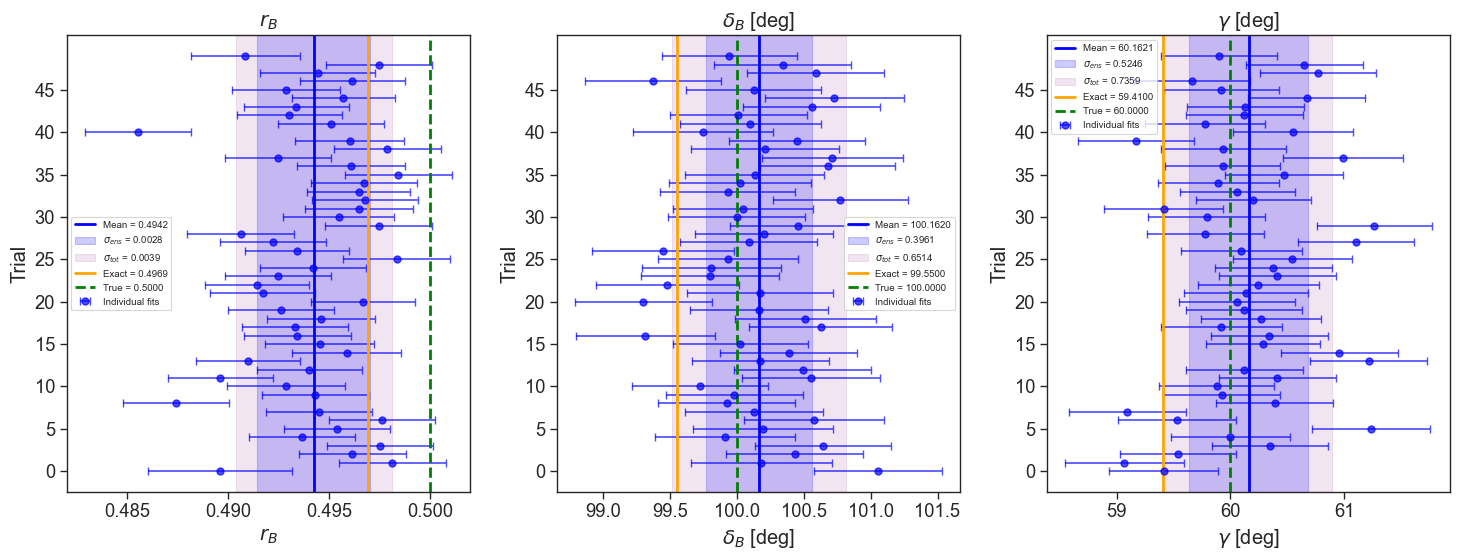


Parameter          Mean      σ_fit      σ_ens      σ_tot       True
rB               0.4942     0.0027     0.0028     0.0039     0.5000
delta [°]      100.1620     0.5171     0.3961     0.6514   100.0000
gamma [°]       60.1621     0.5161     0.5246     0.7359    60.0000


In [42]:
exact_rB = 0.4969
exact_delta = 99.55
exact_gamma = 59.41

# ============================================================================
# Plot results: stacked values with error bars
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

params = [
    (results_rB, errors_rB, exact_rB, r"$r_B$", true_rB),
    (results_delta, errors_delta, exact_delta, r"$\delta_B$ [deg]", true_deltaB * 180 / np.pi),
    (results_gamma, errors_gamma, exact_gamma, r"$\gamma$ [deg]", true_gamma * 180 / np.pi),
]

for ax, (vals, errs, exact_val, label, true_val) in zip(axes, params):
    # Compute errors
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    mean_val = vals.mean()
    
    # Y positions for stacking points
    y_pos = np.arange(len(vals))
    
    # Plot individual fits with their Minuit errors (horizontal error bars)
    ax.errorbar(vals, y_pos, xerr=errs, fmt='o', color='blue', 
                capsize=3, markersize=5, alpha=0.7, label='Individual fits')
    
    # Mean with ensemble spread
    ax.axvline(mean_val, color='blue', linestyle='-', linewidth=2, 
               label=f'Mean = {mean_val:.4f}')
    ax.axvspan(mean_val - sigma_ensemble, mean_val + sigma_ensemble, 
               alpha=0.2, color='blue', label=f'$\\sigma_{{ens}}$ = {sigma_ensemble:.4f}')
    
    # Total error band
    ax.axvspan(mean_val - sigma_total, mean_val + sigma_total, 
               alpha=0.1, color='purple', label=f'$\\sigma_{{tot}}$ = {sigma_total:.4f}')
    
    # Exact result
    ax.axvline(exact_val, color='orange', linestyle='-', linewidth=2, 
               label=f'Exact = {exact_val:.4f}')
    
    # True value
    ax.axvline(true_val, color='green', linestyle='--', linewidth=2, 
               label=f'True = {true_val:.4f}')
    
    ax.set_ylabel('Trial')
    ax.set_xlabel(label)
    ax.set_title(label)
    ax.legend(fontsize=7, loc='best')
    ax.set_yticks(y_pos[::5])  # Show every 5th trial label

plt.tight_layout()
plt.savefig("ensemble_fit_results.png", dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print(f"\n{'='*70}")
print(f"{'Parameter':<12} {'Mean':>10} {'σ_fit':>10} {'σ_ens':>10} {'σ_tot':>10} {'True':>10}")
print(f"{'='*70}")
for name, vals, errs, true_val in [
    ("rB", results_rB, errors_rB, true_rB),
    ("delta [°]", results_delta, errors_delta, true_deltaB * 180 / np.pi),
    ("gamma [°]", results_gamma, errors_gamma, true_gamma * 180 / np.pi),
]:
    sigma_ensemble = vals.std()
    sigma_fit = errs.mean()
    sigma_total = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    print(f"{name:<12} {vals.mean():>10.4f} {sigma_fit:>10.4f} {sigma_ensemble:>10.4f} {sigma_total:>10.4f} {true_val:>10.4f}")


---
## 02/13/2026

In [26]:
# True physics parameters
true_gamma = 70.0 * np.pi / 180.0    # Weak phase (CKM angle) in radians
true_deltaB = 130.0 * np.pi / 180.0  # Strong phase in radians
true_rB = 0.1                         # Amplitude ratio


results = np.load( "BpBm_samples.npz")

# Access the arrays
dataM_sdp = results["dataM_sdp"]
dataP_sdp = results["dataP_sdp"]
mcM_sdp = results["mcM_sdp"]
mcP_sdp = results["mcP_sdp"]


In [100]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m,_ = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcM_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

49904 49713
Total fit time: 1.41s

rB    = 0.0740 ± 0.0027
delta = 114.71° ± 1.75°
gamma = 91.35° ± 1.73°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.182e+04                  │              Nfcn = 110              │
│ EDM = 3.07e-05 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└─────────

In [105]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m,_ = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcM_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

49885 49727
Total fit time: 1.44s

rB    = 0.4730 ± 0.0024
delta = 95.93° ± 0.41°
gamma = 72.00° ± 0.41°
(true rB=0.5000, true γ=60.00°, true δ=100.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3.493e+04                  │              Nfcn = 110              │
│ EDM = 9.86e-07 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────

In [109]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m,_ = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcM_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

49847 49935
Total fit time: 1.40s

rB    = 0.4981 ± 0.0025
delta = 100.24° ± 0.45°
gamma = 60.68° ± 0.45°
(true rB=0.5000, true γ=60.00°, true δ=100.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.906e+04                  │              Nfcn = 115              │
│ EDM = 2.74e-08 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└─────────

In [111]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m,_ = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcM_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

49870 49948
Total fit time: 1.28s

rB    = 0.0907 ± 0.0024
delta = 120.29° ± 1.64°
gamma = 73.91° ± 1.66°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.626e+04                  │              Nfcn = 105              │
│ EDM = 6.86e-06 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└─────────

In [120]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m,_ = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

43134 47340
Total fit time: 1.23s

rB    = 0.0952 ± 0.0024
delta = 120.41° ± 1.64°
gamma = 69.70° ± 1.65°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.528e+04                  │              Nfcn = 103              │
│ EDM = 2.65e-06 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└─────────

In [128]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m,_ = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

48341 48250
Total fit time: 1.16s

rB    = 0.0897 ± 0.0024
delta = 123.29° ± 1.65°
gamma = 75.11° ± 1.66°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.507e+04                  │              Nfcn = 96               │
│ EDM = 1.7e-05 (Goal: 0.0001)     │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└─────────

In [142]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m,_ = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

47433 46153
Total fit time: 1.57s

rB    = 0.0947 ± 0.0024
delta = 125.08° ± 1.62°
gamma = 71.24° ± 1.64°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.582e+04                  │              Nfcn = 110              │
│ EDM = 1.11e-07 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└─────────

In [24]:
def load_flow_triplet(
    flavor_path,
    even_path,
    odd_path,
    num_flows=12,
    hidden_features=128,
    num_bins=24,
    device="cuda" if torch.cuda.is_available() else "cpu",
    verbose=True
):
    """
    Load a triplet of flows (flavor, even, odd) from saved state dicts.
    
    Parameters
    ----------
    flavor_path : str or Path
        Path to flavor flow .pth file
    even_path : str or Path
        Path to even flow .pth file
    odd_path : str or Path
        Path to odd flow .pth file
    num_flows : int
        Number of flow blocks
    hidden_features : int
        Hidden layer size
    num_bins : int
        Number of spline bins
    device : str
        Torch device
    verbose : bool
        Print loading info
    
    Returns
    -------
    flow_flavor, flow_even, flow_odd : tuple of flows
        Loaded flows in eval mode
    """
    # Create flows
    flow_flavor = create_flow(num_flows=num_flows, hidden_features=hidden_features, num_bins=num_bins)
    flow_even = create_flow(num_flows=num_flows, hidden_features=hidden_features, num_bins=num_bins)
    flow_odd = create_flow(num_flows=num_flows, hidden_features=hidden_features, num_bins=num_bins)
    
    # Load weights
    flow_flavor.load_state_dict(torch.load(flavor_path, map_location=device))
    flow_even.load_state_dict(torch.load(even_path, map_location=device))
    flow_odd.load_state_dict(torch.load(odd_path, map_location=device))
    
    # Move to device and set eval mode
    flow_flavor.to(device).eval()
    flow_even.to(device).eval()
    flow_odd.to(device).eval()
    
    if verbose:
        total_params = sum(p.numel() for p in flow_flavor.parameters())
        print(f"Loaded flow triplet ({total_params:,} params each):")
        print(f"  Flavor: {flavor_path}")
        print(f"  Even:   {even_path}")
        print(f"  Odd:    {odd_path}")
    
    return flow_flavor, flow_even, flow_odd


In [34]:
from pathlib import Path

def load_flow_triplet_from_dir(ensemble_dir, trial=0, **kwargs):
    """Load flows from an ensemble directory."""
    ensemble_dir = Path(ensemble_dir)
    return load_flow_triplet(
        flavor_path=ensemble_dir / "ensemble_flavor" / f"trial_{trial}.pth",
        even_path=ensemble_dir / "ensemble_even" / f"trial_{trial}.pth",
        odd_path=ensemble_dir / "ensemble_odd" / f"trial_{trial}.pth",
        **kwargs
    )

# Usage:
flow_flavor, flow_even, flow_odd = load_flow_triplet_from_dir(
    'joint_ensemble_2e6_5', trial=0, device=device
)


Loaded flow triplet (311,124 params each):
  Flavor: joint_ensemble_2e6_5\ensemble_flavor\trial_0.pth
  Even:   joint_ensemble_2e6_5\ensemble_even\trial_0.pth
  Odd:    joint_ensemble_2e6_5\ensemble_odd\trial_0.pth


In [38]:
flow, flow_even, flow_odd = load_flow_triplet(
    flavor_path='test_ensemble_2e6/trial_seed11.pth',
    even_path='test_ensemble_even_2e6/trial_seed26.pth',
    odd_path='test_ensemble_odd_2e6/trial_seed4.pth',
    num_flows=12,
    hidden_features=128,
    num_bins=24,
    device=device
)

Loaded flow triplet (311,124 params each):
  Flavor: test_ensemble_2e6/trial_seed11.pth
  Even:   test_ensemble_even_2e6/trial_seed26.pth
  Odd:    test_ensemble_odd_2e6/trial_seed4.pth


In [39]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m,_ = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

42453 42321
Total fit time: 1.18s

rB    = 0.0972 ± 0.0026
delta = 126.34° ± 1.67°
gamma = 67.87° ± 1.71°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.25e+04                   │              Nfcn = 100              │
│ EDM = 8.67e-07 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└─────────

In [44]:
flow, flow_even, flow_odd = load_flow_triplet(
    flavor_path='finetuned_flavor.pth',
    even_path='finetuned_even.pth',
    odd_path='finetuned_odd.pth',
    num_flows=12,
    hidden_features=128,
    num_bins=24,
    device=device
)

Loaded flow triplet (311,124 params each):
  Flavor: finetuned_flavor.pth
  Even:   finetuned_even.pth
  Odd:    finetuned_odd.pth


In [45]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m,_ = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

48696 48469
Total fit time: 1.35s

rB    = 0.0926 ± 0.0024
delta = 124.76° ± 1.62°
gamma = 71.58° ± 1.63°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.491e+04                  │              Nfcn = 97               │
│ EDM = 1.12e-05 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└─────────

In [42]:
flow, flow_even, flow_odd = load_flow_triplet_from_dir(
    'joint_ensemble_2e6_4', trial=0, device=device
)

Loaded flow triplet (311,124 params each):
  Flavor: joint_ensemble_2e6_4\ensemble_flavor\trial_0.pth
  Even:   joint_ensemble_2e6_4\ensemble_even\trial_0.pth
  Odd:    joint_ensemble_2e6_4\ensemble_odd\trial_0.pth


In [46]:
flow, flow_even, flow_odd = load_flow_triplet(
    flavor_path='finetuned_flavor.pth',
    even_path='finetuned_even.pth',
    odd_path='finetuned_odd.pth',
    num_flows=12,
    hidden_features=128,
    num_bins=24,
    device=device
)

Loaded flow triplet (311,124 params each):
  Flavor: finetuned_flavor.pth
  Even:   finetuned_even.pth
  Odd:    finetuned_odd.pth


In [47]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m,_ = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

46556 47201
Total fit time: 1.31s

rB    = 0.0926 ± 0.0024
delta = 124.54° ± 1.68°
gamma = 73.46° ± 1.69°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.348e+04                  │              Nfcn = 101              │
│ EDM = 1.3e-07 (Goal: 0.0001)     │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└─────────

In [50]:
flow, flow_even, flow_odd = load_flow_triplet(
    flavor_path='finetuned_flavor.pth',
    even_path='finetuned_even.pth',
    odd_path='finetuned_odd.pth',
    num_flows=12,
    hidden_features=128,
    num_bins=24,
    device=device
)

Loaded flow triplet (311,124 params each):
  Flavor: finetuned_flavor.pth
  Even:   finetuned_even.pth
  Odd:    finetuned_odd.pth


In [51]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m,_ = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

48401 48184
Total fit time: 1.37s

rB    = 0.0936 ± 0.0024
delta = 123.92° ± 1.62°
gamma = 72.57° ± 1.63°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.468e+04                  │              Nfcn = 99               │
│ EDM = 7.17e-07 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└─────────

In [125]:
flow, flow_even, flow_odd = load_flow_triplet(
    flavor_path='flow_flavor.pth',
    even_path='flow_even.pth',
    odd_path='flow_odd.pth',
    num_flows=12,
    hidden_features=128,
    num_bins=24,
    device=device
)

Loaded flow triplet (311,124 params each):
  Flavor: flow_flavor.pth
  Even:   flow_even.pth
  Odd:    flow_odd.pth


In [49]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m,_ = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

41522 43729
Total fit time: 1.25s

rB    = 0.0965 ± 0.0025
delta = 128.69° ± 1.66°
gamma = 69.08° ± 1.67°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.224e+04                  │              Nfcn = 97               │
│ EDM = 1.63e-05 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└─────────

In [62]:
flow, flow_even, flow_odd = load_flow_triplet(
    flavor_path='flow_flavor.pth',
    even_path='flow_even.pth',
    odd_path='test_odd_constrained.pth',
    num_flows=12,
    hidden_features=128,
    num_bins=24,
    device=device
)

Loaded flow triplet (311,124 params each):
  Flavor: flow_flavor.pth
  Even:   flow_even.pth
  Odd:    test_odd_constrained.pth


In [63]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m,_ = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

45286 41762
Total fit time: 1.20s

rB    = 0.0990 ± 0.0025
delta = 127.78° ± 1.62°
gamma = 68.36° ± 1.63°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.579e+04                  │              Nfcn = 112              │
│ EDM = 2.46e-08 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└─────────

In [64]:
flow, flow_even, flow_odd = load_flow_triplet(
    flavor_path='flow_flavor.pth',
    even_path='flow_even.pth',
    odd_path='test_odd_constrained_2.pth',
    num_flows=12,
    hidden_features=128,
    num_bins=24,
    device=device
)

Loaded flow triplet (311,124 params each):
  Flavor: flow_flavor.pth
  Even:   flow_even.pth
  Odd:    test_odd_constrained_2.pth


In [65]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m,_ = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

45234 41471
Total fit time: 1.21s

rB    = 0.0992 ± 0.0025
delta = 127.29° ± 1.62°
gamma = 68.14° ± 1.64°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.563e+04                  │              Nfcn = 112              │
│ EDM = 3.31e-08 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└─────────

In [66]:
flow, flow_even, flow_odd = load_flow_triplet(
    flavor_path='flow_flavor.pth',
    even_path='flow_even.pth',
    odd_path='test_odd_constrained_3.pth',
    num_flows=12,
    hidden_features=128,
    num_bins=24,
    device=device
)

Loaded flow triplet (311,124 params each):
  Flavor: flow_flavor.pth
  Even:   flow_even.pth
  Odd:    test_odd_constrained_3.pth


In [67]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m,_ = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

45270 41391
Total fit time: 1.24s

rB    = 0.0993 ± 0.0025
delta = 127.06° ± 1.63°
gamma = 67.97° ± 1.64°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.582e+04                  │              Nfcn = 114              │
│ EDM = 1.96e-07 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└─────────

In [69]:
flow, flow_even, flow_odd = load_flow_triplet(
    flavor_path='flow_flavor.pth',
    even_path='flow_even.pth',
    odd_path='test_odd_constrained_4.pth',
    num_flows=12,
    hidden_features=128,
    num_bins=24,
    device=device
)

Loaded flow triplet (311,124 params each):
  Flavor: flow_flavor.pth
  Even:   flow_even.pth
  Odd:    test_odd_constrained_4.pth


In [70]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m,_ = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

45176 41194
Total fit time: 1.25s

rB    = 0.0994 ± 0.0025
delta = 126.95° ± 1.63°
gamma = 67.96° ± 1.64°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.57e+04                   │              Nfcn = 113              │
│ EDM = 5.17e-07 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└─────────

In [80]:
flow, flow_even, flow_odd = load_flow_triplet(
    flavor_path='flow_flavor.pth',
    even_path='flow_even.pth',
    odd_path='test_odd_constrained_5.pth',
    num_flows=12,
    hidden_features=128,
    num_bins=24,
    device=device
)

Loaded flow triplet (311,124 params each):
  Flavor: flow_flavor.pth
  Even:   flow_even.pth
  Odd:    test_odd_constrained_5.pth


In [81]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m,_ = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

44998 41006
Total fit time: 1.38s

rB    = 0.0994 ± 0.0025
delta = 126.57° ± 1.64°
gamma = 67.39° ± 1.66°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.677e+04                  │              Nfcn = 110              │
│ EDM = 1.65e-08 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└─────────

In [52]:
flow, flow_even, flow_odd = load_flow_triplet(
    flavor_path='finetuned_flavor.pth',
    even_path='finetuned_even.pth',
    odd_path='finetuned_odd.pth',
    num_flows=12,
    hidden_features=128,
    num_bins=24,
    device=device
)

Loaded flow triplet (311,124 params each):
  Flavor: finetuned_flavor.pth
  Even:   finetuned_even.pth
  Odd:    finetuned_odd.pth


In [53]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m,_ = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

48638 48177
Total fit time: 1.40s

rB    = 0.0926 ± 0.0024
delta = 125.72° ± 1.63°
gamma = 74.63° ± 1.64°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.552e+04                  │              Nfcn = 102              │
│ EDM = 2.56e-06 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└─────────

In [54]:
flow, flow_even, flow_odd = load_flow_triplet(
    flavor_path='finetuned_flavor2.pth',
    even_path='finetuned_even2.pth',
    odd_path='finetuned_odd2.pth',
    num_flows=12,
    hidden_features=128,
    num_bins=24,
    device=device
)

Loaded flow triplet (311,124 params each):
  Flavor: finetuned_flavor2.pth
  Even:   finetuned_even2.pth
  Odd:    finetuned_odd2.pth


In [55]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m,_ = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

48659 48206
Total fit time: 1.19s

rB    = 0.0926 ± 0.0024
delta = 124.72° ± 1.62°
gamma = 74.54° ± 1.64°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.557e+04                  │              Nfcn = 99               │
│ EDM = 1.18e-05 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└─────────

In [56]:
flow, flow_even, flow_odd = load_flow_triplet(
    flavor_path='finetuned_flavor3.pth',
    even_path='finetuned_even3.pth',
    odd_path='finetuned_odd3.pth',
    num_flows=12,
    hidden_features=128,
    num_bins=24,
    device=device
)

Loaded flow triplet (311,124 params each):
  Flavor: finetuned_flavor3.pth
  Even:   finetuned_even3.pth
  Odd:    finetuned_odd3.pth


In [57]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m,_ = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

48717 48343
Total fit time: 1.25s

rB    = 0.0930 ± 0.0024
delta = 124.63° ± 1.63°
gamma = 73.26° ± 1.65°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.53e+04                   │              Nfcn = 104              │
│ EDM = 9.74e-08 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└─────────

In [58]:
flow, flow_even, flow_odd = load_flow_triplet(
    flavor_path='finetuned_flavor4.pth',
    even_path='finetuned_even4.pth',
    odd_path='finetuned_odd4.pth',
    num_flows=12,
    hidden_features=128,
    num_bins=24,
    device=device
)

Loaded flow triplet (311,124 params each):
  Flavor: finetuned_flavor4.pth
  Even:   finetuned_even4.pth
  Odd:    finetuned_odd4.pth


In [59]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m,_ = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

48249 48001
Total fit time: 1.15s

rB    = 0.0925 ± 0.0024
delta = 125.82° ± 1.66°
gamma = 72.69° ± 1.67°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.456e+04                  │              Nfcn = 100              │
│ EDM = 1.16e-05 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└─────────

In [60]:
flow, flow_even, flow_odd = load_flow_triplet(
    flavor_path='finetuned_flavor6.pth',
    even_path='finetuned_even6.pth',
    odd_path='finetuned_odd6.pth',
    num_flows=12,
    hidden_features=128,
    num_bins=24,
    device=device
)

Loaded flow triplet (311,124 params each):
  Flavor: finetuned_flavor6.pth
  Even:   finetuned_even6.pth
  Odd:    finetuned_odd6.pth


In [61]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m,_ = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

46047 44955
Total fit time: 1.04s

rB    = 0.0949 ± 0.0024
delta = 127.83° ± 1.65°
gamma = 71.60° ± 1.67°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.146e+04                  │              Nfcn = 95               │
│ EDM = 5.17e-05 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└─────────

In [71]:
flow, flow_even, flow_odd = load_flow_triplet(
    flavor_path='finetuned_flavor7.pth',
    even_path='finetuned_even7.pth',
    odd_path='finetuned_odd7.pth',
    num_flows=12,
    hidden_features=128,
    num_bins=24,
    device=device
)

Loaded flow triplet (311,124 params each):
  Flavor: finetuned_flavor7.pth
  Even:   finetuned_even7.pth
  Odd:    finetuned_odd7.pth


In [72]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m,_ = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

47234 47514
Total fit time: 1.19s

rB    = 0.0937 ± 0.0024
delta = 126.54° ± 1.64°
gamma = 71.11° ± 1.66°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.36e+04                   │              Nfcn = 100              │
│ EDM = 2.64e-06 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└─────────

In [76]:
flow, flow_even, flow_odd = load_flow_triplet(
    flavor_path='finetuned_flavor8.pth',
    even_path='finetuned_even8.pth',
    odd_path='finetuned_odd8.pth',
    num_flows=12,
    hidden_features=128,
    num_bins=24,
    device=device
)

Loaded flow triplet (311,124 params each):
  Flavor: finetuned_flavor8.pth
  Even:   finetuned_even8.pth
  Odd:    finetuned_odd8.pth


In [77]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m,_ = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

47997 47931
Total fit time: 1.18s

rB    = 0.0936 ± 0.0024
delta = 125.31° ± 1.64°
gamma = 72.77° ± 1.65°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.452e+04                  │              Nfcn = 101              │
│ EDM = 6.17e-07 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└─────────

In [78]:
flow, flow_even, flow_odd = load_flow_triplet(
    flavor_path='finetuned_flavor9.pth',
    even_path='finetuned_even9.pth',
    odd_path='finetuned_odd9.pth',
    num_flows=12,
    hidden_features=128,
    num_bins=24,
    device=device
)

Loaded flow triplet (311,124 params each):
  Flavor: finetuned_flavor9.pth
  Even:   finetuned_even9.pth
  Odd:    finetuned_odd9.pth


In [79]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m,_ = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

48107 47958
Total fit time: 1.23s

rB    = 0.0930 ± 0.0024
delta = 125.04° ± 1.64°
gamma = 73.42° ± 1.65°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.488e+04                  │              Nfcn = 106              │
│ EDM = 1.49e-07 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└─────────

In [97]:
# True physics parameters
true_gamma = 60.0 * np.pi / 180.0    # Weak phase (CKM angle) in radians
true_deltaB = 100.0 * np.pi / 180.0  # Strong phase in radians
true_rB = 0.5                         # Amplitude ratio


results = np.load( "BpBm_samples_0.5_5e4.npz")

# Access the arrays
dataM_sdp = results["dataM_sdp"]
dataP_sdp = results["dataP_sdp"]
mcM_sdp = results["mcM_sdp"]
mcP_sdp = results["mcP_sdp"]


In [83]:
flow, flow_even, flow_odd = load_flow_triplet(
    flavor_path='finetuned_flavor9.pth',
    even_path='finetuned_even9.pth',
    odd_path='finetuned_odd9.pth',
    num_flows=12,
    hidden_features=128,
    num_bins=24,
    device=device
)

Loaded flow triplet (311,124 params each):
  Flavor: finetuned_flavor9.pth
  Even:   finetuned_even9.pth
  Odd:    finetuned_odd9.pth


In [84]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m,_ = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

c:\Users\chinh\anaconda3\Lib\site-packages\nflows\transforms\coupling.py:481: UserWarning: Inputs to the softmax are not scaled down: initialization might be bad.
  warnings.warn(


48043 48089
Total fit time: 1.60s

rB    = 0.4927 ± 0.0027
delta = 101.20° ± 0.48°
gamma = 60.83° ± 0.48°
(true rB=0.5000, true γ=60.00°, true δ=100.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.753e+04                  │              Nfcn = 134              │
│ EDM = 1.69e-06 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└─────────

In [85]:
flow, flow_even, flow_odd = load_flow_triplet(
    flavor_path='finetuned_flavor11.pth',
    even_path='finetuned_even11.pth',
    odd_path='finetuned_odd11.pth',
    num_flows=12,
    hidden_features=128,
    num_bins=24,
    device=device
)

Loaded flow triplet (311,124 params each):
  Flavor: finetuned_flavor11.pth
  Even:   finetuned_even11.pth
  Odd:    finetuned_odd11.pth


In [86]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m,_ = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

45190 44885
Total fit time: 1.12s

rB    = 0.4964 ± 0.0026
delta = 100.83° ± 0.51°
gamma = 60.32° ± 0.50°
(true rB=0.5000, true γ=60.00°, true δ=100.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.195e+04                  │              Nfcn = 90               │
│ EDM = 8.87e-06 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└─────────

In [87]:
flow, flow_even, flow_odd = load_flow_triplet(
    flavor_path='finetuned_flavor10.pth',
    even_path='finetuned_even10.pth',
    odd_path='finetuned_odd10.pth',
    num_flows=12,
    hidden_features=128,
    num_bins=24,
    device=device
)

Loaded flow triplet (311,124 params each):
  Flavor: finetuned_flavor10.pth
  Even:   finetuned_even10.pth
  Odd:    finetuned_odd10.pth


In [88]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m,_ = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

44640 43790
Total fit time: 1.45s

rB    = 0.4960 ± 0.0026
delta = 100.77° ± 0.51°
gamma = 60.17° ± 0.51°
(true rB=0.5000, true γ=60.00°, true δ=100.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.107e+04                  │              Nfcn = 126              │
│ EDM = 1.11e-09 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└─────────

In [91]:
flow, flow_even, flow_odd = load_flow_triplet(
    flavor_path='finetuned_flavor13.pth',
    even_path='finetuned_even13.pth',
    odd_path='finetuned_odd13.pth',
    num_flows=12,
    hidden_features=128,
    num_bins=24,
    device=device
)

Loaded flow triplet (311,124 params each):
  Flavor: finetuned_flavor13.pth
  Even:   finetuned_even13.pth
  Odd:    finetuned_odd13.pth


In [92]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m,_ = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

49285 48746
Total fit time: 0.84s

rB    = 0.0923 ± 0.0024
delta = 123.98° ± 1.62°
gamma = 74.89° ± 1.64°
(true rB=0.5000, true γ=60.00°, true δ=100.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.536e+04                  │              Nfcn = 70               │
│ EDM = 1.84e-05 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└─────────

In [93]:
flow, flow_even, flow_odd = load_flow_triplet(
    flavor_path='finetuned_flavor14.pth',
    even_path='finetuned_even14.pth',
    odd_path='finetuned_odd14.pth',
    num_flows=12,
    hidden_features=128,
    num_bins=24,
    device=device
)

Loaded flow triplet (311,124 params each):
  Flavor: finetuned_flavor14.pth
  Even:   finetuned_even14.pth
  Odd:    finetuned_odd14.pth


In [101]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m,_ = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.1,        # Starting scale for r_B (relative to true value)
    delta_offset=5,          # Offset in degrees for delta_B initialization
    gamma_offset=5,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

48780 48322
Total fit time: 1.34s

rB    = 0.0922 ± 0.0024
delta = 124.28° ± 1.63°
gamma = 74.54° ± 1.65°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.542e+04                  │              Nfcn = 98               │
│ EDM = 3.79e-07 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└─────────

In [106]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.1,        # Starting scale for r_B (relative to true value)
    delta_offset=5,          # Offset in degrees for delta_B initialization
    gamma_offset=5,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

48780 48322 466577 467190
Total fit time: 1.34s

rB    = 0.0922 ± 0.0024
delta = 124.28° ± 1.63°
gamma = 74.54° ± 1.65°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.542e+04                  │              Nfcn = 98               │
│ EDM = 3.79e-07 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate        

In [98]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m,_ = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

48838 48400
Total fit time: 1.57s

rB    = 0.4921 ± 0.0025
delta = 100.91° ± 0.48°
gamma = 61.49° ± 0.48°
(true rB=0.5000, true γ=60.00°, true δ=100.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.814e+04                  │              Nfcn = 131              │
│ EDM = 5.67e-06 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└─────────

In [108]:
dkpp = DKpp()
ps = DalitzSample(dkpp)

# Generate N points uniform in DP (s12, s13)
dp_uniform = ps.generate(500_000)

# Convert to SDP for use as constraint points
mcm = np.array([
    [sdp_obj.MpfromM(s12, s13, 1, 2, 3), sdp_obj.TfromM(s12, s13, 1, 2, 3)]
    for s12, s13 in dp_uniform
])

In [111]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcm,         # B- Monte Carlo
    mcP_sdp=mcm,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

48780 48322 483609 483609
Total fit time: 1.17s

rB    = 0.0926 ± 0.0024
delta = 124.80° ± 1.63°
gamma = 74.74° ± 1.65°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -9.909e+04                 │              Nfcn = 104              │
│ EDM = 4.39e-05 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate        

In [116]:
def correct_violating_points(points_sdp, flow_flavor, flow_even, flow_odd,
                              dkpp_model, sdp_obj, Gamma_minus=1, Gamma_plus=1,
                              idx=(1,2,3), device=None, search_radius=0.02, n_steps=20):
    """
    For points where |C| > |J|, find the nearest SDP point that satisfies
    the constraint and re-evaluate the flows there.
    
    Returns corrected points_sdp (only violating points are moved).
    """
    # Compute interference terms for all points
    terms = compute_interference_terms(points_sdp, flow_flavor, flow_even, flow_odd,
                                        dkpp_model, sdp_obj, Gamma_minus, Gamma_plus, idx, device)
    
    violations = np.abs(terms['C']) > terms['abJ']
    n_viol = violations.sum()
    print(f"Found {n_viol} violations out of {len(points_sdp)} points ({100*n_viol/len(points_sdp):.2f}%)")
    
    if n_viol == 0:
        return points_sdp, terms
    
    corrected_sdp = points_sdp.copy()
    
    # For each violating point, search for nearest non-violating SDP point
    offsets = np.linspace(-search_radius, search_radius, n_steps)
    viol_indices = np.where(violations)[0]
    
    for count, i in enumerate(viol_indices):
        x0 = points_sdp[i]
        best_dist = np.inf
        best_x = x0
        
        # Grid search around the violating point
        candidates = []
        for dm in offsets:
            for dt in offsets:
                if dm == 0 and dt == 0:
                    continue
                x_new = np.clip(x0 + np.array([dm, dt]), 1e-6, 1-1e-6)
                candidates.append(x_new)
        
        candidates = np.array(candidates)
        
        # Batch evaluate all candidates
        t_cand = compute_interference_terms(candidates, flow_flavor, flow_even, flow_odd,
                                             dkpp_model, sdp_obj, Gamma_minus, Gamma_plus, idx, device)
        
        # Find candidates that satisfy constraint
        valid = np.abs(t_cand['C']) <= t_cand['abJ']
        
        if valid.any():
            dists = np.sum((candidates[valid] - x0)**2, axis=1)
            best_idx = np.argmin(dists)
            corrected_sdp[i] = candidates[valid][best_idx]
        # else: leave original point (will need clamping as fallback)
        
        if (count + 1) % 100 == 0:
            print(f"  Processed {count+1}/{n_viol} violations")

    
    # # Re-evaluate all terms with corrected points
    # corrected_terms = compute_interference_terms(corrected_sdp, flow_flavor, flow_even, flow_odd,
    #                                               dkpp_model, sdp_obj, Gamma_minus, Gamma_plus, idx, device)
    
    # # Fallback clamp for any remaining violations
    # remaining = np.abs(corrected_terms['C']) > corrected_terms['abJ']
    # if remaining.any():
    #     print(f"  {remaining.sum()} points still violating after search — clamping as fallback")
    #     sign_S = np.sign(corrected_terms['S'])
    #     corrected_terms['C'] = np.clip(corrected_terms['C'], -corrected_terms['abJ'], corrected_terms['abJ'])
    #     corrected_terms['S'] = sign_S * np.sqrt(np.maximum(corrected_terms['abJ']**2 - corrected_terms['C']**2, 0.0))
    
    return corrected_sdp


In [ ]:
    # Correct violating points in input space
dataP_corrected = correct_violating_points(
    dataP_sdp, flow, flow_even, flow_odd, dkpp, sdp_obj,
    gamma_m, gamma_p, (1,2,3), device)

# N_expM = len(tM['C'])
# N_expP = len(tP['C'])


Found 1678 violations out of 50000 points (3.36%)
  Processed 100/1678 violations
  Processed 200/1678 violations
  Processed 300/1678 violations
  Processed 400/1678 violations
  Processed 500/1678 violations
  Processed 600/1678 violations
  Processed 700/1678 violations
  Processed 800/1678 violations
  Processed 900/1678 violations
  Processed 1000/1678 violations
  Processed 1100/1678 violations
  Processed 1200/1678 violations
  Processed 1300/1678 violations
  Processed 1400/1678 violations
  Processed 1500/1678 violations
  Processed 1600/1678 violations


In [123]:
dataM_corrected = correct_violating_points(
    dataM_sdp, flow, flow_even, flow_odd, dkpp, sdp_obj,
    gamma_m, gamma_p, (1,2,3), device)
mcM_corrected = correct_violating_points(
    mcm, flow, flow_even, flow_odd, dkpp, sdp_obj,
    gamma_m, gamma_p, (1,2,3), device)

Found 1220 violations out of 50000 points (2.44%)
  Processed 100/1220 violations
  Processed 200/1220 violations
  Processed 300/1220 violations
  Processed 400/1220 violations
  Processed 500/1220 violations
  Processed 600/1220 violations
  Processed 700/1220 violations
  Processed 800/1220 violations
  Processed 900/1220 violations
  Processed 1000/1220 violations
  Processed 1100/1220 violations
  Processed 1200/1220 violations
Found 16391 violations out of 500000 points (3.28%)
  Processed 100/16391 violations
  Processed 200/16391 violations
  Processed 300/16391 violations
  Processed 400/16391 violations
  Processed 500/16391 violations
  Processed 600/16391 violations
  Processed 700/16391 violations
  Processed 800/16391 violations
  Processed 900/16391 violations
  Processed 1000/16391 violations
  Processed 1100/16391 violations
  Processed 1200/16391 violations
  Processed 1300/16391 violations
  Processed 1400/16391 violations
  Processed 1500/16391 violations
  Processe

In [121]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_corrected,     # B+ experimental data
    mcM_sdp=mcm,         # B- Monte Carlo
    mcP_sdp=mcm,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

c:\Users\chinh\anaconda3\Lib\site-packages\nflows\transforms\coupling.py:481: UserWarning: Inputs to the softmax are not scaled down: initialization might be bad.
  warnings.warn(


48780 50000 483609 483609
Total fit time: 1.45s

rB    = 0.0939 ± 0.0024
delta = 124.33° ± 1.59°
gamma = 74.36° ± 1.61°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -1.014e+05                 │              Nfcn = 113              │
│ EDM = 1.21e-07 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate        

In [124]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_corrected,     # B- experimental data
    dataP_sdp=dataP_corrected,     # B+ experimental data
    mcM_sdp=mcM_corrected,         # B- Monte Carlo
    mcP_sdp=mcM_corrected,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

c:\Users\chinh\anaconda3\Lib\site-packages\nflows\transforms\coupling.py:481: UserWarning: Inputs to the softmax are not scaled down: initialization might be bad.
  warnings.warn(


50000 50000 499991 499991
Total fit time: 1.34s

rB    = 0.0930 ± 0.0024
delta = 124.51° ± 1.61°
gamma = 75.03° ± 1.62°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -1.022e+05                 │              Nfcn = 105              │
│ EDM = 1.55e-05 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate        

In [126]:
    # Correct violating points in input space
dataP_corrected_2 = correct_violating_points(
    dataP_sdp, flow, flow_even, flow_odd, dkpp, sdp_obj,
    gamma_m, gamma_p, (1,2,3), device)


c:\Users\chinh\anaconda3\Lib\site-packages\nflows\transforms\coupling.py:481: UserWarning: Inputs to the softmax are not scaled down: initialization might be bad.
  warnings.warn(


Found 6271 violations out of 50000 points (12.54%)
  Processed 100/6271 violations
  Processed 200/6271 violations
  Processed 300/6271 violations
  Processed 400/6271 violations
  Processed 500/6271 violations
  Processed 600/6271 violations
  Processed 700/6271 violations
  Processed 800/6271 violations
  Processed 900/6271 violations
  Processed 1000/6271 violations
  Processed 1100/6271 violations
  Processed 1200/6271 violations
  Processed 1300/6271 violations
  Processed 1400/6271 violations
  Processed 1500/6271 violations
  Processed 1600/6271 violations
  Processed 1700/6271 violations
  Processed 1800/6271 violations
  Processed 1900/6271 violations
  Processed 2000/6271 violations
  Processed 2100/6271 violations
  Processed 2200/6271 violations
  Processed 2300/6271 violations
  Processed 2400/6271 violations
  Processed 2500/6271 violations
  Processed 2600/6271 violations
  Processed 2700/6271 violations
  Processed 2800/6271 violations
  Processed 2900/6271 violations
 

In [127]:
dataM_corrected_2 = correct_violating_points(
    dataM_sdp, flow, flow_even, flow_odd, dkpp, sdp_obj,
    gamma_m, gamma_p, (1,2,3), device)
mcM_corrected_2 = correct_violating_points(
    mcm, flow, flow_even, flow_odd, dkpp, sdp_obj,
    gamma_m, gamma_p, (1,2,3), device)

c:\Users\chinh\anaconda3\Lib\site-packages\nflows\transforms\coupling.py:481: UserWarning: Inputs to the softmax are not scaled down: initialization might be bad.
  warnings.warn(


Found 8478 violations out of 50000 points (16.96%)
  Processed 100/8478 violations
  Processed 200/8478 violations
  Processed 300/8478 violations
  Processed 400/8478 violations
  Processed 500/8478 violations
  Processed 600/8478 violations
  Processed 700/8478 violations
  Processed 800/8478 violations
  Processed 900/8478 violations
  Processed 1000/8478 violations
  Processed 1100/8478 violations
  Processed 1200/8478 violations
  Processed 1300/8478 violations
  Processed 1400/8478 violations
  Processed 1500/8478 violations
  Processed 1600/8478 violations
  Processed 1700/8478 violations
  Processed 1800/8478 violations
  Processed 1900/8478 violations
  Processed 2000/8478 violations
  Processed 2100/8478 violations
  Processed 2200/8478 violations
  Processed 2300/8478 violations
  Processed 2400/8478 violations
  Processed 2500/8478 violations
  Processed 2600/8478 violations
  Processed 2700/8478 violations
  Processed 2800/8478 violations
  Processed 2900/8478 violations
 

In [128]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_corrected_2,     # B- experimental data
    dataP_sdp=dataP_corrected_2,     # B+ experimental data
    mcM_sdp=mcM_corrected_2,         # B- Monte Carlo
    mcP_sdp=mcM_corrected_2,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

c:\Users\chinh\anaconda3\Lib\site-packages\nflows\transforms\coupling.py:481: UserWarning: Inputs to the softmax are not scaled down: initialization might be bad.
  warnings.warn(


49989 49994 499595 499595
Total fit time: 1.59s

rB    = 0.0987 ± 0.0024
delta = 128.14° ± 1.56°
gamma = 68.49° ± 1.56°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -1.019e+05                 │              Nfcn = 101              │
│ EDM = 1.61e-05 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate        

In [129]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcm,         # B- Monte Carlo
    mcP_sdp=mcm,         # B+ Monte Carlo

    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

c:\Users\chinh\anaconda3\Lib\site-packages\nflows\transforms\coupling.py:481: UserWarning: Inputs to the softmax are not scaled down: initialization might be bad.
  warnings.warn(


41522 43729 422185 422185
Total fit time: 1.15s

rB    = 0.0959 ± 0.0025
delta = 128.30° ± 1.68°
gamma = 69.13° ± 1.69°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -8.447e+04                 │              Nfcn = 111              │
│ EDM = 1.21e-07 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate        

In [133]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcm,         # B- Monte Carlo
    mcP_sdp=mcm,         # B+ Monte Carlo

    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

50000 50000
Total fit time: 1.38s

rB    = 0.0997 ± 0.0024
delta = 128.66° ± 1.53°
gamma = 68.93° ± 1.54°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -1.024e+05                 │              Nfcn = 103              │
│ EDM = 9.14e-06 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└─────────

In [157]:
def correct_violating_points(points_sdp, flow_flavor, flow_even, flow_odd,
                              dkpp_model, sdp_obj, Gamma_minus=1, Gamma_plus=1,
                              idx=(1,2,3), device=None, search_radius=0.01, n_steps=10):
    terms = compute_interference_terms(points_sdp, flow_flavor, flow_even, flow_odd,
                                        dkpp_model, sdp_obj, Gamma_minus, Gamma_plus, idx, device)
    
    violations = np.abs(terms['C']) > terms['abJ']
    n_viol = violations.sum()
    print(f"Found {n_viol} violations out of {len(points_sdp)} points ({100*n_viol/len(points_sdp):.2f}%)")
    
    if n_viol == 0:
        return points_sdp, terms
    
    corrected_sdp = points_sdp.copy()
    viol_indices = np.where(violations)[0]
    viol_points = points_sdp[viol_indices]
    
    # Build all candidates at once
    offsets = np.linspace(-search_radius, search_radius, n_steps)
    grid = np.array(np.meshgrid(offsets, offsets)).reshape(2, -1).T
    grid = grid[~np.all(grid == 0, axis=1)]
    n_cand = len(grid)
    
    # (n_viol, n_cand, 2) -> flatten
    all_candidates = np.clip(viol_points[:, None, :] + grid[None, :, :], 1e-6, 1-1e-6)
    all_candidates_flat = all_candidates.reshape(-1, 2)
    
    print(f"  Evaluating {len(all_candidates_flat)} candidates in one batch...")
    
    # ONE call instead of n_viol calls
    t_all = compute_interference_terms(all_candidates_flat, flow_flavor, flow_even, flow_odd,
                                        dkpp_model, sdp_obj, Gamma_minus, Gamma_plus, idx, device)
    
    C_all = np.abs(t_all['C']).reshape(n_viol, n_cand)
    J_all = t_all['abJ'].reshape(n_viol, n_cand)
    valid_all = C_all <= J_all
    dists = np.sum(grid**2, axis=1)  # same for all points
    
    n_fixed = 0
    for k in range(n_viol):
        valid_mask = valid_all[k]
        if valid_mask.any():
            best = np.argmin(dists[valid_mask])
            corrected_sdp[viol_indices[k]] = all_candidates[k, np.where(valid_mask)[0][best]]
            n_fixed += 1
    
    print(f"  Fixed {n_fixed}/{n_viol} violations")
    return corrected_sdp


In [160]:
    # Correct violating points in input space
dataP_corrected_3 = correct_violating_points(
    dataP_sdp, flow, flow_even, flow_odd, dkpp, sdp_obj,
    gamma_m, gamma_p, (1,2,3), device)


Found 6271 violations out of 50000 points (12.54%)
  Evaluating 627100 candidates in one batch...
  Fixed 6027/6271 violations


In [163]:
dataM_corrected_3 = correct_violating_points(
    dataM_sdp, flow, flow_even, flow_odd, dkpp, sdp_obj,
    gamma_m, gamma_p, (1,2,3), device)
mcM_corrected_3 = correct_violating_points(
    mcm, flow, flow_even, flow_odd, dkpp, sdp_obj,
    gamma_m, gamma_p, (1,2,3), device)

c:\Users\chinh\anaconda3\Lib\site-packages\nflows\transforms\coupling.py:481: UserWarning: Inputs to the softmax are not scaled down: initialization might be bad.
  warnings.warn(


Found 8478 violations out of 50000 points (16.96%)
  Evaluating 847800 candidates in one batch...
  Fixed 7756/8478 violations
Found 77815 violations out of 500000 points (15.56%)
  Evaluating 7781500 candidates in one batch...
  Fixed 66656/77815 violations


In [161]:
dataM_corrected_3 = correct_violating_points(
    dataM_sdp, flow, flow_even, flow_odd, dkpp, sdp_obj,
    gamma_m, gamma_p, (1,2,3), device)

c:\Users\chinh\anaconda3\Lib\site-packages\nflows\transforms\coupling.py:481: UserWarning: Inputs to the softmax are not scaled down: initialization might be bad.
  warnings.warn(


Found 8478 violations out of 50000 points (16.96%)
  Evaluating 847800 candidates in one batch...
  Fixed 7756/8478 violations


---
## 02/23/2026: best neighborhood points replacement

Uniform DP FIT

In [22]:
def fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    dataM_sdp, dataP_sdp, mcM_sdp, mcP_sdp,
    flow_flavor, flow_even, flow_odd, dkpp_model,
    true_rB, true_deltaB, true_gamma,
    sdp_obj, idx=(1,2,3),
    initial_scale=0.2, delta_offset=30, gamma_offset=30,
    device=None, eps=1e-14,Gamma_minus = 1, Gamma_plus = 1, k= 1
):
    # ------------------------------------------------------------
    # Compute interference terms (raw dC, raw dS)
    # ------------------------------------------------------------
    tM = compute_interference_terms(dataM_sdp, flow_flavor, flow_even, flow_odd, dkpp_model, sdp_obj, Gamma_minus, Gamma_plus, idx, device)
    tP = compute_interference_terms(dataP_sdp, flow_flavor, flow_even, flow_odd, dkpp_model, sdp_obj, Gamma_minus, Gamma_plus, idx, device)
    mM = compute_interference_terms(mcM_sdp,   flow_flavor, flow_even, flow_odd, dkpp_model, sdp_obj, Gamma_minus, Gamma_plus, idx, device)
    mP = compute_interference_terms(mcP_sdp,   flow_flavor, flow_even, flow_odd, dkpp_model, sdp_obj, Gamma_minus, Gamma_plus, idx, device)

    # ------------------------------------------------------------
    # HARD CUT: keep only physical points |dC| <= abJ
    # ------------------------------------------------------------
    maskM  = (np.abs(tM['C']) <= tM['abJ'])
    maskMC = (np.abs(mM['C']) <= mM['abJ'])
    maskP  = (np.abs(tP['C']) <= tP['abJ'])
    maskPC = (np.abs(mP['C']) <= mP['abJ'])

    for key in tM:
        tM[key] = tM[key][maskM]
    for key in tP:
        tP[key] = tP[key][maskP]
    for key in mM:
        mM[key] = mM[key][maskMC]
    for key in mP:
        mP[key] = mP[key][maskPC]

    # updated sizes
    N_expM = maskM.sum()
    N_expP = maskP.sum()
    N_mcM = maskMC.sum()
    N_mcP = maskPC.sum()

    print(N_expM, N_expP, N_mcM, N_mcP)

    # ------------------------------------------------------------
    # Likelihood
    # ------------------------------------------------------------
    def nll(rB, delta, gamma):
        thM = np.radians(delta - gamma)
        thP = np.radians(delta + gamma)

        # data PDFs
        pBm_data = (tM['pFsw'] + rB*rB*tM['pF']
                    + 2*rB*(np.cos(thM)*tM['C'] - np.sin(thM)*tM['S']))

        pBp_data = (tP['pF']   + rB*rB*tP['pFsw']
                    + 2*rB*(np.cos(thP)*tP['C'] + np.sin(thP)*tP['S']))

        pBm_data = _finite_pos(pBm_data, eps)
        pBp_data = _finite_pos(pBp_data, eps)

        # MC normalization (SDP uniform → multiply by J)
        pBm_mc_arr = (mM['pFsw'] + rB*rB*mM['pF']
                      + 2*rB*(np.cos(thM)*mM['C'] - np.sin(thM)*mM['S']))

        pBp_mc_arr =  (mP['pF']   + rB*rB*mP['pFsw']
                      + 2*rB*(np.cos(thP)*mP['C'] + np.sin(thP)*mP['S']))

        pBm_mc_mean = _finite_pos(pBm_mc_arr, eps).mean()
        pBp_mc_mean = _finite_pos(pBp_mc_arr, eps).mean()

        return (-np.log(pBm_data).sum() + N_expM*np.log(pBm_mc_mean)
                -np.log(pBp_data).sum() + N_expP*np.log(pBp_mc_mean))

    # ------------------------------------------------------------
    # Minuit setup
    # ------------------------------------------------------------
    init_rB    = true_rB * initial_scale
    init_delta = true_deltaB + delta_offset
    init_gamma = true_gamma  + gamma_offset

    m = Minuit(nll, rB=init_rB, delta=init_delta, gamma=init_gamma)
    m.limits['rB']    = (0, 1)
    m.limits['delta'] = (0, 360)
    m.limits['gamma'] = (0, 360)
    m.errors['rB']    = 0.01
    m.errors['delta'] = 2.0
    m.errors['gamma'] = 2.0
    m.errordef = Minuit.LIKELIHOOD

    
    t0 = time.time(); m.migrad(); m.hesse()
    print(f"Total fit time: {time.time()-t0:.2f}s\n")

    print(f"rB    = {m.values['rB']:.4f} ± {m.errors['rB']:.4f}")
    print(f"delta = {m.values['delta']:.2f}° ± {m.errors['delta']:.2f}°")
    print(f"gamma = {m.values['gamma']:.2f}° ± {m.errors['gamma']:.2f}°")
    print(f"(true rB={true_rB:.4f}, true γ={true_gamma:.2f}°, true δ={true_deltaB:.2f}°)")

    return m


Load B data: 0.1

In [81]:
# True physics parameters
true_gamma = 70.0 * np.pi / 180.0    # Weak phase (CKM angle) in radians
true_deltaB = 130.0 * np.pi / 180.0  # Strong phase in radians
true_rB = 0.1                         # Amplitude ratio


results = np.load( "BpBm_samples.npz")

# Access the arrays
dataM_sdp = results["dataM_sdp"]
dataP_sdp = results["dataP_sdp"]
mcM_sdp = results["mcM_sdp"]
mcP_sdp = results["mcP_sdp"]


Load flows

In [18]:
def load_flow_triplet(
    flavor_path,
    even_path,
    odd_path,
    num_flows=12,
    hidden_features=128,
    num_bins=24,
    device="cuda" if torch.cuda.is_available() else "cpu",
    verbose=True
):
    """
    Load a triplet of flows (flavor, even, odd) from saved state dicts.
    
    Parameters
    ----------
    flavor_path : str or Path
        Path to flavor flow .pth file
    even_path : str or Path
        Path to even flow .pth file
    odd_path : str or Path
        Path to odd flow .pth file
    num_flows : int
        Number of flow blocks
    hidden_features : int
        Hidden layer size
    num_bins : int
        Number of spline bins
    device : str
        Torch device
    verbose : bool
        Print loading info
    
    Returns
    -------
    flow_flavor, flow_even, flow_odd : tuple of flows
        Loaded flows in eval mode
    """
    # Create flows
    flow_flavor = create_flow(num_flows=num_flows, hidden_features=hidden_features, num_bins=num_bins)
    flow_even = create_flow(num_flows=num_flows, hidden_features=hidden_features, num_bins=num_bins)
    flow_odd = create_flow(num_flows=num_flows, hidden_features=hidden_features, num_bins=num_bins)
    
    # Load weights
    flow_flavor.load_state_dict(torch.load(flavor_path, map_location=device))
    flow_even.load_state_dict(torch.load(even_path, map_location=device))
    flow_odd.load_state_dict(torch.load(odd_path, map_location=device))
    
    # Move to device and set eval mode
    flow_flavor.to(device).eval()
    flow_even.to(device).eval()
    flow_odd.to(device).eval()
    
    if verbose:
        total_params = sum(p.numel() for p in flow_flavor.parameters())
        print(f"Loaded flow triplet ({total_params:,} params each):")
        print(f"  Flavor: {flavor_path}")
        print(f"  Even:   {even_path}")
        print(f"  Odd:    {odd_path}")
    
    return flow_flavor, flow_even, flow_odd


In [25]:
flow, flow_even, flow_odd = load_flow_triplet(
    flavor_path='flow_flavor.pth',
    even_path='flow_even.pth',
    odd_path='flow_odd.pth',
    num_flows=12,
    hidden_features=128,
    num_bins=24,
    device=device
)

Loaded flow triplet (311,124 params each):
  Flavor: flow_flavor.pth
  Even:   flow_even.pth
  Odd:    flow_odd.pth


In [28]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================

# Run the fit
m = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcM_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

41522 43729 426177 426177
Total fit time: 1.10s

rB    = 0.0970 ± 0.0025
delta = 128.69° ± 1.65°
gamma = 69.11° ± 1.67°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.259e+04                  │              Nfcn = 97               │
│ EDM = 1.71e-05 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate        

In [29]:
def correct_violating_points(points_sdp, flow_flavor, flow_even, flow_odd,
                              dkpp_model, sdp_obj, Gamma_minus=1, Gamma_plus=1,
                              idx=(1,2,3), device=None, search_radius=0.01, n_steps=10):
    terms = compute_interference_terms(points_sdp, flow_flavor, flow_even, flow_odd,
                                        dkpp_model, sdp_obj, Gamma_minus, Gamma_plus, idx, device)
    
    violations = np.abs(terms['C']) > terms['abJ']
    n_viol = violations.sum()
    print(f"Found {n_viol} violations out of {len(points_sdp)} points ({100*n_viol/len(points_sdp):.2f}%)")
    
    if n_viol == 0:
        return points_sdp, terms
    
    corrected_sdp = points_sdp.copy()
    viol_indices = np.where(violations)[0]
    viol_points = points_sdp[viol_indices]
    
    # Build all candidates at once
    offsets = np.linspace(-search_radius, search_radius, n_steps)
    grid = np.array(np.meshgrid(offsets, offsets)).reshape(2, -1).T
    grid = grid[~np.all(grid == 0, axis=1)]
    n_cand = len(grid)
    
    # (n_viol, n_cand, 2) -> flatten
    all_candidates = np.clip(viol_points[:, None, :] + grid[None, :, :], 1e-6, 1-1e-6)
    all_candidates_flat = all_candidates.reshape(-1, 2)
    
    print(f"  Evaluating {len(all_candidates_flat)} candidates in one batch...")
    
    # ONE call instead of n_viol calls
    t_all = compute_interference_terms(all_candidates_flat, flow_flavor, flow_even, flow_odd,
                                        dkpp_model, sdp_obj, Gamma_minus, Gamma_plus, idx, device)
    
    C_all = np.abs(t_all['C']).reshape(n_viol, n_cand)
    J_all = t_all['abJ'].reshape(n_viol, n_cand)
    valid_all = C_all <= J_all
    dists = np.sum(grid**2, axis=1)  # same for all points
    
    n_fixed = 0
    for k in range(n_viol):
        valid_mask = valid_all[k]
        if valid_mask.any():
            best = np.argmin(dists[valid_mask])
            corrected_sdp[viol_indices[k]] = all_candidates[k, np.where(valid_mask)[0][best]]
            n_fixed += 1
    
    print(f"  Fixed {n_fixed}/{n_viol} violations")
    return corrected_sdp


In [32]:
import re
import os
import glob
import numpy as np

# ============================================================================
# Ensemble fit: correct data per-flow-set, save, then fit
# ============================================================================

hidden_features = 128
corrected_data_dir = "corrected_data"
os.makedirs(corrected_data_dir, exist_ok=True)

def get_model_files(ensemble_dir):
    files = glob.glob(f"{ensemble_dir}/flow_*_set*.pth")
    files.sort(key=lambda f: int(re.search(r'set(\d+)', f).group(1)))
    return files

flavor_files = get_model_files("flavor_2e6_independent")
odd_files    = get_model_files("odd_2e6_independent")
even_files   = get_model_files("even_2e6_independent")

n_trials = min(len(flavor_files), len(odd_files), len(even_files))
print(f"Running {n_trials} trials (matched by index across directories)")
print(f"  flavor: {len(flavor_files)} files")
print(f"  odd:    {len(odd_files)} files")
print(f"  even:   {len(even_files)} files")

results_rB, results_delta, results_gamma = [], [], []
errors_rB,  errors_delta,  errors_gamma  = [], [], []

for i in range(n_trials):
    print(f"\n{'='*60}")
    print(f"Trial {i+1}/{n_trials}")
    print(f"{'='*60}")

    flavor_path = flavor_files[i]
    odd_path    = odd_files[i]
    even_path   = even_files[i]

    set_num = int(re.search(r'set(\d+)', flavor_path).group(1))
    print(f"  set:    {set_num}")
    print(f"  flavor: {flavor_path}")
    print(f"  odd:    {odd_path}")
    print(f"  even:   {even_path}")

    # Load flavor flow
    flow = create_flow(num_flows=12, hidden_features=hidden_features, num_bins=24)
    flow.load_state_dict(torch.load(flavor_path, map_location=device), strict=False)
    flow.to(device)
    flow.eval()

    # Load odd flow
    flow_odd = create_flow(num_flows=12, hidden_features=hidden_features, num_bins=24)
    flow_odd.load_state_dict(torch.load(odd_path, map_location=device), strict=False)
    flow_odd.to(device)
    flow_odd.eval()

    # Load even flow
    flow_even = create_flow(num_flows=12, hidden_features=hidden_features, num_bins=24)
    flow_even.load_state_dict(torch.load(even_path, map_location=device), strict=False)
    flow_even.to(device)
    flow_even.eval()

    # -------------------------------------------------------------------------
    # Correct violating points using this trial's flows
    # -------------------------------------------------------------------------
    save_path = os.path.join(corrected_data_dir, f"corrected_set{set_num}.npz")

    if os.path.exists(save_path):
        print(f"  Loading cached corrected data from {save_path}")
        cached = np.load(save_path)
        dataP_corrected = cached['dataP_corrected']
        dataM_corrected = cached['dataM_corrected']
        mcM_corrected   = cached['mcM_corrected']
    else:
        print(f"  Correcting violating points...")
        dataP_corrected = correct_violating_points(
            dataP_sdp, flow, flow_even, flow_odd, dkpp, sdp_obj,
            gamma_m, gamma_p, (1, 2, 3), device)

        dataM_corrected = correct_violating_points(
            dataM_sdp, flow, flow_even, flow_odd, dkpp, sdp_obj,
            gamma_m, gamma_p, (1, 2, 3), device)

        mcM_corrected = correct_violating_points(
            mcM_sdp, flow, flow_even, flow_odd, dkpp, sdp_obj,
            gamma_m, gamma_p, (1, 2, 3), device)

        np.savez(save_path,
                 dataP_corrected=dataP_corrected,
                 dataM_corrected=dataM_corrected,
                 mcM_corrected=mcM_corrected)
        print(f"  Saved corrected data to {save_path}")

    # -------------------------------------------------------------------------
    # Run the fit with corrected data
    # -------------------------------------------------------------------------
    m = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
        dataM_sdp=dataM_corrected,
        dataP_sdp=dataP_corrected,
        mcM_sdp=mcM_corrected,
        mcP_sdp=mcM_corrected,
        flow_flavor=flow,
        flow_even=flow_even,
        flow_odd=flow_odd,
        dkpp_model=dkpp,
        true_rB=true_rB,
        true_deltaB=true_deltaB * 180 / np.pi,
        true_gamma=true_gamma * 180 / np.pi,
        sdp_obj=sdp_obj,
        idx=(1, 2, 3),
        initial_scale=0.2,
        delta_offset=30,
        gamma_offset=30,
        device=device,
        Gamma_minus=gamma_m,
        Gamma_plus=gamma_p,
    )

    results_rB.append(m.values['rB'])
    results_delta.append(m.values['delta'])
    results_gamma.append(m.values['gamma'])
    errors_rB.append(m.errors['rB'])
    errors_delta.append(m.errors['delta'])
    errors_gamma.append(m.errors['gamma'])

results_rB    = np.array(results_rB)
results_delta = np.array(results_delta)
results_gamma = np.array(results_gamma)
errors_rB     = np.array(errors_rB)
errors_delta  = np.array(errors_delta)
errors_gamma  = np.array(errors_gamma)

# ============================================================================
# Summary
# ============================================================================
print(f"\n{'='*70}")
print(f"{'Parameter':<12} {'Mean':>10} {'σ_fit':>10} {'σ_ens':>10} {'σ_tot':>10} {'True':>10}")
print(f"{'='*70}")
for name, vals, errs, true_val in [
    ("rB",        results_rB,    errors_rB,    true_rB),
    ("delta [°]", results_delta, errors_delta, true_deltaB * 180 / np.pi),
    ("gamma [°]", results_gamma, errors_gamma, true_gamma  * 180 / np.pi),
]:
    sigma_ensemble = vals.std()
    sigma_fit      = errs.mean()
    sigma_total    = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    print(f"{name:<12} {vals.mean():>10.4f} {sigma_fit:>10.4f} {sigma_ensemble:>10.4f} {sigma_total:>10.4f} {true_val:>10.4f}")


Running 20 trials (matched by index across directories)
  flavor: 20 files
  odd:    20 files
  even:   20 files

Trial 1/20
  set:    0
  flavor: flavor_2e6_independent\flow_flavor_set0.pth
  odd:    odd_2e6_independent\flow_odd_set0.pth
  even:   even_2e6_independent\flow_even_set0.pth
  Loading cached corrected data from corrected_data\corrected_set0.npz
49366 49457 492332 492332
Total fit time: 1.54s

rB    = 0.1000 ± 0.0024
delta = 131.26° ± 1.54°
gamma = 66.50° ± 1.54°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)

Trial 2/20
  set:    1
  flavor: flavor_2e6_independent\flow_flavor_set1.pth
  odd:    odd_2e6_independent\flow_odd_set1.pth
  even:   even_2e6_independent\flow_even_set1.pth
  Correcting violating points...
Found 10154 violations out of 50000 points (20.31%)
  Evaluating 1015400 candidates in one batch...
  Fixed 9924/10154 violations
Found 8180 violations out of 50000 points (16.36%)
  Evaluating 818000 candidates in one batch...
  Fixed 7857/8180 violations
Found 

In [35]:
fit_rB_delta_gamma_SDP_unbinned_jac_terms_exact(
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcP_sdp,         # B+ Monte Carlo
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device
)

50000 50000
Total fit time: 1.30s

rB    = 0.0991 ± 0.0024
delta = 129.50° ± 1.58°
gamma = 69.57° ± 1.58°
(true rB=0.1000, true γ=70.00°, true δ=130.00°)


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.151e+04                  │              Nfcn = 92               │
│ EDM = 1.85e-05 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ rB    │  0.0991   │  0.0024   │            │            │    0    │    1    │       │
│ 1 │ delta │   129.5   │    1.6    │            │            │         │         │       │
│ 2 │ gamma │   69.6    │    1.6    │            │            │         │         │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬────────────────────────────┐
│       │       rB    delta    gamma │
├───────┼────────────────────────────┤
│    rB │ 5.63e-06   577e-6   586e-6 │
│ delta │   577e-6     2.51      0.8 │
│ gamma │   586e-6      0.8     2.51 │
└───────┴────────────────────────────┘

In [38]:
import matplotlib as mpl
mpl.rcParams['text.usetex'] = False


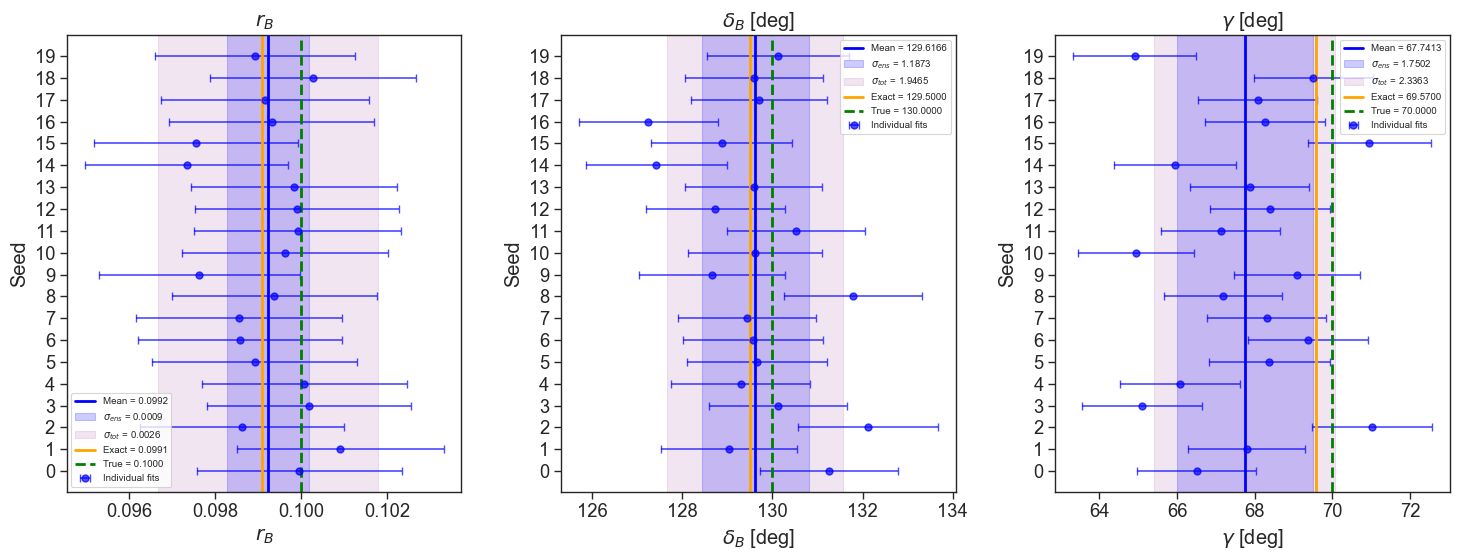

In [39]:
# ============================================================================
# Plot
# ============================================================================
exact_rB    = 0.0991
exact_delta = 129.50
exact_gamma = 69.57

set_nums = [int(re.search(r'set(\d+)', flavor_files[j]).group(1)) for j in range(n_trials)]

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

params = [
    (results_rB,    errors_rB,    exact_rB,    r"$r_B$",            true_rB),
    (results_delta, errors_delta, exact_delta, r"$\delta_B$ [deg]", true_deltaB * 180 / np.pi),
    (results_gamma, errors_gamma, exact_gamma, r"$\gamma$ [deg]",   true_gamma  * 180 / np.pi),
]

for ax, (vals, errs, exact_val, label, true_val) in zip(axes, params):
    sigma_ensemble = vals.std()
    sigma_fit      = errs.mean()
    sigma_total    = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    mean_val       = vals.mean()
    y_pos          = np.arange(len(vals))

    ax.errorbar(vals, y_pos, xerr=errs, fmt='o', color='blue',
                capsize=3, markersize=5, alpha=0.7, label='Individual fits')
    ax.axvline(mean_val, color='blue', linestyle='-', linewidth=2,
               label=f'Mean = {mean_val:.4f}')
    ax.axvspan(mean_val - sigma_ensemble, mean_val + sigma_ensemble,
               alpha=0.2, color='blue', label=f'$\\sigma_{{ens}}$ = {sigma_ensemble:.4f}')
    ax.axvspan(mean_val - sigma_total, mean_val + sigma_total,
               alpha=0.1, color='purple', label=f'$\\sigma_{{tot}}$ = {sigma_total:.4f}')
    ax.axvline(exact_val, color='orange', linestyle='-', linewidth=2,
               label=f'Exact = {exact_val:.4f}')
    ax.axvline(true_val, color='green', linestyle='--', linewidth=2,
               label=f'True = {true_val:.4f}')

    ax.set_ylabel('Seed')
    ax.set_xlabel(label)
    ax.set_title(label)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([str(s) for s in set_nums])

    ax.legend(fontsize=7, loc='best')

plt.tight_layout()
plt.savefig("ensemble_fit_results.png", dpi=150, bbox_inches='tight')
plt.show()

B-data 0.5

In [82]:
# True physics parameters
true_gamma = 100.0 * np.pi / 180.0    # Weak phase (CKM angle) in radians
true_deltaB = 60.0 * np.pi / 180.0  # Strong phase in radians
true_rB = 0.5                         # Amplitude ratio


results = np.load( "BpBm_samples_0.5_5e4.npz")

# Access the arrays
dataM_sdp = results["dataM_sdp"]
dataP_sdp = results["dataP_sdp"]



In [90]:
fit_rB_delta_gamma_SDP_unbinned_jac_terms_exact(
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcM_sdp,         # B+ Monte Carlo
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device
)

50000 50000
Total fit time: 1.57s

rB    = 0.4995 ± 0.0024
delta = 99.99° ± 0.49°
gamma = 59.62° ± 0.49°
(true rB=0.5000, true γ=60.00°, true δ=100.00°)


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.469e+04                  │              Nfcn = 114              │
│ EDM = 8.19e-07 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ rB    │  0.4995   │  0.0024   │            │            │    0    │    1    │       │
│ 1 │ delta │   100.0   │    0.5    │            │            │         │         │       │
│ 2 │ gamma │   59.6    │    0.5    │            │            │         │         │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬─────────────────────────┐
│       │      rB   delta   gamma │
├───────┼─────────────────────────┤
│    rB │   6e-06 -152e-6   43e-6 │
│ delta │ -152e-6   0.242    0.13 │
│ gamma │   43e-6    0.13   0.238 │
└───────┴─────────────────────────┘

In [75]:
import os,glob,re

hidden_features = 128
corrected_data_dir = "corrected_data_0.5"
os.makedirs(corrected_data_dir, exist_ok=True)

def get_model_files(ensemble_dir):
    files = glob.glob(f"{ensemble_dir}/flow_*_set*.pth")
    files.sort(key=lambda f: int(re.search(r'set(\d+)', f).group(1)))
    return files

flavor_files = get_model_files("flavor_2e6_independent")
odd_files    = get_model_files("odd_2e6_independent")
even_files   = get_model_files("even_2e6_independent")

n_trials = min(len(flavor_files), len(odd_files), len(even_files))

results_rB_2, results_delta_2, results_gamma_2 = [], [], []
errors_rB_2,  errors_delta_2,  errors_gamma_2  = [], [], []

for i in range(n_trials):
    print(f"\n{'='*60}")
    print(f"Trial {i+1}/{n_trials}")
    print(f"{'='*60}")

    flavor_path = flavor_files[i]
    odd_path    = odd_files[i]
    even_path   = even_files[i]

    set_num = int(re.search(r'set(\d+)', flavor_path).group(1))

    # Load flows
    flow = create_flow(num_flows=12, hidden_features=hidden_features, num_bins=24)
    flow.load_state_dict(torch.load(flavor_path, map_location=device), strict=False)
    flow.to(device).eval()

    flow_odd = create_flow(num_flows=12, hidden_features=hidden_features, num_bins=24)
    flow_odd.load_state_dict(torch.load(odd_path, map_location=device), strict=False)
    flow_odd.to(device).eval()

    flow_even = create_flow(num_flows=12, hidden_features=hidden_features, num_bins=24)
    flow_even.load_state_dict(torch.load(even_path, map_location=device), strict=False)
    flow_even.to(device).eval()

    # -------------------------------------------------------------------------
    # Load mcM_corrected from existing corrected_data/
    # -------------------------------------------------------------------------
    base_cache = os.path.join("corrected_data", f"corrected_set{set_num}.npz")
    cached_base = np.load(base_cache)
    mcM_corrected = cached_base['mcM_corrected']

    # -------------------------------------------------------------------------
    # Correct only dataP and dataM
    # -------------------------------------------------------------------------
    save_path = os.path.join(corrected_data_dir, f"corrected_set{set_num}.npz")

    if os.path.exists(save_path):
        print(f"  Loading cached corrected data from {save_path}")
        cached = np.load(save_path)
        dataP_corrected = cached['dataP_corrected']
        dataM_corrected = cached['dataM_corrected']
    else:
        print(f"  Correcting violating points...")
        dataP_corrected = correct_violating_points(
            dataP_sdp, flow, flow_even, flow_odd, dkpp, sdp_obj,
            gamma_m, gamma_p, (1, 2, 3), device)

        dataM_corrected = correct_violating_points(
            dataM_sdp, flow, flow_even, flow_odd, dkpp, sdp_obj,
            gamma_m, gamma_p, (1, 2, 3), device)

        np.savez(save_path,
                dataP_corrected=dataP_corrected,
                dataM_corrected=dataM_corrected)
        print(f"  Saved to {save_path}")

    # -------------------------------------------------------------------------
    # Fit
    # -------------------------------------------------------------------------
    m = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
        dataM_sdp=dataM_corrected,
        dataP_sdp=dataP_corrected,
        mcM_sdp=mcM_corrected,
        mcP_sdp=mcM_corrected,
        flow_flavor=flow,
        flow_even=flow_even,
        flow_odd=flow_odd,
        dkpp_model=dkpp,
        true_rB=true_rB,
        true_deltaB=true_deltaB * 180 / np.pi,
        true_gamma=true_gamma * 180 / np.pi,
        sdp_obj=sdp_obj,
        idx=(1, 2, 3),
        initial_scale=0.2,
        delta_offset=20,
        gamma_offset=20,
        device=device,
        Gamma_minus=gamma_m,
        Gamma_plus=gamma_p,
    )

    results_rB_2.append(m.values['rB'])
    results_delta_2.append(m.values['delta'])
    results_gamma_2.append(m.values['gamma'])
    errors_rB_2.append(m.errors['rB'])
    errors_delta_2.append(m.errors['delta'])
    errors_gamma_2.append(m.errors['gamma'])


Trial 1/20
  Loading cached corrected data from corrected_data_0.5\corrected_set0.npz


c:\Users\chinh\anaconda3\Lib\site-packages\nflows\transforms\coupling.py:481: UserWarning: Inputs to the softmax are not scaled down: initialization might be bad.
  warnings.warn(


49398 49463 492332 492332
Total fit time: 1.98s

rB    = 0.5027 ± 0.0025
delta = 101.15° ± 0.49°
gamma = 59.77° ± 0.48°
(true rB=0.5000, true γ=100.00°, true δ=60.00°)

Trial 2/20
  Loading cached corrected data from corrected_data_0.5\corrected_set1.npz
49505 49803 495324 495324
Total fit time: 1.82s

rB    = 0.4988 ± 0.0026
delta = 101.18° ± 0.48°
gamma = 60.02° ± 0.48°
(true rB=0.5000, true γ=100.00°, true δ=60.00°)

Trial 3/20
  Loading cached corrected data from corrected_data_0.5\corrected_set2.npz
49217 49170 488863 488863
Total fit time: 1.61s

rB    = 0.4950 ± 0.0024
delta = 101.73° ± 0.49°
gamma = 60.33° ± 0.49°
(true rB=0.5000, true γ=100.00°, true δ=60.00°)

Trial 4/20
  Loading cached corrected data from corrected_data_0.5\corrected_set3.npz
49703 49386 492669 492669
Total fit time: 1.56s

rB    = 0.5020 ± 0.0025
delta = 101.66° ± 0.48°
gamma = 59.65° ± 0.47°
(true rB=0.5000, true γ=100.00°, true δ=60.00°)

Trial 5/20
  Loading cached corrected data from corrected_data_0.5

In [85]:
results_rB_2    = np.array(results_rB_2)
results_delta_2 = np.array(results_delta_2)
results_gamma_2 = np.array(results_gamma_2)
errors_rB_2     = np.array(errors_rB_2)
errors_delta_2  = np.array(errors_delta_2)
errors_gamma_2  = np.array(errors_gamma_2)

# ============================================================================
# Summary
# ============================================================================
print(f"\n{'='*70}")
print(f"{'Parameter':<12} {'Mean':>10} {'σ_fit':>10} {'σ_ens':>10} {'σ_tot':>10} {'True':>10}")
print(f"{'='*70}")
for name, vals, errs, true_val in [
    ("rB",        results_rB_2,    errors_rB_2,    true_rB),
    ("delta [°]", results_delta_2, errors_delta_2, true_deltaB * 180 / np.pi),
    ("gamma [°]", results_gamma_2, errors_gamma_2, true_gamma  * 180 / np.pi),
]:
    sigma_ensemble = vals.std()
    sigma_fit      = errs.mean()
    sigma_total    = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    print(f"{name:<12} {vals.mean():>10.4f} {sigma_fit:>10.4f} {sigma_ensemble:>10.4f} {sigma_total:>10.4f} {true_val:>10.4f}")



Parameter          Mean      σ_fit      σ_ens      σ_tot       True
rB               0.4988     0.0025     0.0025     0.0035     0.5000
delta [°]      101.0649     0.4952     0.5219     0.7194    60.0000
gamma [°]       60.0697     0.4931     0.5233     0.7191   100.0000


In [88]:
true_gamma = 60.0 * np.pi / 180.0    # Weak phase (CKM angle) in radians
true_deltaB = 100.0 * np.pi / 180.0  # Strong phase in radians
true_rB = 0.5  

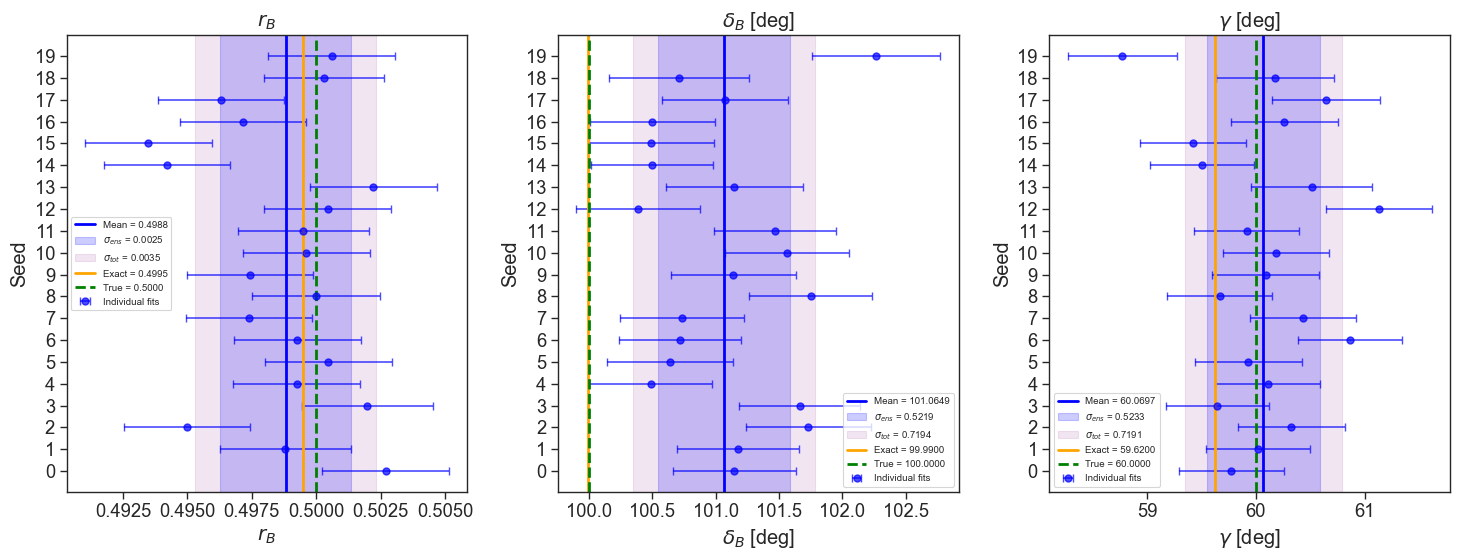

In [91]:
# ============================================================================
# Plot
# ============================================================================
exact_rB_2    =  0.4995
exact_delta_2 = 99.99
exact_gamma_2 = 59.62

set_nums = [int(re.search(r'set(\d+)', flavor_files[j]).group(1)) for j in range(n_trials)]

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

params = [
    (results_rB_2,    errors_rB_2,    exact_rB_2,    r"$r_B$",            true_rB),
    (results_delta_2, errors_delta_2, exact_delta_2, r"$\delta_B$ [deg]", true_deltaB * 180 / np.pi),
    (results_gamma_2, errors_gamma_2, exact_gamma_2, r"$\gamma$ [deg]",   true_gamma  * 180 / np.pi),
]

for ax, (vals, errs, exact_val, label, true_val) in zip(axes, params):
    sigma_ensemble = vals.std()
    sigma_fit      = errs.mean()
    sigma_total    = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    mean_val       = vals.mean()
    y_pos          = np.arange(len(vals))

    ax.errorbar(vals, y_pos, xerr=errs, fmt='o', color='blue',
                capsize=3, markersize=5, alpha=0.7, label='Individual fits')
    ax.axvline(mean_val, color='blue', linestyle='-', linewidth=2,
               label=f'Mean = {mean_val:.4f}')
    ax.axvspan(mean_val - sigma_ensemble, mean_val + sigma_ensemble,
               alpha=0.2, color='blue', label=f'$\\sigma_{{ens}}$ = {sigma_ensemble:.4f}')
    ax.axvspan(mean_val - sigma_total, mean_val + sigma_total,
               alpha=0.1, color='purple', label=f'$\\sigma_{{tot}}$ = {sigma_total:.4f}')
    ax.axvline(exact_val, color='orange', linestyle='-', linewidth=2,
               label=f'Exact = {exact_val:.4f}')
    ax.axvline(true_val, color='green', linestyle='--', linewidth=2,
               label=f'True = {true_val:.4f}')

    ax.set_ylabel('Seed')
    ax.set_xlabel(label)
    ax.set_title(label)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([str(s) for s in set_nums])

    ax.legend(fontsize=7, loc='best')

plt.tight_layout()
plt.savefig("ensemble_fit_results_2.png", dpi=150, bbox_inches='tight')
plt.show()

In [96]:
flow, flow_even, flow_odd = load_flow_triplet(
    flavor_path='joint_ensemble_flows_2e6_auglag_distill/flow_flavor_Set0.pth',
    even_path='joint_ensemble_flows_2e6_auglag_distill/flow_even_Set0.pth',
    odd_path='joint_ensemble_flows_2e6_auglag_distill/flow_odd_Set0.pth',
    num_flows=12,
    hidden_features=128,
    num_bins=24,
    device=device
)

Loaded flow triplet (311,124 params each):
  Flavor: joint_ensemble_flows_2e6_auglag_distill/flow_flavor_Set0.pth
  Even:   joint_ensemble_flows_2e6_auglag_distill/flow_even_Set0.pth
  Odd:    joint_ensemble_flows_2e6_auglag_distill/flow_odd_Set0.pth


In [ ]:
for i in range(19):  # set 0 to 18                                                                                                                                                                                                                                                                     
    print(f"\n{'='*60}")
    print(f"Trial {i}/18")
    print(f"{'='*60}")

    flow, flow_even, flow_odd = load_flow_triplet(
        flavor_path=f'joint_ensemble_flows_2e6_auglag_distill/flow_flavor_Set{i}.pth',
        even_path=  f'joint_ensemble_flows_2e6_auglag_distill/flow_even_Set{i}.pth',
        odd_path=   f'joint_ensemble_flows_2e6_auglag_distill/flow_odd_Set{i}.pth',
        num_flows=12,
        hidden_features=128,
        num_bins=24,
        device=device
    )

    m = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
        dataM_sdp=dataM_sdp,
        dataP_sdp=dataP_sdp,
        mcM_sdp=mcM_sdp,
        mcP_sdp=mcM_sdp,
        flow_flavor=flow,
        flow_even=flow_even,
        flow_odd=flow_odd,
        dkpp_model=dkpp,
        true_rB=true_rB,
        true_deltaB=true_deltaB * 180 / np.pi,
        true_gamma=true_gamma * 180 / np.pi,
        sdp_obj=sdp_obj,
        idx=(1, 2, 3),
        initial_scale=0.2,
        delta_offset=30,
        gamma_offset=30,
        device=device,
        Gamma_minus=gamma_m,
        Gamma_plus=gamma_p,
    )

    results_rB.append(m.values['rB'])
    results_delta.append(m.values['delta'])
    results_gamma.append(m.values['gamma'])
    errors_rB.append(m.errors['rB'])
    errors_delta.append(m.errors['delta'])
    errors_gamma.append(m.errors['gamma'])

results_rB    = np.array(results_rB)
results_delta = np.array(results_delta)
results_gamma = np.array(results_gamma)
errors_rB     = np.array(errors_rB)
errors_delta  = np.array(errors_delta)
errors_gamma  = np.array(errors_gamma)

print(f"\n{'='*70}")
print(f"{'Parameter':<12} {'Mean':>10} {'σ_fit':>10} {'σ_ens':>10} {'σ_tot':>10} {'True':>10}")
print(f"{'='*70}")
for name, vals, errs, true_val in [
    ("rB",        results_rB,    errors_rB,    true_rB),
    ("delta [°]", results_delta, errors_delta, true_deltaB * 180 / np.pi),
    ("gamma [°]", results_gamma, errors_gamma, true_gamma  * 180 / np.pi),
]:
    sigma_ensemble = vals.std()
    sigma_fit      = errs.mean()
    sigma_total    = np.sqrt(sigma_ensemble**2 + sigma_fit**2)
    print(f"{name:<12} {vals.mean():>10.4f} {sigma_fit:>10.4f} {sigma_ensemble:>10.4f} {sigma_total:>10.4f} {true_val:>10.4f}")

IndentationError: unindent does not match any outer indentation level (<string>, line 45)

In [97]:
# ============================================================================
# Perform unbinned maximum likelihood fit
# ============================================================================
import time
# Run the fit
m = fit_rB_delta_gamma_SDP_unbinned_jac_terms_flowDC(
    # Data samples
    dataM_sdp=dataM_sdp,     # B- experimental data
    dataP_sdp=dataP_sdp,     # B+ experimental data
    mcM_sdp=mcM_sdp,         # B- Monte Carlo
    mcP_sdp=mcM_sdp,         # B+ Monte Carlo
    
    # Amplitude models
    flow_flavor=flow,         # Combined flow (even+odd)
    flow_even=flow_even,      # CP-even flow
    flow_odd=flow_odd,        # CP-odd flow
    dkpp_model=dkpp,          # D -> Kspipi amplitude model
    
    # True values (for comparison)
    true_rB=true_rB,
    true_deltaB=true_deltaB  * 180 / np.pi,
    true_gamma=true_gamma  * 180 / np.pi,
    
    # Configuration
    sdp_obj=sdp_obj,
    idx=(1, 2, 3),
    initial_scale=0.2,        # Starting scale for r_B (relative to true value)
    delta_offset=30,          # Offset in degrees for delta_B initialization
    gamma_offset=30,          # Offset in degrees for gamma initialization
    device=device,
    
    # Normalizations
    Gamma_minus=gamma_m,
    Gamma_plus=gamma_p,                     
)

# Print results
print(m)

48354 48405 464550 464550
Total fit time: 1.54s

rB    = 0.4979 ± 0.0024
delta = 100.75° ± 0.48°
gamma = 61.31° ± 0.48°
(true rB=0.5000, true γ=60.00°, true δ=100.00°)
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.812e+04                  │              Nfcn = 112              │
│ EDM = 2.07e-06 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate        